# Titanic 32: Private champion 기반 최종 모델

Titanic 1의 데이터 확인 → Target → EDA → 전처리 → 학습/평가 → 전체 재학습 → 제출 흐름을 유지한다. 기존 파일을 수정하지 않는다. Private champion15는 raw Age와 AgeBand를 함께 사용한 33열 모델로 복원한다. 피처 제거 → 새 피처 검증 → 피처 확정 → 제한된 tuning → 후보 비교 순서다.

In [1]:
from pathlib import Path
import random, json, hashlib, sys, io, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image, Markdown
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, StratifiedGroupKFold
from sklearn.metrics import roc_auc_score, confusion_matrix
from scipy.stats import chi2_contingency
from catboost import CatBoostClassifier, Pool
import sklearn, catboost

SEED=42
random.seed(SEED)
np.random.seed(SEED)
pd.set_option('display.max_columns',None)
pd.set_option('display.max_colwidth',160)
pd.set_option('display.max_rows',100)
ROOT=Path.cwd()
train=pd.read_csv(ROOT/'csv/train.csv')
test=pd.read_csv(ROOT/'csv/test.csv')
submission=pd.read_csv(ROOT/'csv/submission.csv')
target_col,id_col='survived','passengerid'
assert train.shape[0]==916 and test.shape[0]==393
assert submission.columns.tolist()==[id_col,target_col]
assert test[id_col].equals(submission[id_col])
print("Environment:",sys.version,catboost.__version__,sklearn.__version__,pd.__version__)
display(pd.DataFrame({'component':['Python random','NumPy','train_test_split','StratifiedKFold','StratifiedGroupKFold','CatBoost'],
                      'random_state':[SEED]*6}))
display(train.head())
display(pd.DataFrame({'dtype':train.dtypes.astype(str),'missing':train.isna().sum(),'unique':train.nunique()}))
print("Target counts:",train[target_col].value_counts().to_dict())
X=train.drop(columns=[id_col,target_col])
y=train[target_col].astype('int8')
X_test_raw=test.drop(columns=id_col)
assert X.columns.equals(X_test_raw.columns)
assert train[id_col].is_unique and test[id_col].is_unique
assert set(train[id_col]).isdisjoint(test[id_col])
assert set(y.unique())=={0,1}
HOLD_TR,HOLD_VA=train_test_split(np.arange(len(y)),test_size=.25,stratify=y,random_state=SEED)
SPLITS=list(StratifiedKFold(5,shuffle=True,random_state=SEED).split(X,y))
BASE_PARAMS={'verbose':False,'random_seed':SEED,'cat_features':[],'allow_writing_files':False,
             'thread_count':1,'task_type':'CPU'}
BASE_SPEC={'drop':[],'add':[]}
# AUC differences below this are treated as practically negligible, not significant.
MIN_GAIN=.001
MAX_STD_RISE=.003
CACHE={}
RUN_LOG=[]
def show_figure(fig):
    b=io.BytesIO()
    fig.savefig(b,format='png',dpi=115,bbox_inches='tight')
    display(Image(data=b.getvalue()))
    plt.close(fig)

Environment: 3.14.7 (tags/v3.14.7:823f032, Aug  5 2026, 10:51:32) [MSC v.1944 64 bit (AMD64)] 1.2.10 1.9.0 3.0.5
Target counts: {0: 570, 1: 346}


,component,random_state
0,Python random,42
1,NumPy,42
2,train_test_split,42
3,StratifiedKFold,42
4,StratifiedGroupKFold,42
5,CatBoost,42


,passengerid,survived,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked
0,0,0,2,"Wheeler, Mr. Edwin Frederick""""",male,NaN,0,0,SC/PARIS 2159,12.8750,NaN,S
1,1,0,3,"Henry, Miss. Delia",female,NaN,0,0,382649,7.7500,NaN,Q
2,2,1,1,"Hays, Mrs. Charles Melville (Clara Jennings Gregg)",female,52.0,1,1,12749,93.5000,B69,S
3,3,1,3,"Andersson, Mr. August Edvard (""Wennerstrom"")",male,27.0,0,0,350043,7.7958,NaN,S
4,4,0,2,"Hold, Mr. Stephen",male,44.0,1,0,26707,26.0000,NaN,S


,dtype,missing,unique
passengerid,int64,0,916
survived,int64,0,2
pclass,int64,0,3
name,str,0,915
gender,str,0,2
age,float64,180,92
sibsp,int64,0,7
parch,int64,0,8
ticket,str,0,703
fare,float64,0,251


## 기존 실험 전체 검토

| Experiment | Added | Removed | Train AUC | Validation AUC | CV Mean | CV Std | OOF AUC | Private | Public |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 1 |  |  | 0.963079 | 0.900065 | 0.901775 | 0.016322 | 0.899876 | 0.911180 | 0.896720 |
| 2 submission=Base |  |  | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 |
| 2 / HasCabin | HasCabin |  | 0.964623 | 0.898439 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 |
| 2 / AgeMissing | AgeMissing |  | 0.964178 | 0.899943 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 |
| 3 | Title |  | 0.965168 | 0.902992 | 0.900010 | 0.016136 | 미기록 | 미기록 | 미기록 |
| 4 | SexPclass |  | 0.963047 | 0.902911 | 0.904676 | 0.016132 | 미기록 | 미기록 | 미기록 |
| 5 | FamilyGroup |  | 0.964434 | 0.902748 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 |
| 6 | TicketGroupSize |  | 0.964691 | 0.899984 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 |
| 7 | FarePerPerson |  | 0.965835 | 0.902748 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 |
| 8 | IsChild |  | 0.964218 | 0.903155 | 0.902251 | 0.017383 | 미기록 | 미기록 | 미기록 |
| 9 | CabinDeck |  | 0.964011 | 0.904781 | 0.902823 | 0.013704 | 미기록 | 미기록 | 미기록 |
| 10 | GenderIsChild |  | 0.965065 | 0.904293 | 0.905907 | 0.017324 | 미기록 | 미기록 | 미기록 |
| 11 | ClassIsChild |  | 0.964795 | 0.906489 | 0.906233 | 0.018564 | 0.904389 | 0.912540 | 0.896720 |
| 12 | GenderIsAlone |  | 0.963471 | 0.904619 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 |
| 13 | EmbarkedClass |  | 0.963489 | 0.905757 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 |
| 14 | TicketPrefix |  | 0.969699 | 0.902423 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 |
| 15 | AgeBand |  | 0.965299 | 0.903643 | 0.906275 | 0.016868 | 0.904247 | 0.914680 | 0.891210 |
| 16_randomized_search |  |  | 0.952909 | 0.900065 | 0.910481 | 0.017304 | 0.907781 | 미기록 | 미기록 |
| 16_delete_age |  | age | 0.965299 | 0.903643 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 |
| 16_isnoble | IsNoble |  | 0.963227 | 0.899821 | 0.898784 | 0.014441 | 미기록 | 미기록 | 미기록 |
| 17_profession_group | ProfessionGroup |  | 0.962182 | 0.899496 | 0.900609 | 0.016918 | 미기록 | 미기록 | 미기록 |
| 18 | LogFare |  | 0.965128 | 0.900309 | 0.898336 | 0.015689 | 미기록 | 미기록 | 미기록 |
| 19 | AgeBand | age | 0.964272 | 0.895552 | 0.904387 | 0.011004 | 미기록 | 미기록 | 미기록 |
| 20 |  | LogFare | 0.963079 | 0.900065 | 0.901775 | 0.016322 | 미기록 | 미기록 | 미기록 |
| 21 |  | IsAlone | 0.964155 | 0.903480 | 0.900862 | 0.018278 | 미기록 | 미기록 | 미기록 |
| 22 | NonFamilyGroupSize |  | 0.965556 | 0.899333 | 0.900966 | 0.016310 | 미기록 | 미기록 | 미기록 |
| 23 | TicketFarePerPerson |  | 0.967393 | 0.901935 | 0.900752 | 0.015635 | 미기록 | 미기록 | 미기록 |
| 24 | NonFamilyGroupRatio |  | 0.966574 | 0.896975 | 0.900748 | 0.014903 | 미기록 | 미기록 | 미기록 |
| 25 | NonFamilyGroupSize,TicketFarePerPerson,NonFamilyGroupRatio |  | 0.967303 | 0.896731 | 0.898545 | 0.014154 | 미기록 | 미기록 | 미기록 |
| 26 |  |  | 0.963754 | 0.900390 | 0.909335 | 0.014127 | 미기록 | 미기록 | 미기록 |
| 27 |  |  | 0.973396 | 0.895633 | 0.909254 | 0.015288 | 미기록 | 미기록 | 미기록 |
| 28 |  |  | 0.925486 | 0.906367 | 0.914325 | 0.012962 | 0.878288 | 미기록 | 미기록 |
| 29 |  |  | 0.929900 | 0.898845 | 0.907632 | 0.009901 | 0.869942 | 미기록 | 미기록 |
| 30 |  |  | 0.926211 | 0.905107 | 0.911666 | 0.013079 | 0.886363 | 미기록 | 미기록 |
| 31 |  |  | 0.925486 | 0.906367 | 0.914325 | 0.012962 | 0.878288 | 미기록 | 미기록 |

상세 이력과 모든 지표/설정 증거는 최종 Markdown 보고서 부록에 포함된다. Private/Public 미기록을 추정하지 않는다.

In [2]:
HISTORY_MD = '### 分析 범위\n\n관련 프로젝트 파일을 내용과 SHA-256으로 읽었다. 가상환경/캐시 라이브러리는 제외했다. 오래된 출력은 현재 코드로 다시 생성한 값과 구분한다. 미기록을 0으로 취급하지 않는다.\n\n노트북 42개, 텍스트/데이터 파일 147개, CSV 45개 확인.\n\n| Experiment | Added | Removed | Train AUC | Validation AUC | CV Mean | CV Std | OOF AUC | Private | Public |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 1 |  |  | 0.963079 | 0.900065 | 0.901775 | 0.016322 | 0.899876 | 0.911180 | 0.896720 |\n| 2 submission=Base |  |  | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 |\n| 2 / HasCabin | HasCabin |  | 0.964623 | 0.898439 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 |\n| 2 / AgeMissing | AgeMissing |  | 0.964178 | 0.899943 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 |\n| 3 | Title |  | 0.965168 | 0.902992 | 0.900010 | 0.016136 | 미기록 | 미기록 | 미기록 |\n| 4 | SexPclass |  | 0.963047 | 0.902911 | 0.904676 | 0.016132 | 미기록 | 미기록 | 미기록 |\n| 5 | FamilyGroup |  | 0.964434 | 0.902748 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 |\n| 6 | TicketGroupSize |  | 0.964691 | 0.899984 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 |\n| 7 | FarePerPerson |  | 0.965835 | 0.902748 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 |\n| 8 | IsChild |  | 0.964218 | 0.903155 | 0.902251 | 0.017383 | 미기록 | 미기록 | 미기록 |\n| 9 | CabinDeck |  | 0.964011 | 0.904781 | 0.902823 | 0.013704 | 미기록 | 미기록 | 미기록 |\n| 10 | GenderIsChild |  | 0.965065 | 0.904293 | 0.905907 | 0.017324 | 미기록 | 미기록 | 미기록 |\n| 11 | ClassIsChild |  | 0.964795 | 0.906489 | 0.906233 | 0.018564 | 0.904389 | 0.912540 | 0.896720 |\n| 12 | GenderIsAlone |  | 0.963471 | 0.904619 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 |\n| 13 | EmbarkedClass |  | 0.963489 | 0.905757 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 |\n| 14 | TicketPrefix |  | 0.969699 | 0.902423 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 |\n| 15 | AgeBand |  | 0.965299 | 0.903643 | 0.906275 | 0.016868 | 0.904247 | 0.914680 | 0.891210 |\n| 16_randomized_search |  |  | 0.952909 | 0.900065 | 0.910481 | 0.017304 | 0.907781 | 미기록 | 미기록 |\n| 16_delete_age |  | age | 0.965299 | 0.903643 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 |\n| 16_isnoble | IsNoble |  | 0.963227 | 0.899821 | 0.898784 | 0.014441 | 미기록 | 미기록 | 미기록 |\n| 17_profession_group | ProfessionGroup |  | 0.962182 | 0.899496 | 0.900609 | 0.016918 | 미기록 | 미기록 | 미기록 |\n| 18 | LogFare |  | 0.965128 | 0.900309 | 0.898336 | 0.015689 | 미기록 | 미기록 | 미기록 |\n| 19 | AgeBand | age | 0.964272 | 0.895552 | 0.904387 | 0.011004 | 미기록 | 미기록 | 미기록 |\n| 20 |  | LogFare | 0.963079 | 0.900065 | 0.901775 | 0.016322 | 미기록 | 미기록 | 미기록 |\n| 21 |  | IsAlone | 0.964155 | 0.903480 | 0.900862 | 0.018278 | 미기록 | 미기록 | 미기록 |\n| 22 | NonFamilyGroupSize |  | 0.965556 | 0.899333 | 0.900966 | 0.016310 | 미기록 | 미기록 | 미기록 |\n| 23 | TicketFarePerPerson |  | 0.967393 | 0.901935 | 0.900752 | 0.015635 | 미기록 | 미기록 | 미기록 |\n| 24 | NonFamilyGroupRatio |  | 0.966574 | 0.896975 | 0.900748 | 0.014903 | 미기록 | 미기록 | 미기록 |\n| 25 | NonFamilyGroupSize,TicketFarePerPerson,NonFamilyGroupRatio |  | 0.967303 | 0.896731 | 0.898545 | 0.014154 | 미기록 | 미기록 | 미기록 |\n| 26 |  |  | 0.963754 | 0.900390 | 0.909335 | 0.014127 | 미기록 | 미기록 | 미기록 |\n| 27 |  |  | 0.973396 | 0.895633 | 0.909254 | 0.015288 | 미기록 | 미기록 | 미기록 |\n| 28 |  |  | 0.925486 | 0.906367 | 0.914325 | 0.012962 | 0.878288 | 미기록 | 미기록 |\n| 29 |  |  | 0.929900 | 0.898845 | 0.907632 | 0.009901 | 0.869942 | 미기록 | 미기록 |\n| 30 |  |  | 0.926211 | 0.905107 | 0.911666 | 0.013079 | 0.886363 | 미기록 | 미기록 |\n| 31 |  |  | 0.925486 | 0.906367 | 0.914325 | 0.012962 | 0.878288 | 미기록 | 미기록 |\n\n### 피처 분류 (확실함은 이 개발 기록 내에서만 의미)\n\nA: GenderClass/SexPclass, GenderIsChild, ClassIsChild — 당시 누적 holdout/CV와 일부 Private 방향이 일치. 기본 gender/pclass/fare는 강한 신호지만 각각 독립적인 역사적 제거 실험은 없어 이번 ablation으로 보완한다.\n\nB: AgeBand — Private15에는 이득, 로컬 지표 혼재; age와 함께 쓴 champion을 보존. CabinDeck/HasCabin/AgeMissing/FamilyGroup/EmbarkedClass/GenderIsAlone/FarePerPerson — 단일 지표 또는 미미한 차이, 충분한 반복 근거 없음.\n\nC: LogFare — 단조 변환/중복 후보; 18의 Base 오염으로 독립 추가 효과 주장 불가. IsAlone/FamilySize/sibsp/parch — 구조적 중복 후보이나 삭제 효과는 반드시 실험. NonFamilyGroupSize의 .000104 CV 차이는 실질적 이득 근거 부족.\n\nD: Title/IsChild/IsNoble/ProfessionGroup/TicketPrefix/TicketGroupSize/NonFamilyGroupRatio/세 Ticket 결합 — 해당 조건 CV 또는 holdout 악화. 일반적으로 무효라 단정하지 않음.\n\n원천 목록: passengerid(ID, 제외), survived(target), name/ticket/cabin(원문 제외 및 파생 원천), pclass, gender(별도 프로젝트 sex와 의미상 대응), age, sibsp, parch, fare, embarked. 파생 전체: FamilySize/family_size, IsAlone, HasCabin, AgeMissing, Title, SexPclass/GenderClass, FamilyGroup, TicketGroupSize, FarePerPerson/TicketFarePerPerson, IsChild, CabinDeck/Deck, GenderIsChild, ClassIsChild, GenderIsAlone, EmbarkedClass, TicketPrefix, AgeBand, IsNoble, ProfessionGroup/Occupation, LogFare, NonFamilyGroupSize, NonFamilyGroupRatio. 별도 seaborn 학습 파일의 who/adult_male/alive 등은 현재 대회 피처로 합치지 않는다.\n\n### 실험별 상세\n\n#### Titanic 1\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 1 |  |  | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\'] | 0.963079 | 0.900065 | 0.901775 | 0.016322 | [0.8919172932330827, 0.9190821256038647, 0.8787821001779812, 0.9064327485380117, 0.9126620900076278] | 0.899876 | 0.911180 | 0.896720 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) |  |\n\n#### Titanic 2 submission=Base\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 2 submission=Base |  |  | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\'] | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | HasCabin/AgeMissing both rejected; CSV is Base. |\n\n#### Titanic 2 / HasCabin\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 2 / HasCabin | HasCabin |  | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'HasCabin\'] | 0.964623 | 0.898439 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | CV not run; holdout -0.001626 vs Base; not repeated proof of noise. |\n\n#### Titanic 2 / AgeMissing\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 2 / AgeMissing | AgeMissing |  | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'AgeMissing\'] | 0.964178 | 0.899943 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | CV not run; holdout -0.000122, inconclusive. |\n\n#### Titanic 3\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 3 | Title |  | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'Title_Master\', \'Title_Miss\', \'Title_Mr\', \'Title_Mrs\', \'Title_Rare\', \'Title_Rev\'] | 0.965168 | 0.902992 | 0.900010 | 0.016136 | [0.8914160401002506, 0.9139333841851005, 0.8759852529875414, 0.9060513602847698, 0.9126620900076278] | 미기록 | 미기록 | 미기록 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | Historical accepted=False; holdout delta vs then-best=+0.002927. |\n\n#### Titanic 4\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 4 | SexPclass |  | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'SexPclass_female_1\', \'SexPclass_female_2\', \'SexPclass_female_3\', \'SexPclass_male_1\', \'SexPclass_male_2\', \'SexPclass_male_3\'] | 0.963047 | 0.902911 | 0.904676 | 0.016132 | [0.8954887218045113, 0.9222603610475464, 0.8817060767861683, 0.9093567251461988, 0.9145690312738367] | 미기록 | 미기록 | 미기록 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | Historical accepted=True; holdout delta vs then-best=+0.002846. |\n\n#### Titanic 5\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 5 | FamilyGroup |  | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'SexPclass_female_1\', \'SexPclass_female_2\', \'SexPclass_female_3\', \'SexPclass_male_1\', \'SexPclass_male_2\', \'SexPclass_male_3\', \'FamilyGroup_Alone\', \'FamilyGroup_Large\', \'FamilyGroup_Small\'] | 0.964434 | 0.902748 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | Historical accepted=False; holdout delta vs then-best=-0.000163. |\n\n#### Titanic 6\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 6 | TicketGroupSize |  | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'TicketGroupSize\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'SexPclass_female_1\', \'SexPclass_female_2\', \'SexPclass_female_3\', \'SexPclass_male_1\', \'SexPclass_male_2\', \'SexPclass_male_3\'] | 0.964691 | 0.899984 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | Historical accepted=False; holdout delta vs then-best=-0.002927. |\n\n#### Titanic 7\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 7 | FarePerPerson |  | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'FarePerPerson\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'SexPclass_female_1\', \'SexPclass_female_2\', \'SexPclass_female_3\', \'SexPclass_male_1\', \'SexPclass_male_2\', \'SexPclass_male_3\'] | 0.965835 | 0.902748 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | Historical accepted=False; holdout delta vs then-best=-0.000163. |\n\n#### Titanic 8\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 8 | IsChild |  | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'IsChild\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'SexPclass_female_1\', \'SexPclass_female_2\', \'SexPclass_female_3\', \'SexPclass_male_1\', \'SexPclass_male_2\', \'SexPclass_male_3\'] | 0.964218 | 0.903155 | 0.902251 | 0.017383 | [0.8944235588972432, 0.919209255021612, 0.8758581235697941, 0.9082125603864734, 0.9135519959318587] | 미기록 | 미기록 | 미기록 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | Historical accepted=False; holdout delta vs then-best=+0.000244. |\n\n#### Titanic 9\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 9 | CabinDeck |  | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'SexPclass_female_1\', \'SexPclass_female_2\', \'SexPclass_female_3\', \'SexPclass_male_1\', \'SexPclass_male_2\', \'SexPclass_male_3\', \'CabinDeck_A\', \'CabinDeck_B\', \'CabinDeck_C\', \'CabinDeck_D\', \'CabinDeck_E\', \'CabinDeck_F\', \'CabinDeck_G\', \'CabinDeck_T\', \'CabinDeck_Unknown\'] | 0.964011 | 0.904781 | 0.902823 | 0.013704 | [0.8944862155388471, 0.9185736079328757, 0.8841215357233663, 0.9052885837782864, 0.9116450546656496] | 미기록 | 미기록 | 미기록 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | Historical accepted=False; holdout delta vs then-best=+0.001870. |\n\n#### Titanic 10\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 10 | GenderIsChild |  | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'GenderClass_female_1\', \'GenderClass_female_2\', \'GenderClass_female_3\', \'GenderClass_male_1\', \'GenderClass_male_2\', \'GenderClass_male_3\', \'GenderIsChild_female_0\', \'GenderIsChild_female_1\', \'GenderIsChild_male_0\', \'GenderIsChild_male_1\'] | 0.965065 | 0.904293 | 0.905907 | 0.017324 | [0.8964285714285715, 0.92442156114925, 0.8809433002796847, 0.9108822781591661, 0.9168573607932875] | 미기록 | 미기록 | 미기록 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | Historical accepted=True; holdout delta vs then-best=+0.001382. |\n\n#### Titanic 11\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 11 | ClassIsChild |  | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'GenderClass_female_1\', \'GenderClass_female_2\', \'GenderClass_female_3\', \'GenderClass_male_1\', \'GenderClass_male_2\', \'GenderClass_male_3\', \'GenderIsChild_female_0\', \'GenderIsChild_female_1\', \'GenderIsChild_male_0\', \'GenderIsChild_male_1\', \'ClassIsChild_1_0\', \'ClassIsChild_1_1\', \'ClassIsChild_2_0\', \'ClassIsChild_2_1\', \'ClassIsChild_3_0\', \'ClassIsChild_3_1\'] | 0.964795 | 0.906489 | 0.906233 | 0.018564 | [0.8979323308270678, 0.9263285024154589, 0.8785278413424867, 0.9117721840833969, 0.9166031019577929] | 0.904389 | 0.912540 | 0.896720 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | Historical accepted=True; holdout delta vs then-best=+0.002195. |\n\n#### Titanic 12\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 12 | GenderIsAlone |  | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'GenderClass_female_1\', \'GenderClass_female_2\', \'GenderClass_female_3\', \'GenderClass_male_1\', \'GenderClass_male_2\', \'GenderClass_male_3\', \'GenderIsChild_female_0\', \'GenderIsChild_female_1\', \'GenderIsChild_male_0\', \'GenderIsChild_male_1\', \'ClassIsChild_1_0\', \'ClassIsChild_1_1\', \'ClassIsChild_2_0\', \'ClassIsChild_2_1\', \'ClassIsChild_3_0\', \'ClassIsChild_3_1\', \'GenderIsAlone_female_0\', \'GenderIsAlone_female_1\', \'GenderIsAlone_male_0\', \'GenderIsAlone_male_1\'] | 0.963471 | 0.904619 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | Historical accepted=False; holdout delta vs then-best=-0.001870. |\n\n#### Titanic 13\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 13 | EmbarkedClass |  | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'GenderClass_female_1\', \'GenderClass_female_2\', \'GenderClass_female_3\', \'GenderClass_male_1\', \'GenderClass_male_2\', \'GenderClass_male_3\', \'GenderIsChild_female_0\', \'GenderIsChild_female_1\', \'GenderIsChild_male_0\', \'GenderIsChild_male_1\', \'ClassIsChild_1_0\', \'ClassIsChild_1_1\', \'ClassIsChild_2_0\', \'ClassIsChild_2_1\', \'ClassIsChild_3_0\', \'ClassIsChild_3_1\', \'EmbarkedClass_C_1\', \'EmbarkedClass_C_2\', \'EmbarkedClass_C_3\', \'EmbarkedClass_Q_1\', \'EmbarkedClass_Q_2\', \'EmbarkedClass_Q_3\', \'EmbarkedClass_S_1\', \'EmbarkedClass_S_2\', \'EmbarkedClass_S_3\'] | 0.963489 | 0.905757 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | Historical accepted=False; holdout delta vs then-best=-0.000732. |\n\n#### Titanic 14\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 14 | TicketPrefix |  | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'GenderClass_female_1\', \'GenderClass_female_2\', \'GenderClass_female_3\', \'GenderClass_male_1\', \'GenderClass_male_2\', \'GenderClass_male_3\', \'GenderIsChild_female_0\', \'GenderIsChild_female_1\', \'GenderIsChild_male_0\', \'GenderIsChild_male_1\', \'ClassIsChild_1_0\', \'ClassIsChild_1_1\', \'ClassIsChild_2_0\', \'ClassIsChild_2_1\', \'ClassIsChild_3_0\', \'ClassIsChild_3_1\', \'TicketPrefix_A4\', \'TicketPrefix_A5\', \'TicketPrefix_C\', \'TicketPrefix_CA\', \'TicketPrefix_FCC\', \'TicketPrefix_NUMERIC\', \'TicketPrefix_PC\', \'TicketPrefix_Rare\', \'TicketPrefix_SCPARIS\', \'TicketPrefix_SOC\', \'TicketPrefix_SOPP\', \'TicketPrefix_SOTONOQ\', \'TicketPrefix_STONO2\', \'TicketPrefix_WC\'] | 0.969699 | 0.902423 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | Historical accepted=False; holdout delta vs then-best=-0.004066. |\n\n#### Titanic 15\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 15 | AgeBand |  | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'GenderClass_female_1\', \'GenderClass_female_2\', \'GenderClass_female_3\', \'GenderClass_male_1\', \'GenderClass_male_2\', \'GenderClass_male_3\', \'GenderIsChild_female_0\', \'GenderIsChild_female_1\', \'GenderIsChild_male_0\', \'GenderIsChild_male_1\', \'ClassIsChild_1_0\', \'ClassIsChild_1_1\', \'ClassIsChild_2_0\', \'ClassIsChild_2_1\', \'ClassIsChild_3_0\', \'ClassIsChild_3_1\', \'AgeBand_Adult\', \'AgeBand_Child\', \'AgeBand_Senior\', \'AgeBand_Teen\', \'AgeBand_YoungAdult\'] | 0.965299 | 0.903643 | 0.906275 | 0.016868 | [0.9010651629072682, 0.9237859140605136, 0.8797991355199594, 0.9121535723366387, 0.9145690312738368] | 0.904247 | 0.914680 | 0.891210 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | Historical accepted=False; holdout delta vs then-best=-0.002846. Historical Private CSV retained age+AgeBand (33 columns). Current common code removes age (32); stored markdown and recent output disagree. |\n\n#### Titanic 16_randomized_search\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 16_randomized_search |  |  | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'GenderClass_female_1\', \'GenderClass_female_2\', \'GenderClass_female_3\', \'GenderClass_male_1\', \'GenderClass_male_2\', \'GenderClass_male_3\', \'GenderIsChild_female_0\', \'GenderIsChild_female_1\', \'GenderIsChild_male_0\', \'GenderIsChild_male_1\', \'ClassIsChild_1_0\', \'ClassIsChild_1_1\', \'ClassIsChild_2_0\', \'ClassIsChild_2_1\', \'ClassIsChild_3_0\', \'ClassIsChild_3_1\', \'AgeBand_Adult\', \'AgeBand_Child\', \'AgeBand_Senior\', \'AgeBand_Teen\', \'AgeBand_YoungAdult\'] | 0.952909 | 0.900065 | 0.910481 | 0.017304 | 미기록 | 0.907781 | 미기록 | 미기록 | CatBoost | {\'border_count\': 128, \'depth\': 4, \'iterations\': 817, \'l2_leaf_reg\': 1.9452208847287389, \'learning_rate\': 0.006971115660907851, \'random_strength\': 0.3746261155838959, \'subsample\': 0.9328729111737557} | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | Historical 33-column input; 30-trial search on same CV, private/public placeholders not scores. |\n\n#### Titanic 16_delete_age\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 16_delete_age |  | age | [\'pclass\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'GenderClass_female_1\', \'GenderClass_female_2\', \'GenderClass_female_3\', \'GenderClass_male_1\', \'GenderClass_male_2\', \'GenderClass_male_3\', \'GenderIsChild_female_0\', \'GenderIsChild_female_1\', \'GenderIsChild_male_0\', \'GenderIsChild_male_1\', \'ClassIsChild_1_0\', \'ClassIsChild_1_1\', \'ClassIsChild_2_0\', \'ClassIsChild_2_1\', \'ClassIsChild_3_0\', \'ClassIsChild_3_1\', \'AgeBand_Adult\', \'AgeBand_Child\', \'AgeBand_Senior\', \'AgeBand_Teen\', \'AgeBand_YoungAdult\'] | 0.965299 | 0.903643 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | 미기록 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | Stored outputs are legacy 33-column numbers; current imported module deletes age. No reliable independent CV for this named variant. |\n\n#### Titanic 16_isnoble\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 16_isnoble | IsNoble |  | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'IsNoble\'] | 0.963227 | 0.899821 | 0.898784 | 0.014441 | [0.888784, 0.911073, 0.879036, 0.903, 0.912026] | 미기록 | 미기록 | 미기록 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | Base-derived, not a cumulative 15 experiment; only 1/5 improved folds. |\n\n#### Titanic 17_profession_group\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 17_profession_group | ProfessionGroup |  | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'ProfessionGroup\'] | 0.962182 | 0.899496 | 0.900609 | 0.016918 | [0.890664, 0.917684, 0.876112, 0.907958, 0.910628] | 미기록 | 미기록 | 미기록 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | Base-derived; only 1/5 improved folds. |\n\n#### Titanic 18\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 18 | LogFare |  | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'LogFare\'] | 0.965128 | 0.900309 | 0.898336 | 0.015689 | 미기록 | 미기록 | 미기록 | 미기록 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | 18 branch: no GenderClass/GenderIsChild/ClassIsChild interactions. LogFare already added to both Base and Candidate before comparison; equality is not a valid isolated ablation. |\n\n#### Titanic 19\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 19 | AgeBand | age | [\'pclass\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'LogFare\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'AgeBand_Adult\', \'AgeBand_Child\', \'AgeBand_Senior\', \'AgeBand_Teen\', \'AgeBand_YoungAdult\'] | 0.964272 | 0.895552 | 0.904387 | 0.011004 | [0.903258, 0.91673, 0.888762, 0.900394, 0.912789] | 미기록 | 미기록 | 미기록 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | 18 branch: no GenderClass/GenderIsChild/ClassIsChild interactions. |\n\n#### Titanic 20\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 20 |  | LogFare | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\'] | 0.963079 | 0.900065 | 0.901775 | 0.016322 | [0.891917, 0.919082, 0.878782, 0.906433, 0.912662] | 미기록 | 미기록 | 미기록 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | 18 branch: no GenderClass/GenderIsChild/ClassIsChild interactions. |\n\n#### Titanic 21\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 21 |  | IsAlone | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'LogFare\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\'] | 0.964155 | 0.903480 | 0.900862 | 0.018278 | [0.891291, 0.920353, 0.874587, 0.904526, 0.913552] | 미기록 | 미기록 | 미기록 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | 18 branch: no GenderClass/GenderIsChild/ClassIsChild interactions. chosen on holdout despite 19 having higher CV; do not equate branch best with global best. |\n\n#### Titanic 22\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 22 | NonFamilyGroupSize |  | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'LogFare\', \'NonFamilyGroupSize\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\'] | 0.965556 | 0.899333 | 0.900966 | 0.016310 | [0.890414, 0.919718, 0.879926, 0.90122, 0.913552] | 미기록 | 미기록 | 미기록 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | 18 branch: no GenderClass/GenderIsChild/ClassIsChild interactions. Train-only ticket frequencies differ between fit and validation observations; subtracting FamilySize can be negative. |\n\n#### Titanic 23\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 23 | TicketFarePerPerson |  | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'LogFare\', \'TicketFarePerPerson\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\'] | 0.967393 | 0.901935 | 0.900752 | 0.015635 | [0.885401, 0.91654, 0.883613, 0.903636, 0.914569] | 미기록 | 미기록 | 미기록 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | 18 branch: no GenderClass/GenderIsChild/ClassIsChild interactions. Train-only ticket frequencies differ between fit and validation observations; subtracting FamilySize can be negative. |\n\n#### Titanic 24\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 24 | NonFamilyGroupRatio |  | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'LogFare\', \'NonFamilyGroupRatio\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\'] | 0.966574 | 0.896975 | 0.900748 | 0.014903 | [0.891228, 0.920099, 0.885139, 0.89461, 0.912662] | 미기록 | 미기록 | 미기록 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | 18 branch: no GenderClass/GenderIsChild/ClassIsChild interactions. Train-only ticket frequencies differ between fit and validation observations; subtracting FamilySize can be negative. |\n\n#### Titanic 25\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 25 | NonFamilyGroupSize,TicketFarePerPerson,NonFamilyGroupRatio |  | [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'LogFare\', \'NonFamilyGroupSize\', \'TicketFarePerPerson\', \'NonFamilyGroupRatio\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\'] | 0.967303 | 0.896731 | 0.898545 | 0.014154 | [0.883396, 0.915395, 0.893656, 0.888762, 0.911518] | 미기록 | 미기록 | 미기록 | CatBoost | verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[] | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | 18 branch: no GenderClass/GenderIsChild/ClassIsChild interactions. Train-only ticket frequencies differ between fit and validation observations; subtracting FamilySize can be negative. |\n\n#### Titanic 26\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 26 |  |  | [\'pclass\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'GenderClass_female_1\', \'GenderClass_female_2\', \'GenderClass_female_3\', \'GenderClass_male_1\', \'GenderClass_male_2\', \'GenderClass_male_3\', \'GenderIsChild_female_0\', \'GenderIsChild_female_1\', \'GenderIsChild_male_0\', \'GenderIsChild_male_1\', \'ClassIsChild_1_0\', \'ClassIsChild_1_1\', \'ClassIsChild_2_0\', \'ClassIsChild_2_1\', \'ClassIsChild_3_0\', \'ClassIsChild_3_1\', \'AgeBand_Adult\', \'AgeBand_Child\', \'AgeBand_Senior\', \'AgeBand_Teen\', \'AgeBand_YoungAdult\'] | 0.963754 | 0.900390 | 0.909335 | 0.014127 | 미기록 | 미기록 | 미기록 | 미기록 | CatBoost | {\'depth\': 4, \'l2_leaf_reg\': 20} | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | Current 32-column age-excluded feature set; comparison baseline CV .907518, not historical Private15 .906275. |\n\n#### Titanic 27\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 27 |  |  | [\'pclass\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'GenderClass_female_1\', \'GenderClass_female_2\', \'GenderClass_female_3\', \'GenderClass_male_1\', \'GenderClass_male_2\', \'GenderClass_male_3\', \'GenderIsChild_female_0\', \'GenderIsChild_female_1\', \'GenderIsChild_male_0\', \'GenderIsChild_male_1\', \'ClassIsChild_1_0\', \'ClassIsChild_1_1\', \'ClassIsChild_2_0\', \'ClassIsChild_2_1\', \'ClassIsChild_3_0\', \'ClassIsChild_3_1\', \'AgeBand_Adult\', \'AgeBand_Child\', \'AgeBand_Senior\', \'AgeBand_Teen\', \'AgeBand_YoungAdult\'] | 0.973396 | 0.895633 | 0.909254 | 0.015288 | 미기록 | 미기록 | 미기록 | 미기록 | CatBoost | {\'random_strength\': 0.2, \'subsample\': 0.8, \'rsm\': 1} | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | Current 32-column age-excluded feature set; comparison baseline CV .907518, not historical Private15 .906275. |\n\n#### Titanic 28\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 28 |  |  | [\'pclass\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'GenderClass_female_1\', \'GenderClass_female_2\', \'GenderClass_female_3\', \'GenderClass_male_1\', \'GenderClass_male_2\', \'GenderClass_male_3\', \'GenderIsChild_female_0\', \'GenderIsChild_female_1\', \'GenderIsChild_male_0\', \'GenderIsChild_male_1\', \'ClassIsChild_1_0\', \'ClassIsChild_1_1\', \'ClassIsChild_2_0\', \'ClassIsChild_2_1\', \'ClassIsChild_3_0\', \'ClassIsChild_3_1\', \'AgeBand_Adult\', \'AgeBand_Child\', \'AgeBand_Senior\', \'AgeBand_Teen\', \'AgeBand_YoungAdult\'] | 0.925486 | 0.906367 | 0.914325 | 0.012962 | [0.9087719298245613, 0.9295703025680143, 0.8952453597762523, 0.9195906432748538, 0.9184464785151285] | 0.878288 | 미기록 | 미기록 | CatBoost | {\'verbose\': 0, \'random_state\': 42, \'cat_features\': [], \'allow_writing_files\': False, \'learning_rate\': 0.03, \'iterations\': 20, \'loss_function\': \'Logloss\', \'eval_metric\': \'AUC\'} | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | Outer validation selects early-stop iteration. CV is optimistic for model selection; final full fit uses median 20 |\n\n#### Titanic 29\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 29 |  |  | [\'pclass\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'GenderClass_female_1\', \'GenderClass_female_2\', \'GenderClass_female_3\', \'GenderClass_male_1\', \'GenderClass_male_2\', \'GenderClass_male_3\', \'GenderIsChild_female_0\', \'GenderIsChild_female_1\', \'GenderIsChild_male_0\', \'GenderIsChild_male_1\', \'ClassIsChild_1_0\', \'ClassIsChild_1_1\', \'ClassIsChild_2_0\', \'ClassIsChild_2_1\', \'ClassIsChild_3_0\', \'ClassIsChild_3_1\', \'AgeBand_Adult\', \'AgeBand_Child\', \'AgeBand_Senior\', \'AgeBand_Teen\', \'AgeBand_YoungAdult\'] | 0.929900 | 0.898845 | 0.907632 | 0.009901 | [0.9018796992481203, 0.922133231629799, 0.8962623951182305, 0.9061149249936437, 0.9117721840833969] | 0.869942 | 미기록 | 미기록 | CatBoost | {\'verbose\': 0, \'random_state\': 42, \'cat_features\': [], \'allow_writing_files\': False, \'learning_rate\': 0.03, \'depth\': 4, \'l2_leaf_reg\': 20, \'iterations\': 8, \'loss_function\': \'Logloss\', \'eval_metric\': \'AUC\'} | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | Outer validation selects early-stop iteration. CV is optimistic for model selection; final full fit uses median 8 |\n\n#### Titanic 30\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 30 |  |  | [\'pclass\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'GenderClass_female_1\', \'GenderClass_female_2\', \'GenderClass_female_3\', \'GenderClass_male_1\', \'GenderClass_male_2\', \'GenderClass_male_3\', \'GenderIsChild_female_0\', \'GenderIsChild_female_1\', \'GenderIsChild_male_0\', \'GenderIsChild_male_1\', \'ClassIsChild_1_0\', \'ClassIsChild_1_1\', \'ClassIsChild_2_0\', \'ClassIsChild_2_1\', \'ClassIsChild_3_0\', \'ClassIsChild_3_1\', \'AgeBand_Adult\', \'AgeBand_Child\', \'AgeBand_Senior\', \'AgeBand_Teen\', \'AgeBand_YoungAdult\'] | 0.926211 | 0.905107 | 0.911666 | 0.013079 | [0.9093358395989976, 0.930142384947877, 0.8934655479277904, 0.9141240783117214, 0.9112636664124076] | 0.886363 | 미기록 | 미기록 | CatBoost | {\'verbose\': 0, \'random_state\': 42, \'cat_features\': [], \'allow_writing_files\': False, \'learning_rate\': 0.03, \'random_strength\': 0.2, \'subsample\': 0.8, \'rsm\': 1.0, \'iterations\': 50, \'loss_function\': \'Logloss\', \'eval_metric\': \'AUC\'} | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | Outer validation selects early-stop iteration. CV is optimistic for model selection; final full fit uses median 50 |\n\n#### Titanic 31\n\n| Experiment | Added | Removed | Features | Train AUC | Validation AUC | CV Mean | CV Std | Fold AUC | OOF AUC | Private | Public | Model | Parameters | Preprocessing | Missing | Encoding | Note |\n| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |\n| 31 |  |  | [\'pclass\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'GenderClass_female_1\', \'GenderClass_female_2\', \'GenderClass_female_3\', \'GenderClass_male_1\', \'GenderClass_male_2\', \'GenderClass_male_3\', \'GenderIsChild_female_0\', \'GenderIsChild_female_1\', \'GenderIsChild_male_0\', \'GenderIsChild_male_1\', \'ClassIsChild_1_0\', \'ClassIsChild_1_1\', \'ClassIsChild_2_0\', \'ClassIsChild_2_1\', \'ClassIsChild_3_0\', \'ClassIsChild_3_1\', \'AgeBand_Adult\', \'AgeBand_Child\', \'AgeBand_Senior\', \'AgeBand_Teen\', \'AgeBand_YoungAdult\'] | 0.925486 | 0.906367 | 0.914325 | 0.012962 | [0.9087719298245613, 0.9295703025680143, 0.8952453597762523, 0.9195906432748538, 0.9184464785151285] | 0.878288 | 미기록 | 미기록 | CatBoost | Titanic28, learning_rate=.03, iterations=20 | fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE | age gender×pclass median -> global median; other numeric median/categorical mode | fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False) | A combined params and B blend rejected; CSV SHA identical to28. B OOF .889025, weights .5/.3/.2, CV .910230. |\n\n### 노트북별 저장 출력/설정 증거\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_1 copy.ipynb — stored plots 11, stored errors 1</summary>\n\n실행 오류 기록: ["KeyError: \'age\'"]\n\n설정 근거:\n\n~~~python\n\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\ntrain shape: (916, 12)\n\n\ntest shape: (393, 11)\n\n\n             model  train_auc  validation_auc\nCatBoostClassifier   0.963079        0.900065\n    LGBMClassifier   0.994433        0.894088\n     XGBClassifier   0.996897        0.888396\n선택: CatBoostClassifier Validation AUC: 0.900065051227842\n\n\n검증: {\'test 행 수 일치\': True, \'원본 shape 유지\': True, \'컬럼명/순서 유지\': True, \'ID 값/순서 유지\': True, \'NaN 없음\': np.True_, \'확률 실수형\': True, \'확률 0~1 범위\': np.True_}\n최종 shape: (393, 2)\n passengerid  survived\n         916  0.832588\n         917  0.906221\n         918  0.879633\n         919  0.075956\n         920  0.962691\n저장: submission_result_1.csv\n\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_1.ipynb — stored plots 0, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\n\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\ntrain shape: (916, 12)\n\n\ntest shape: (393, 11)\n\n\n             model  train_auc  validation_auc\nCatBoostClassifier   0.963079        0.900065\n    LGBMClassifier   0.994433        0.894088\n     XGBClassifier   0.996897        0.888396\n선택: CatBoostClassifier Validation AUC: 0.900065051227842\n\n\n검증: {\'test 행 수 일치\': True, \'원본 shape 유지\': True, \'컬럼명/순서 유지\': True, \'ID 값/순서 유지\': True, \'NaN 없음\': np.True_, \'확률 실수형\': True, \'확률 0~1 범위\': np.True_}\n최종 shape: (393, 2)\n passengerid  survived\n         916  0.832588\n         917  0.906221\n         918  0.879633\n         919  0.075956\n         920  0.962691\n저장: submission_result_1.csv\n\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_10.ipynb — stored plots 0, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 2: from pathlib import Path\nimport numpy as np\nimport pandas as pd\nfrom IPython.display import display\nfrom common.utils import train_test_split_by_target\nfrom common.interaction_experiments import FeaturePreprocessor, fit_cat, scores, cv_compare, baseline_parameters\n\ntrain = pd.read_csv(\'csv/train.csv\')\ntest = pd.read_csv(\'csv/test.csv\')\nsubmission = pd.read_csv(\'csv/submission.csv\')\nprevious_features = [\'GenderClass\']\nnew_feature = \'GenderIsChild\'\ncandidate_features = previous_features + [new_feature]\nprevious_cv = {\'mean\': 0.9046761832116523, \'std\': 0.01613237786295489}\nprint(train.shape, test.shape)\ndisplay(train.head())\ndisplay(test.head())\n\ncell 10: eda_prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\neda_frame = eda_prep.feature_frame(X_tr_raw, eda_prep.transform_missing(X_tr_raw))\neda_frame[target_col] = y_tr\neda_frame[\'EDA_IsChild\'] = (eda_frame[\'age\'] < 16).astype(int)\ndisplay(eda_frame.groupby([\'gender\',\'EDA_IsChild\'])[target_col].agg([\'count\',\'mean\']))\ndisplay(eda_frame.groupby(new_feature,dropna=False)[target_col].agg([\'count\',\'mean\']))\nprint(\'EDA 표본 수:\', len(eda_frame))\n\ncell 13: prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\nX_tr_clean = prep.transform_missing(X_tr_raw)\nX_valid_clean = prep.transform_missing(X_valid_raw)\nassert not X_tr_clean.isna().any().any()\nassert not X_valid_clean.isna().any().any()\n\ncell 15: X_tr_features = prep.feature_frame(X_tr_raw, X_tr_clean)\nX_valid_features = prep.feature_frame(X_valid_raw, X_valid_clean)\nprint(\'추가 피처:\', candidate_features)\nprint(\'인코딩 전:\', X_tr_features.columns.tolist())\ndisplay(X_tr_features.head())\n\ncell 24: reference_prep = FeaturePreprocessor()\nreference_X = reference_prep.fit_transform(X_tr_raw)\nreference_valid = reference_prep.transform(X_valid_raw)\nreference_model = fit_cat(reference_X, y_tr)\nreference_scores = scores(reference_model, reference_X, y_tr, reference_valid, y_valid)\nassert abs(reference_scores[\'validation_auc\'] - 0.900065) < 0.000001\nprevious_prep = FeaturePreprocessor(previous_features)\nprevious_X = previous_prep.fit_transform(X_tr_raw)\nprevious_valid = previous_prep.transform(X_valid_raw)\nprevious_model = reference_model if not previous_features else fit_cat(previous_X, y_tr)\nprevious_scores = scores(previous_model, previous_X, y_tr, previous_valid, y_valid)\nassert len(previous_features) != 1 or abs(previous_scores[\'validation_auc\'] - 0.902911) < 0.000001\ncandidate_model = fit_cat(X_tr_model, y_tr)\nassert candidate_model.get_all_params() == reference_model.get_all_params()\nassert previous_model.get_all_params() == reference_model.get_all_params()\nprint(\'명시적 설정:\', baseline_parameters())\nprint(\'실효 설정:\', candidate_model.get_all_params())\n\ncell 26: candidate_scores = scores(candidate_model, X_tr_model, y_tr, X_valid_model, y_valid)\nholdout_delta = candidate_scores[\'validation_auc\'] - previous_scores[\'validation_auc\']\noriginal_delta = candidate_scores[\'validation_auc\'] - reference_scores[\'validation_auc\']\ndisplay(pd.DataFrame({\'Original baseline\':reference_scores, \'Previous best\':previous_scores, \'Candidate\':candidate_scores}))\nprint(\'이전 Best 대비:\', holdout_delta, \'최초 baseline 대비:\', original_delta)\ncandidate_cv = None\ncv_folds = None\nif holdout_delta > 0:\n    cv_folds, cv_table = cv_compare(X, y, previous_features, candidate_features)\n    display(cv_folds.pivot(index=\'fold\', columns=\'model\', values=\'auc\'))\n    display(cv_table)\n    previous_cv = cv_table.loc[\'Previous best\'].to_dict()\n    candidate_cv = cv_table.loc[\'Candidate\'].to_dict()\naccepted = (holdout_delta > 0 and candidate_cv is not None\n            and candidate_cv[\'mean\'] >= previous_cv[\'mean\']\n            and candidate_cv[\'std\'] <= previous_cv[\'std\'] + 0.005\n            and candidate_scores[\'gap\'] <= previous_scores[\'gap\'] + 0.01)\nbest_features = candidate_features if accepted else previous_features\nbest_scores = candidate_scores if accepted else previous_scores\nbest_cv = candidate_cv if accepted else previous_cv\nprint(\'채택:\', accepted, \'다음 버전의 Best:\', best_features)\n\ncell 28: full_reference_prep = FeaturePreprocessor()\nfull_reference_X = full_reference_prep.fit_transform(X)\nfull_reference_model = fit_cat(full_reference_X, y)\nfinal_prep = FeaturePreprocessor(candidate_features)\nX_full_model = final_prep.fit_transform(X)\nsubmission_model = fit_cat(X_full_model, y)\nassert submission_model.get_all_params() == full_reference_model.get_all_params()\nprint(\'이 버전 CSV의 피처:\', X_full_model.columns.tolist())\nprint(\'최종 학습 실효 파라미터:\', submission_model.get_all_params())\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n                Original baseline  Previous best  Candidate\ntrain_auc                0.963079       0.963047   0.965065\nvalidation_auc           0.900065       0.902911   0.904293\ngap                      0.063014       0.060136   0.060771\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_11.ipynb — stored plots 4, stored errors 2</summary>\n\n실행 오류 기록: [\'AssertionError: 기존 결과를 덮어쓰지 않습니다.\', "NameError: name \'train\' is not defined"]\n\n설정 근거:\n\n~~~python\ncell 2: from pathlib import Path\nimport numpy as np\nimport pandas as pd\nfrom IPython.display import display\nfrom common.utils import train_test_split_by_target\nfrom common.interaction_experiments import FeaturePreprocessor, fit_cat, scores, cv_compare, baseline_parameters\n\ntrain = pd.read_csv(\'csv/train.csv\')\ntest = pd.read_csv(\'csv/test.csv\')\nsubmission = pd.read_csv(\'csv/submission.csv\')\nprevious_features = [\'GenderClass\', \'GenderIsChild\']\nnew_feature = \'ClassIsChild\'\ncandidate_features = previous_features + [new_feature]\nprevious_cv = {\'mean\': 0.9059066143619919, \'std\': 0.017323969521877203}\nprint(train.shape, test.shape)\ndisplay(train.head())\ndisplay(test.head())\n\ncell 10: eda_prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\neda_frame = eda_prep.feature_frame(X_tr_raw, eda_prep.transform_missing(X_tr_raw))\neda_frame[target_col] = y_tr\neda_frame[\'EDA_IsChild\'] = (eda_frame[\'age\'] < 16).astype(int)\ndisplay(eda_frame.groupby([\'pclass\',\'EDA_IsChild\'])[target_col].agg([\'count\',\'mean\']))\ndisplay(eda_frame.groupby(new_feature,dropna=False)[target_col].agg([\'count\',\'mean\']))\nprint(\'EDA 표본 수:\', len(eda_frame))\n\ncell 13: prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\nX_tr_clean = prep.transform_missing(X_tr_raw)\nX_valid_clean = prep.transform_missing(X_valid_raw)\nassert not X_tr_clean.isna().any().any()\nassert not X_valid_clean.isna().any().any()\n\ncell 15: X_tr_features = prep.feature_frame(X_tr_raw, X_tr_clean)\nX_valid_features = prep.feature_frame(X_valid_raw, X_valid_clean)\nprint(\'추가 피처:\', candidate_features)\nprint(\'인코딩 전:\', X_tr_features.columns.tolist())\ndisplay(X_tr_features.head())\n\ncell 34: reference_prep = FeaturePreprocessor()\nreference_X = reference_prep.fit_transform(X_tr_raw)\nreference_valid = reference_prep.transform(X_valid_raw)\nreference_model = fit_cat(reference_X, y_tr)\nreference_scores = scores(reference_model, reference_X, y_tr, reference_valid, y_valid)\nassert abs(reference_scores[\'validation_auc\'] - 0.900065) < 0.000001\nprevious_prep = FeaturePreprocessor(previous_features)\nprevious_X = previous_prep.fit_transform(X_tr_raw)\nprevious_valid = previous_prep.transform(X_valid_raw)\nprevious_model = reference_model if not previous_features else fit_cat(previous_X, y_tr)\nprevious_scores = scores(previous_model, previous_X, y_tr, previous_valid, y_valid)\nassert len(previous_features) != 1 or abs(previous_scores[\'validation_auc\'] - 0.902911) < 0.000001\ncandidate_model = fit_cat(X_tr_model, y_tr)\nassert candidate_model.get_all_params() == reference_model.get_all_params()\nassert previous_model.get_all_params() == reference_model.get_all_params()\nprint(\'명시적 설정:\', baseline_parameters())\nprint(\'실효 설정:\', candidate_model.get_all_params())\n\ncell 36: candidate_scores = scores(candidate_model, X_tr_model, y_tr, X_valid_model, y_valid)\nholdout_delta = candidate_scores[\'validation_auc\'] - previous_scores[\'validation_auc\']\noriginal_delta = candidate_scores[\'validation_auc\'] - reference_scores[\'validation_auc\']\ndisplay(pd.DataFrame({\'Original baseline\':reference_scores, \'Previous best\':previous_scores, \'Candidate\':candidate_scores}))\nprint(\'이전 Best 대비:\', holdout_delta, \'최초 baseline 대비:\', original_delta)\ncandidate_cv = None\ncv_folds = None\nif holdout_delta > 0:\n    cv_folds, cv_table = cv_compare(X, y, previous_features, candidate_features)\n    display(cv_folds.pivot(index=\'fold\', columns=\'model\', values=\'auc\'))\n    display(cv_table)\n    previous_cv = cv_table.loc[\'Previous best\'].to_dict()\n    candidate_cv = cv_table.loc[\'Candidate\'].to_dict()\naccepted = (holdout_delta > 0 and candidate_cv is not None\n            and candidate_cv[\'mean\'] >= previous_cv[\'mean\']\n            and candidate_cv[\'std\'] <= previous_cv[\'std\'] + 0.005\n            and candidate_scores[\'gap\'] <= previous_scores[\'gap\'] + 0.01)\nbest_features = candidate_features if accepted else previous_features\nbest_scores = candidate_scores if accepted else previous_scores\nbest_cv = candidate_cv if accepted else previous_cv\nprint(\'채택:\', accepted, \'다음 버전의 Best:\', best_features)\n\ncell 38: full_reference_prep = FeaturePreprocessor()\nfull_reference_X = full_reference_prep.fit_transform(X)\nfull_reference_model = fit_cat(full_reference_X, y)\nfinal_prep = FeaturePreprocessor(candidate_features)\nX_full_model = final_prep.fit_transform(X)\nsubmission_model = fit_cat(X_full_model, y)\nassert submission_model.get_all_params() == full_reference_model.get_all_params()\nprint(\'이 버전 CSV의 피처:\', X_full_model.columns.tolist())\nprint(\'최종 학습 실효 파라미터:\', submission_model.get_all_params())\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n                Original baseline  Previous best  Candidate\ntrain_auc                0.963079       0.965065   0.964795\nvalidation_auc           0.900065       0.904293   0.906489\ngap                      0.063014       0.060771   0.058306\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_12.ipynb — stored plots 0, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 2: from pathlib import Path\nimport numpy as np\nimport pandas as pd\nfrom IPython.display import display\nfrom common.utils import train_test_split_by_target\nfrom common.interaction_experiments import FeaturePreprocessor, fit_cat, scores, cv_compare, baseline_parameters\n\ntrain = pd.read_csv(\'csv/train.csv\')\ntest = pd.read_csv(\'csv/test.csv\')\nsubmission = pd.read_csv(\'csv/submission.csv\')\nprevious_features = [\'GenderClass\', \'GenderIsChild\', \'ClassIsChild\']\nnew_feature = \'GenderIsAlone\'\ncandidate_features = previous_features + [new_feature]\nprevious_cv = {\'mean\': 0.9062327921252408, \'std\': 0.018564264845361396}\nprint(train.shape, test.shape)\ndisplay(train.head())\ndisplay(test.head())\n\ncell 10: eda_prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\neda_frame = eda_prep.feature_frame(X_tr_raw, eda_prep.transform_missing(X_tr_raw))\neda_frame[target_col] = y_tr\ndisplay(eda_frame.groupby([\'gender\',\'IsAlone\'])[target_col].agg([\'count\',\'mean\']))\ndisplay(eda_frame.groupby(new_feature,dropna=False)[target_col].agg([\'count\',\'mean\']))\nprint(\'EDA 표본 수:\', len(eda_frame))\n\ncell 13: prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\nX_tr_clean = prep.transform_missing(X_tr_raw)\nX_valid_clean = prep.transform_missing(X_valid_raw)\nassert not X_tr_clean.isna().any().any()\nassert not X_valid_clean.isna().any().any()\n\ncell 15: X_tr_features = prep.feature_frame(X_tr_raw, X_tr_clean)\nX_valid_features = prep.feature_frame(X_valid_raw, X_valid_clean)\nprint(\'추가 피처:\', candidate_features)\nprint(\'인코딩 전:\', X_tr_features.columns.tolist())\ndisplay(X_tr_features.head())\n\ncell 24: reference_prep = FeaturePreprocessor()\nreference_X = reference_prep.fit_transform(X_tr_raw)\nreference_valid = reference_prep.transform(X_valid_raw)\nreference_model = fit_cat(reference_X, y_tr)\nreference_scores = scores(reference_model, reference_X, y_tr, reference_valid, y_valid)\nassert abs(reference_scores[\'validation_auc\'] - 0.900065) < 0.000001\nprevious_prep = FeaturePreprocessor(previous_features)\nprevious_X = previous_prep.fit_transform(X_tr_raw)\nprevious_valid = previous_prep.transform(X_valid_raw)\nprevious_model = reference_model if not previous_features else fit_cat(previous_X, y_tr)\nprevious_scores = scores(previous_model, previous_X, y_tr, previous_valid, y_valid)\nassert len(previous_features) != 1 or abs(previous_scores[\'validation_auc\'] - 0.902911) < 0.000001\ncandidate_model = fit_cat(X_tr_model, y_tr)\nassert candidate_model.get_all_params() == reference_model.get_all_params()\nassert previous_model.get_all_params() == reference_model.get_all_params()\nprint(\'명시적 설정:\', baseline_parameters())\nprint(\'실효 설정:\', candidate_model.get_all_params())\n\ncell 26: candidate_scores = scores(candidate_model, X_tr_model, y_tr, X_valid_model, y_valid)\nholdout_delta = candidate_scores[\'validation_auc\'] - previous_scores[\'validation_auc\']\noriginal_delta = candidate_scores[\'validation_auc\'] - reference_scores[\'validation_auc\']\ndisplay(pd.DataFrame({\'Original baseline\':reference_scores, \'Previous best\':previous_scores, \'Candidate\':candidate_scores}))\nprint(\'이전 Best 대비:\', holdout_delta, \'최초 baseline 대비:\', original_delta)\ncandidate_cv = None\ncv_folds = None\nif holdout_delta > 0:\n    cv_folds, cv_table = cv_compare(X, y, previous_features, candidate_features)\n    display(cv_folds.pivot(index=\'fold\', columns=\'model\', values=\'auc\'))\n    display(cv_table)\n    previous_cv = cv_table.loc[\'Previous best\'].to_dict()\n    candidate_cv = cv_table.loc[\'Candidate\'].to_dict()\naccepted = (holdout_delta > 0 and candidate_cv is not None\n            and candidate_cv[\'mean\'] >= previous_cv[\'mean\']\n            and candidate_cv[\'std\'] <= previous_cv[\'std\'] + 0.005\n            and candidate_scores[\'gap\'] <= previous_scores[\'gap\'] + 0.01)\nbest_features = candidate_features if accepted else previous_features\nbest_scores = candidate_scores if accepted else previous_scores\nbest_cv = candidate_cv if accepted else previous_cv\nprint(\'채택:\', accepted, \'다음 버전의 Best:\', best_features)\n\ncell 28: full_reference_prep = FeaturePreprocessor()\nfull_reference_X = full_reference_prep.fit_transform(X)\nfull_reference_model = fit_cat(full_reference_X, y)\nfinal_prep = FeaturePreprocessor(candidate_features)\nX_full_model = final_prep.fit_transform(X)\nsubmission_model = fit_cat(X_full_model, y)\nassert submission_model.get_all_params() == full_reference_model.get_all_params()\nprint(\'이 버전 CSV의 피처:\', X_full_model.columns.tolist())\nprint(\'최종 학습 실효 파라미터:\', submission_model.get_all_params())\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n                Original baseline  Previous best  Candidate\ntrain_auc                0.963079       0.964795   0.963471\nvalidation_auc           0.900065       0.906489   0.904619\ngap                      0.063014       0.058306   0.058852\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_13.ipynb — stored plots 0, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 2: from pathlib import Path\nimport numpy as np\nimport pandas as pd\nfrom IPython.display import display\nfrom common.utils import train_test_split_by_target\nfrom common.interaction_experiments import FeaturePreprocessor, fit_cat, scores, cv_compare, baseline_parameters\n\ntrain = pd.read_csv(\'csv/train.csv\')\ntest = pd.read_csv(\'csv/test.csv\')\nsubmission = pd.read_csv(\'csv/submission.csv\')\nprevious_features = [\'GenderClass\', \'GenderIsChild\', \'ClassIsChild\']\nnew_feature = \'EmbarkedClass\'\ncandidate_features = previous_features + [new_feature]\nprevious_cv = {\'mean\': 0.9062327921252408, \'std\': 0.018564264845361396}\nprint(train.shape, test.shape)\ndisplay(train.head())\ndisplay(test.head())\n\ncell 10: eda_prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\neda_frame = eda_prep.feature_frame(X_tr_raw, eda_prep.transform_missing(X_tr_raw))\neda_frame[target_col] = y_tr\ndisplay(eda_frame.groupby([\'embarked\',\'pclass\'])[target_col].agg([\'count\',\'mean\']))\ndisplay(eda_frame.groupby(new_feature,dropna=False)[target_col].agg([\'count\',\'mean\']))\nprint(\'EDA 표본 수:\', len(eda_frame))\n\ncell 13: prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\nX_tr_clean = prep.transform_missing(X_tr_raw)\nX_valid_clean = prep.transform_missing(X_valid_raw)\nassert not X_tr_clean.isna().any().any()\nassert not X_valid_clean.isna().any().any()\n\ncell 15: X_tr_features = prep.feature_frame(X_tr_raw, X_tr_clean)\nX_valid_features = prep.feature_frame(X_valid_raw, X_valid_clean)\nprint(\'추가 피처:\', candidate_features)\nprint(\'인코딩 전:\', X_tr_features.columns.tolist())\ndisplay(X_tr_features.head())\n\ncell 24: reference_prep = FeaturePreprocessor()\nreference_X = reference_prep.fit_transform(X_tr_raw)\nreference_valid = reference_prep.transform(X_valid_raw)\nreference_model = fit_cat(reference_X, y_tr)\nreference_scores = scores(reference_model, reference_X, y_tr, reference_valid, y_valid)\nassert abs(reference_scores[\'validation_auc\'] - 0.900065) < 0.000001\nprevious_prep = FeaturePreprocessor(previous_features)\nprevious_X = previous_prep.fit_transform(X_tr_raw)\nprevious_valid = previous_prep.transform(X_valid_raw)\nprevious_model = reference_model if not previous_features else fit_cat(previous_X, y_tr)\nprevious_scores = scores(previous_model, previous_X, y_tr, previous_valid, y_valid)\nassert len(previous_features) != 1 or abs(previous_scores[\'validation_auc\'] - 0.902911) < 0.000001\ncandidate_model = fit_cat(X_tr_model, y_tr)\nassert candidate_model.get_all_params() == reference_model.get_all_params()\nassert previous_model.get_all_params() == reference_model.get_all_params()\nprint(\'명시적 설정:\', baseline_parameters())\nprint(\'실효 설정:\', candidate_model.get_all_params())\n\ncell 26: candidate_scores = scores(candidate_model, X_tr_model, y_tr, X_valid_model, y_valid)\nholdout_delta = candidate_scores[\'validation_auc\'] - previous_scores[\'validation_auc\']\noriginal_delta = candidate_scores[\'validation_auc\'] - reference_scores[\'validation_auc\']\ndisplay(pd.DataFrame({\'Original baseline\':reference_scores, \'Previous best\':previous_scores, \'Candidate\':candidate_scores}))\nprint(\'이전 Best 대비:\', holdout_delta, \'최초 baseline 대비:\', original_delta)\ncandidate_cv = None\ncv_folds = None\nif holdout_delta > 0:\n    cv_folds, cv_table = cv_compare(X, y, previous_features, candidate_features)\n    display(cv_folds.pivot(index=\'fold\', columns=\'model\', values=\'auc\'))\n    display(cv_table)\n    previous_cv = cv_table.loc[\'Previous best\'].to_dict()\n    candidate_cv = cv_table.loc[\'Candidate\'].to_dict()\naccepted = (holdout_delta > 0 and candidate_cv is not None\n            and candidate_cv[\'mean\'] >= previous_cv[\'mean\']\n            and candidate_cv[\'std\'] <= previous_cv[\'std\'] + 0.005\n            and candidate_scores[\'gap\'] <= previous_scores[\'gap\'] + 0.01)\nbest_features = candidate_features if accepted else previous_features\nbest_scores = candidate_scores if accepted else previous_scores\nbest_cv = candidate_cv if accepted else previous_cv\nprint(\'채택:\', accepted, \'다음 버전의 Best:\', best_features)\n\ncell 28: full_reference_prep = FeaturePreprocessor()\nfull_reference_X = full_reference_prep.fit_transform(X)\nfull_reference_model = fit_cat(full_reference_X, y)\nfinal_prep = FeaturePreprocessor(candidate_features)\nX_full_model = final_prep.fit_transform(X)\nsubmission_model = fit_cat(X_full_model, y)\nassert submission_model.get_all_params() == full_reference_model.get_all_params()\nprint(\'이 버전 CSV의 피처:\', X_full_model.columns.tolist())\nprint(\'최종 학습 실효 파라미터:\', submission_model.get_all_params())\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n                Original baseline  Previous best  Candidate\ntrain_auc                0.963079       0.964795   0.963489\nvalidation_auc           0.900065       0.906489   0.905757\ngap                      0.063014       0.058306   0.057732\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_14.ipynb — stored plots 0, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 2: from pathlib import Path\nimport numpy as np\nimport pandas as pd\nfrom IPython.display import display\nfrom common.utils import train_test_split_by_target\nfrom common.interaction_experiments import FeaturePreprocessor, fit_cat, scores, cv_compare, baseline_parameters\n\ntrain = pd.read_csv(\'csv/train.csv\')\ntest = pd.read_csv(\'csv/test.csv\')\nsubmission = pd.read_csv(\'csv/submission.csv\')\nprevious_features = [\'GenderClass\', \'GenderIsChild\', \'ClassIsChild\']\nnew_feature = \'TicketPrefix\'\ncandidate_features = previous_features + [new_feature]\nprevious_cv = {\'mean\': 0.9062327921252408, \'std\': 0.018564264845361396}\nprint(train.shape, test.shape)\ndisplay(train.head())\ndisplay(test.head())\n\ncell 10: eda_prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\neda_frame = eda_prep.feature_frame(X_tr_raw, eda_prep.transform_missing(X_tr_raw))\neda_frame[target_col] = y_tr\ndisplay(X_tr_raw[\'ticket\'].value_counts().head(30))\nraw_prefix = eda_prep.ticket_prefix(X_tr_raw)\nprint(raw_prefix.value_counts().to_string())\ndisplay(pd.crosstab(eda_frame[new_feature], eda_frame[\'pclass\']))\ndisplay(pd.crosstab(eda_frame[new_feature], eda_frame[\'gender\']))\ndisplay(eda_frame.groupby(new_feature,dropna=False)[target_col].agg([\'count\',\'mean\']))\nprint(\'EDA 표본 수:\', len(eda_frame))\n\ncell 13: prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\nX_tr_clean = prep.transform_missing(X_tr_raw)\nX_valid_clean = prep.transform_missing(X_valid_raw)\nassert not X_tr_clean.isna().any().any()\nassert not X_valid_clean.isna().any().any()\n\ncell 15: X_tr_features = prep.feature_frame(X_tr_raw, X_tr_clean)\nX_valid_features = prep.feature_frame(X_valid_raw, X_valid_clean)\nprint(\'추가 피처:\', candidate_features)\nprint(\'인코딩 전:\', X_tr_features.columns.tolist())\ndisplay(X_tr_features.head())\n\ncell 24: reference_prep = FeaturePreprocessor()\nreference_X = reference_prep.fit_transform(X_tr_raw)\nreference_valid = reference_prep.transform(X_valid_raw)\nreference_model = fit_cat(reference_X, y_tr)\nreference_scores = scores(reference_model, reference_X, y_tr, reference_valid, y_valid)\nassert abs(reference_scores[\'validation_auc\'] - 0.900065) < 0.000001\nprevious_prep = FeaturePreprocessor(previous_features)\nprevious_X = previous_prep.fit_transform(X_tr_raw)\nprevious_valid = previous_prep.transform(X_valid_raw)\nprevious_model = reference_model if not previous_features else fit_cat(previous_X, y_tr)\nprevious_scores = scores(previous_model, previous_X, y_tr, previous_valid, y_valid)\nassert len(previous_features) != 1 or abs(previous_scores[\'validation_auc\'] - 0.902911) < 0.000001\ncandidate_model = fit_cat(X_tr_model, y_tr)\nassert candidate_model.get_all_params() == reference_model.get_all_params()\nassert previous_model.get_all_params() == reference_model.get_all_params()\nprint(\'명시적 설정:\', baseline_parameters())\nprint(\'실효 설정:\', candidate_model.get_all_params())\n\ncell 26: candidate_scores = scores(candidate_model, X_tr_model, y_tr, X_valid_model, y_valid)\nholdout_delta = candidate_scores[\'validation_auc\'] - previous_scores[\'validation_auc\']\noriginal_delta = candidate_scores[\'validation_auc\'] - reference_scores[\'validation_auc\']\ndisplay(pd.DataFrame({\'Original baseline\':reference_scores, \'Previous best\':previous_scores, \'Candidate\':candidate_scores}))\nprint(\'이전 Best 대비:\', holdout_delta, \'최초 baseline 대비:\', original_delta)\ncandidate_cv = None\ncv_folds = None\nif holdout_delta > 0:\n    cv_folds, cv_table = cv_compare(X, y, previous_features, candidate_features)\n    display(cv_folds.pivot(index=\'fold\', columns=\'model\', values=\'auc\'))\n    display(cv_table)\n    previous_cv = cv_table.loc[\'Previous best\'].to_dict()\n    candidate_cv = cv_table.loc[\'Candidate\'].to_dict()\naccepted = (holdout_delta > 0 and candidate_cv is not None\n            and candidate_cv[\'mean\'] >= previous_cv[\'mean\']\n            and candidate_cv[\'std\'] <= previous_cv[\'std\'] + 0.005\n            and candidate_scores[\'gap\'] <= previous_scores[\'gap\'] + 0.01)\nbest_features = candidate_features if accepted else previous_features\nbest_scores = candidate_scores if accepted else previous_scores\nbest_cv = candidate_cv if accepted else previous_cv\nprint(\'채택:\', accepted, \'다음 버전의 Best:\', best_features)\n\ncell 28: full_reference_prep = FeaturePreprocessor()\nfull_reference_X = full_reference_prep.fit_transform(X)\nfull_reference_model = fit_cat(full_reference_X, y)\nfinal_prep = FeaturePreprocessor(candidate_features)\nX_full_model = final_prep.fit_transform(X)\nsubmission_model = fit_cat(X_full_model, y)\nassert submission_model.get_all_params() == full_reference_model.get_all_params()\nprint(\'이 버전 CSV의 피처:\', X_full_model.columns.tolist())\nprint(\'최종 학습 실효 파라미터:\', submission_model.get_all_params())\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n                Original baseline  Previous best  Candidate\ntrain_auc                0.963079       0.964795   0.969699\nvalidation_auc           0.900065       0.906489   0.902423\ngap                      0.063014       0.058306   0.067276\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_15.ipynb — stored plots 3, stored errors 1</summary>\n\n실행 오류 기록: [\'AssertionError: 기존 결과를 덮어쓰지 않습니다.\']\n\n설정 근거:\n\n~~~python\ncell 2: from pathlib import Path\nimport numpy as np\nimport pandas as pd\nfrom IPython.display import display\nfrom common.utils import train_test_split_by_target\nfrom common.interaction_experiments import FeaturePreprocessor, fit_cat, scores, cv_compare, baseline_parameters\n\ntrain = pd.read_csv(\'csv/train.csv\')\ntest = pd.read_csv(\'csv/test.csv\')\n\n\nsubmission = pd.read_csv(\'csv/submission.csv\')\nprevious_features = [\'GenderClass\', \'GenderIsChild\', \'ClassIsChild\']\nnew_feature = \'AgeBand\'\ncandidate_features = previous_features + [new_feature]\nprevious_cv = {\'mean\': 0.9062327921252408, \'std\': 0.018564264845361396}\nprint(train.shape, test.shape)\ndisplay(train.head())\ndisplay(test.head())\n\ncell 10: eda_prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\neda_frame = eda_prep.feature_frame(X_tr_raw, eda_prep.transform_missing(X_tr_raw))\neda_frame[target_col] = y_tr\nimport matplotlib.pyplot as plt\nplt.figure(figsize=(8,4))\nX_tr_raw[\'age\'].hist(bins=25)\nplt.title(\'Observed age distribution - training split\')\nplt.xlabel(\'Age\')\nplt.ylabel(\'Count\')\nplt.tight_layout()\nplt.show()\nprint(\'Age missing:\', X_tr_raw[\'age\'].isna().sum())\ndisplay(eda_frame.groupby(new_feature,dropna=False)[target_col].agg([\'count\',\'mean\']))\nprint(\'EDA 표본 수:\', len(eda_frame))\n\ncell 13: prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\nX_tr_clean = prep.transform_missing(X_tr_raw)\nX_valid_clean = prep.transform_missing(X_valid_raw)\nassert not X_tr_clean.isna().any().any()\nassert not X_valid_clean.isna().any().any()\n\ncell 15: X_tr_features = prep.feature_frame(X_tr_raw, X_tr_clean)\nX_valid_features = prep.feature_frame(X_valid_raw, X_valid_clean)\nprint(\'추가 피처:\', candidate_features)\nprint(\'인코딩 전:\', X_tr_features.columns.tolist())\ndisplay(X_tr_features.head())\n\ncell 24: reference_prep = FeaturePreprocessor()\nreference_X = reference_prep.fit_transform(X_tr_raw)\nreference_valid = reference_prep.transform(X_valid_raw)\nreference_model = fit_cat(reference_X, y_tr)\nreference_scores = scores(reference_model, reference_X, y_tr, reference_valid, y_valid)\nassert abs(reference_scores[\'validation_auc\'] - 0.900065) < 0.000001\nprevious_prep = FeaturePreprocessor(previous_features)\nprevious_X = previous_prep.fit_transform(X_tr_raw)\nprevious_valid = previous_prep.transform(X_valid_raw)\nprevious_model = reference_model if not previous_features else fit_cat(previous_X, y_tr)\nprevious_scores = scores(previous_model, previous_X, y_tr, previous_valid, y_valid)\nassert len(previous_features) != 1 or abs(previous_scores[\'validation_auc\'] - 0.902911) < 0.000001\ncandidate_model = fit_cat(X_tr_model, y_tr)\nassert candidate_model.get_all_params() == reference_model.get_all_params()\nassert previous_model.get_all_params() == reference_model.get_all_params()\nprint(\'명시적 설정:\', baseline_parameters())\nprint(\'실효 설정:\', candidate_model.get_all_params())\n\ncell 26: candidate_scores = scores(candidate_model, X_tr_model, y_tr, X_valid_model, y_valid)\nholdout_delta = candidate_scores[\'validation_auc\'] - previous_scores[\'validation_auc\']\noriginal_delta = candidate_scores[\'validation_auc\'] - reference_scores[\'validation_auc\']\ndisplay(pd.DataFrame({\'Original baseline\':reference_scores, \'Previous best\':previous_scores, \'Candidate\':candidate_scores}))\nprint(\'이전 Best 대비:\', holdout_delta, \'최초 baseline 대비:\', original_delta)\ncandidate_cv = None\ncv_folds = None\nif holdout_delta > 0:\n    cv_folds, cv_table = cv_compare(X, y, previous_features, candidate_features)\n    display(cv_folds.pivot(index=\'fold\', columns=\'model\', values=\'auc\'))\n    display(cv_table)\n    previous_cv = cv_table.loc[\'Previous best\'].to_dict()\n    candidate_cv = cv_table.loc[\'Candidate\'].to_dict()\naccepted = (holdout_delta > 0 and candidate_cv is not None\n            and candidate_cv[\'mean\'] >= previous_cv[\'mean\']\n            and candidate_cv[\'std\'] <= previous_cv[\'std\'] + 0.005\n            and candidate_scores[\'gap\'] <= previous_scores[\'gap\'] + 0.01)\nbest_features = candidate_features if accepted else previous_features\nbest_scores = candidate_scores if accepted else previous_scores\nbest_cv = candidate_cv if accepted else previous_cv\nprint(\'채택:\', accepted, \'다음 버전의 Best:\', best_features)\n\ncell 28: full_reference_prep = FeaturePreprocessor()\nfull_reference_X = full_reference_prep.fit_transform(X)\nfull_reference_model = fit_cat(full_reference_X, y)\nfinal_prep = FeaturePreprocessor(candidate_features)\nX_full_model = final_prep.fit_transform(X)\nsubmission_model = fit_cat(X_full_model, y)\nassert submission_model.get_all_params() == full_reference_model.get_all_params()\nprint(\'이 버전 CSV의 피처:\', X_full_model.columns.tolist())\nprint(\'최종 학습 실효 파라미터:\', submission_model.get_all_params())\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n                Original baseline  Previous best  Candidate\ntrain_auc                0.963079       0.964795   0.962336\nvalidation_auc           0.900065       0.906489   0.900024\ngap                      0.063014       0.058306   0.062311\n\nC:\\Users\\Playdata\\AppData\\Local\\Temp\\ipykernel_29532\\3384964745.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.\n  shap.summary_plot(shap_values, X_test_model)\n\n\nTN: 0.909\nFP: 0.091\nFN: 0.209\nTP: 0.791\n\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_16_delete_age.ipynb — stored plots 2, stored errors 2</summary>\n\n실행 오류 기록: ["ModuleNotFoundError: No module named \'numpy\'", \'AssertionError: 기존 결과를 덮어쓰지 않습니다.\']\n\n설정 근거:\n\n~~~python\ncell 2: from pathlib import Path\nimport numpy as np\nimport pandas as pd\nfrom IPython.display import display\nfrom common.utils import train_test_split_by_target\nfrom common.interaction_experiments import FeaturePreprocessor, fit_cat, scores, cv_compare, baseline_parameters\n\ntrain = pd.read_csv(\'csv/train.csv\')\ntest = pd.read_csv(\'csv/test.csv\')\nsubmission = pd.read_csv(\'csv/submission.csv\')\nprevious_features = [\'GenderClass\', \'GenderIsChild\', \'ClassIsChild\']\nnew_feature = \'AgeBand\'\ncandidate_features = previous_features + [new_feature]\nprevious_cv = {\'mean\': 0.9062327921252408, \'std\': 0.018564264845361396}\nprint(train.shape, test.shape)\ndisplay(train.head())\ndisplay(test.head())\n\ncell 10: eda_prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\neda_frame = eda_prep.feature_frame(X_tr_raw, eda_prep.transform_missing(X_tr_raw))\neda_frame[target_col] = y_tr\nimport matplotlib.pyplot as plt\nplt.figure(figsize=(8,4))\nX_tr_raw[\'age\'].hist(bins=25)\nplt.title(\'Observed age distribution - training split\')\nplt.xlabel(\'Age\')\nplt.ylabel(\'Count\')\nplt.tight_layout()\nplt.show()\nprint(\'Age missing:\', X_tr_raw[\'age\'].isna().sum())\ndisplay(eda_frame.groupby(new_feature,dropna=False)[target_col].agg([\'count\',\'mean\']))\nprint(\'EDA 표본 수:\', len(eda_frame))\n\ncell 13: prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\nX_tr_clean = prep.transform_missing(X_tr_raw)\nX_valid_clean = prep.transform_missing(X_valid_raw)\nassert not X_tr_clean.isna().any().any()\nassert not X_valid_clean.isna().any().any()\n\ncell 15: X_tr_features = prep.feature_frame(X_tr_raw, X_tr_clean)\nX_valid_features = prep.feature_frame(X_valid_raw, X_valid_clean)\nprint(\'추가 피처:\', candidate_features)\nprint(\'인코딩 전:\', X_tr_features.columns.tolist())\ndisplay(X_tr_features.head())\n\ncell 24: reference_prep = FeaturePreprocessor()\nreference_X = reference_prep.fit_transform(X_tr_raw)\nreference_valid = reference_prep.transform(X_valid_raw)\nreference_model = fit_cat(reference_X, y_tr)\nreference_scores = scores(reference_model, reference_X, y_tr, reference_valid, y_valid)\nassert abs(reference_scores[\'validation_auc\'] - 0.900065) < 0.000001\nprevious_prep = FeaturePreprocessor(previous_features)\nprevious_X = previous_prep.fit_transform(X_tr_raw)\nprevious_valid = previous_prep.transform(X_valid_raw)\nprevious_model = reference_model if not previous_features else fit_cat(previous_X, y_tr)\nprevious_scores = scores(previous_model, previous_X, y_tr, previous_valid, y_valid)\nassert len(previous_features) != 1 or abs(previous_scores[\'validation_auc\'] - 0.902911) < 0.000001\ncandidate_model = fit_cat(X_tr_model, y_tr)\nassert candidate_model.get_all_params() == reference_model.get_all_params()\nassert previous_model.get_all_params() == reference_model.get_all_params()\nprint(\'명시적 설정:\', baseline_parameters())\nprint(\'실효 설정:\', candidate_model.get_all_params())\n\ncell 26: candidate_scores = scores(candidate_model, X_tr_model, y_tr, X_valid_model, y_valid)\nholdout_delta = candidate_scores[\'validation_auc\'] - previous_scores[\'validation_auc\']\noriginal_delta = candidate_scores[\'validation_auc\'] - reference_scores[\'validation_auc\']\ndisplay(pd.DataFrame({\'Original baseline\':reference_scores, \'Previous best\':previous_scores, \'Candidate\':candidate_scores}))\nprint(\'이전 Best 대비:\', holdout_delta, \'최초 baseline 대비:\', original_delta)\ncandidate_cv = None\ncv_folds = None\nif holdout_delta > 0:\n    cv_folds, cv_table = cv_compare(X, y, previous_features, candidate_features)\n    display(cv_folds.pivot(index=\'fold\', columns=\'model\', values=\'auc\'))\n    display(cv_table)\n    previous_cv = cv_table.loc[\'Previous best\'].to_dict()\n    candidate_cv = cv_table.loc[\'Candidate\'].to_dict()\naccepted = (holdout_delta > 0 and candidate_cv is not None\n            and candidate_cv[\'mean\'] >= previous_cv[\'mean\']\n            and candidate_cv[\'std\'] <= previous_cv[\'std\'] + 0.005\n            and candidate_scores[\'gap\'] <= previous_scores[\'gap\'] + 0.01)\nbest_features = candidate_features if accepted else previous_features\nbest_scores = candidate_scores if accepted else previous_scores\nbest_cv = candidate_cv if accepted else previous_cv\nprint(\'채택:\', accepted, \'다음 버전의 Best:\', best_features)\n\ncell 28: full_reference_prep = FeaturePreprocessor()\nfull_reference_X = full_reference_prep.fit_transform(X)\nfull_reference_model = fit_cat(full_reference_X, y)\nfinal_prep = FeaturePreprocessor(candidate_features)\nX_full_model = final_prep.fit_transform(X)\nsubmission_model = fit_cat(X_full_model, y)\nassert submission_model.get_all_params() == full_reference_model.get_all_params()\nprint(\'이 버전 CSV의 피처:\', X_full_model.columns.tolist())\nprint(\'최종 학습 실효 파라미터:\', submission_model.get_all_params())\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n                Original baseline  Previous best  Candidate\ntrain_auc                0.963079       0.964795   0.965299\nvalidation_auc           0.900065       0.906489   0.903643\ngap                      0.063014       0.058306   0.061656\n\nC:\\Users\\Playdata\\AppData\\Local\\Temp\\ipykernel_29532\\3384964745.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.\n  shap.summary_plot(shap_values, X_test_model)\n\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_16_isnoble.ipynb — stored plots 1, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\n\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\nBase shape: (687, 12)\nCandidate shape: (687, 13)\n추가된 모델 입력 열: [\'IsNoble\']\nBase에 유지된 파생 피처: [\'FamilySize\', \'IsAlone\']\n범주형 fit 대상: [\'gender\', \'embarked\']\nScaling: 적용하지 않음 (Base Model과 동일)\n\n\nFold 1 완료\nFold 2 완료\nFold 3 완료\nFold 4 완료\nFold 5 완료\n\n[5-Fold AUC]\nmodel     Base  Candidate  Difference\nfold                                 \n1     0.891917   0.888784   -0.003133\n2     0.919082   0.911073   -0.008009\n3     0.878782   0.879036    0.000254\n4     0.906433   0.903000   -0.003432\n5     0.912662   0.912026   -0.000636\n\n[CV 요약]\n              mean      std\nmodel                      \nBase      0.901775 0.016322\nCandidate 0.898784 0.014441\nCandidate가 개선된 fold: 1/5\n\n\n        Metric     Base  Candidate  Difference\n     Train AUC 0.963079   0.963227    0.000149\nValidation AUC 0.900065   0.899821   -0.000244\n           Gap 0.063014   0.063406    0.000393\n       CV Mean 0.901775   0.898784   -0.002991\n        CV Std 0.016322   0.014441   -0.001881\n      Accuracy 0.860262   0.864629    0.004367\n     Precision 0.829268   0.839506    0.010238\n        Recall 0.790698   0.790698    0.000000\n            F1 0.809524   0.814371    0.004847\n\n판단 조건: {\'holdout_up\': False, \'cv_up\': np.False_, \'improved_folds\': 1, \'std_stable\': np.True_, \'gap_stable\': True, \'small_sample\': True}\n최종 판단: 제외\n\n\n## 실험 결론\n\n### 가설\n이름에 포함된 귀족·상류 신분 호칭이 생존 여부에 추가 정보를 제공할 수 있다.\n\n### 결과\n- Base Validation AUC: 0.900065\n- Candidate Validation AUC: 0.899821\n- 변화: -0.000244\n- Base CV Mean: 0.901775\n- Candidate CV Mean: 0.898784\n- 변화: -0.002991\n- CV Std: Base 0.016322 / Candidate 0.014441\n- Gap: Base 0.063014 / Candidate 0.063406\n- 개선된 CV Fold: 1/5\n\n### Confusion Matrix 변화\n- FP: 14 → 13 (-1)\n- FN: 18 → 18 (+0)\n- TP: 68 → 68 (+0)\n- TN: 129 → 130 (+1)\n\n### 해석\n후보는 Base Model에 `IsNoble` 하나만 추가했다. 같은 split과 같은 CatBoost 실효 파라미터로 비교했으며, 5-Fold CV도 각 fold의 학습 부분에서 전처리와 encoder를 새로 fit했다. 최소 관련 그룹 표본은 3명이다. 표본이 30명보다 작으면 일부 승객의 결과가 그룹 통계와 모델 평가를 크게 움직일 수 있으므로 성능 수치와 함께 신중하게 해석한다.\n\n### 최종 판단\n**제외**\n\n\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_16_randomized_search.ipynb — stored plots 0, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 6: space={\'model__iterations\':randint(500,1501),\'model__depth\':randint(4,9),\'model__learning_rate\':loguniform(.005,.08),\'model__l2_leaf_reg\':loguniform(1.,20.),\'model__random_strength\':loguniform(.1,5.),\'model__subsample\':uniform(.65,.30),\'model__border_count\':[32,64,128,254]}\nsearch=RandomizedSearchCV(pipe(BASE),space,n_iter=30,scoring=\'roc_auc\',cv=StratifiedKFold(5,shuffle=True,random_state=SEED),random_state=SEED,n_jobs=-1,verbose=1,refit=True,return_train_score=True)\nsearch.fit(X,y); print(search.best_params_); print(search.best_score_); print(search.best_index_)\nr=pd.DataFrame(search.cv_results_); r[\'rank\']=r.rank_test_score; r[\'train_auc\']=r.mean_train_score; r[\'cv_auc\']=r.mean_test_score; r[\'cv_std\']=r.std_test_score; r[\'gap\']=r.train_auc-r.cv_auc\nfor p in [\'iterations\',\'depth\',\'learning_rate\',\'l2_leaf_reg\',\'random_strength\',\'subsample\',\'border_count\']: r[p]=r[\'param_model__\'+p].astype(float)\ndisplay(r.sort_values(\'rank_test_score\')[[\'rank\',\'iterations\',\'depth\',\'learning_rate\',\'l2_leaf_reg\',\'random_strength\',\'subsample\',\'border_count\',\'train_auc\',\'cv_auc\',\'cv_std\',\'gap\',\'params\']].head(10))\nPath(\'results\').mkdir(exist_ok=True); out=Path(\'results/titanic_16_randomized_search_results.csv\'); assert not out.exists(); r.to_csv(out,index=False)\n\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n5 0.9145690312738368\nTitanic 15 Champion {\'train_auc\': 0.965299045217078, \'validation_auc\': 0.9036428687591479, \'gap\': 0.06165617645793009} CV Mean 0.9062745632196434 CV Std 0.016867827959369617 OOF AUC 0.9042465267214278\n\n\n    rank  iterations  depth  learning_rate  l2_leaf_reg  random_strength  \\\n22     1       817.0    4.0       0.006971     1.945221         0.374626   \n7      2       705.0    6.0       0.008287     3.226871         1.920155   \n26     3       938.0    7.0       0.009663     9.792418         1.726703   \n14     4       532.0    5.0       0.011842     1.209738         0.356843   \n15     5      1046.0    6.0       0.006966     4.114962         1.628477   \n19     6      1056.0    5.0       0.006699     2.424534         0.596539   \n18     7      1040.0    6.0       0.006190     1.984601         0.310655   \n16     8       892.0    6.0       0.006800     8.406084         0.557724   \n9      9       769.0    7.0       0.012364     8.834921         0.931466   \n1     10       958.0    6.0       0.026472    13.394335         1.595857   \n\n    subsample  border_count  train_auc    cv_auc    cv_std       gap  \\\n22   0.932873         128.0   0.948592  0.910481  0.015477  0.038111   \n7    0.777547         128.0   0.948800  0.909173  0.012931  0.039627   \n26   0.760335         254.0   0.954679  0.907221  0.014807  0.047458   \n14   0.868882         254.0   0.962758  0.907001  0.018388  0.055757   \n15   0.878236         254.0   0.953397  0.906959  0.014956  0.046438   \n19   0.715532          64.0   0.959370  0.906691  0.016279  0.052679   \n18   0.698366         128.0   0.968869  0.906284  0.017401  0.062584   \n16   0.710516          64.0   0.953711  0.905943  0.015852  0.047768   \n9    0.806250          64.0   0.963399  0.904716  0.016680  0.058684   \n1    0.656175         128.0   0.976864  0.901976  0.019332  0.074888   \n\n                                               params  \n22  {\'model__border_count\': 128, \'model__depth\': 4...  \n7   {\'model__border_count\': 128, \'model__depth\': 6...  \n26  {\'model__border_count\': 254, \'model__depth\': 7...  \n14  {\'model__border_count\': 254, \'model__depth\': 5...  \n15  {\'model__border_count\': 254, \'model__depth\': 6...  \n19  {\'model__border_count\': 64, \'model__depth\': 5,...  \n18  {\'model__border_count\': 128, \'model__depth\': 6...  \n16  {\'model__border_count\': 64, \'model__depth\': 6,...  \n9   {\'model__border_count\': 64, \'model__depth\': 7,...  \n1   {\'model__border_count\': 128, \'model__depth\': 6...  \n\n   fold  Champion AUC  Tuned AUC     Delta\n0     1      0.901065   0.897243 -0.003822\n1     2      0.923786   0.935100  0.011315\n2     3      0.879799   0.890987  0.011187\n3     4      0.912154   0.913234  0.001081\n4     5      0.914569   0.915840  0.001271\n\n           Metric  Titanic 15  Titanic 16     Delta\n0       Train AUC    0.965299    0.952909 -0.012390\n1  Validation AUC    0.903643    0.900065 -0.003578\n2             Gap    0.061656    0.052844 -0.008812\n3         CV Mean    0.906275    0.910481  0.004206\n4          CV Std    0.016868    0.017304  0.000436\n5         OOF AUC    0.904247    0.907781  0.003534\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_17_profession_group.ipynb — stored plots 1, stored errors 1</summary>\n\n실행 오류 기록: ["ValueError: could not convert string to float: \'Aks, Master. Philip Frank\'"]\n\n설정 근거:\n\n~~~python\n\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\nBase shape: (687, 12)\nCandidate shape: (687, 16)\n추가된 모델 입력 열: [\'ProfessionGroup_Clergy\', \'ProfessionGroup_Medical\', \'ProfessionGroup_Military\', \'ProfessionGroup_Other\']\nBase에 유지된 파생 피처: [\'FamilySize\', \'IsAlone\']\n범주형 fit 대상: [\'gender\', \'embarked\', \'ProfessionGroup\']\nScaling: 적용하지 않음 (Base Model과 동일)\n\n\nFold 1 완료\nFold 2 완료\nFold 3 완료\nFold 4 완료\nFold 5 완료\n\n[5-Fold AUC]\nmodel     Base  Candidate  Difference\nfold                                 \n1     0.891917   0.890664   -0.001253\n2     0.919082   0.917684   -0.001398\n3     0.878782   0.876112   -0.002670\n4     0.906433   0.907958    0.001526\n5     0.912662   0.910628   -0.002034\n\n[CV 요약]\n              mean      std\nmodel                      \nBase      0.901775 0.016322\nCandidate 0.900609 0.016918\nCandidate가 개선된 fold: 1/5\n\n\n        Metric     Base  Candidate  Difference\n     Train AUC 0.963079   0.962182   -0.000896\nValidation AUC 0.900065   0.899496   -0.000569\n           Gap 0.063014   0.062687   -0.000327\n       CV Mean 0.901775   0.900609   -0.001166\n        CV Std 0.016322   0.016918    0.000597\n      Accuracy 0.860262   0.864629    0.004367\n     Precision 0.829268   0.839506    0.010238\n        Recall 0.790698   0.790698    0.000000\n            F1 0.809524   0.814371    0.004847\n\n판단 조건: {\'holdout_up\': False, \'cv_up\': np.False_, \'improved_folds\': 1, \'std_stable\': np.True_, \'gap_stable\': True, \'small_sample\': True}\n최종 판단: 제외\n\n\n## 실험 결론\n\n### 가설\n이름에서 추출한 직업·사회적 역할 호칭이 생존 여부에 추가 정보를 제공할 수 있다.\n\n### 결과\n- Base Validation AUC: 0.900065\n- Candidate Validation AUC: 0.899496\n- 변화: -0.000569\n- Base CV Mean: 0.901775\n- Candidate CV Mean: 0.900609\n- 변화: -0.001166\n- CV Std: Base 0.016322 / Candidate 0.016918\n- Gap: Base 0.063014 / Candidate 0.062687\n- 개선된 CV Fold: 1/5\n\n### Confusion Matrix 변화\n- FP: 14 → 13 (-1)\n- FN: 18 → 18 (+0)\n- TP: 68 → 68 (+0)\n- TN: 129 → 130 (+1)\n\n### 해석\n후보는 Base Model에 `ProfessionGroup` 하나만 추가했다. 같은 split과 같은 CatBoost 실효 파라미터로 비교했으며, 5-Fold CV도 각 fold의 학습 부분에서 전처리와 encoder를 새로 fit했다. 최소 관련 그룹 표본은 4명이다. 표본이 30명보다 작으면 일부 승객의 결과가 그룹 통계와 모델 평가를 크게 움직일 수 있으므로 성능 수치와 함께 신중하게 해석한다.\n\n### 최종 판단\n**제외**\n\n\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_18.ipynb — stored plots 1, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\n\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\nBase Train AUC: 0.965128\nBase Validation AUC: 0.900309\nCandidate Train AUC: 0.965128\nCandidate Validation AUC: 0.900309\n\n\nFold 1 완료\nFold 2 완료\nFold 3 완료\nFold 4 완료\nFold 5 완료\n\n[5-Fold AUC]\nmodel     Base  Candidate  Difference\nfold                                 \n1     0.889724   0.889724    0.000000\n2     0.913107   0.913107    0.000000\n3     0.875222   0.875222    0.000000\n4     0.904144   0.904144    0.000000\n5     0.909484   0.909484    0.000000\n\n[CV 요약]\n              mean      std\nmodel                      \nBase      0.898336 0.015689\nCandidate 0.898336 0.015689\n\n\n        Metric     Base  Candidate  Difference\n     Train AUC 0.965128   0.965128    0.000000\nValidation AUC 0.900309   0.900309    0.000000\n           Gap 0.064819   0.064819    0.000000\n       CV Mean 0.898336   0.898336    0.000000\n        CV Std 0.015689   0.015689    0.000000\n\nPrevious Best Validation AUC: 0.903643\nTitanic 18 Validation AUC: 0.900309\nDifference: -0.003334\n\nPrevious Best CV Mean: 0.906275\nTitanic 18 CV Mean: 0.898336\nDifference: -0.007938\n\n\n전체 train/test 변환 검증 완료: (916, 13) (393, 13)\n생성 파일: c:\\dev\\study\\machine_learning\\submission\\titanic_result_18.csv\nresult shape: (393, 2)\n passengerid  survived\n         916  0.829912\n         917  0.895525\n         918  0.883352\n         919  0.079155\n         920  0.956514\n\n\n\nExperiment: Titanic 18\nAdded Feature: LogFare\nRemoved Feature: 없음\nFare: 유지\nTrain AUC: 0.965128\nValidation AUC: 0.900309\nGap: 0.064819\nCV Mean: 0.898336\nCV Std: 0.015689\n결론: 보류\n생성 파일:\n- titanic_18.ipynb\n- submission/titanic_result_18.csv\n\n\nC:\\Users\\Playdata\\AppData\\Local\\Temp\\ipykernel_32428\\3632369571.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.\n  shap.summary_plot(shap_values, X_test)\n\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_19.ipynb — stored plots 2, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 10: class ExperimentPreprocessor(TitanicPreprocessor):\n    """Titanic 18 설정에서 지정된 단일 변경만 적용하는 leakage-safe 전처리."""\n\n    def __init__(self, *, use_logfare, use_ageband, remove_isalone, ticket_feature):\n        self.use_logfare = use_logfare\n        self.use_ageband = use_ageband\n        self.remove_isalone = remove_isalone\n        self.ticket_feature = ticket_feature\n\n    def fit_missing(self, X):\n        super().fit_missing(X)\n        if self.ticket_feature is not None:\n            # 기존 TicketGroupSize 방식: fit 표본의 ticket 빈도만 저장한다.\n            self.ticket_counts_ = X["ticket"].value_counts()\n        return self\n\n    def feature_frame(self, raw, clean):\n        data = self.make_features(clean)\n        if self.use_logfare:\n            data["LogFare"] = np.log1p(data["fare"])\n        if self.use_ageband:\n            # 기존 프로젝트 정의: [0,16), [16,20), [20,35), [35,60), [60,inf)\n            data["AgeBand"] = pd.cut(\n                data["age"], [0, 16, 20, 35, 60, np.inf], right=False,\n                labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"],\n            ).astype(str)\n            data = data.drop(columns="age")\n        if self.remove_isalone:\n            data = data.drop(columns="IsAlone")\n        if self.ticket_feature is not None:\n            ticket_size = raw["ticket"].map(self.ticket_counts_).fillna(1).clip(lower=1).astype(float)\n            if self.ticket_feature == "NonFamilyGroupSize":\n                data["NonFamilyGroupSize"] = ticket_size - data["FamilySize"]\n            elif self.ticket_feature == "TicketFarePerPerson":\n                data["TicketFarePerPerson"] = data["fare"] / ticket_size\n            elif self.ticket_feature == "NonFamilyGroupRatio":\n                non_family_size = ticket_size - data["FamilySize"]\n                data["NonFamilyGroupRatio"] = non_family_size / ticket_size\n            else:\n                raise ValueError(f"지원하지 않는 Ticket feature: {self.ticket_feature}")\n        return self.select_features(data)\n\n    def fit_transform(self, X):\n        self.fit_missing(X)\n        data = self.feature_frame(X, self.transform_missing(X))\n        self.fit_encoding(data)\n        return self.transform_encoding(data)\n\n    def transform(self, X):\n        data = self.feature_frame(X, self.transform_missing(X))\n        return self.transform_encoding(data)\n\nexperiment_prep = ExperimentPreprocessor(\n    use_logfare=True,\n    use_ageband=True,\n    remove_isalone=False,\n    ticket_feature=None,\n)\nexperiment_prep.fit_missing(X_tr_raw)\nX_tr_clean = experiment_prep.transform_missing(X_tr_raw)\nX_valid_clean = experiment_prep.transform_missing(X_valid_raw)\nassert not X_tr_clean.isna().any().any()\nassert not X_valid_clean.isna().any().any()\nprint("제외 결측 컬럼:", experiment_prep.drop_missing_)\nprint("age 그룹 중앙값:\\n", experiment_prep.age_groups_.to_string())\n\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n범주형: [\'gender\', \'embarked\', \'AgeBand\']\n인코딩 후: (687, 17) (229, 17)\nEncoded Feature 목록: [\'pclass\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'LogFare\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'AgeBand_Adult\', \'AgeBand_Child\', \'AgeBand_Senior\', \'AgeBand_Teen\', \'AgeBand_YoungAdult\']\n\n\nTrain AUC: 0.964272\nValidation AUC: 0.895552\nTrain / Validation Gap: 0.068720\n\n\n전체 train/test 변환: (916, 17) (393, 17)\n최종 Feature 목록: [\'pclass\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'LogFare\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'AgeBand_Adult\', \'AgeBand_Child\', \'AgeBand_Senior\', \'AgeBand_Teen\', \'AgeBand_YoungAdult\']\n\n\n저장: c:\\dev\\study\\machine_learning\\submission\\titanic_19_result.csv\n검증: {\'test 행 수 일치\': True, \'원본 shape 유지\': True, \'컬럼명/순서 유지\': True, \'ID 값/순서 유지\': True, \'NaN 없음\': np.True_, \'확률 0~1 범위\': np.True_}\n\n\nExperiment: Titanic 19\nChange: Age 제거 / AgeBand only\nTrain AUC: 0.964272\nValidation AUC: 0.895552\nGap: 0.068720\nCV Mean: 0.904387\nCV Std: 0.011004\nFeature 목록: [\'pclass\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'LogFare\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\', \'AgeBand_Adult\', \'AgeBand_Child\', \'AgeBand_Senior\', \'AgeBand_Teen\', \'AgeBand_YoungAdult\']\nSubmission: c:\\dev\\study\\machine_learning\\submission\\titanic_19_result.csv\n\n\nTN: 0.888\nFP: 0.112\nFN: 0.209\nTP: 0.791\n\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_2.ipynb — stored plots 0, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 15: # Baseline 처리 흐름을 그대로 확인합니다.\n# 실험용 클래스는 원본 마스크 하나만 추가하고 나머지는 상속해 재사용합니다.\nclass ExperimentPreprocessor(TitanicPreprocessor):\n    def __init__(self, variant=\'Baseline\'):\n        self.variant = variant\n\n    def transform_missing(self, X):\n        # 원본 X는 변경하지 않으므로 삭제/치환 이전 결측 여부를 읽을 수 있습니다.\n        data = super().transform_missing(X)\n        if self.variant == \'HasCabin\':\n            data[\'HasCabin\'] = X[\'cabin\'].notna().astype(int)\n        elif self.variant == \'AgeMissing\':\n            data[\'AgeMissing\'] = X[\'age\'].isna().astype(int)\n        elif self.variant != \'Baseline\':\n            raise ValueError(\'알 수 없는 실험 이름입니다.\')\n        return data\n\nprep = ExperimentPreprocessor(\'Baseline\').fit_missing(X_tr_raw)\nX_tr_clean = prep.transform_missing(X_tr_raw)\nX_valid_clean = prep.transform_missing(X_valid_raw)\nprint(\'학습 결측 비율:\', prep.missing_ratio_.to_dict())\nprint(\'나이 그룹 중앙값:\', prep.age_groups_.to_dict())\nassert not X_tr_clean.isna().any().any()\nassert not X_valid_clean.isna().any().any()\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\ntrain shape: (916, 12)\ntest shape: (393, 11)\n\n\n            train_auc  validation_auc       gap     delta\nexperiment                                               \nBaseline     0.963079        0.900065  0.063014  0.000000\nHasCabin     0.964623        0.898439  0.066185 -0.001626\nAgeMissing   0.964178        0.899943  0.064235 -0.000122\n\n            train_auc  validation_auc       gap     delta\nexperiment                                               \nBaseline     0.963079        0.900065  0.063014  0.000000\nHasCabin     0.964623        0.898439  0.066185 -0.001626\nAgeMissing   0.964178        0.899943  0.064235 -0.000122\n5-fold 검토 후보: Baseline\n\n\n            train_auc  validation_auc       gap     delta decision\nexperiment                                                        \nBaseline     0.963079        0.900065  0.063014  0.000000    최종 채택\nHasCabin     0.964623        0.898439  0.066185 -0.001626    최종 제외\nAgeMissing   0.964178        0.899943  0.064235 -0.000122    최종 제외\n\nFold 1 Baseline AUC: 0.8919172932330827\nFold 2 Baseline AUC: 0.9190821256038647\nFold 3 Baseline AUC: 0.8787821001779812\nFold 4 Baseline AUC: 0.9064327485380117\nFold 5 Baseline AUC: 0.9126620900076278\n                mean       std\nexperiment                    \nBaseline    0.901775  0.016322\n최종 채택: Baseline\n\n\n검증: {\'파일 존재\': True, \'test 행수 일치\': True, \'템플릿 shape 유지\': True, \'컬럼 순서 유지\': True, \'ID 및 행 순서 유지\': True, \'NaN 없음\': np.True_, \'실수형 확률\': True, \'확률 범위\': np.True_}\n최종 shape: (393, 2)\n\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_20.ipynb — stored plots 2, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 10: class ExperimentPreprocessor(TitanicPreprocessor):\n    """Titanic 18 설정에서 지정된 단일 변경만 적용하는 leakage-safe 전처리."""\n\n    def __init__(self, *, use_logfare, use_ageband, remove_isalone, ticket_feature):\n        self.use_logfare = use_logfare\n        self.use_ageband = use_ageband\n        self.remove_isalone = remove_isalone\n        self.ticket_feature = ticket_feature\n\n    def fit_missing(self, X):\n        super().fit_missing(X)\n        if self.ticket_feature is not None:\n            # 기존 TicketGroupSize 방식: fit 표본의 ticket 빈도만 저장한다.\n            self.ticket_counts_ = X["ticket"].value_counts()\n        return self\n\n    def feature_frame(self, raw, clean):\n        data = self.make_features(clean)\n        if self.use_logfare:\n            data["LogFare"] = np.log1p(data["fare"])\n        if self.use_ageband:\n            # 기존 프로젝트 정의: [0,16), [16,20), [20,35), [35,60), [60,inf)\n            data["AgeBand"] = pd.cut(\n                data["age"], [0, 16, 20, 35, 60, np.inf], right=False,\n                labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"],\n            ).astype(str)\n            data = data.drop(columns="age")\n        if self.remove_isalone:\n            data = data.drop(columns="IsAlone")\n        if self.ticket_feature is not None:\n            ticket_size = raw["ticket"].map(self.ticket_counts_).fillna(1).clip(lower=1).astype(float)\n            if self.ticket_feature == "NonFamilyGroupSize":\n                data["NonFamilyGroupSize"] = ticket_size - data["FamilySize"]\n            elif self.ticket_feature == "TicketFarePerPerson":\n                data["TicketFarePerPerson"] = data["fare"] / ticket_size\n            elif self.ticket_feature == "NonFamilyGroupRatio":\n                non_family_size = ticket_size - data["FamilySize"]\n                data["NonFamilyGroupRatio"] = non_family_size / ticket_size\n            else:\n                raise ValueError(f"지원하지 않는 Ticket feature: {self.ticket_feature}")\n        return self.select_features(data)\n\n    def fit_transform(self, X):\n        self.fit_missing(X)\n        data = self.feature_frame(X, self.transform_missing(X))\n        self.fit_encoding(data)\n        return self.transform_encoding(data)\n\n    def transform(self, X):\n        data = self.feature_frame(X, self.transform_missing(X))\n        return self.transform_encoding(data)\n\nexperiment_prep = ExperimentPreprocessor(\n    use_logfare=False,\n    use_ageband=False,\n    remove_isalone=False,\n    ticket_feature=None,\n)\nexperiment_prep.fit_missing(X_tr_raw)\nX_tr_clean = experiment_prep.transform_missing(X_tr_raw)\nX_valid_clean = experiment_prep.transform_missing(X_valid_raw)\nassert not X_tr_clean.isna().any().any()\nassert not X_valid_clean.isna().any().any()\nprint("제외 결측 컬럼:", experiment_prep.drop_missing_)\nprint("age 그룹 중앙값:\\n", experiment_prep.age_groups_.to_string())\n\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n범주형: [\'gender\', \'embarked\']\n인코딩 후: (687, 12) (229, 12)\nEncoded Feature 목록: [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\']\n\n\nTrain AUC: 0.963079\nValidation AUC: 0.900065\nTrain / Validation Gap: 0.063014\n\n\n전체 train/test 변환: (916, 12) (393, 12)\n최종 Feature 목록: [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\']\n\n\n저장: c:\\dev\\study\\machine_learning\\submission\\titanic_20_result.csv\n검증: {\'test 행 수 일치\': True, \'원본 shape 유지\': True, \'컬럼명/순서 유지\': True, \'ID 값/순서 유지\': True, \'NaN 없음\': np.True_, \'확률 0~1 범위\': np.True_}\n\n\nExperiment: Titanic 20\nChange: LogFare 제거 / Fare only\nTrain AUC: 0.963079\nValidation AUC: 0.900065\nGap: 0.063014\nCV Mean: 0.901775\nCV Std: 0.016322\nFeature 목록: [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\']\nSubmission: c:\\dev\\study\\machine_learning\\submission\\titanic_20_result.csv\n\n\nTN: 0.902\nFP: 0.098\nFN: 0.209\nTP: 0.791\n\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_21.ipynb — stored plots 3, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 10: class ExperimentPreprocessor(TitanicPreprocessor):\n    """Titanic 18 설정에서 지정된 단일 변경만 적용하는 leakage-safe 전처리."""\n\n    def __init__(self, *, use_logfare, use_ageband, remove_isalone, ticket_feature):\n        self.use_logfare = use_logfare\n        self.use_ageband = use_ageband\n        self.remove_isalone = remove_isalone\n        self.ticket_feature = ticket_feature\n\n    def fit_missing(self, X):\n        super().fit_missing(X)\n        if self.ticket_feature is not None:\n            # 기존 TicketGroupSize 방식: fit 표본의 ticket 빈도만 저장한다.\n            self.ticket_counts_ = X["ticket"].value_counts()\n        return self\n\n    def feature_frame(self, raw, clean):\n        data = self.make_features(clean)\n        if self.use_logfare:\n            data["LogFare"] = np.log1p(data["fare"])\n        if self.use_ageband:\n            # 기존 프로젝트 정의: [0,16), [16,20), [20,35), [35,60), [60,inf)\n            data["AgeBand"] = pd.cut(\n                data["age"], [0, 16, 20, 35, 60, np.inf], right=False,\n                labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"],\n            ).astype(str)\n            data = data.drop(columns="age")\n        if self.remove_isalone:\n            data = data.drop(columns="IsAlone")\n        if self.ticket_feature is not None:\n            ticket_size = raw["ticket"].map(self.ticket_counts_).fillna(1).clip(lower=1).astype(float)\n            if self.ticket_feature == "NonFamilyGroupSize":\n                data["NonFamilyGroupSize"] = ticket_size - data["FamilySize"]\n            elif self.ticket_feature == "TicketFarePerPerson":\n                data["TicketFarePerPerson"] = data["fare"] / ticket_size\n            elif self.ticket_feature == "NonFamilyGroupRatio":\n                non_family_size = ticket_size - data["FamilySize"]\n                data["NonFamilyGroupRatio"] = non_family_size / ticket_size\n            else:\n                raise ValueError(f"지원하지 않는 Ticket feature: {self.ticket_feature}")\n        return self.select_features(data)\n\n    def fit_transform(self, X):\n        self.fit_missing(X)\n        data = self.feature_frame(X, self.transform_missing(X))\n        self.fit_encoding(data)\n        return self.transform_encoding(data)\n\n    def transform(self, X):\n        data = self.feature_frame(X, self.transform_missing(X))\n        return self.transform_encoding(data)\n\nexperiment_prep = ExperimentPreprocessor(\n    use_logfare=True,\n    use_ageband=False,\n    remove_isalone=True,\n    ticket_feature=None,\n)\nexperiment_prep.fit_missing(X_tr_raw)\nX_tr_clean = experiment_prep.transform_missing(X_tr_raw)\nX_valid_clean = experiment_prep.transform_missing(X_valid_raw)\nassert not X_tr_clean.isna().any().any()\nassert not X_valid_clean.isna().any().any()\nprint("제외 결측 컬럼:", experiment_prep.drop_missing_)\nprint("age 그룹 중앙값:\\n", experiment_prep.age_groups_.to_string())\n\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n범주형: [\'gender\', \'embarked\']\n인코딩 후: (687, 12) (229, 12)\nEncoded Feature 목록: [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'LogFare\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\']\n\n\nTrain AUC: 0.964155\nValidation AUC: 0.903480\nTrain / Validation Gap: 0.060675\n\n\n      Version                  Change  Train AUC   Val AUC       Gap  \\\n0  Titanic 18          Fare + LogFare   0.965128  0.900309  0.064819   \n1  Titanic 19   Age 제거 / AgeBand only   0.964272  0.895552  0.068720   \n2  Titanic 20  LogFare 제거 / Fare only   0.963079  0.900065  0.063014   \n3  Titanic 21              IsAlone 제거   0.964155  0.903480  0.060675   \n\n    CV Mean    CV Std  \n0  0.898336  0.015689  \n1  0.904387  0.011004  \n2  0.901775  0.016322  \n3  0.900862  0.018278  \n\n전체 train/test 변환: (916, 12) (393, 12)\n최종 Feature 목록: [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'LogFare\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\']\n\n\n저장: c:\\dev\\study\\machine_learning\\submission\\titanic_21_result.csv\n검증: {\'test 행 수 일치\': True, \'원본 shape 유지\': True, \'컬럼명/순서 유지\': True, \'ID 값/순서 유지\': True, \'NaN 없음\': np.True_, \'확률 0~1 범위\': np.True_}\n\n\nExperiment: Titanic 21\nChange: IsAlone 제거\nTrain AUC: 0.964155\nValidation AUC: 0.903480\nGap: 0.060675\nCV Mean: 0.900862\nCV Std: 0.018278\nFeature 목록: [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'LogFare\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\']\nSubmission: c:\\dev\\study\\machine_learning\\submission\\titanic_21_result.csv\n\n\nTN: 0.895\nFP: 0.105\nFN: 0.209\nTP: 0.791\n\n\nC:\\Users\\Playdata\\AppData\\Local\\Temp\\ipykernel_31360\\2747367835.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.\n  shap.summary_plot(shap_values, X_test_model)\n\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_22.ipynb — stored plots 2, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 10: class ExperimentPreprocessor(TitanicPreprocessor):\n    """Titanic 18 설정에서 지정된 단일 변경만 적용하는 leakage-safe 전처리."""\n\n    def __init__(self, *, use_logfare, use_ageband, remove_isalone, ticket_feature):\n        self.use_logfare = use_logfare\n        self.use_ageband = use_ageband\n        self.remove_isalone = remove_isalone\n        self.ticket_feature = ticket_feature\n\n    def fit_missing(self, X):\n        super().fit_missing(X)\n        if self.ticket_feature is not None:\n            # 기존 TicketGroupSize 방식: fit 표본의 ticket 빈도만 저장한다.\n            self.ticket_counts_ = X["ticket"].value_counts()\n        return self\n\n    def feature_frame(self, raw, clean):\n        data = self.make_features(clean)\n        if self.use_logfare:\n            data["LogFare"] = np.log1p(data["fare"])\n        if self.use_ageband:\n            # 기존 프로젝트 정의: [0,16), [16,20), [20,35), [35,60), [60,inf)\n            data["AgeBand"] = pd.cut(\n                data["age"], [0, 16, 20, 35, 60, np.inf], right=False,\n                labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"],\n            ).astype(str)\n            data = data.drop(columns="age")\n        if self.remove_isalone:\n            data = data.drop(columns="IsAlone")\n        if self.ticket_feature is not None:\n            ticket_size = raw["ticket"].map(self.ticket_counts_).fillna(1).clip(lower=1).astype(float)\n            if self.ticket_feature == "NonFamilyGroupSize":\n                data["NonFamilyGroupSize"] = ticket_size - data["FamilySize"]\n            elif self.ticket_feature == "TicketFarePerPerson":\n                data["TicketFarePerPerson"] = data["fare"] / ticket_size\n            elif self.ticket_feature == "NonFamilyGroupRatio":\n                non_family_size = ticket_size - data["FamilySize"]\n                data["NonFamilyGroupRatio"] = non_family_size / ticket_size\n            else:\n                raise ValueError(f"지원하지 않는 Ticket feature: {self.ticket_feature}")\n        return self.select_features(data)\n\n    def fit_transform(self, X):\n        self.fit_missing(X)\n        data = self.feature_frame(X, self.transform_missing(X))\n        self.fit_encoding(data)\n        return self.transform_encoding(data)\n\n    def transform(self, X):\n        data = self.feature_frame(X, self.transform_missing(X))\n        return self.transform_encoding(data)\n\nexperiment_prep = ExperimentPreprocessor(\n    use_logfare=True,\n    use_ageband=False,\n    remove_isalone=True,\n    ticket_feature=\'NonFamilyGroupSize\',\n)\nexperiment_prep.fit_missing(X_tr_raw)\nX_tr_clean = experiment_prep.transform_missing(X_tr_raw)\nX_valid_clean = experiment_prep.transform_missing(X_valid_raw)\nassert not X_tr_clean.isna().any().any()\nassert not X_valid_clean.isna().any().any()\nprint("제외 결측 컬럼:", experiment_prep.drop_missing_)\nprint("age 그룹 중앙값:\\n", experiment_prep.age_groups_.to_string())\n\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n범주형: [\'gender\', \'embarked\']\n인코딩 후: (687, 13) (229, 13)\nEncoded Feature 목록: [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'LogFare\', \'NonFamilyGroupSize\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\']\n\n\nTrain AUC: 0.965556\nValidation AUC: 0.899333\nTrain / Validation Gap: 0.066223\n\n\n전체 train/test 변환: (916, 13) (393, 13)\n최종 Feature 목록: [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'LogFare\', \'NonFamilyGroupSize\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\']\n\n\n저장: c:\\dev\\study\\machine_learning\\submission\\titanic_22_result.csv\n검증: {\'test 행 수 일치\': True, \'원본 shape 유지\': True, \'컬럼명/순서 유지\': True, \'ID 값/순서 유지\': True, \'NaN 없음\': np.True_, \'확률 0~1 범위\': np.True_}\n\n\nExperiment: Titanic 22\nChange: Titanic 21 + NonFamilyGroupSize\nTrain AUC: 0.965556\nValidation AUC: 0.899333\nGap: 0.066223\nCV Mean: 0.900966\nCV Std: 0.016310\nFeature 목록: [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'LogFare\', \'NonFamilyGroupSize\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\']\nSubmission: c:\\dev\\study\\machine_learning\\submission\\titanic_22_result.csv\n\n\nTN: 0.867\nFP: 0.133\nFN: 0.209\nTP: 0.791\n\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_23.ipynb — stored plots 2, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 10: class ExperimentPreprocessor(TitanicPreprocessor):\n    """Titanic 18 설정에서 지정된 단일 변경만 적용하는 leakage-safe 전처리."""\n\n    def __init__(self, *, use_logfare, use_ageband, remove_isalone, ticket_feature):\n        self.use_logfare = use_logfare\n        self.use_ageband = use_ageband\n        self.remove_isalone = remove_isalone\n        self.ticket_feature = ticket_feature\n\n    def fit_missing(self, X):\n        super().fit_missing(X)\n        if self.ticket_feature is not None:\n            # 기존 TicketGroupSize 방식: fit 표본의 ticket 빈도만 저장한다.\n            self.ticket_counts_ = X["ticket"].value_counts()\n        return self\n\n    def feature_frame(self, raw, clean):\n        data = self.make_features(clean)\n        if self.use_logfare:\n            data["LogFare"] = np.log1p(data["fare"])\n        if self.use_ageband:\n            # 기존 프로젝트 정의: [0,16), [16,20), [20,35), [35,60), [60,inf)\n            data["AgeBand"] = pd.cut(\n                data["age"], [0, 16, 20, 35, 60, np.inf], right=False,\n                labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"],\n            ).astype(str)\n            data = data.drop(columns="age")\n        if self.remove_isalone:\n            data = data.drop(columns="IsAlone")\n        if self.ticket_feature is not None:\n            ticket_size = raw["ticket"].map(self.ticket_counts_).fillna(1).clip(lower=1).astype(float)\n            if self.ticket_feature == "NonFamilyGroupSize":\n                data["NonFamilyGroupSize"] = ticket_size - data["FamilySize"]\n            elif self.ticket_feature == "TicketFarePerPerson":\n                data["TicketFarePerPerson"] = data["fare"] / ticket_size\n            elif self.ticket_feature == "NonFamilyGroupRatio":\n                non_family_size = ticket_size - data["FamilySize"]\n                data["NonFamilyGroupRatio"] = non_family_size / ticket_size\n            else:\n                raise ValueError(f"지원하지 않는 Ticket feature: {self.ticket_feature}")\n        return self.select_features(data)\n\n    def fit_transform(self, X):\n        self.fit_missing(X)\n        data = self.feature_frame(X, self.transform_missing(X))\n        self.fit_encoding(data)\n        return self.transform_encoding(data)\n\n    def transform(self, X):\n        data = self.feature_frame(X, self.transform_missing(X))\n        return self.transform_encoding(data)\n\nexperiment_prep = ExperimentPreprocessor(\n    use_logfare=True,\n    use_ageband=False,\n    remove_isalone=True,\n    ticket_feature=\'TicketFarePerPerson\',\n)\nexperiment_prep.fit_missing(X_tr_raw)\nX_tr_clean = experiment_prep.transform_missing(X_tr_raw)\nX_valid_clean = experiment_prep.transform_missing(X_valid_raw)\nassert not X_tr_clean.isna().any().any()\nassert not X_valid_clean.isna().any().any()\nprint("제외 결측 컬럼:", experiment_prep.drop_missing_)\nprint("age 그룹 중앙값:\\n", experiment_prep.age_groups_.to_string())\n\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n범주형: [\'gender\', \'embarked\']\n인코딩 후: (687, 13) (229, 13)\nEncoded Feature 목록: [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'LogFare\', \'TicketFarePerPerson\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\']\n\n\nTrain AUC: 0.967393\nValidation AUC: 0.901935\nTrain / Validation Gap: 0.065458\n\n\n전체 train/test 변환: (916, 13) (393, 13)\n최종 Feature 목록: [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'LogFare\', \'TicketFarePerPerson\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\']\n\n\n저장: c:\\dev\\study\\machine_learning\\submission\\titanic_23_result.csv\n검증: {\'test 행 수 일치\': True, \'원본 shape 유지\': True, \'컬럼명/순서 유지\': True, \'ID 값/순서 유지\': True, \'NaN 없음\': np.True_, \'확률 0~1 범위\': np.True_}\n\n\nExperiment: Titanic 23\nChange: Titanic 21 + TicketFarePerPerson\nTrain AUC: 0.967393\nValidation AUC: 0.901935\nGap: 0.065458\nCV Mean: 0.900752\nCV Std: 0.015635\nFeature 목록: [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'LogFare\', \'TicketFarePerPerson\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\']\nSubmission: c:\\dev\\study\\machine_learning\\submission\\titanic_23_result.csv\n\n\nTN: 0.860\nFP: 0.140\nFN: 0.209\nTP: 0.791\n\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_24.ipynb — stored plots 3, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 10: class ExperimentPreprocessor(TitanicPreprocessor):\n    """Titanic 18 설정에서 지정된 단일 변경만 적용하는 leakage-safe 전처리."""\n\n    def __init__(self, *, use_logfare, use_ageband, remove_isalone, ticket_feature):\n        self.use_logfare = use_logfare\n        self.use_ageband = use_ageband\n        self.remove_isalone = remove_isalone\n        self.ticket_feature = ticket_feature\n\n    def fit_missing(self, X):\n        super().fit_missing(X)\n        if self.ticket_feature is not None:\n            # 기존 TicketGroupSize 방식: fit 표본의 ticket 빈도만 저장한다.\n            self.ticket_counts_ = X["ticket"].value_counts()\n        return self\n\n    def feature_frame(self, raw, clean):\n        data = self.make_features(clean)\n        if self.use_logfare:\n            data["LogFare"] = np.log1p(data["fare"])\n        if self.use_ageband:\n            # 기존 프로젝트 정의: [0,16), [16,20), [20,35), [35,60), [60,inf)\n            data["AgeBand"] = pd.cut(\n                data["age"], [0, 16, 20, 35, 60, np.inf], right=False,\n                labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"],\n            ).astype(str)\n            data = data.drop(columns="age")\n        if self.remove_isalone:\n            data = data.drop(columns="IsAlone")\n        if self.ticket_feature is not None:\n            ticket_size = raw["ticket"].map(self.ticket_counts_).fillna(1).clip(lower=1).astype(float)\n            if self.ticket_feature == "NonFamilyGroupSize":\n                data["NonFamilyGroupSize"] = ticket_size - data["FamilySize"]\n            elif self.ticket_feature == "TicketFarePerPerson":\n                data["TicketFarePerPerson"] = data["fare"] / ticket_size\n            elif self.ticket_feature == "NonFamilyGroupRatio":\n                non_family_size = ticket_size - data["FamilySize"]\n                data["NonFamilyGroupRatio"] = non_family_size / ticket_size\n            else:\n                raise ValueError(f"지원하지 않는 Ticket feature: {self.ticket_feature}")\n        return self.select_features(data)\n\n    def fit_transform(self, X):\n        self.fit_missing(X)\n        data = self.feature_frame(X, self.transform_missing(X))\n        self.fit_encoding(data)\n        return self.transform_encoding(data)\n\n    def transform(self, X):\n        data = self.feature_frame(X, self.transform_missing(X))\n        return self.transform_encoding(data)\n\nexperiment_prep = ExperimentPreprocessor(\n    use_logfare=True,\n    use_ageband=False,\n    remove_isalone=True,\n    ticket_feature=\'NonFamilyGroupRatio\',\n)\nexperiment_prep.fit_missing(X_tr_raw)\nX_tr_clean = experiment_prep.transform_missing(X_tr_raw)\nX_valid_clean = experiment_prep.transform_missing(X_valid_raw)\nassert not X_tr_clean.isna().any().any()\nassert not X_valid_clean.isna().any().any()\nprint("제외 결측 컬럼:", experiment_prep.drop_missing_)\nprint("age 그룹 중앙값:\\n", experiment_prep.age_groups_.to_string())\n\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n범주형: [\'gender\', \'embarked\']\n인코딩 후: (687, 13) (229, 13)\nEncoded Feature 목록: [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'LogFare\', \'NonFamilyGroupRatio\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\']\n\n\nTrain AUC: 0.966574\nValidation AUC: 0.896975\nTrain / Validation Gap: 0.069598\n\n\n전체 train/test 변환: (916, 13) (393, 13)\n최종 Feature 목록: [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'LogFare\', \'NonFamilyGroupRatio\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\']\n\n\n저장: c:\\dev\\study\\machine_learning\\submission\\titanic_24_result.csv\n검증: {\'test 행 수 일치\': True, \'원본 shape 유지\': True, \'컬럼명/순서 유지\': True, \'ID 값/순서 유지\': True, \'NaN 없음\': np.True_, \'확률 0~1 범위\': np.True_}\n\n\nExperiment: Titanic 24\nChange: Titanic 21 + NonFamilyGroupRatio\nTrain AUC: 0.966574\nValidation AUC: 0.896975\nGap: 0.069598\nCV Mean: 0.900748\nCV Std: 0.014903\nFeature 목록: [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'LogFare\', \'NonFamilyGroupRatio\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\']\nSubmission: c:\\dev\\study\\machine_learning\\submission\\titanic_24_result.csv\n\n\nTN: 0.881\nFP: 0.119\nFN: 0.209\nTP: 0.791\n\n\nc:\\dev\\study\\machine_learning\\.venv\\Lib\\site-packages\\tqdm\\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html\n  from .autonotebook import tqdm as notebook_tqdm\nC:\\Users\\Playdata\\AppData\\Local\\Temp\\ipykernel_27288\\2747367835.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.\n  shap.summary_plot(shap_values, X_test_model)\n\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_25.ipynb — stored plots 4, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 2: from pathlib import Path\nimport json\nimport numpy as np\nimport pandas as pd\nimport matplotlib.pyplot as plt\nfrom IPython.display import display\nfrom sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay\nfrom sklearn.model_selection import StratifiedKFold\n\nfrom common.evaluations import get_auc_score\nfrom common.feature_experiments import fit_cat, baseline_parameters\nfrom common.preprocessing import TitanicPreprocessor\nfrom common.utils import train_test_split_by_target\n\nROOT = Path.cwd()\ntrain = pd.read_csv(ROOT / "csv" / "train.csv")\ntest = pd.read_csv(ROOT / "csv" / "test.csv")\nsubmission = pd.read_csv(ROOT / "csv" / "submission.csv")\nADDED_FEATURES = ["NonFamilyGroupSize", "TicketFarePerPerson", "NonFamilyGroupRatio"]\n\nprint("train:", train.shape, "test:", test.shape, "submission:", submission.shape)\ndisplay(train.head())\ndisplay(test.head())\n\n\ncell 10: class Titanic25Preprocessor(TitanicPreprocessor):\n    """Titanic 21에 기존 22~24 Ticket Feature 세 개만 동시에 추가한다."""\n\n    def fit_missing(self, X):\n        super().fit_missing(X)\n        self.ticket_counts_ = X["ticket"].value_counts()\n        return self\n\n    def feature_frame(self, raw, clean):\n        data = self.make_features(clean)\n        # Titanic 21: LogFare 유지, IsAlone 제거\n        data["LogFare"] = np.log1p(data["fare"])\n        data = data.drop(columns="IsAlone")\n\n        # Titanic 22~24와 동일한 leakage-safe TicketGroupSize 정의\n        ticket_group_size = raw["ticket"].map(self.ticket_counts_).fillna(1).clip(lower=1).astype(float)\n        non_family_group_size = ticket_group_size - data["FamilySize"]\n\n        data["NonFamilyGroupSize"] = non_family_group_size\n        data["TicketFarePerPerson"] = data["fare"] / ticket_group_size\n        data["NonFamilyGroupRatio"] = non_family_group_size / ticket_group_size\n        # TicketGroupSize는 중간 계산값이며 모델 Feature로 추가하지 않는다.\n        return self.select_features(data)\n\n    def fit_transform(self, X):\n        self.fit_missing(X)\n        data = self.feature_frame(X, self.transform_missing(X))\n        self.fit_encoding(data)\n        return self.transform_encoding(data)\n\n    def transform(self, X):\n        data = self.feature_frame(X, self.transform_missing(X))\n        return self.transform_encoding(data)\n\n\ndef feature_diagnostics(label, raw, features, prep):\n    ticket_group_size = raw["ticket"].map(prep.ticket_counts_).fillna(1).clip(lower=1).astype(float)\n    checks = {\n        "TicketGroupSize_zero": int((ticket_group_size == 0).sum()),\n        "NonFamilyGroupSize_negative": int((features["NonFamilyGroupSize"] < 0).sum()),\n        "NonFamilyGroupRatio_negative": int((features["NonFamilyGroupRatio"] < 0).sum()),\n        "NaN": int(features[ADDED_FEATURES].isna().sum().sum()),\n        "Inf": int(np.isinf(features[ADDED_FEATURES].to_numpy()).sum()),\n    }\n    print(f"[{label}]")\n    print("TicketGroupSize == 0 개수:", checks["TicketGroupSize_zero"])\n    print("NonFamilyGroupSize 음수 개수:", checks["NonFamilyGroupSize_negative"])\n    print("NonFamilyGroupRatio 음수 개수:", checks["NonFamilyGroupRatio_negative"])\n    print("NaN 개수:", checks["NaN"])\n    print("Inf 개수:", checks["Inf"])\n    return checks\n\n\ncell 15: X_tr_features = prep.feature_frame(X_tr_raw, X_tr_clean)\nX_valid_features = prep.feature_frame(X_valid_raw, X_valid_clean)\nassert all(feature in X_tr_features.columns for feature in ADDED_FEATURES)\nassert "TicketGroupSize" not in X_tr_features.columns\nassert "IsAlone" not in X_tr_features.columns\nprint("모델 입력 전 Feature:", X_tr_features.columns.tolist())\ndisplay(X_tr_features[ADDED_FEATURES].describe())\nfor feature in ADDED_FEATURES:\n    print(f"\\n[{feature} value counts]")\n    print(X_tr_features[feature].value_counts().sort_index().head(30).to_string())\n\n\ncell 19: for feature in ADDED_FEATURES:\n    relation = pd.DataFrame({feature: X_tr_features[feature], target_col: y_tr})\n    relation["bin"] = pd.qcut(relation[feature], q=4, duplicates="drop")\n    print(f"\\n[{feature} vs target]")\n    print(relation.groupby("bin", observed=True)[target_col].agg(["size", "mean"]).to_string())\n\n\ncell 21: prep.fit_encoding(X_tr_features)\nX_tr_model = prep.transform_encoding(X_tr_features)\nX_valid_model = prep.transform_encoding(X_valid_features)\nassert X_tr_model.columns.equals(X_valid_model.columns)\nassert all(feature in X_tr_model.columns for feature in ADDED_FEATURES)\nassert "TicketGroupSize" not in X_tr_model.columns\nprint("범주형:", prep.cat_cols_)\nprint("인코딩 후:", X_tr_model.shape, X_valid_model.shape)\nprint("Encoded Feature 목록:", X_tr_model.columns.tolist())\n\n\ncell 33: full_prep = Titanic25Preprocessor()\nX_full_model = full_prep.fit_transform(X)\nX_test_model = full_prep.transform(X_test_raw)\nassert X_full_model.columns.equals(X_test_model.columns)\nassert all(feature in X_full_model.columns for feature in ADDED_FEATURES)\nassert "TicketGroupSize" not in X_full_model.columns\nassert "IsAlone" not in X_full_model.columns\nassert np.isfinite(X_full_model.to_numpy()).all()\nassert np.isfinite(X_test_model.to_numpy()).all()\nfull_model = fit_cat(X_full_model, y)\n\nX_full_features = full_prep.feature_frame(X, full_prep.transform_missing(X))\nX_test_features = full_prep.feature_frame(X_test_raw, full_prep.transform_missing(X_test_raw))\nfull_train_checks = feature_diagnostics("full train", X, X_full_features, full_prep)\ntest_checks = feature_diagnostics("test", X_test_raw, X_test_features, full_prep)\nprint("전체 train/test 변환:", X_full_model.shape, X_test_model.shape)\nprint("최종 Feature 목록:", X_full_model.columns.tolist())\n\n\ncell 39: feature_importance = pd.Series(\n    full_model.feature_importances_, index=X_full_model.columns, name="importance"\n).sort_values(ascending=False)\nticket_feature_importance = feature_importance.reindex(ADDED_FEATURES)\nprint("전체 Feature Importance:\\n", feature_importance.to_string())\nprint("\\n세 Ticket Feature Importance:\\n", ticket_feature_importance.to_string())\nfeature_importance.sort_values().plot.barh(figsize=(11, 8), title="Titanic 25 Feature Importance")\nplt.tight_layout()\nplt.show()\n\n\ncell 41: import shap\nimport skimage\n\nexplainer = shap.TreeExplainer(full_model)\nshap_values = explainer.shap_values(X_test_model)\n\nif isinstance(shap_values, list):\n    shap_for_plot = np.asarray(shap_values[1] if len(shap_values) > 1 else shap_values[0])\nelse:\n    shap_array = np.asarray(shap_values)\n    if shap_array.ndim == 3:\n        shap_for_plot = shap_array[:, :, 1]\n    else:\n        shap_for_plot = shap_array\n\nassert shap_for_plot.shape == X_test_model.shape, (shap_for_plot.shape, X_test_model.shape)\nticket_shap_importance = pd.Series(\n    np.abs(shap_for_plot).mean(axis=0), index=X_test_model.columns, name="mean_abs_shap"\n).reindex(ADDED_FEATURES)\nprint("SHAP shape:", shap_for_plot.shape, "X_test_model shape:", X_test_model.shape)\nprint("세 Ticket Feature mean(|SHAP|):\\n", ticket_shap_importance.to_string())\nshap.summary_plot(shap_for_plot, X_test_model, show=False)\nplt.tight_layout()\nplt.show()\n\n\ncell 47: individual_best_val = max(0.899333, 0.901935, 0.896975)\nindividual_best_cv = max(0.900966, 0.900752, 0.900748)\nsynergy_vs_individual = validation_auc > individual_best_val and cv_mean > individual_best_cv\nadopt = validation_auc > 0.903480 and cv_mean > 0.900862 and gap <= 0.060675\ndecision = "채택" if adopt else "미채택"\nsynergy_assessment = "시너지 확인" if synergy_vs_individual else "일관된 시너지 없음"\n\nsummary = {\n    "experiment": "Titanic 25",\n    "baseline": "Titanic 21",\n    "added_features": ADDED_FEATURES,\n    "features": X_full_model.columns.tolist(),\n    "train_auc": float(train_auc),\n    "validation_auc": float(validation_auc),\n    "gap": float(gap),\n    "cv_mean": float(cv_mean),\n    "cv_std": float(cv_std),\n    "fold_scores": [float(value) for value in fold_scores],\n    "vs_titanic_21": {\n        "validation_auc_delta": float(baseline_val_delta),\n        "cv_mean_delta": float(baseline_cv_delta),\n        "gap_delta": float(baseline_gap_delta),\n    },\n    "confusion_matrix": {"tn": int(tn), "fp": int(fp), "fn": int(fn), "tp": int(tp)},\n    "normalized_confusion_matrix": {\n        "tn": float(normalized_tn), "fp": float(normalized_fp),\n        "fn": float(normalized_fn), "tp": float(normalized_tp),\n    },\n    "ticket_feature_importance": {key: float(value) for key, value in ticket_feature_importance.items()},\n    "ticket_feature_mean_abs_shap": {key: float(value) for key, value in ticket_shap_importance.items()},\n    "diagnostics": {\n        "holdout_train": holdout_train_checks,\n        "holdout_validation": holdout_valid_checks,\n        "full_train": full_train_checks,\n        "test": test_checks,\n    },\n    "submission_file": "submission/titanic_25_result.csv",\n    "submission_checks": {key: bool(value) for key, value in submission_checks.items()},\n    "execution_errors": 0,\n    "synergy_assessment": synergy_assessment,\n    "decision": decision,\n}\nsummary_path = ROOT / "results" / "titanic_25_summary.json"\nsummary_path.write_text(json.dumps(summary, ensure_ascii=False, indent=2), encoding="utf-8")\n\nprint(f"Train AUC: {train_auc:.6f}")\nprint(f"Validation AUC: {validation_auc:.6f}")\nprint(f"Gap: {gap:.6f}")\nprint(f"CV Mean: {cv_mean:.6f}")\nprint(f"CV Std: {cv_std:.6f}")\nprint("Ticket Feature Importance:\\n", ticket_feature_importance.to_string())\nprint("Ticket Feature mean(|SHAP|):\\n", ticket_shap_importance.to_string())\nprint("Synergy:", synergy_assessment)\nprint("최종 판단:", decision)\nprint("Summary:", summary_path)\n\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n범주형: [\'gender\', \'embarked\']\n인코딩 후: (687, 15) (229, 15)\nEncoded Feature 목록: [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'LogFare\', \'NonFamilyGroupSize\', \'TicketFarePerPerson\', \'NonFamilyGroupRatio\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\']\n\n\nTrain AUC: 0.967303\nValidation AUC: 0.896731\nTrain / Validation Gap: 0.070572\n\n\nFold 1: 0.883396\nFold 2: 0.915395\nFold 3: 0.893656\nFold 4: 0.888762\nFold 5: 0.911518\n5-Fold CV Mean: 0.898545\n5-Fold CV Std: 0.014154\n\n\n      Version               Features  Train AUC  ...       Gap   CV Mean    CV Std\n0  Titanic 21               Baseline   0.964155  ...  0.060675  0.900862  0.018278\n1  Titanic 22   + NonFamilyGroupSize   0.965556  ...  0.066223  0.900966  0.016310\n2  Titanic 23  + TicketFarePerPerson   0.967393  ...  0.065458  0.900752  0.015635\n3  Titanic 24  + NonFamilyGroupRatio   0.966574  ...  0.069598  0.900748  0.014903\n4  Titanic 25    + 3 Ticket Features   0.967303  ...  0.070572  0.898545  0.014154\n\n[5 rows x 7 columns]\nvs Titanic 21 Validation AUC: -0.006749\nvs Titanic 21 CV Mean: -0.002317\nvs Titanic 21 Gap: +0.009897\n\n\n[full train]\nTicketGroupSize == 0 개수: 0\nNonFamilyGroupSize 음수 개수: 182\nNonFamilyGroupRatio 음수 개수: 182\nNaN 개수: 0\nInf 개수: 0\n[test]\nTicketGroupSize == 0 개수: 0\nNonFamilyGroupSize 음수 개수: 148\nNonFamilyGroupRatio 음수 개수: 148\nNaN 개수: 0\nInf 개수: 0\n전체 train/test 변환: (916, 15) (393, 15)\n최종 Feature 목록: [\'pclass\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'LogFare\', \'NonFamilyGroupSize\', \'TicketFarePerPerson\', \'NonFamilyGroupRatio\', \'gender_female\', \'gender_male\', \'embarked_C\', \'embarked_Q\', \'embarked_S\']\n\n\n저장: C:\\dev\\study\\machine_learning\\submission\\titanic_25_result.csv\n검증: {\'rows_393\': True, \'template_shape\': True, \'column_order\': True, \'same_id_order\': True, \'prediction_0_1\': np.True_, \'no_nan\': np.True_, \'no_duplicate_id\': True}\n   passengerid  survived\n0          916  0.818665\n1          917  0.894548\n2          918  0.881269\n3          919  0.076384\n4          920  0.987190\n\n\n전체 Feature Importance:\n gender_female          26.023005\ngender_male            24.963045\nTicketFarePerPerson     9.722970\nage                     8.358497\npclass                  6.539717\nLogFare                 5.316640\nfare                    5.177672\nFamilySize              3.231600\nNonFamilyGroupRatio     2.508304\nsibsp                   2.477969\nNonFamilyGroupSize      1.700425\nparch                   1.494057\nembarked_S              1.346281\nembarked_C              0.697531\nembarked_Q              0.442289\n\n세 Ticket Feature Importance:\n NonFamilyGroupSize     1.700425\nTicketFarePerPerson    9.722970\nNonFamilyGroupRatio    2.508304\n\n\nSHAP shape: (393, 15) X_test_model shape: (393, 15)\n세 Ticket Feature mean(|SHAP|):\n NonFamilyGroupSize     0.037456\nTicketFarePerPerson    0.199704\nNonFamilyGroupRatio    0.057431\ntitanic_25.ipynb:cell-41:22: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.\n\n\nTN: 124\nFP: 19\nFN: 18\nTP: 68\n\n\nTN: 0.867\nFP: 0.133\nFN: 0.209\nTP: 0.791\nTN + FP: 1.0\nFN + TP: 1.0\n\n\nTrain AUC: 0.967303\nValidation AUC: 0.896731\nGap: 0.070572\nCV Mean: 0.898545\nCV Std: 0.014154\nTicket Feature Importance:\n NonFamilyGroupSize     1.700425\nTicketFarePerPerson    9.722970\nNonFamilyGroupRatio    2.508304\nTicket Feature mean(|SHAP|):\n NonFamilyGroupSize     0.037456\nTicketFarePerPerson    0.199704\nNonFamilyGroupRatio    0.057431\nSynergy: 일관된 시너지 없음\n최종 판단: 미채택\nSummary: C:\\dev\\study\\machine_learning\\results\\titanic_25_summary.json\n\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_26.ipynb — stored plots 0, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 1: from pathlib import Path\nimport random\nimport numpy as np\nimport pandas as pd\nfrom IPython.display import display\nfrom sklearn.model_selection import train_test_split, StratifiedKFold\nfrom sklearn.metrics import roc_auc_score\nfrom catboost import CatBoostClassifier\nfrom common.interaction_experiments import FeaturePreprocessor\nfrom common.feature_experiments import baseline_parameters\n\nSEED = 42\nrandom.seed(SEED)\nnp.random.seed(SEED)\n\ntrain = pd.read_csv(\'csv/train.csv\')\ntest = pd.read_csv(\'csv/test.csv\')\nsubmission_template = pd.read_csv(\'csv/submission.csv\')\n\ntarget_col = \'survived\'\nid_col = \'passengerid\'\nBASE_FEATURES = [\'GenderClass\', \'GenderIsChild\', \'ClassIsChild\', \'AgeBand\']\nX = train.drop(columns=[target_col, id_col])\ny = train[target_col].astype(\'int8\')\nX_test_raw = test.drop(columns=[id_col])\n\nassert X.columns.equals(X_test_raw.columns)\nassert train[id_col].is_unique and test[id_col].is_unique\nassert set(train[id_col]).isdisjoint(test[id_col])\n\ncell 5: train_part, valid_part = train_test_split(\n    train, test_size=0.25, stratify=train[target_col], random_state=SEED\n)\nX_tr_raw = train_part.drop(columns=[target_col, id_col])\ny_tr = train_part[target_col].astype(\'int8\')\nX_valid_raw = valid_part.drop(columns=[target_col, id_col])\ny_valid = valid_part[target_col].astype(\'int8\')\nassert len(train_part) == 687 and len(valid_part) == 229\n\nBASE_PARAMS = baseline_parameters()\nassert BASE_PARAMS[\'random_state\'] == SEED\nprint(\'Titanic 15 명시 파라미터:\', BASE_PARAMS)\nprint(\'고정 피처:\', BASE_FEATURES)\n\ncell 6: def prepare_fold(X_train_raw, X_valid_raw):\n    prep = FeaturePreprocessor(BASE_FEATURES)\n    X_train_model = prep.fit_transform(X_train_raw)\n    X_valid_model = prep.transform(X_valid_raw)\n    assert X_train_model.columns.equals(X_valid_model.columns)\n    assert np.isfinite(X_train_model.to_numpy()).all()\n    assert np.isfinite(X_valid_model.to_numpy()).all()\n    return prep, X_train_model, X_valid_model\n\n\ndef fit_model(X_train_model, y_train, overrides=None, **fit_kwargs):\n    params = BASE_PARAMS | (overrides or {})\n    model = CatBoostClassifier(**params)\n    model.fit(X_train_model, y_train, **fit_kwargs)\n    return model\n\n\ndef auc_scores(model, X_train_model, y_train, X_valid_model, y_valid):\n    positive_index = list(model.classes_).index(1)\n    train_auc = roc_auc_score(y_train, model.predict_proba(X_train_model)[:, positive_index])\n    valid_auc = roc_auc_score(y_valid, model.predict_proba(X_valid_model)[:, positive_index])\n    return train_auc, valid_auc, train_auc - valid_auc\n\n\ndef baseline_cv():\n    rows = []\n    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)\n    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), 1):\n        _, X_fold_train, X_fold_valid = prepare_fold(X.iloc[tr_idx], X.iloc[va_idx])\n        model = fit_model(X_fold_train, y.iloc[tr_idx])\n        train_auc, valid_auc, gap = auc_scores(\n            model, X_fold_train, y.iloc[tr_idx], X_fold_valid, y.iloc[va_idx]\n        )\n        rows.append({\'fold\': fold, \'train_auc\': train_auc,\n                     \'validation_auc\': valid_auc, \'gap\': gap})\n    folds = pd.DataFrame(rows)\n    summary = {\n        \'cv_mean\': folds[\'validation_auc\'].mean(),\n        \'cv_std\': folds[\'validation_auc\'].std(ddof=1),\n        \'train_auc\': folds[\'train_auc\'].mean(),\n        \'gap\': folds[\'gap\'].mean(),\n    }\n    return folds, summary\n\n\nbaseline_folds, baseline_cv_summary = baseline_cv()\ndisplay(baseline_folds)\nprint(\'Titanic 15 actual-submission baseline CV:\', baseline_cv_summary)\n\ncell 9: _, X_holdout_train, X_holdout_valid = prepare_fold(X_tr_raw, X_valid_raw)\nbaseline_holdout_model = fit_model(X_holdout_train, y_tr)\nbaseline_holdout = auc_scores(baseline_holdout_model, X_holdout_train, y_tr,\n                              X_holdout_valid, y_valid)\nbest_holdout_model = fit_model(X_holdout_train, y_tr, BEST_TUNED)\nbest_holdout = auc_scores(best_holdout_model, X_holdout_train, y_tr,\n                          X_holdout_valid, y_valid)\n\ncomparison = pd.DataFrame([\n    {\'Model\': \'Baseline Titanic 15\', \'Parameter\': str(BASE_PARAMS),\n     \'CV Mean\': baseline_cv_summary[\'cv_mean\'], \'CV Std\': baseline_cv_summary[\'cv_std\'],\n     \'Validation AUC\': baseline_holdout[1], \'Gap\': baseline_holdout[2]},\n    {\'Model\': \'Titanic 26 Best\', \'Parameter\': str(BEST_TUNED),\n     \'CV Mean\': best[\'cv_mean\'], \'CV Std\': best[\'cv_std\'],\n     \'Validation AUC\': best_holdout[1], \'Gap\': best_holdout[2]},\n])\ndisplay(comparison)\nprint(\'Final Parameter:\', BEST_TUNED)\nFINAL_PARAMS = BASE_PARAMS | BEST_TUNED\n\ncell 11: final_prep = FeaturePreprocessor(BASE_FEATURES)\nX_full_model = final_prep.fit_transform(X)\nX_test_model = final_prep.transform(X_test_raw)\nassert X_full_model.columns.equals(X_test_model.columns)\nfinal_model = CatBoostClassifier(**FINAL_PARAMS)\nfinal_model.fit(X_full_model, y)\npositive_index = list(final_model.classes_).index(1)\npredictions = final_model.predict_proba(X_test_model)[:, positive_index]\n\n# Titanic 15와 같은 template/id mapping 방식으로 생성한다.\nassert submission_template.columns.tolist() == [id_col, target_col]\nassert len(submission_template) == len(test)\nassert submission_template[id_col].is_unique and submission_template[id_col].notna().all()\nassert set(submission_template[id_col]) == set(test[id_col])\nresult = submission_template.copy(deep=True)\nby_id = pd.Series(predictions, index=test[id_col].to_numpy())\nresult[target_col] = result[id_col].map(by_id)\n\n# 저장 직전 검증: 행 수, ID/순서, 확률 dtype, NaN, 범위.\nassert len(result) == len(test) == len(submission_template)\npd.testing.assert_series_equal(result[id_col], submission_template[id_col], check_names=True)\nassert pd.api.types.is_float_dtype(result[target_col])\nassert result[target_col].notna().all()\nassert np.isfinite(result[target_col].to_numpy()).all()\nassert result[target_col].between(0.0, 1.0).all()\n\noutput_path = Path(\'titanic_26_result.csv\')\nresult.to_csv(output_path, index=False)\nsaved = pd.read_csv(output_path)\nassert saved.shape == submission_template.shape == (len(test), 2)\nassert saved.columns.equals(submission_template.columns)\npd.testing.assert_frame_equal(saved.drop(columns=target_col), submission_template.drop(columns=target_col))\nassert pd.api.types.is_float_dtype(saved[target_col])\nassert saved[target_col].notna().all() and saved[target_col].between(0.0, 1.0).all()\nnp.testing.assert_allclose(saved[target_col], by_id.loc[submission_template[id_col]], rtol=1e-12, atol=1e-15)\nprint(\'Submission 검증 통과:\', output_path, saved.shape)\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n   fold  train_auc  validation_auc       gap\n0     1   0.957912        0.906140  0.051772\n1     2   0.958143        0.924358  0.033785\n2     3   0.963202        0.886728  0.076475\n3     4   0.956995        0.905861  0.051135\n4     5   0.957728        0.914505  0.043222\n\nTitanic 15 actual-submission baseline CV: {\'cv_mean\': np.float64(0.9075184337655735), \'cv_std\': np.float64(0.013868055749294898), \'train_auc\': np.float64(0.9587961681724849), \'gap\': np.float64(0.05127773440691141)}\n\n\n    depth  l2_leaf_reg  fold  train_auc  validation_auc       gap\n0       4            3     1   0.975528        0.902820  0.072708\n1       4            3     2   0.975458        0.923659  0.051799\n2       4            3     3   0.979994        0.887490  0.092504\n3       4            3     4   0.976249        0.898042  0.078207\n4       4            3     5   0.979060        0.916095  0.062965\n..    ...          ...   ...        ...             ...       ...\n95      7           20     1   0.968873        0.904386  0.064487\n96      7           20     2   0.969742        0.920163  0.049579\n97      7           20     3   0.973118        0.885329  0.087789\n98      7           20     4   0.967984        0.912726  0.055258\n99      7           20     5   0.969896        0.917493  0.052403\n\n[100 rows x 6 columns]\n\n    depth  l2_leaf_reg   cv_mean    cv_std  train_auc       gap\n0       4           20  0.909335  0.014127   0.957081  0.047746\n1       4           12  0.909253  0.015216   0.963083  0.053830\n2       5           20  0.909082  0.013205   0.962255  0.053172\n3       7           12  0.908964  0.014120   0.976655  0.067691\n4       6            8  0.908649  0.014067   0.977790  0.069141\n5       6           12  0.908500  0.014870   0.973657  0.065158\n6       4            8  0.908073  0.013809   0.967842  0.059769\n7       7           20  0.908019  0.014030   0.969923  0.061903\n8       6           20  0.907702  0.012770   0.967184  0.059482\n9       5           12  0.907523  0.015185   0.968448  0.060925\n10      7            8  0.907446  0.013718   0.981337  0.073891\n11      5            8  0.907067  0.016003   0.973202  0.066135\n12      6            5  0.906464  0.015740   0.982966  0.076502\n13      4            5  0.905712  0.016073   0.972750  0.067038\n14      4            3  0.905621  0.014397   0.977258  0.071637\n15      5            3  0.905504  0.016220   0.982709  0.077204\n16      7            5  0.905054  0.011914   0.985304  0.080250\n17      5            5  0.904938  0.014691   0.978224  0.073286\n18      6            3  0.904887  0.015949   0.986631  0.081744\n19      7            3  0.901336  0.012958   0.988877  0.087541\n\n                 Model                                          Parameter  \\\n0  Baseline Titanic 15  {\'verbose\': 0, \'random_state\': 42, \'cat_featur...   \n1      Titanic 26 Best                  {\'depth\': 4, \'l2_leaf_reg\': 20.0}   \n\n    CV Mean    CV Std  Validation AUC       Gap  \n0  0.907518  0.013868        0.900024  0.062311  \n1  0.909335  0.014127        0.900390  0.063364  \n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_27.ipynb — stored plots 0, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 1: from pathlib import Path\nimport random\nimport numpy as np\nimport pandas as pd\nfrom IPython.display import display\nfrom sklearn.model_selection import train_test_split, StratifiedKFold\nfrom sklearn.metrics import roc_auc_score\nfrom catboost import CatBoostClassifier\nfrom common.interaction_experiments import FeaturePreprocessor\nfrom common.feature_experiments import baseline_parameters\n\nSEED = 42\nrandom.seed(SEED)\nnp.random.seed(SEED)\n\ntrain = pd.read_csv(\'csv/train.csv\')\ntest = pd.read_csv(\'csv/test.csv\')\nsubmission_template = pd.read_csv(\'csv/submission.csv\')\n\ntarget_col = \'survived\'\nid_col = \'passengerid\'\nBASE_FEATURES = [\'GenderClass\', \'GenderIsChild\', \'ClassIsChild\', \'AgeBand\']\nX = train.drop(columns=[target_col, id_col])\ny = train[target_col].astype(\'int8\')\nX_test_raw = test.drop(columns=[id_col])\n\nassert X.columns.equals(X_test_raw.columns)\nassert train[id_col].is_unique and test[id_col].is_unique\nassert set(train[id_col]).isdisjoint(test[id_col])\n\ncell 5: train_part, valid_part = train_test_split(\n    train, test_size=0.25, stratify=train[target_col], random_state=SEED\n)\nX_tr_raw = train_part.drop(columns=[target_col, id_col])\ny_tr = train_part[target_col].astype(\'int8\')\nX_valid_raw = valid_part.drop(columns=[target_col, id_col])\ny_valid = valid_part[target_col].astype(\'int8\')\nassert len(train_part) == 687 and len(valid_part) == 229\n\nBASE_PARAMS = baseline_parameters()\nassert BASE_PARAMS[\'random_state\'] == SEED\nprint(\'Titanic 15 명시 파라미터:\', BASE_PARAMS)\nprint(\'고정 피처:\', BASE_FEATURES)\n\ncell 6: def prepare_fold(X_train_raw, X_valid_raw):\n    prep = FeaturePreprocessor(BASE_FEATURES)\n    X_train_model = prep.fit_transform(X_train_raw)\n    X_valid_model = prep.transform(X_valid_raw)\n    assert X_train_model.columns.equals(X_valid_model.columns)\n    assert np.isfinite(X_train_model.to_numpy()).all()\n    assert np.isfinite(X_valid_model.to_numpy()).all()\n    return prep, X_train_model, X_valid_model\n\n\ndef fit_model(X_train_model, y_train, overrides=None, **fit_kwargs):\n    params = BASE_PARAMS | (overrides or {})\n    model = CatBoostClassifier(**params)\n    model.fit(X_train_model, y_train, **fit_kwargs)\n    return model\n\n\ndef auc_scores(model, X_train_model, y_train, X_valid_model, y_valid):\n    positive_index = list(model.classes_).index(1)\n    train_auc = roc_auc_score(y_train, model.predict_proba(X_train_model)[:, positive_index])\n    valid_auc = roc_auc_score(y_valid, model.predict_proba(X_valid_model)[:, positive_index])\n    return train_auc, valid_auc, train_auc - valid_auc\n\n\ndef baseline_cv():\n    rows = []\n    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)\n    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), 1):\n        _, X_fold_train, X_fold_valid = prepare_fold(X.iloc[tr_idx], X.iloc[va_idx])\n        model = fit_model(X_fold_train, y.iloc[tr_idx])\n        train_auc, valid_auc, gap = auc_scores(\n            model, X_fold_train, y.iloc[tr_idx], X_fold_valid, y.iloc[va_idx]\n        )\n        rows.append({\'fold\': fold, \'train_auc\': train_auc,\n                     \'validation_auc\': valid_auc, \'gap\': gap})\n    folds = pd.DataFrame(rows)\n    summary = {\n        \'cv_mean\': folds[\'validation_auc\'].mean(),\n        \'cv_std\': folds[\'validation_auc\'].std(ddof=1),\n        \'train_auc\': folds[\'train_auc\'].mean(),\n        \'gap\': folds[\'gap\'].mean(),\n    }\n    return folds, summary\n\n\nbaseline_folds, baseline_cv_summary = baseline_cv()\ndisplay(baseline_folds)\nprint(\'Titanic 15 actual-submission baseline CV:\', baseline_cv_summary)\n\ncell 8: from sklearn.model_selection import ParameterSampler\n\nsearch_space = {\n    \'random_strength\': [0.2, 0.5, 1, 2, 4],\n    \'subsample\': [0.7, 0.8, 0.9, 1.0],\n    \'rsm\': [0.7, 0.85, 1.0],\n}\nsampled_params = list(ParameterSampler(search_space, n_iter=36, random_state=SEED))\nassert len(sampled_params) == 36\nassert len({tuple(sorted(p.items())) for p in sampled_params}) == 36\n\ncandidate_rows = []\ncv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)\nfor params in sampled_params:\n    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), 1):\n        _, X_fold_train, X_fold_valid = prepare_fold(X.iloc[tr_idx], X.iloc[va_idx])\n        model = fit_model(X_fold_train, y.iloc[tr_idx], params)\n        train_auc, valid_auc, gap = auc_scores(\n            model, X_fold_train, y.iloc[tr_idx], X_fold_valid, y.iloc[va_idx]\n        )\n        candidate_rows.append({**params, \'fold\': fold, \'train_auc\': train_auc,\n                               \'validation_auc\': valid_auc, \'gap\': gap})\n    print(\'완료:\', params)\n\ncv_folds = pd.DataFrame(candidate_rows)\ncv_summary = (cv_folds.groupby([\'random_strength\', \'subsample\', \'rsm\'], as_index=False)\n              .agg(cv_mean=(\'validation_auc\', \'mean\'),\n                   cv_std=(\'validation_auc\', \'std\'),\n                   train_auc=(\'train_auc\', \'mean\'),\n                   gap=(\'gap\', \'mean\'))\n              .sort_values([\'cv_mean\', \'cv_std\'], ascending=[False, True], ignore_index=True))\ndisplay(cv_folds)\ndisplay(cv_summary)\nbest = cv_summary.iloc[0]\nBEST_TUNED = {\'random_strength\': float(best[\'random_strength\']),\n              \'subsample\': float(best[\'subsample\']), \'rsm\': float(best[\'rsm\'])}\nprint(\'Selected Best Parameter:\', BEST_TUNED)\n\ncell 9: _, X_holdout_train, X_holdout_valid = prepare_fold(X_tr_raw, X_valid_raw)\nbaseline_holdout_model = fit_model(X_holdout_train, y_tr)\nbaseline_holdout = auc_scores(baseline_holdout_model, X_holdout_train, y_tr,\n                              X_holdout_valid, y_valid)\nbest_holdout_model = fit_model(X_holdout_train, y_tr, BEST_TUNED)\nbest_holdout = auc_scores(best_holdout_model, X_holdout_train, y_tr,\n                          X_holdout_valid, y_valid)\n\ncomparison = pd.DataFrame([\n    {\'Model\': \'Baseline Titanic 15\', \'Parameter\': str(BASE_PARAMS),\n     \'CV Mean\': baseline_cv_summary[\'cv_mean\'], \'CV Std\': baseline_cv_summary[\'cv_std\'],\n     \'Validation AUC\': baseline_holdout[1], \'Gap\': baseline_holdout[2]},\n    {\'Model\': \'Titanic 27 Best\', \'Parameter\': str(BEST_TUNED),\n     \'CV Mean\': best[\'cv_mean\'], \'CV Std\': best[\'cv_std\'],\n     \'Validation AUC\': best_holdout[1], \'Gap\': best_holdout[2]},\n])\ndisplay(comparison)\nprint(\'Final Parameter:\', BEST_TUNED)\nFINAL_PARAMS = BASE_PARAMS | BEST_TUNED\n\ncell 11: final_prep = FeaturePreprocessor(BASE_FEATURES)\nX_full_model = final_prep.fit_transform(X)\nX_test_model = final_prep.transform(X_test_raw)\nassert X_full_model.columns.equals(X_test_model.columns)\nfinal_model = CatBoostClassifier(**FINAL_PARAMS)\nfinal_model.fit(X_full_model, y)\npositive_index = list(final_model.classes_).index(1)\npredictions = final_model.predict_proba(X_test_model)[:, positive_index]\n\n# Titanic 15와 같은 template/id mapping 방식으로 생성한다.\nassert submission_template.columns.tolist() == [id_col, target_col]\nassert len(submission_template) == len(test)\nassert submission_template[id_col].is_unique and submission_template[id_col].notna().all()\nassert set(submission_template[id_col]) == set(test[id_col])\nresult = submission_template.copy(deep=True)\nby_id = pd.Series(predictions, index=test[id_col].to_numpy())\nresult[target_col] = result[id_col].map(by_id)\n\n# 저장 직전 검증: 행 수, ID/순서, 확률 dtype, NaN, 범위.\nassert len(result) == len(test) == len(submission_template)\npd.testing.assert_series_equal(result[id_col], submission_template[id_col], check_names=True)\nassert pd.api.types.is_float_dtype(result[target_col])\nassert result[target_col].notna().all()\nassert np.isfinite(result[target_col].to_numpy()).all()\nassert result[target_col].between(0.0, 1.0).all()\n\noutput_path = Path(\'titanic_27_result.csv\')\nresult.to_csv(output_path, index=False)\nsaved = pd.read_csv(output_path)\nassert saved.shape == submission_template.shape == (len(test), 2)\nassert saved.columns.equals(submission_template.columns)\npd.testing.assert_frame_equal(saved.drop(columns=target_col), submission_template.drop(columns=target_col))\nassert pd.api.types.is_float_dtype(saved[target_col])\nassert saved[target_col].notna().all() and saved[target_col].between(0.0, 1.0).all()\nnp.testing.assert_allclose(saved[target_col], by_id.loc[submission_template[id_col]], rtol=1e-12, atol=1e-15)\nprint(\'Submission 검증 통과:\', output_path, saved.shape)\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n   fold  train_auc  validation_auc       gap\n0     1   0.957912        0.906140  0.051772\n1     2   0.958143        0.924358  0.033785\n2     3   0.963202        0.886728  0.076475\n3     4   0.956995        0.905861  0.051135\n4     5   0.957728        0.914505  0.043222\n\nTitanic 15 actual-submission baseline CV: {\'cv_mean\': np.float64(0.9075184337655735), \'cv_std\': np.float64(0.013868055749294898), \'train_auc\': np.float64(0.9587961681724849), \'gap\': np.float64(0.05127773440691141)}\n\n\n     subsample  rsm  random_strength  fold  train_auc  validation_auc  \\\n0          0.7  0.7              0.2     1   0.964209        0.905890   \n1          0.7  0.7              0.2     2   0.965518        0.923722   \n2          0.7  0.7              0.2     3   0.970771        0.883931   \n3          0.7  0.7              0.2     4   0.965716        0.905225   \n4          0.7  0.7              0.2     5   0.967921        0.915205   \n..         ...  ...              ...   ...        ...             ...   \n175        0.7  1.0              1.0     1   0.957555        0.908145   \n176        0.7  1.0              1.0     2   0.958413        0.924612   \n177        0.7  1.0              1.0     3   0.964675        0.887999   \n178        0.7  1.0              1.0     4   0.959165        0.902428   \n179        0.7  1.0              1.0     5   0.958179        0.914823   \n\n          gap  \n0    0.058319  \n1    0.041796  \n2    0.086840  \n3    0.060491  \n4    0.052716  \n..        ...  \n175  0.049409  \n176  0.033800  \n177  0.076676  \n178  0.056736  \n179  0.043356  \n\n[180 rows x 7 columns]\n\n    random_strength  subsample   rsm   cv_mean    cv_std  train_auc       gap\n0               0.2        0.8  1.00  0.909254  0.015288   0.967199  0.057945\n1               1.0        0.7  0.70  0.908888  0.012778   0.958011  0.049123\n2               0.5        1.0  0.70  0.908770  0.016024   0.963058  0.054287\n3               2.0        0.7  0.85  0.908713  0.012145   0.954337  0.045624\n4               0.2        0.7  1.00  0.908343  0.014845   0.968019  0.059676\n5               4.0        0.7  0.85  0.908324  0.011613   0.949914  0.041591\n6               0.2        0.8  0.85  0.908252  0.015711   0.966947  0.058695\n7               4.0        0.9  1.00  0.908249  0.011782   0.949236  0.040987\n8               0.2        0.7  0.85  0.908201  0.013713   0.967569  0.059369\n9               4.0        0.7  0.70  0.908180  0.012220   0.949505  0.041325\n10              0.5        1.0  0.85  0.908174  0.013490   0.963503  0.055330\n11              1.0        0.9  0.70  0.908162  0.014429   0.957902  0.049739\n12              0.2        1.0  0.70  0.908146  0.014537   0.966758  0.058613\n13              0.5        0.8  0.85  0.907870  0.013859   0.962733  0.054862\n14              4.0        0.9  0.70  0.907853  0.011711   0.948748  0.040895\n15              4.0        1.0  0.85  0.907798  0.011338   0.949252  0.041454\n16              1.0        0.9  1.00  0.907694  0.011914   0.959515  0.051821\n17              0.2        1.0  1.00  0.907603  0.015517   0.968286  0.060683\n18              1.0        0.7  1.00  0.907602  0.013719   0.959597  0.051995\n19              0.5        0.7  0.85  0.907589  0.014328   0.963560  0.055971\n20              1.0        0.8  1.00  0.907518  0.013868   0.958796  0.051278\n21              4.0        0.7  1.00  0.907514  0.012779   0.949444  0.041930\n22              1.0        0.8  0.70  0.907331  0.014812   0.957667  0.050336\n23              1.0        0.9  0.85  0.907300  0.015788   0.958785  0.051484\n24              0.5        0.7  0.70  0.907235  0.014805   0.962330  0.055095\n25              0.5        0.8  0.70  0.907157  0.013918   0.962681  0.055524\n26              2.0        0.7  0.70  0.907080  0.011666   0.953810  0.046730\n27              1.0        1.0  0.70  0.907075  0.015233   0.958748  0.051673\n28              0.2        0.9  0.85  0.906942  0.014954   0.967030  0.060089\n29              2.0        1.0  0.85  0.906850  0.013639   0.953843  0.046992\n30              0.2        0.7  0.70  0.906795  0.014860   0.966827  0.060032\n31              4.0        0.8  1.00  0.906674  0.011892   0.949544  0.042870\n32              2.0        0.8  1.00  0.906574  0.013482   0.954253  0.047679\n33              2.0        0.9  1.00  0.906568  0.014427   0.955148  0.048580\n34              1.0        1.0  0.85  0.906083  0.013772   0.959061  0.052978\n35              4.0        0.9  0.85  0.905543  0.012396   0.949321  0.043778\n\n                 Model                                          Parameter  \\\n0  Baseline Titanic 15  {\'verbose\': 0, \'random_state\': 42, \'cat_featur...   \n1      Titanic 27 Best  {\'random_strength\': 0.2, \'subsample\': 0.8, \'rs...   \n\n    CV Mean    CV Std  Validation AUC       Gap  \n0  0.907518  0.013868        0.900024  0.062311  \n1  0.909254  0.015288        0.895633  0.077763  \n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_28.ipynb — stored plots 0, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 1: from pathlib import Path\nimport random\nimport numpy as np\nimport pandas as pd\nfrom IPython.display import display\nfrom sklearn.model_selection import train_test_split, StratifiedKFold\nfrom sklearn.metrics import roc_auc_score\nfrom catboost import CatBoostClassifier\nfrom common.interaction_experiments import FeaturePreprocessor\nfrom common.feature_experiments import baseline_parameters\n\nSEED = 42\nrandom.seed(SEED)\nnp.random.seed(SEED)\n\ntrain = pd.read_csv(\'csv/train.csv\')\ntest = pd.read_csv(\'csv/test.csv\')\nsubmission_template = pd.read_csv(\'csv/submission.csv\')\n\ntarget_col = \'survived\'\nid_col = \'passengerid\'\nBASE_FEATURES = [\'GenderClass\', \'GenderIsChild\', \'ClassIsChild\', \'AgeBand\']\nX = train.drop(columns=[target_col, id_col])\ny = train[target_col].astype(\'int8\')\nX_test_raw = test.drop(columns=[id_col])\n\nassert X.columns.equals(X_test_raw.columns)\nassert train[id_col].is_unique and test[id_col].is_unique\nassert set(train[id_col]).isdisjoint(test[id_col])\n\ncell 5: train_part, valid_part = train_test_split(\n    train, test_size=0.25, stratify=train[target_col], random_state=SEED\n)\nX_tr_raw = train_part.drop(columns=[target_col, id_col])\ny_tr = train_part[target_col].astype(\'int8\')\nX_valid_raw = valid_part.drop(columns=[target_col, id_col])\ny_valid = valid_part[target_col].astype(\'int8\')\nassert len(train_part) == 687 and len(valid_part) == 229\n\nBASE_PARAMS = baseline_parameters()\nassert BASE_PARAMS[\'random_state\'] == SEED\nprint(\'Titanic 15 명시 파라미터:\', BASE_PARAMS)\nprint(\'고정 피처:\', BASE_FEATURES)\n\ncell 6: def prepare_fold(X_train_raw, X_valid_raw):\n    prep = FeaturePreprocessor(BASE_FEATURES)\n    X_train_model = prep.fit_transform(X_train_raw)\n    X_valid_model = prep.transform(X_valid_raw)\n    assert X_train_model.columns.equals(X_valid_model.columns)\n    assert np.isfinite(X_train_model.to_numpy()).all()\n    assert np.isfinite(X_valid_model.to_numpy()).all()\n    return prep, X_train_model, X_valid_model\n\n\ndef fit_model(X_train_model, y_train, overrides=None, **fit_kwargs):\n    params = BASE_PARAMS | (overrides or {})\n    model = CatBoostClassifier(**params)\n    model.fit(X_train_model, y_train, **fit_kwargs)\n    return model\n\n\ndef auc_scores(model, X_train_model, y_train, X_valid_model, y_valid):\n    positive_index = list(model.classes_).index(1)\n    train_auc = roc_auc_score(y_train, model.predict_proba(X_train_model)[:, positive_index])\n    valid_auc = roc_auc_score(y_valid, model.predict_proba(X_valid_model)[:, positive_index])\n    return train_auc, valid_auc, train_auc - valid_auc\n\n\ndef baseline_cv():\n    rows = []\n    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)\n    for fold, (tr_idx, va_idx) in enumerate(cv.split(X, y), 1):\n        _, X_fold_train, X_fold_valid = prepare_fold(X.iloc[tr_idx], X.iloc[va_idx])\n        model = fit_model(X_fold_train, y.iloc[tr_idx])\n        train_auc, valid_auc, gap = auc_scores(\n            model, X_fold_train, y.iloc[tr_idx], X_fold_valid, y.iloc[va_idx]\n        )\n        rows.append({\'fold\': fold, \'train_auc\': train_auc,\n                     \'validation_auc\': valid_auc, \'gap\': gap})\n    folds = pd.DataFrame(rows)\n    summary = {\n        \'cv_mean\': folds[\'validation_auc\'].mean(),\n        \'cv_std\': folds[\'validation_auc\'].std(ddof=1),\n        \'train_auc\': folds[\'train_auc\'].mean(),\n        \'gap\': folds[\'gap\'].mean(),\n    }\n    return folds, summary\n\n\nbaseline_folds, baseline_cv_summary = baseline_cv()\ndisplay(baseline_folds)\nprint(\'Titanic 15 actual-submission baseline CV:\', baseline_cv_summary)\n\ncell 9: _, X_holdout_train, X_holdout_valid = prepare_fold(X_tr_raw, X_valid_raw)\nbaseline_holdout_model = fit_model(X_holdout_train, y_tr)\nbaseline_holdout = auc_scores(baseline_holdout_model, X_holdout_train, y_tr,\n                              X_holdout_valid, y_valid)\nbest_holdout_params = {\'learning_rate\': BEST_LEARNING_RATE, \'iterations\': 3000,\n                       \'loss_function\': \'Logloss\', \'eval_metric\': \'AUC\'}\nbest_holdout_model = fit_model(\n    X_holdout_train, y_tr, best_holdout_params,\n    eval_set=(X_holdout_valid, y_valid), early_stopping_rounds=150,\n    use_best_model=True, verbose=False,\n)\nbest_holdout = auc_scores(best_holdout_model, X_holdout_train, y_tr,\n                          X_holdout_valid, y_valid)\nholdout_best_iteration = int(best_holdout_model.get_best_iteration()) + 1\n\ncomparison = pd.DataFrame([\n    {\'Model\': \'Baseline Titanic 15\', \'Parameter\': str(BASE_PARAMS),\n     \'CV Mean\': baseline_cv_summary[\'cv_mean\'], \'CV Std\': baseline_cv_summary[\'cv_std\'],\n     \'Validation AUC\': baseline_holdout[1], \'Gap\': baseline_holdout[2]},\n    {\'Model\': \'Titanic 28 Best\',\n     \'Parameter\': str({\'learning_rate\': BEST_LEARNING_RATE,\n                       \'final_iterations\': FINAL_ITERATIONS,\n                       \'early_stopping_rounds\': 150}),\n     \'CV Mean\': best[\'cv_mean\'], \'CV Std\': best[\'cv_std\'],\n     \'Validation AUC\': best_holdout[1], \'Gap\': best_holdout[2]},\n])\ndisplay(comparison)\nprint(\'Best learning_rate:\', BEST_LEARNING_RATE)\nprint(\'Holdout Best Iteration:\', holdout_best_iteration)\nprint(\'Final iterations:\', FINAL_ITERATIONS)\nprint(\'CV Mean:\', best[\'cv_mean\'], \'CV Std:\', best[\'cv_std\'])\nFINAL_PARAMS = BASE_PARAMS | {\n    \'learning_rate\': BEST_LEARNING_RATE,\n    \'iterations\': FINAL_ITERATIONS,\n    \'loss_function\': \'Logloss\',\n    \'eval_metric\': \'AUC\',\n}\n\ncell 11: final_prep = FeaturePreprocessor(BASE_FEATURES)\nX_full_model = final_prep.fit_transform(X)\nX_test_model = final_prep.transform(X_test_raw)\nassert X_full_model.columns.equals(X_test_model.columns)\nfinal_model = CatBoostClassifier(**FINAL_PARAMS)\nfinal_model.fit(X_full_model, y)\npositive_index = list(final_model.classes_).index(1)\npredictions = final_model.predict_proba(X_test_model)[:, positive_index]\n\n# Titanic 15와 같은 template/id mapping 방식으로 생성한다.\nassert submission_template.columns.tolist() == [id_col, target_col]\nassert len(submission_template) == len(test)\nassert submission_template[id_col].is_unique and submission_template[id_col].notna().all()\nassert set(submission_template[id_col]) == set(test[id_col])\nresult = submission_template.copy(deep=True)\nby_id = pd.Series(predictions, index=test[id_col].to_numpy())\nresult[target_col] = result[id_col].map(by_id)\n\n# 저장 직전 검증: 행 수, ID/순서, 확률 dtype, NaN, 범위.\nassert len(result) == len(test) == len(submission_template)\npd.testing.assert_series_equal(result[id_col], submission_template[id_col], check_names=True)\nassert pd.api.types.is_float_dtype(result[target_col])\nassert result[target_col].notna().all()\nassert np.isfinite(result[target_col].to_numpy()).all()\nassert result[target_col].between(0.0, 1.0).all()\n\noutput_path = Path(\'titanic_28_result.csv\')\nresult.to_csv(output_path, index=False)\nsaved = pd.read_csv(output_path)\nassert saved.shape == submission_template.shape == (len(test), 2)\nassert saved.columns.equals(submission_template.columns)\npd.testing.assert_frame_equal(saved.drop(columns=target_col), submission_template.drop(columns=target_col))\nassert pd.api.types.is_float_dtype(saved[target_col])\nassert saved[target_col].notna().all() and saved[target_col].between(0.0, 1.0).all()\nnp.testing.assert_allclose(saved[target_col], by_id.loc[submission_template[id_col]], rtol=1e-12, atol=1e-15)\nprint(\'Submission 검증 통과:\', output_path, saved.shape)\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n   fold  train_auc  validation_auc       gap\n0     1   0.957912        0.906140  0.051772\n1     2   0.958143        0.924358  0.033785\n2     3   0.963202        0.886728  0.076475\n3     4   0.956995        0.905861  0.051135\n4     5   0.957728        0.914505  0.043222\n\nTitanic 15 actual-submission baseline CV: {\'cv_mean\': np.float64(0.9075184337655735), \'cv_std\': np.float64(0.013868055749294898), \'train_auc\': np.float64(0.9587961681724849), \'gap\': np.float64(0.05127773440691141)}\n\n\n    learning_rate  fold  best_iteration  train_auc  validation_auc       gap\n0           0.010     1              42   0.923003        0.904699  0.018304\n1           0.010     2             182   0.928586        0.929189 -0.000603\n2           0.010     3               6   0.922798        0.893974  0.028824\n3           0.010     4               2   0.909854        0.919209 -0.009355\n4           0.010     5              22   0.921904        0.911200  0.010704\n5           0.015     1              41   0.925307        0.906140  0.019167\n6           0.015     2             126   0.929255        0.929761 -0.000506\n7           0.015     3               9   0.923645        0.897343  0.026302\n8           0.015     4               2   0.909696        0.919209 -0.009513\n9           0.015     5              19   0.923143        0.914760  0.008383\n10          0.020     1              39   0.925784        0.907206  0.018579\n11          0.020     2              17   0.919639        0.930714 -0.011075\n12          0.020     3               6   0.922862        0.893974  0.028888\n13          0.020     4               2   0.909696        0.919209 -0.009513\n14          0.020     5              38   0.923103        0.917874  0.005229\n15          0.030     1             150   0.943578        0.908772  0.034806\n16          0.030     2              70   0.929983        0.929570  0.000413\n17          0.030     3               9   0.923238        0.895245  0.027992\n18          0.030     4               2   0.909791        0.919591 -0.009800\n19          0.030     5              20   0.921543        0.918446  0.003097\n20          0.050     1              17   0.925729        0.909524  0.016205\n21          0.050     2              21   0.923661        0.930079 -0.006418\n22          0.050     3              20   0.927430        0.894165  0.033265\n23          0.050     4               2   0.909799        0.919591 -0.009792\n24          0.050     5              30   0.928752        0.914823  0.013929\n\n   learning_rate   cv_mean    cv_std  mean_best_iteration  \\\n0          0.030  0.914325  0.012962                 50.2   \n1          0.020  0.913796  0.013861                 20.4   \n2          0.050  0.913636  0.013260                 18.0   \n3          0.015  0.913443  0.012387                 39.4   \n4          0.010  0.911654  0.013470                 50.8   \n\n   median_best_iteration  train_auc       gap  \n0                   20.0   0.925627  0.011302  \n1                   17.0   0.920217  0.006421  \n2                   20.0   0.923074  0.009438  \n3                   19.0   0.922209  0.008767  \n4                   22.0   0.921229  0.009575  \n\nBest learning_rate: 0.03\nCV mean/median Best Iteration: 50.2 20.0\nFinal iterations (rounded CV median): 20\n\n\n                 Model                                          Parameter  \\\n0  Baseline Titanic 15  {\'verbose\': 0, \'random_state\': 42, \'cat_featur...   \n1      Titanic 28 Best  {\'learning_rate\': 0.03, \'final_iterations\': 20...   \n\n    CV Mean    CV Std  Validation AUC       Gap  \n0  0.907518  0.013868        0.900024  0.062311  \n1  0.914325  0.012962        0.906367  0.019120  \n\nBest learning_rate: 0.03\nHoldout Best Iteration: 24\nFinal iterations: 20\nCV Mean: 0.914324942791762 CV Std: 0.012961501591864434\n\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_29.ipynb — stored plots 0, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 1: from pathlib import Path\nimport random\nimport numpy as np\nimport pandas as pd\nfrom IPython.display import display\nfrom sklearn.model_selection import train_test_split, StratifiedKFold\nfrom sklearn.metrics import roc_auc_score\nfrom catboost import CatBoostClassifier\nfrom common.interaction_experiments import FeaturePreprocessor\nfrom common.feature_experiments import baseline_parameters\n\nSEED = 42\nrandom.seed(SEED)\nnp.random.seed(SEED)\n\ntrain = pd.read_csv(\'csv/train.csv\')\ntest = pd.read_csv(\'csv/test.csv\')\nsubmission_template = pd.read_csv(\'csv/submission.csv\')\n\ntarget_col = \'survived\'\nid_col = \'passengerid\'\nBASE_FEATURES = [\'GenderClass\', \'GenderIsChild\', \'ClassIsChild\', \'AgeBand\']\nX = train.drop(columns=[target_col, id_col])\ny = train[target_col].astype(\'int8\')\nX_test_raw = test.drop(columns=[id_col])\n\nassert X.columns.equals(X_test_raw.columns)\nassert train[id_col].is_unique and test[id_col].is_unique\nassert set(train[id_col]).isdisjoint(test[id_col])\ntrain_part, valid_part = train_test_split(\n    train, test_size=0.25, stratify=train[target_col], random_state=SEED\n)\nX_tr_raw = train_part.drop(columns=[target_col, id_col])\ny_tr = train_part[target_col].astype(\'int8\')\nX_valid_raw = valid_part.drop(columns=[target_col, id_col])\ny_valid = valid_part[target_col].astype(\'int8\')\nassert len(train_part) == 687 and len(valid_part) == 229\n\nBASE_PARAMS = baseline_parameters()\nassert BASE_PARAMS[\'random_state\'] == SEED\nprint(\'Titanic 15 명시 파라미터:\', BASE_PARAMS)\nprint(\'고정 피처:\', BASE_FEATURES)\nimport sys\nimport catboost, sklearn\nprint("Runtime:", sys.version)\nprint("Versions:", catboost.__version__, sklearn.__version__, pd.__version__)\nPARAMS = {\n \'28\': {\'learning_rate\': 0.03},\n \'29\': {\'learning_rate\': 0.03, \'depth\': 4, \'l2_leaf_reg\': 20},\n \'30\': {\'learning_rate\': 0.03, \'random_strength\': 0.2, \'subsample\': 0.8, \'rsm\': 1.0},\n \'A\': {\'learning_rate\': 0.03, \'depth\': 4, \'l2_leaf_reg\': 20,\n       \'random_strength\': 0.2, \'subsample\': 0.8, \'rsm\': 1.0},\n}\nSPLITS=list(StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED).split(X,y))\n# Declare practical stability criteria before seeing results.\nMIN_GAIN=0.001\nMAX_STD_INCREASE=0.003\nMAX_GAP_INCREASE=0.01\nMAX_HOLDOUT_DROP=0.005\nMIN_IMPROVED_FOLDS=3\nMAX_SINGLE_FOLD_SHARE=0.60\n\ncell 4: def prepare_fold(X_train_raw, X_valid_raw):\n    prep = FeaturePreprocessor(BASE_FEATURES)\n    X_train_model = prep.fit_transform(X_train_raw)\n    X_valid_model = prep.transform(X_valid_raw)\n    assert X_train_model.columns.equals(X_valid_model.columns)\n    assert np.isfinite(X_train_model.to_numpy()).all()\n    assert np.isfinite(X_valid_model.to_numpy()).all()\n    return prep, X_train_model, X_valid_model\n\n\ndef fit_model(X_train_model, y_train, overrides=None, **fit_kwargs):\n    params = BASE_PARAMS | (overrides or {})\n    model = CatBoostClassifier(**params)\n    model.fit(X_train_model, y_train, **fit_kwargs)\n    return model\n\n\ndef auc_scores(model, X_train_model, y_train, X_valid_model, y_valid):\n    positive_index = list(model.classes_).index(1)\n    train_auc = roc_auc_score(y_train, model.predict_proba(X_train_model)[:, positive_index])\n    valid_auc = roc_auc_score(y_valid, model.predict_proba(X_valid_model)[:, positive_index])\n    return train_auc, valid_auc, train_auc - valid_auc\n\n\ndef positive(model, values):\n    assert model.get_all_params()[\'random_seed\']==SEED\n    return model.predict_proba(values)[:,list(model.classes_).index(1)]\n\ndef evaluate(label):\n    rows, train_predictions=[],[]\n    oof=np.full(len(y),np.nan)\n    visits=np.zeros(len(y),dtype=int)\n    params=PARAMS[label]|{\'iterations\':3000,\'loss_function\':\'Logloss\',\'eval_metric\':\'AUC\'}\n    for fold,(tr,va) in enumerate(SPLITS,1):\n        assert not set(tr).intersection(va)\n        _,xt,xv=prepare_fold(X.iloc[tr],X.iloc[va])\n        model=fit_model(xt,y.iloc[tr],params,eval_set=(xv,y.iloc[va]),\n                        early_stopping_rounds=150,use_best_model=True,verbose=False)\n        pt,pv=positive(model,xt),positive(model,xv)\n        oof[va]=pv\n        visits[va]+=1\n        train_predictions.append(pt)\n        ta,vauc=roc_auc_score(y.iloc[tr],pt),roc_auc_score(y.iloc[va],pv)\n        best_iteration=int(model.get_best_iteration())+1\n        assert best_iteration==model.tree_count_ and 1<=best_iteration<=3000\n        rows.append(dict(fold=fold,train_auc=ta,validation_auc=vauc,gap=ta-vauc,best_iteration=best_iteration))\n        print(f"Titanic {label} Fold {fold}: AUC={vauc:.9f}, Best Iteration={best_iteration}")\n    assert (visits==1).all() and np.isfinite(oof).all()\n    folds=pd.DataFrame(rows)\n    iterations=int(folds.best_iteration.median())\n    assert 1<=iterations<=3000\n    _,ht,hv=prepare_fold(X_tr_raw,X_valid_raw)\n    hm=fit_model(ht,y_tr,params,eval_set=(hv,y_valid),early_stopping_rounds=150,\n                 use_best_model=True,verbose=False)\n    hp_train,hp_valid=positive(hm,ht),positive(hm,hv)\n    ht_auc,hv_auc=roc_auc_score(y_tr,hp_train),roc_auc_score(y_valid,hp_valid)\n    summary={\n      \'Model\':label,\'CV Mean\':float(folds.validation_auc.mean()),\n      \'CV Std\':float(folds.validation_auc.std(ddof=1)),\'OOF AUC\':float(roc_auc_score(y,oof)),\n      \'Holdout AUC\':float(hv_auc),\'Train/Validation Gap\':float(ht_auc-hv_auc),\n      \'CV Gap\':float(folds.gap.mean()),\'Best Iteration Mean\':float(folds.best_iteration.mean()),\n      \'Best Iteration Median\':float(folds.best_iteration.median()),\'Final Iterations\':iterations,\n      \'Parameter\':str(BASE_PARAMS|params|{\'iterations\':iterations})}\n    print("Best iteration distribution:",folds.best_iteration.tolist())\n    print("Full-train iterations = CV median:",iterations,"(no override)")\n    display(folds)\n    display(pd.DataFrame([summary]))\n    if label==\'28\':\n        np.testing.assert_allclose(summary[\'CV Mean\'],0.914324942791762,atol=1e-12,rtol=0)\n        np.testing.assert_allclose(summary[\'CV Std\'],0.012961501591864434,atol=1e-12,rtol=0)\n        assert iterations==20\n        print("Titanic 28 recorded result reproduced.")\n    return dict(summary=summary,folds=folds,oof=oof,train_predictions=train_predictions,\n                holdout_train=hp_train,holdout_valid=hp_valid,iterations=iterations)\n\ndef full_prediction(label,evaluation):\n    prep=FeaturePreprocessor(BASE_FEATURES)\n    full=prep.fit_transform(X)\n    test_model=prep.transform(X_test_raw)\n    assert full.columns.equals(test_model.columns)\n    params=PARAMS[label]|{\'iterations\':evaluation[\'iterations\'],\'loss_function\':\'Logloss\',\'eval_metric\':\'AUC\'}\n    model=fit_model(full,y,params)\n    assert model.tree_count_==evaluation[\'iterations\']\n    return positive(model,test_model)\n\ndef save_submission(predictions,number):\n    assert submission_template.columns.tolist()==[id_col,target_col]\n    assert len(submission_template)==len(test)\n    assert submission_template[id_col].is_unique and submission_template[id_col].notna().all()\n    assert set(submission_template[id_col])==set(test[id_col])\n    assert predictions.shape==(len(test),)\n    by_id=pd.Series(predictions,index=test[id_col].to_numpy())\n    result=submission_template.copy(deep=True)\n    result[target_col]=result[id_col].map(by_id)\n    assert result.shape==submission_template.shape and result.columns.equals(submission_template.columns)\n    pd.testing.assert_series_equal(result[id_col],submission_template[id_col],check_names=True)\n    p=result[target_col].to_numpy()\n    assert pd.api.types.is_float_dtype(result[target_col])\n    assert np.isfinite(p).all() and result[target_col].between(0,1).all()\n    assert ((p>0)&(p<1)).any(),\'Hard labels forbidden\'\n    output_path=Path(f\'titanic_{number}_result.csv\')\n    result.to_csv(output_path,index=False)\n    saved=pd.read_csv(output_path)\n    assert saved.shape==(len(test),2) and saved.columns.equals(submission_template.columns)\n    pd.testing.assert_series_equal(saved[id_col],submission_template[id_col])\n    assert saved[target_col].notna().all() and saved[target_col].between(0,1).all()\n    assert pd.api.types.is_float_dtype(saved[target_col])\n    assert ((saved[target_col]>0)&(saved[target_col]<1)).any()\n    np.testing.assert_allclose(saved[target_col],p,rtol=1e-12,atol=1e-15)\n    print("Submission assertions passed:",output_path,saved.shape)\n    return result\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\nTitanic 28 Fold 1: AUC=0.908771930, Best Iteration=150\nTitanic 28 Fold 2: AUC=0.929570303, Best Iteration=70\nTitanic 28 Fold 3: AUC=0.895245360, Best Iteration=9\nTitanic 28 Fold 4: AUC=0.919590643, Best Iteration=2\nTitanic 28 Fold 5: AUC=0.918446479, Best Iteration=20\nBest iteration distribution: [150, 70, 9, 2, 20]\nFull-train iterations = CV median: 20 (no override)\nTitanic 28 recorded result reproduced.\nTitanic 29 Fold 1: AUC=0.901879699, Best Iteration=332\nTitanic 29 Fold 2: AUC=0.922133232, Best Iteration=4\nTitanic 29 Fold 3: AUC=0.896262395, Best Iteration=4\nTitanic 29 Fold 4: AUC=0.906114925, Best Iteration=92\nTitanic 29 Fold 5: AUC=0.911772184, Best Iteration=8\nBest iteration distribution: [332, 4, 4, 92, 8]\nFull-train iterations = CV median: 8 (no override)\n\n\n   fold  train_auc  validation_auc       gap  best_iteration\n0     1   0.943578        0.908772  0.034806             150\n1     2   0.929983        0.929570  0.000413              70\n2     3   0.923238        0.895245  0.027992               9\n3     4   0.909791        0.919591 -0.009800               2\n4     5   0.921543        0.918446  0.003097              20\n\n   fold  train_auc  validation_auc       gap  best_iteration\n0     1   0.934580        0.901880  0.032700             332\n1     2   0.897480        0.922133 -0.024653               4\n2     3   0.911972        0.896262  0.015710               4\n3     4   0.918808        0.906115  0.012693              92\n4     5   0.908722        0.911772 -0.003050               8\n\nCV Mean change vs Titanic 28: -0.006692455777123851\nSubmission assertions passed: titanic_29_result.csv (393, 2)\n\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_3.ipynb — stored plots 0, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 2: from pathlib import Path\nimport numpy as np\nimport pandas as pd\nfrom IPython.display import display\nfrom common.utils import train_test_split_by_target\nfrom common.feature_experiments import FeaturePreprocessor, fit_cat, scores, cv_compare, baseline_parameters\n\ntrain = pd.read_csv(\'csv/train.csv\')\ntest = pd.read_csv(\'csv/test.csv\')\nsubmission = pd.read_csv(\'csv/submission.csv\')\nprevious_features = []\nnew_feature = \'Title\'\ncandidate_features = previous_features + [new_feature]\nprevious_cv = {\'mean\': 0.9017752715121137, \'std\': 0.016321824128332087}\nprint(train.shape, test.shape)\ndisplay(train.head())\ndisplay(test.head())\n\ncell 10: eda_prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\neda_frame = eda_prep.feature_frame(X_tr_raw, eda_prep.transform_missing(X_tr_raw))\neda_frame[target_col] = y_tr\nraw_titles = eda_prep.titles(X_tr_raw)\ndisplay(pd.DataFrame({\'Title\':raw_titles,\'survived\':y_tr}).groupby(\'Title\')[\'survived\'].agg([\'count\',\'mean\']))\ndisplay(pd.crosstab(eda_frame[\'Title\'], X_tr_raw[\'gender\']))\ndisplay(eda_frame.groupby(\'Title\')[\'age\'].agg([\'count\',\'median\']))\ndisplay(eda_frame.groupby(new_feature,dropna=False)[target_col].agg([\'count\',\'mean\']))\nprint(\'EDA 표본 수:\', len(eda_frame))\n\ncell 13: prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\nX_tr_clean = prep.transform_missing(X_tr_raw)\nX_valid_clean = prep.transform_missing(X_valid_raw)\nassert not X_tr_clean.isna().any().any()\nassert not X_valid_clean.isna().any().any()\n\ncell 15: X_tr_features = prep.feature_frame(X_tr_raw, X_tr_clean)\nX_valid_features = prep.feature_frame(X_valid_raw, X_valid_clean)\nprint(\'추가 피처:\', candidate_features)\nprint(\'인코딩 전:\', X_tr_features.columns.tolist())\ndisplay(X_tr_features.head())\n\ncell 24: reference_prep = FeaturePreprocessor()\nreference_X = reference_prep.fit_transform(X_tr_raw)\nreference_valid = reference_prep.transform(X_valid_raw)\nreference_model = fit_cat(reference_X, y_tr)\nreference_scores = scores(reference_model, reference_X, y_tr, reference_valid, y_valid)\nassert abs(reference_scores[\'validation_auc\'] - 0.900065) < 0.000001\nprevious_prep = FeaturePreprocessor(previous_features)\nprevious_X = previous_prep.fit_transform(X_tr_raw)\nprevious_valid = previous_prep.transform(X_valid_raw)\nprevious_model = reference_model if not previous_features else fit_cat(previous_X, y_tr)\nprevious_scores = scores(previous_model, previous_X, y_tr, previous_valid, y_valid)\ncandidate_model = fit_cat(X_tr_model, y_tr)\nassert candidate_model.get_all_params() == reference_model.get_all_params()\nassert previous_model.get_all_params() == reference_model.get_all_params()\nprint(\'명시적 설정:\', baseline_parameters())\nprint(\'실효 설정:\', candidate_model.get_all_params())\n\ncell 26: candidate_scores = scores(candidate_model, X_tr_model, y_tr, X_valid_model, y_valid)\nholdout_delta = candidate_scores[\'validation_auc\'] - previous_scores[\'validation_auc\']\noriginal_delta = candidate_scores[\'validation_auc\'] - reference_scores[\'validation_auc\']\ndisplay(pd.DataFrame({\'Original baseline\':reference_scores, \'Previous best\':previous_scores, \'Candidate\':candidate_scores}))\nprint(\'이전 Best 대비:\', holdout_delta, \'최초 baseline 대비:\', original_delta)\ncandidate_cv = None\ncv_folds = None\nif holdout_delta > 0:\n    cv_folds, cv_table = cv_compare(X, y, previous_features, candidate_features)\n    display(cv_folds.pivot(index=\'fold\', columns=\'model\', values=\'auc\'))\n    display(cv_table)\n    previous_cv = cv_table.loc[\'Previous best\'].to_dict()\n    candidate_cv = cv_table.loc[\'Candidate\'].to_dict()\naccepted = (holdout_delta > 0 and candidate_cv is not None\n            and candidate_cv[\'mean\'] > previous_cv[\'mean\']\n            and candidate_scores[\'gap\'] <= previous_scores[\'gap\'] + 0.01)\nbest_features = candidate_features if accepted else previous_features\nbest_scores = candidate_scores if accepted else previous_scores\nbest_cv = candidate_cv if accepted else previous_cv\nprint(\'채택:\', accepted, \'다음 버전의 Best:\', best_features)\n\ncell 28: full_reference_prep = FeaturePreprocessor()\nfull_reference_X = full_reference_prep.fit_transform(X)\nfull_reference_model = fit_cat(full_reference_X, y)\nfinal_prep = FeaturePreprocessor(candidate_features)\nX_full_model = final_prep.fit_transform(X)\nsubmission_model = fit_cat(X_full_model, y)\nassert submission_model.get_all_params() == full_reference_model.get_all_params()\nprint(\'이 버전 CSV의 피처:\', X_full_model.columns.tolist())\nprint(\'최종 학습 실효 파라미터:\', submission_model.get_all_params())\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n                Original baseline  Previous best  Candidate\ntrain_auc                0.963079       0.963079   0.965168\nvalidation_auc           0.900065       0.900065   0.902992\ngap                      0.063014       0.063014   0.062176\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_30.ipynb — stored plots 0, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 1: from pathlib import Path\nimport random\nimport numpy as np\nimport pandas as pd\nfrom IPython.display import display\nfrom sklearn.model_selection import train_test_split, StratifiedKFold\nfrom sklearn.metrics import roc_auc_score\nfrom catboost import CatBoostClassifier\nfrom common.interaction_experiments import FeaturePreprocessor\nfrom common.feature_experiments import baseline_parameters\n\nSEED = 42\nrandom.seed(SEED)\nnp.random.seed(SEED)\n\ntrain = pd.read_csv(\'csv/train.csv\')\ntest = pd.read_csv(\'csv/test.csv\')\nsubmission_template = pd.read_csv(\'csv/submission.csv\')\n\ntarget_col = \'survived\'\nid_col = \'passengerid\'\nBASE_FEATURES = [\'GenderClass\', \'GenderIsChild\', \'ClassIsChild\', \'AgeBand\']\nX = train.drop(columns=[target_col, id_col])\ny = train[target_col].astype(\'int8\')\nX_test_raw = test.drop(columns=[id_col])\n\nassert X.columns.equals(X_test_raw.columns)\nassert train[id_col].is_unique and test[id_col].is_unique\nassert set(train[id_col]).isdisjoint(test[id_col])\ntrain_part, valid_part = train_test_split(\n    train, test_size=0.25, stratify=train[target_col], random_state=SEED\n)\nX_tr_raw = train_part.drop(columns=[target_col, id_col])\ny_tr = train_part[target_col].astype(\'int8\')\nX_valid_raw = valid_part.drop(columns=[target_col, id_col])\ny_valid = valid_part[target_col].astype(\'int8\')\nassert len(train_part) == 687 and len(valid_part) == 229\n\nBASE_PARAMS = baseline_parameters()\nassert BASE_PARAMS[\'random_state\'] == SEED\nprint(\'Titanic 15 명시 파라미터:\', BASE_PARAMS)\nprint(\'고정 피처:\', BASE_FEATURES)\nimport sys\nimport catboost, sklearn\nprint("Runtime:", sys.version)\nprint("Versions:", catboost.__version__, sklearn.__version__, pd.__version__)\nPARAMS = {\n \'28\': {\'learning_rate\': 0.03},\n \'29\': {\'learning_rate\': 0.03, \'depth\': 4, \'l2_leaf_reg\': 20},\n \'30\': {\'learning_rate\': 0.03, \'random_strength\': 0.2, \'subsample\': 0.8, \'rsm\': 1.0},\n \'A\': {\'learning_rate\': 0.03, \'depth\': 4, \'l2_leaf_reg\': 20,\n       \'random_strength\': 0.2, \'subsample\': 0.8, \'rsm\': 1.0},\n}\nSPLITS=list(StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED).split(X,y))\n# Declare practical stability criteria before seeing results.\nMIN_GAIN=0.001\nMAX_STD_INCREASE=0.003\nMAX_GAP_INCREASE=0.01\nMAX_HOLDOUT_DROP=0.005\nMIN_IMPROVED_FOLDS=3\nMAX_SINGLE_FOLD_SHARE=0.60\n\ncell 4: def prepare_fold(X_train_raw, X_valid_raw):\n    prep = FeaturePreprocessor(BASE_FEATURES)\n    X_train_model = prep.fit_transform(X_train_raw)\n    X_valid_model = prep.transform(X_valid_raw)\n    assert X_train_model.columns.equals(X_valid_model.columns)\n    assert np.isfinite(X_train_model.to_numpy()).all()\n    assert np.isfinite(X_valid_model.to_numpy()).all()\n    return prep, X_train_model, X_valid_model\n\n\ndef fit_model(X_train_model, y_train, overrides=None, **fit_kwargs):\n    params = BASE_PARAMS | (overrides or {})\n    model = CatBoostClassifier(**params)\n    model.fit(X_train_model, y_train, **fit_kwargs)\n    return model\n\n\ndef auc_scores(model, X_train_model, y_train, X_valid_model, y_valid):\n    positive_index = list(model.classes_).index(1)\n    train_auc = roc_auc_score(y_train, model.predict_proba(X_train_model)[:, positive_index])\n    valid_auc = roc_auc_score(y_valid, model.predict_proba(X_valid_model)[:, positive_index])\n    return train_auc, valid_auc, train_auc - valid_auc\n\n\ndef positive(model, values):\n    assert model.get_all_params()[\'random_seed\']==SEED\n    return model.predict_proba(values)[:,list(model.classes_).index(1)]\n\ndef evaluate(label):\n    rows, train_predictions=[],[]\n    oof=np.full(len(y),np.nan)\n    visits=np.zeros(len(y),dtype=int)\n    params=PARAMS[label]|{\'iterations\':3000,\'loss_function\':\'Logloss\',\'eval_metric\':\'AUC\'}\n    for fold,(tr,va) in enumerate(SPLITS,1):\n        assert not set(tr).intersection(va)\n        _,xt,xv=prepare_fold(X.iloc[tr],X.iloc[va])\n        model=fit_model(xt,y.iloc[tr],params,eval_set=(xv,y.iloc[va]),\n                        early_stopping_rounds=150,use_best_model=True,verbose=False)\n        pt,pv=positive(model,xt),positive(model,xv)\n        oof[va]=pv\n        visits[va]+=1\n        train_predictions.append(pt)\n        ta,vauc=roc_auc_score(y.iloc[tr],pt),roc_auc_score(y.iloc[va],pv)\n        best_iteration=int(model.get_best_iteration())+1\n        assert best_iteration==model.tree_count_ and 1<=best_iteration<=3000\n        rows.append(dict(fold=fold,train_auc=ta,validation_auc=vauc,gap=ta-vauc,best_iteration=best_iteration))\n        print(f"Titanic {label} Fold {fold}: AUC={vauc:.9f}, Best Iteration={best_iteration}")\n    assert (visits==1).all() and np.isfinite(oof).all()\n    folds=pd.DataFrame(rows)\n    iterations=int(folds.best_iteration.median())\n    assert 1<=iterations<=3000\n    _,ht,hv=prepare_fold(X_tr_raw,X_valid_raw)\n    hm=fit_model(ht,y_tr,params,eval_set=(hv,y_valid),early_stopping_rounds=150,\n                 use_best_model=True,verbose=False)\n    hp_train,hp_valid=positive(hm,ht),positive(hm,hv)\n    ht_auc,hv_auc=roc_auc_score(y_tr,hp_train),roc_auc_score(y_valid,hp_valid)\n    summary={\n      \'Model\':label,\'CV Mean\':float(folds.validation_auc.mean()),\n      \'CV Std\':float(folds.validation_auc.std(ddof=1)),\'OOF AUC\':float(roc_auc_score(y,oof)),\n      \'Holdout AUC\':float(hv_auc),\'Train/Validation Gap\':float(ht_auc-hv_auc),\n      \'CV Gap\':float(folds.gap.mean()),\'Best Iteration Mean\':float(folds.best_iteration.mean()),\n      \'Best Iteration Median\':float(folds.best_iteration.median()),\'Final Iterations\':iterations,\n      \'Parameter\':str(BASE_PARAMS|params|{\'iterations\':iterations})}\n    print("Best iteration distribution:",folds.best_iteration.tolist())\n    print("Full-train iterations = CV median:",iterations,"(no override)")\n    display(folds)\n    display(pd.DataFrame([summary]))\n    if label==\'28\':\n        np.testing.assert_allclose(summary[\'CV Mean\'],0.914324942791762,atol=1e-12,rtol=0)\n        np.testing.assert_allclose(summary[\'CV Std\'],0.012961501591864434,atol=1e-12,rtol=0)\n        assert iterations==20\n        print("Titanic 28 recorded result reproduced.")\n    return dict(summary=summary,folds=folds,oof=oof,train_predictions=train_predictions,\n                holdout_train=hp_train,holdout_valid=hp_valid,iterations=iterations)\n\ndef full_prediction(label,evaluation):\n    prep=FeaturePreprocessor(BASE_FEATURES)\n    full=prep.fit_transform(X)\n    test_model=prep.transform(X_test_raw)\n    assert full.columns.equals(test_model.columns)\n    params=PARAMS[label]|{\'iterations\':evaluation[\'iterations\'],\'loss_function\':\'Logloss\',\'eval_metric\':\'AUC\'}\n    model=fit_model(full,y,params)\n    assert model.tree_count_==evaluation[\'iterations\']\n    return positive(model,test_model)\n\ndef save_submission(predictions,number):\n    assert submission_template.columns.tolist()==[id_col,target_col]\n    assert len(submission_template)==len(test)\n    assert submission_template[id_col].is_unique and submission_template[id_col].notna().all()\n    assert set(submission_template[id_col])==set(test[id_col])\n    assert predictions.shape==(len(test),)\n    by_id=pd.Series(predictions,index=test[id_col].to_numpy())\n    result=submission_template.copy(deep=True)\n    result[target_col]=result[id_col].map(by_id)\n    assert result.shape==submission_template.shape and result.columns.equals(submission_template.columns)\n    pd.testing.assert_series_equal(result[id_col],submission_template[id_col],check_names=True)\n    p=result[target_col].to_numpy()\n    assert pd.api.types.is_float_dtype(result[target_col])\n    assert np.isfinite(p).all() and result[target_col].between(0,1).all()\n    assert ((p>0)&(p<1)).any(),\'Hard labels forbidden\'\n    output_path=Path(f\'titanic_{number}_result.csv\')\n    result.to_csv(output_path,index=False)\n    saved=pd.read_csv(output_path)\n    assert saved.shape==(len(test),2) and saved.columns.equals(submission_template.columns)\n    pd.testing.assert_series_equal(saved[id_col],submission_template[id_col])\n    assert saved[target_col].notna().all() and saved[target_col].between(0,1).all()\n    assert pd.api.types.is_float_dtype(saved[target_col])\n    assert ((saved[target_col]>0)&(saved[target_col]<1)).any()\n    np.testing.assert_allclose(saved[target_col],p,rtol=1e-12,atol=1e-15)\n    print("Submission assertions passed:",output_path,saved.shape)\n    return result\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\nTitanic 28 Fold 1: AUC=0.908771930, Best Iteration=150\nTitanic 28 Fold 2: AUC=0.929570303, Best Iteration=70\nTitanic 28 Fold 3: AUC=0.895245360, Best Iteration=9\nTitanic 28 Fold 4: AUC=0.919590643, Best Iteration=2\nTitanic 28 Fold 5: AUC=0.918446479, Best Iteration=20\nBest iteration distribution: [150, 70, 9, 2, 20]\nFull-train iterations = CV median: 20 (no override)\nTitanic 28 recorded result reproduced.\nTitanic 30 Fold 1: AUC=0.909335840, Best Iteration=51\nTitanic 30 Fold 2: AUC=0.930142385, Best Iteration=63\nTitanic 30 Fold 3: AUC=0.893465548, Best Iteration=50\nTitanic 30 Fold 4: AUC=0.914124078, Best Iteration=28\nTitanic 30 Fold 5: AUC=0.911263666, Best Iteration=1\nBest iteration distribution: [51, 63, 50, 28, 1]\nFull-train iterations = CV median: 50 (no override)\n\n\n   fold  train_auc  validation_auc       gap  best_iteration\n0     1   0.943578        0.908772  0.034806             150\n1     2   0.929983        0.929570  0.000413              70\n2     3   0.923238        0.895245  0.027992               9\n3     4   0.909791        0.919591 -0.009800               2\n4     5   0.921543        0.918446  0.003097              20\n\n   fold  train_auc  validation_auc       gap  best_iteration\n0     1   0.937127        0.909336  0.027791              51\n1     2   0.941090        0.930142  0.010948              63\n2     3   0.943889        0.893466  0.050423              50\n3     4   0.929045        0.914124  0.014921              28\n4     5   0.920878        0.911264  0.009615               1\n\nCV Mean change vs Titanic 28: -0.002658639352003278\nSubmission assertions passed: titanic_30_result.csv (393, 2)\n\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_31.ipynb — stored plots 0, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 1: from pathlib import Path\nimport random\nimport numpy as np\nimport pandas as pd\nfrom IPython.display import display\nfrom sklearn.model_selection import train_test_split, StratifiedKFold\nfrom sklearn.metrics import roc_auc_score\nfrom catboost import CatBoostClassifier\nfrom common.interaction_experiments import FeaturePreprocessor\nfrom common.feature_experiments import baseline_parameters\n\nSEED = 42\nrandom.seed(SEED)\nnp.random.seed(SEED)\n\ntrain = pd.read_csv(\'csv/train.csv\')\ntest = pd.read_csv(\'csv/test.csv\')\nsubmission_template = pd.read_csv(\'csv/submission.csv\')\n\ntarget_col = \'survived\'\nid_col = \'passengerid\'\nBASE_FEATURES = [\'GenderClass\', \'GenderIsChild\', \'ClassIsChild\', \'AgeBand\']\nX = train.drop(columns=[target_col, id_col])\ny = train[target_col].astype(\'int8\')\nX_test_raw = test.drop(columns=[id_col])\n\nassert X.columns.equals(X_test_raw.columns)\nassert train[id_col].is_unique and test[id_col].is_unique\nassert set(train[id_col]).isdisjoint(test[id_col])\ntrain_part, valid_part = train_test_split(\n    train, test_size=0.25, stratify=train[target_col], random_state=SEED\n)\nX_tr_raw = train_part.drop(columns=[target_col, id_col])\ny_tr = train_part[target_col].astype(\'int8\')\nX_valid_raw = valid_part.drop(columns=[target_col, id_col])\ny_valid = valid_part[target_col].astype(\'int8\')\nassert len(train_part) == 687 and len(valid_part) == 229\n\nBASE_PARAMS = baseline_parameters()\nassert BASE_PARAMS[\'random_state\'] == SEED\nprint(\'Titanic 15 명시 파라미터:\', BASE_PARAMS)\nprint(\'고정 피처:\', BASE_FEATURES)\nimport sys\nimport catboost, sklearn\nprint("Runtime:", sys.version)\nprint("Versions:", catboost.__version__, sklearn.__version__, pd.__version__)\nPARAMS = {\n \'28\': {\'learning_rate\': 0.03},\n \'29\': {\'learning_rate\': 0.03, \'depth\': 4, \'l2_leaf_reg\': 20},\n \'30\': {\'learning_rate\': 0.03, \'random_strength\': 0.2, \'subsample\': 0.8, \'rsm\': 1.0},\n \'A\': {\'learning_rate\': 0.03, \'depth\': 4, \'l2_leaf_reg\': 20,\n       \'random_strength\': 0.2, \'subsample\': 0.8, \'rsm\': 1.0},\n}\nSPLITS=list(StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED).split(X,y))\n# Declare practical stability criteria before seeing results.\nMIN_GAIN=0.001\nMAX_STD_INCREASE=0.003\nMAX_GAP_INCREASE=0.01\nMAX_HOLDOUT_DROP=0.005\nMIN_IMPROVED_FOLDS=3\nMAX_SINGLE_FOLD_SHARE=0.60\n\ncell 4: def prepare_fold(X_train_raw, X_valid_raw):\n    prep = FeaturePreprocessor(BASE_FEATURES)\n    X_train_model = prep.fit_transform(X_train_raw)\n    X_valid_model = prep.transform(X_valid_raw)\n    assert X_train_model.columns.equals(X_valid_model.columns)\n    assert np.isfinite(X_train_model.to_numpy()).all()\n    assert np.isfinite(X_valid_model.to_numpy()).all()\n    return prep, X_train_model, X_valid_model\n\n\ndef fit_model(X_train_model, y_train, overrides=None, **fit_kwargs):\n    params = BASE_PARAMS | (overrides or {})\n    model = CatBoostClassifier(**params)\n    model.fit(X_train_model, y_train, **fit_kwargs)\n    return model\n\n\ndef auc_scores(model, X_train_model, y_train, X_valid_model, y_valid):\n    positive_index = list(model.classes_).index(1)\n    train_auc = roc_auc_score(y_train, model.predict_proba(X_train_model)[:, positive_index])\n    valid_auc = roc_auc_score(y_valid, model.predict_proba(X_valid_model)[:, positive_index])\n    return train_auc, valid_auc, train_auc - valid_auc\n\n\ndef positive(model, values):\n    assert model.get_all_params()[\'random_seed\']==SEED\n    return model.predict_proba(values)[:,list(model.classes_).index(1)]\n\ndef evaluate(label):\n    rows, train_predictions=[],[]\n    oof=np.full(len(y),np.nan)\n    visits=np.zeros(len(y),dtype=int)\n    params=PARAMS[label]|{\'iterations\':3000,\'loss_function\':\'Logloss\',\'eval_metric\':\'AUC\'}\n    for fold,(tr,va) in enumerate(SPLITS,1):\n        assert not set(tr).intersection(va)\n        _,xt,xv=prepare_fold(X.iloc[tr],X.iloc[va])\n        model=fit_model(xt,y.iloc[tr],params,eval_set=(xv,y.iloc[va]),\n                        early_stopping_rounds=150,use_best_model=True,verbose=False)\n        pt,pv=positive(model,xt),positive(model,xv)\n        oof[va]=pv\n        visits[va]+=1\n        train_predictions.append(pt)\n        ta,vauc=roc_auc_score(y.iloc[tr],pt),roc_auc_score(y.iloc[va],pv)\n        best_iteration=int(model.get_best_iteration())+1\n        assert best_iteration==model.tree_count_ and 1<=best_iteration<=3000\n        rows.append(dict(fold=fold,train_auc=ta,validation_auc=vauc,gap=ta-vauc,best_iteration=best_iteration))\n        print(f"Titanic {label} Fold {fold}: AUC={vauc:.9f}, Best Iteration={best_iteration}")\n    assert (visits==1).all() and np.isfinite(oof).all()\n    folds=pd.DataFrame(rows)\n    iterations=int(folds.best_iteration.median())\n    assert 1<=iterations<=3000\n    _,ht,hv=prepare_fold(X_tr_raw,X_valid_raw)\n    hm=fit_model(ht,y_tr,params,eval_set=(hv,y_valid),early_stopping_rounds=150,\n                 use_best_model=True,verbose=False)\n    hp_train,hp_valid=positive(hm,ht),positive(hm,hv)\n    ht_auc,hv_auc=roc_auc_score(y_tr,hp_train),roc_auc_score(y_valid,hp_valid)\n    summary={\n      \'Model\':label,\'CV Mean\':float(folds.validation_auc.mean()),\n      \'CV Std\':float(folds.validation_auc.std(ddof=1)),\'OOF AUC\':float(roc_auc_score(y,oof)),\n      \'Holdout AUC\':float(hv_auc),\'Train/Validation Gap\':float(ht_auc-hv_auc),\n      \'CV Gap\':float(folds.gap.mean()),\'Best Iteration Mean\':float(folds.best_iteration.mean()),\n      \'Best Iteration Median\':float(folds.best_iteration.median()),\'Final Iterations\':iterations,\n      \'Parameter\':str(BASE_PARAMS|params|{\'iterations\':iterations})}\n    print("Best iteration distribution:",folds.best_iteration.tolist())\n    print("Full-train iterations = CV median:",iterations,"(no override)")\n    display(folds)\n    display(pd.DataFrame([summary]))\n    if label==\'28\':\n        np.testing.assert_allclose(summary[\'CV Mean\'],0.914324942791762,atol=1e-12,rtol=0)\n        np.testing.assert_allclose(summary[\'CV Std\'],0.012961501591864434,atol=1e-12,rtol=0)\n        assert iterations==20\n        print("Titanic 28 recorded result reproduced.")\n    return dict(summary=summary,folds=folds,oof=oof,train_predictions=train_predictions,\n                holdout_train=hp_train,holdout_valid=hp_valid,iterations=iterations)\n\ndef full_prediction(label,evaluation):\n    prep=FeaturePreprocessor(BASE_FEATURES)\n    full=prep.fit_transform(X)\n    test_model=prep.transform(X_test_raw)\n    assert full.columns.equals(test_model.columns)\n    params=PARAMS[label]|{\'iterations\':evaluation[\'iterations\'],\'loss_function\':\'Logloss\',\'eval_metric\':\'AUC\'}\n    model=fit_model(full,y,params)\n    assert model.tree_count_==evaluation[\'iterations\']\n    return positive(model,test_model)\n\ndef save_submission(predictions,number):\n    assert submission_template.columns.tolist()==[id_col,target_col]\n    assert len(submission_template)==len(test)\n    assert submission_template[id_col].is_unique and submission_template[id_col].notna().all()\n    assert set(submission_template[id_col])==set(test[id_col])\n    assert predictions.shape==(len(test),)\n    by_id=pd.Series(predictions,index=test[id_col].to_numpy())\n    result=submission_template.copy(deep=True)\n    result[target_col]=result[id_col].map(by_id)\n    assert result.shape==submission_template.shape and result.columns.equals(submission_template.columns)\n    pd.testing.assert_series_equal(result[id_col],submission_template[id_col],check_names=True)\n    p=result[target_col].to_numpy()\n    assert pd.api.types.is_float_dtype(result[target_col])\n    assert np.isfinite(p).all() and result[target_col].between(0,1).all()\n    assert ((p>0)&(p<1)).any(),\'Hard labels forbidden\'\n    output_path=Path(f\'titanic_{number}_result.csv\')\n    result.to_csv(output_path,index=False)\n    saved=pd.read_csv(output_path)\n    assert saved.shape==(len(test),2) and saved.columns.equals(submission_template.columns)\n    pd.testing.assert_series_equal(saved[id_col],submission_template[id_col])\n    assert saved[target_col].notna().all() and saved[target_col].between(0,1).all()\n    assert pd.api.types.is_float_dtype(saved[target_col])\n    assert ((saved[target_col]>0)&(saved[target_col]<1)).any()\n    np.testing.assert_allclose(saved[target_col],p,rtol=1e-12,atol=1e-15)\n    print("Submission assertions passed:",output_path,saved.shape)\n    return result\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\nTitanic 28 Fold 1: AUC=0.908771930, Best Iteration=150\nTitanic 28 Fold 2: AUC=0.929570303, Best Iteration=70\nTitanic 28 Fold 3: AUC=0.895245360, Best Iteration=9\nTitanic 28 Fold 4: AUC=0.919590643, Best Iteration=2\nTitanic 28 Fold 5: AUC=0.918446479, Best Iteration=20\nBest iteration distribution: [150, 70, 9, 2, 20]\nFull-train iterations = CV median: 20 (no override)\nTitanic 28 recorded result reproduced.\nTitanic 29 Fold 1: AUC=0.901879699, Best Iteration=332\nTitanic 29 Fold 2: AUC=0.922133232, Best Iteration=4\nTitanic 29 Fold 3: AUC=0.896262395, Best Iteration=4\nTitanic 29 Fold 4: AUC=0.906114925, Best Iteration=92\nTitanic 29 Fold 5: AUC=0.911772184, Best Iteration=8\nBest iteration distribution: [332, 4, 4, 92, 8]\nFull-train iterations = CV median: 8 (no override)\nTitanic 30 Fold 1: AUC=0.909335840, Best Iteration=51\nTitanic 30 Fold 2: AUC=0.930142385, Best Iteration=63\nTitanic 30 Fold 3: AUC=0.893465548, Best Iteration=50\nTitanic 30 Fold 4: AUC=0.914124078, Best Iteration=28\nTitanic 30 Fold 5: AUC=0.911263666, Best Iteration=1\nBest iteration distribution: [51, 63, 50, 28, 1]\nFull-train iterations = CV median: 50 (no override)\nVerified actual previous execution: 29\nVerified actual previous execution: 30\n\n\n   fold  train_auc  validation_auc       gap  best_iteration\n0     1   0.943578        0.908772  0.034806             150\n1     2   0.929983        0.929570  0.000413              70\n2     3   0.923238        0.895245  0.027992               9\n3     4   0.909791        0.919591 -0.009800               2\n4     5   0.921543        0.918446  0.003097              20\n\n   fold  train_auc  validation_auc       gap  best_iteration\n0     1   0.934580        0.901880  0.032700             332\n1     2   0.897480        0.922133 -0.024653               4\n2     3   0.911972        0.896262  0.015710               4\n3     4   0.918808        0.906115  0.012693              92\n4     5   0.908722        0.911772 -0.003050               8\n\n   fold  train_auc  validation_auc       gap  best_iteration\n0     1   0.937127        0.909336  0.027791              51\n1     2   0.941090        0.930142  0.010948              63\n2     3   0.943889        0.893466  0.050423              50\n3     4   0.929045        0.914124  0.014921              28\n4     5   0.920878        0.911264  0.009615               1\n\nTitanic A Fold 1: AUC=0.903634085, Best Iteration=80\nTitanic A Fold 2: AUC=0.925819985, Best Iteration=7\nTitanic A Fold 3: AUC=0.891113654, Best Iteration=262\nTitanic A Fold 4: AUC=0.920480549, Best Iteration=1\nTitanic A Fold 5: AUC=0.915713196, Best Iteration=448\nBest iteration distribution: [80, 7, 262, 1, 448]\nFull-train iterations = CV median: 80 (no override)\n\n\n   fold  train_auc  validation_auc       gap  best_iteration\n0     1   0.922074        0.903634  0.018440              80\n1     2   0.908576        0.925820 -0.017244               7\n2     3   0.938482        0.891114  0.047368             262\n3     4   0.903184        0.920481 -0.017296               1\n4     5   0.942626        0.915713  0.026913             448\n\nBest coarse-grid weights (28,29,30): [0.5, 0.3, 0.2]\nBest grid OOF AUC: 0.8890249467599636\nSimple Average OOF AUC: 0.883766859344894\nCandidate B weights: [0.5, 0.3, 0.2]\nBlend OOF AUC: 0.8890249467599636\n\n\n    w28  w29  w30   oof_auc  active\n0   0.5  0.3  0.2  0.889025       3\n1   0.6  0.3  0.1  0.887605       3\n2   0.4  0.3  0.3  0.886987       3\n3   0.5  0.2  0.3  0.886865       3\n4   0.5  0.4  0.1  0.886667       3\n..  ...  ...  ...       ...     ...\n61  0.1  0.9  0.0  0.872690       2\n62  0.2  0.8  0.0  0.872538       2\n63  0.0  0.6  0.4  0.871544       2\n64  0.0  1.0  0.0  0.869942       1\n65  0.0  0.7  0.3  0.869765       2\n\n[66 rows x 5 columns]\n\n   fold  train_auc  validation_auc       gap\n0     1   0.941167        0.905013  0.036154\n1     2   0.934155        0.929252  0.004903\n2     3   0.937544        0.893466  0.044078\n3     4   0.923808        0.906814  0.016994\n4     5   0.920012        0.916603  0.003408\n\n  Model   OOF AUC\n0    28  0.878288\n1    29  0.869942\n2    30  0.886363\n3     B  0.889025\n\nA paired fold AUC differences: [-0.0051378446115286636, -0.0037503178235444024, -0.004131706076786257, 0.0008899059242308827, -0.002733282481566346] largest positive contribution: 1.0\nB paired fold AUC differences: [-0.003759398496240518, -0.0003178235443681565, -0.0017798118484617653, -0.012776506483600292, -0.0018433765573355743] largest positive contribution: 1.0\nSelected final method: 28\nThresholds declared before fitting; no test labels or Public Score used.\nOOF early stopping/weight selection and reused holdout introduce selection optimism.\nScores are development estimates, not an independent final assessment.\nSubmission assertions passed: titanic_31_result.csv (393, 2)\nFINAL REPORT: {\'summaries\': [{\'Model\': \'28\', \'CV Mean\': 0.914324942791762, \'CV Std\': 0.012961501591864433, \'OOF AUC\': 0.8782882060642936, \'Holdout AUC\': 0.9063668889250285, \'Train/Validation Gap\': 0.019119509922026157, \'CV Gap\': 0.011301714594916024, \'Best Iteration Mean\': 50.2, \'Best Iteration Median\': 20.0, \'Final Iterations\': 20, \'Parameter\': "{\'verbose\': 0, \'random_state\': 42, \'cat_features\': [], \'allow_writing_files\': False, \'learning_rate\': 0.03, \'iterations\': 20, \'loss_function\': \'Logloss\', \'eval_metric\': \'AUC\'}"}, {\'Model\': \'29\', \'CV Mean\': 0.9076324870146382, \'CV Std\': 0.009900571164358699, \'OOF AUC\': 0.869942196531792, \'Holdout AUC\': 0.8988453407058059, \'Train/Validation Gap\': 0.03105467730896616, \'CV Gap\': 0.006679959115992218, \'Best Iteration Mean\': 88.0, \'Best Iteration Median\': 8.0, \'Final Iterations\': 8, \'Parameter\': "{\'verbose\': 0, \'random_state\': 42, \'cat_features\': [], \'allow_writing_files\': False, \'learning_rate\': 0.03, \'depth\': 4, \'l2_leaf_reg\': 20, \'iterations\': 8, \'loss_function\': \'Logloss\', \'eval_metric\': \'AUC\'}"}, {\'Model\': \'30\', \'CV Mean\': 0.9116663034397587, \'CV Std\': 0.013079248112097427, \'OOF AUC\': 0.8863629449345909, \'Holdout AUC\': 0.9051065213855911, \'Train/Validation Gap\': 0.021104972039017178, \'CV Gap\': 0.02273950077543041, \'Best Iteration Mean\': 38.6, \'Best Iteration Median\': 50.0, \'Final Iterations\': 50, \'Parameter\': "{\'verbose\': 0, \'random_state\': 42, \'cat_features\': [], \'allow_writing_files\': False, \'learning_rate\': 0.03, \'random_strength\': 0.2, \'subsample\': 0.8, \'rsm\': 1.0, \'iterations\': 50, \'loss_function\': \'Logloss\', \'eval_metric\': \'AUC\'}"}, {\'Model\': \'A\', \'CV Mean\': 0.9113522937779232, \'CV Std\': 0.01397166680372443, \'OOF AUC\': 0.8793504715546091, \'Holdout AUC\': 0.9033582696373395, \'Train/Validation Gap\': 0.05280278242535186, \'CV Gap\': 0.011635966371089036, \'Best Iteration Mean\': 159.6, \'Best Iteration Median\': 80.0, \'Final Iterations\': 80, \'Parameter\': "{\'verbose\': 0, \'random_state\': 42, \'cat_features\': [], \'allow_writing_files\': False, \'learning_rate\': 0.03, \'depth\': 4, \'l2_leaf_reg\': 20, \'random_strength\': 0.2, \'subsample\': 0.8, \'rsm\': 1.0, \'iterations\': 80, \'loss_function\': \'Logloss\', \'eval_metric\': \'AUC\'}"}, {\'Model\': \'B\', \'CV Mean\': 0.9102295594057608, \'CV Std\': 0.013438825189363608, \'OOF AUC\': 0.8890249467599636, \'Holdout AUC\': 0.903846153846154, \'Train/Validation Gap\': 0.02603134570347676, \'CV Gap\': 0.021107403197078645, \'Final Iterations\': "{\'28\': 20, \'29\': 8, \'30\': 50}", \'Parameter\': "{\'28\': 0.5, \'29\': 0.3, \'30\': 0.2}"}], \'fold_auc\': {\'28\': [0.9087719298245613, 0.9295703025680143, 0.8952453597762523, 0.9195906432748538, 0.9184464785151285], \'29\': [0.9018796992481203, 0.922133231629799, 0.8962623951182305, 0.9061149249936437, 0.9117721840833969], \'30\': [0.9093358395989976, 0.930142384947877, 0.8934655479277904, 0.9141240783117214, 0.9112636664124076], \'A\': [0.9036340852130327, 0.9258199847444699, 0.891113653699466, 0.9204805491990847, 0.9157131960335622], \'B\': [0.9050125313283208, 0.9292524790236462, 0.8934655479277905, 0.9068141367912536, 0.9166031019577929]}, \'best_iterations\': {\'28\': [150, 70, 9, 2, 20], \'29\': [332, 4, 4, 92, 8], \'30\': [51, 63, 50, 28, 1], \'A\': [80, 7, 262, 1, 448]}, \'selected\': \'28\', \'weights\': None, \'final_iterations\': {\'28\': 20}, \'best_grid_weights\': [0.5, 0.3, 0.2], \'candidate_B_weights\': [0.5, 0.3, 0.2], \'simple_average_oof_auc\': 0.883766859344894, \'random_state\': 42}\n\n\n  Candidate  CV gain >= 0.001  ...  Holdout diagnostic drop <= 0.005  Eligible\n0         A             False  ...                              True     False\n1         B             False  ...                              True     False\n\n[2 rows x 9 columns]\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_4.ipynb — stored plots 0, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 2: from pathlib import Path\nimport numpy as np\nimport pandas as pd\nfrom IPython.display import display\nfrom common.utils import train_test_split_by_target\nfrom common.feature_experiments import FeaturePreprocessor, fit_cat, scores, cv_compare, baseline_parameters\n\ntrain = pd.read_csv(\'csv/train.csv\')\ntest = pd.read_csv(\'csv/test.csv\')\nsubmission = pd.read_csv(\'csv/submission.csv\')\nprevious_features = []\nnew_feature = \'SexPclass\'\ncandidate_features = previous_features + [new_feature]\nprevious_cv = {\'mean\': 0.9017752715121136, \'std\': 0.016321824128332073}\nprint(train.shape, test.shape)\ndisplay(train.head())\ndisplay(test.head())\n\ncell 10: eda_prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\neda_frame = eda_prep.feature_frame(X_tr_raw, eda_prep.transform_missing(X_tr_raw))\neda_frame[target_col] = y_tr\ndisplay(train_part.groupby([\'gender\',\'pclass\'])[target_col].agg([\'count\',\'mean\']))\ndisplay(eda_frame.groupby(new_feature,dropna=False)[target_col].agg([\'count\',\'mean\']))\nprint(\'EDA 표본 수:\', len(eda_frame))\n\ncell 13: prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\nX_tr_clean = prep.transform_missing(X_tr_raw)\nX_valid_clean = prep.transform_missing(X_valid_raw)\nassert not X_tr_clean.isna().any().any()\nassert not X_valid_clean.isna().any().any()\n\ncell 15: X_tr_features = prep.feature_frame(X_tr_raw, X_tr_clean)\nX_valid_features = prep.feature_frame(X_valid_raw, X_valid_clean)\nprint(\'추가 피처:\', candidate_features)\nprint(\'인코딩 전:\', X_tr_features.columns.tolist())\ndisplay(X_tr_features.head())\n\ncell 24: reference_prep = FeaturePreprocessor()\nreference_X = reference_prep.fit_transform(X_tr_raw)\nreference_valid = reference_prep.transform(X_valid_raw)\nreference_model = fit_cat(reference_X, y_tr)\nreference_scores = scores(reference_model, reference_X, y_tr, reference_valid, y_valid)\nassert abs(reference_scores[\'validation_auc\'] - 0.900065) < 0.000001\nprevious_prep = FeaturePreprocessor(previous_features)\nprevious_X = previous_prep.fit_transform(X_tr_raw)\nprevious_valid = previous_prep.transform(X_valid_raw)\nprevious_model = reference_model if not previous_features else fit_cat(previous_X, y_tr)\nprevious_scores = scores(previous_model, previous_X, y_tr, previous_valid, y_valid)\ncandidate_model = fit_cat(X_tr_model, y_tr)\nassert candidate_model.get_all_params() == reference_model.get_all_params()\nassert previous_model.get_all_params() == reference_model.get_all_params()\nprint(\'명시적 설정:\', baseline_parameters())\nprint(\'실효 설정:\', candidate_model.get_all_params())\n\ncell 26: candidate_scores = scores(candidate_model, X_tr_model, y_tr, X_valid_model, y_valid)\nholdout_delta = candidate_scores[\'validation_auc\'] - previous_scores[\'validation_auc\']\noriginal_delta = candidate_scores[\'validation_auc\'] - reference_scores[\'validation_auc\']\ndisplay(pd.DataFrame({\'Original baseline\':reference_scores, \'Previous best\':previous_scores, \'Candidate\':candidate_scores}))\nprint(\'이전 Best 대비:\', holdout_delta, \'최초 baseline 대비:\', original_delta)\ncandidate_cv = None\ncv_folds = None\nif holdout_delta > 0:\n    cv_folds, cv_table = cv_compare(X, y, previous_features, candidate_features)\n    display(cv_folds.pivot(index=\'fold\', columns=\'model\', values=\'auc\'))\n    display(cv_table)\n    previous_cv = cv_table.loc[\'Previous best\'].to_dict()\n    candidate_cv = cv_table.loc[\'Candidate\'].to_dict()\naccepted = (holdout_delta > 0 and candidate_cv is not None\n            and candidate_cv[\'mean\'] > previous_cv[\'mean\']\n            and candidate_scores[\'gap\'] <= previous_scores[\'gap\'] + 0.01)\nbest_features = candidate_features if accepted else previous_features\nbest_scores = candidate_scores if accepted else previous_scores\nbest_cv = candidate_cv if accepted else previous_cv\nprint(\'채택:\', accepted, \'다음 버전의 Best:\', best_features)\n\ncell 28: full_reference_prep = FeaturePreprocessor()\nfull_reference_X = full_reference_prep.fit_transform(X)\nfull_reference_model = fit_cat(full_reference_X, y)\nfinal_prep = FeaturePreprocessor(candidate_features)\nX_full_model = final_prep.fit_transform(X)\nsubmission_model = fit_cat(X_full_model, y)\nassert submission_model.get_all_params() == full_reference_model.get_all_params()\nprint(\'이 버전 CSV의 피처:\', X_full_model.columns.tolist())\nprint(\'최종 학습 실효 파라미터:\', submission_model.get_all_params())\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n                Original baseline  Previous best  Candidate\ntrain_auc                0.963079       0.963079   0.963047\nvalidation_auc           0.900065       0.900065   0.902911\ngap                      0.063014       0.063014   0.060136\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_5.ipynb — stored plots 0, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 2: from pathlib import Path\nimport numpy as np\nimport pandas as pd\nfrom IPython.display import display\nfrom common.utils import train_test_split_by_target\nfrom common.feature_experiments import FeaturePreprocessor, fit_cat, scores, cv_compare, baseline_parameters\n\ntrain = pd.read_csv(\'csv/train.csv\')\ntest = pd.read_csv(\'csv/test.csv\')\nsubmission = pd.read_csv(\'csv/submission.csv\')\nprevious_features = [\'SexPclass\']\nnew_feature = \'FamilyGroup\'\ncandidate_features = previous_features + [new_feature]\nprevious_cv = {\'mean\': 0.9046761832116523, \'std\': 0.01613237786295489}\nprint(train.shape, test.shape)\ndisplay(train.head())\ndisplay(test.head())\n\ncell 10: eda_prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\neda_frame = eda_prep.feature_frame(X_tr_raw, eda_prep.transform_missing(X_tr_raw))\neda_frame[target_col] = y_tr\ndisplay(eda_frame.groupby(\'FamilySize\')[target_col].agg([\'count\',\'mean\']))\ndisplay(pd.crosstab(eda_frame[\'FamilyGroup\'], eda_frame[\'IsAlone\']))\ndisplay(eda_frame.groupby(new_feature,dropna=False)[target_col].agg([\'count\',\'mean\']))\nprint(\'EDA 표본 수:\', len(eda_frame))\n\ncell 13: prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\nX_tr_clean = prep.transform_missing(X_tr_raw)\nX_valid_clean = prep.transform_missing(X_valid_raw)\nassert not X_tr_clean.isna().any().any()\nassert not X_valid_clean.isna().any().any()\n\ncell 15: X_tr_features = prep.feature_frame(X_tr_raw, X_tr_clean)\nX_valid_features = prep.feature_frame(X_valid_raw, X_valid_clean)\nprint(\'추가 피처:\', candidate_features)\nprint(\'인코딩 전:\', X_tr_features.columns.tolist())\ndisplay(X_tr_features.head())\n\ncell 24: reference_prep = FeaturePreprocessor()\nreference_X = reference_prep.fit_transform(X_tr_raw)\nreference_valid = reference_prep.transform(X_valid_raw)\nreference_model = fit_cat(reference_X, y_tr)\nreference_scores = scores(reference_model, reference_X, y_tr, reference_valid, y_valid)\nassert abs(reference_scores[\'validation_auc\'] - 0.900065) < 0.000001\nprevious_prep = FeaturePreprocessor(previous_features)\nprevious_X = previous_prep.fit_transform(X_tr_raw)\nprevious_valid = previous_prep.transform(X_valid_raw)\nprevious_model = reference_model if not previous_features else fit_cat(previous_X, y_tr)\nprevious_scores = scores(previous_model, previous_X, y_tr, previous_valid, y_valid)\ncandidate_model = fit_cat(X_tr_model, y_tr)\nassert candidate_model.get_all_params() == reference_model.get_all_params()\nassert previous_model.get_all_params() == reference_model.get_all_params()\nprint(\'명시적 설정:\', baseline_parameters())\nprint(\'실효 설정:\', candidate_model.get_all_params())\n\ncell 26: candidate_scores = scores(candidate_model, X_tr_model, y_tr, X_valid_model, y_valid)\nholdout_delta = candidate_scores[\'validation_auc\'] - previous_scores[\'validation_auc\']\noriginal_delta = candidate_scores[\'validation_auc\'] - reference_scores[\'validation_auc\']\ndisplay(pd.DataFrame({\'Original baseline\':reference_scores, \'Previous best\':previous_scores, \'Candidate\':candidate_scores}))\nprint(\'이전 Best 대비:\', holdout_delta, \'최초 baseline 대비:\', original_delta)\ncandidate_cv = None\ncv_folds = None\nif holdout_delta > 0:\n    cv_folds, cv_table = cv_compare(X, y, previous_features, candidate_features)\n    display(cv_folds.pivot(index=\'fold\', columns=\'model\', values=\'auc\'))\n    display(cv_table)\n    previous_cv = cv_table.loc[\'Previous best\'].to_dict()\n    candidate_cv = cv_table.loc[\'Candidate\'].to_dict()\naccepted = (holdout_delta > 0 and candidate_cv is not None\n            and candidate_cv[\'mean\'] > previous_cv[\'mean\']\n            and candidate_scores[\'gap\'] <= previous_scores[\'gap\'] + 0.01)\nbest_features = candidate_features if accepted else previous_features\nbest_scores = candidate_scores if accepted else previous_scores\nbest_cv = candidate_cv if accepted else previous_cv\nprint(\'채택:\', accepted, \'다음 버전의 Best:\', best_features)\n\ncell 28: full_reference_prep = FeaturePreprocessor()\nfull_reference_X = full_reference_prep.fit_transform(X)\nfull_reference_model = fit_cat(full_reference_X, y)\nfinal_prep = FeaturePreprocessor(candidate_features)\nX_full_model = final_prep.fit_transform(X)\nsubmission_model = fit_cat(X_full_model, y)\nassert submission_model.get_all_params() == full_reference_model.get_all_params()\nprint(\'이 버전 CSV의 피처:\', X_full_model.columns.tolist())\nprint(\'최종 학습 실효 파라미터:\', submission_model.get_all_params())\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n                Original baseline  Previous best  Candidate\ntrain_auc                0.963079       0.963047   0.964434\nvalidation_auc           0.900065       0.902911   0.902748\ngap                      0.063014       0.060136   0.061686\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_6.ipynb — stored plots 0, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 2: from pathlib import Path\nimport numpy as np\nimport pandas as pd\nfrom IPython.display import display\nfrom common.utils import train_test_split_by_target\nfrom common.feature_experiments import FeaturePreprocessor, fit_cat, scores, cv_compare, baseline_parameters\n\ntrain = pd.read_csv(\'csv/train.csv\')\ntest = pd.read_csv(\'csv/test.csv\')\nsubmission = pd.read_csv(\'csv/submission.csv\')\nprevious_features = [\'SexPclass\']\nnew_feature = \'TicketGroupSize\'\ncandidate_features = previous_features + [new_feature]\nprevious_cv = {\'mean\': 0.9046761832116523, \'std\': 0.01613237786295489}\nprint(train.shape, test.shape)\ndisplay(train.head())\ndisplay(test.head())\n\ncell 10: eda_prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\neda_frame = eda_prep.feature_frame(X_tr_raw, eda_prep.transform_missing(X_tr_raw))\neda_frame[target_col] = y_tr\ndisplay(eda_frame.groupby(new_feature,dropna=False)[target_col].agg([\'count\',\'mean\']))\nprint(\'EDA 표본 수:\', len(eda_frame))\n\ncell 13: prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\nX_tr_clean = prep.transform_missing(X_tr_raw)\nX_valid_clean = prep.transform_missing(X_valid_raw)\nassert not X_tr_clean.isna().any().any()\nassert not X_valid_clean.isna().any().any()\n\ncell 15: X_tr_features = prep.feature_frame(X_tr_raw, X_tr_clean)\nX_valid_features = prep.feature_frame(X_valid_raw, X_valid_clean)\nprint(\'추가 피처:\', candidate_features)\nprint(\'인코딩 전:\', X_tr_features.columns.tolist())\ndisplay(X_tr_features.head())\n\ncell 24: reference_prep = FeaturePreprocessor()\nreference_X = reference_prep.fit_transform(X_tr_raw)\nreference_valid = reference_prep.transform(X_valid_raw)\nreference_model = fit_cat(reference_X, y_tr)\nreference_scores = scores(reference_model, reference_X, y_tr, reference_valid, y_valid)\nassert abs(reference_scores[\'validation_auc\'] - 0.900065) < 0.000001\nprevious_prep = FeaturePreprocessor(previous_features)\nprevious_X = previous_prep.fit_transform(X_tr_raw)\nprevious_valid = previous_prep.transform(X_valid_raw)\nprevious_model = reference_model if not previous_features else fit_cat(previous_X, y_tr)\nprevious_scores = scores(previous_model, previous_X, y_tr, previous_valid, y_valid)\ncandidate_model = fit_cat(X_tr_model, y_tr)\nassert candidate_model.get_all_params() == reference_model.get_all_params()\nassert previous_model.get_all_params() == reference_model.get_all_params()\nprint(\'명시적 설정:\', baseline_parameters())\nprint(\'실효 설정:\', candidate_model.get_all_params())\n\ncell 26: candidate_scores = scores(candidate_model, X_tr_model, y_tr, X_valid_model, y_valid)\nholdout_delta = candidate_scores[\'validation_auc\'] - previous_scores[\'validation_auc\']\noriginal_delta = candidate_scores[\'validation_auc\'] - reference_scores[\'validation_auc\']\ndisplay(pd.DataFrame({\'Original baseline\':reference_scores, \'Previous best\':previous_scores, \'Candidate\':candidate_scores}))\nprint(\'이전 Best 대비:\', holdout_delta, \'최초 baseline 대비:\', original_delta)\ncandidate_cv = None\ncv_folds = None\nif holdout_delta > 0:\n    cv_folds, cv_table = cv_compare(X, y, previous_features, candidate_features)\n    display(cv_folds.pivot(index=\'fold\', columns=\'model\', values=\'auc\'))\n    display(cv_table)\n    previous_cv = cv_table.loc[\'Previous best\'].to_dict()\n    candidate_cv = cv_table.loc[\'Candidate\'].to_dict()\naccepted = (holdout_delta > 0 and candidate_cv is not None\n            and candidate_cv[\'mean\'] > previous_cv[\'mean\']\n            and candidate_scores[\'gap\'] <= previous_scores[\'gap\'] + 0.01)\nbest_features = candidate_features if accepted else previous_features\nbest_scores = candidate_scores if accepted else previous_scores\nbest_cv = candidate_cv if accepted else previous_cv\nprint(\'채택:\', accepted, \'다음 버전의 Best:\', best_features)\n\ncell 28: full_reference_prep = FeaturePreprocessor()\nfull_reference_X = full_reference_prep.fit_transform(X)\nfull_reference_model = fit_cat(full_reference_X, y)\nfinal_prep = FeaturePreprocessor(candidate_features)\nX_full_model = final_prep.fit_transform(X)\nsubmission_model = fit_cat(X_full_model, y)\nassert submission_model.get_all_params() == full_reference_model.get_all_params()\nprint(\'이 버전 CSV의 피처:\', X_full_model.columns.tolist())\nprint(\'최종 학습 실효 파라미터:\', submission_model.get_all_params())\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n                Original baseline  Previous best  Candidate\ntrain_auc                0.963079       0.963047   0.964691\nvalidation_auc           0.900065       0.902911   0.899984\ngap                      0.063014       0.060136   0.064707\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_7.ipynb — stored plots 0, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 2: from pathlib import Path\nimport numpy as np\nimport pandas as pd\nfrom IPython.display import display\nfrom common.utils import train_test_split_by_target\nfrom common.feature_experiments import FeaturePreprocessor, fit_cat, scores, cv_compare, baseline_parameters\n\ntrain = pd.read_csv(\'csv/train.csv\')\ntest = pd.read_csv(\'csv/test.csv\')\nsubmission = pd.read_csv(\'csv/submission.csv\')\nprevious_features = [\'SexPclass\']\nnew_feature = \'FarePerPerson\'\ncandidate_features = previous_features + [new_feature]\nprevious_cv = {\'mean\': 0.9046761832116523, \'std\': 0.01613237786295489}\nprint(train.shape, test.shape)\ndisplay(train.head())\ndisplay(test.head())\n\ncell 10: eda_prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\neda_frame = eda_prep.feature_frame(X_tr_raw, eda_prep.transform_missing(X_tr_raw))\neda_frame[target_col] = y_tr\ngroups = pd.qcut(eda_frame[new_feature], 4, duplicates=\'drop\')\ndisplay(eda_frame.groupby(groups,observed=True)[target_col].agg([\'count\',\'mean\']))\nprint(\'EDA 표본 수:\', len(eda_frame))\n\ncell 13: prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\nX_tr_clean = prep.transform_missing(X_tr_raw)\nX_valid_clean = prep.transform_missing(X_valid_raw)\nassert not X_tr_clean.isna().any().any()\nassert not X_valid_clean.isna().any().any()\n\ncell 15: X_tr_features = prep.feature_frame(X_tr_raw, X_tr_clean)\nX_valid_features = prep.feature_frame(X_valid_raw, X_valid_clean)\nprint(\'추가 피처:\', candidate_features)\nprint(\'인코딩 전:\', X_tr_features.columns.tolist())\ndisplay(X_tr_features.head())\n\ncell 24: reference_prep = FeaturePreprocessor()\nreference_X = reference_prep.fit_transform(X_tr_raw)\nreference_valid = reference_prep.transform(X_valid_raw)\nreference_model = fit_cat(reference_X, y_tr)\nreference_scores = scores(reference_model, reference_X, y_tr, reference_valid, y_valid)\nassert abs(reference_scores[\'validation_auc\'] - 0.900065) < 0.000001\nprevious_prep = FeaturePreprocessor(previous_features)\nprevious_X = previous_prep.fit_transform(X_tr_raw)\nprevious_valid = previous_prep.transform(X_valid_raw)\nprevious_model = reference_model if not previous_features else fit_cat(previous_X, y_tr)\nprevious_scores = scores(previous_model, previous_X, y_tr, previous_valid, y_valid)\ncandidate_model = fit_cat(X_tr_model, y_tr)\nassert candidate_model.get_all_params() == reference_model.get_all_params()\nassert previous_model.get_all_params() == reference_model.get_all_params()\nprint(\'명시적 설정:\', baseline_parameters())\nprint(\'실효 설정:\', candidate_model.get_all_params())\n\ncell 26: candidate_scores = scores(candidate_model, X_tr_model, y_tr, X_valid_model, y_valid)\nholdout_delta = candidate_scores[\'validation_auc\'] - previous_scores[\'validation_auc\']\noriginal_delta = candidate_scores[\'validation_auc\'] - reference_scores[\'validation_auc\']\ndisplay(pd.DataFrame({\'Original baseline\':reference_scores, \'Previous best\':previous_scores, \'Candidate\':candidate_scores}))\nprint(\'이전 Best 대비:\', holdout_delta, \'최초 baseline 대비:\', original_delta)\ncandidate_cv = None\ncv_folds = None\nif holdout_delta > 0:\n    cv_folds, cv_table = cv_compare(X, y, previous_features, candidate_features)\n    display(cv_folds.pivot(index=\'fold\', columns=\'model\', values=\'auc\'))\n    display(cv_table)\n    previous_cv = cv_table.loc[\'Previous best\'].to_dict()\n    candidate_cv = cv_table.loc[\'Candidate\'].to_dict()\naccepted = (holdout_delta > 0 and candidate_cv is not None\n            and candidate_cv[\'mean\'] > previous_cv[\'mean\']\n            and candidate_scores[\'gap\'] <= previous_scores[\'gap\'] + 0.01)\nbest_features = candidate_features if accepted else previous_features\nbest_scores = candidate_scores if accepted else previous_scores\nbest_cv = candidate_cv if accepted else previous_cv\nprint(\'채택:\', accepted, \'다음 버전의 Best:\', best_features)\n\ncell 28: full_reference_prep = FeaturePreprocessor()\nfull_reference_X = full_reference_prep.fit_transform(X)\nfull_reference_model = fit_cat(full_reference_X, y)\nfinal_prep = FeaturePreprocessor(candidate_features)\nX_full_model = final_prep.fit_transform(X)\nsubmission_model = fit_cat(X_full_model, y)\nassert submission_model.get_all_params() == full_reference_model.get_all_params()\nprint(\'이 버전 CSV의 피처:\', X_full_model.columns.tolist())\nprint(\'최종 학습 실효 파라미터:\', submission_model.get_all_params())\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n                Original baseline  Previous best  Candidate\ntrain_auc                0.963079       0.963047   0.965835\nvalidation_auc           0.900065       0.902911   0.902748\ngap                      0.063014       0.060136   0.063087\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_8.ipynb — stored plots 0, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 2: from pathlib import Path\nimport numpy as np\nimport pandas as pd\nfrom IPython.display import display\nfrom common.utils import train_test_split_by_target\nfrom common.feature_experiments import FeaturePreprocessor, fit_cat, scores, cv_compare, baseline_parameters\n\ntrain = pd.read_csv(\'csv/train.csv\')\ntest = pd.read_csv(\'csv/test.csv\')\nsubmission = pd.read_csv(\'csv/submission.csv\')\nprevious_features = [\'SexPclass\']\nnew_feature = \'IsChild\'\ncandidate_features = previous_features + [new_feature]\nprevious_cv = {\'mean\': 0.9046761832116523, \'std\': 0.01613237786295489}\nprint(train.shape, test.shape)\ndisplay(train.head())\ndisplay(test.head())\n\ncell 10: eda_prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\neda_frame = eda_prep.feature_frame(X_tr_raw, eda_prep.transform_missing(X_tr_raw))\neda_frame[target_col] = y_tr\nage_band = pd.cut(X_tr_raw[\'age\'], [0,5,12,16,25,40,60,100], right=False)\ndisplay(pd.DataFrame({\'AgeBand\':age_band,\'survived\':y_tr}).groupby(\'AgeBand\',observed=True)[\'survived\'].agg([\'count\',\'mean\']))\ndisplay(eda_frame.groupby(new_feature,dropna=False)[target_col].agg([\'count\',\'mean\']))\nprint(\'EDA 표본 수:\', len(eda_frame))\n\ncell 13: prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\nX_tr_clean = prep.transform_missing(X_tr_raw)\nX_valid_clean = prep.transform_missing(X_valid_raw)\nassert not X_tr_clean.isna().any().any()\nassert not X_valid_clean.isna().any().any()\n\ncell 15: X_tr_features = prep.feature_frame(X_tr_raw, X_tr_clean)\nX_valid_features = prep.feature_frame(X_valid_raw, X_valid_clean)\nprint(\'추가 피처:\', candidate_features)\nprint(\'인코딩 전:\', X_tr_features.columns.tolist())\ndisplay(X_tr_features.head())\n\ncell 24: reference_prep = FeaturePreprocessor()\nreference_X = reference_prep.fit_transform(X_tr_raw)\nreference_valid = reference_prep.transform(X_valid_raw)\nreference_model = fit_cat(reference_X, y_tr)\nreference_scores = scores(reference_model, reference_X, y_tr, reference_valid, y_valid)\nassert abs(reference_scores[\'validation_auc\'] - 0.900065) < 0.000001\nprevious_prep = FeaturePreprocessor(previous_features)\nprevious_X = previous_prep.fit_transform(X_tr_raw)\nprevious_valid = previous_prep.transform(X_valid_raw)\nprevious_model = reference_model if not previous_features else fit_cat(previous_X, y_tr)\nprevious_scores = scores(previous_model, previous_X, y_tr, previous_valid, y_valid)\ncandidate_model = fit_cat(X_tr_model, y_tr)\nassert candidate_model.get_all_params() == reference_model.get_all_params()\nassert previous_model.get_all_params() == reference_model.get_all_params()\nprint(\'명시적 설정:\', baseline_parameters())\nprint(\'실효 설정:\', candidate_model.get_all_params())\n\ncell 26: candidate_scores = scores(candidate_model, X_tr_model, y_tr, X_valid_model, y_valid)\nholdout_delta = candidate_scores[\'validation_auc\'] - previous_scores[\'validation_auc\']\noriginal_delta = candidate_scores[\'validation_auc\'] - reference_scores[\'validation_auc\']\ndisplay(pd.DataFrame({\'Original baseline\':reference_scores, \'Previous best\':previous_scores, \'Candidate\':candidate_scores}))\nprint(\'이전 Best 대비:\', holdout_delta, \'최초 baseline 대비:\', original_delta)\ncandidate_cv = None\ncv_folds = None\nif holdout_delta > 0:\n    cv_folds, cv_table = cv_compare(X, y, previous_features, candidate_features)\n    display(cv_folds.pivot(index=\'fold\', columns=\'model\', values=\'auc\'))\n    display(cv_table)\n    previous_cv = cv_table.loc[\'Previous best\'].to_dict()\n    candidate_cv = cv_table.loc[\'Candidate\'].to_dict()\naccepted = (holdout_delta > 0 and candidate_cv is not None\n            and candidate_cv[\'mean\'] > previous_cv[\'mean\']\n            and candidate_scores[\'gap\'] <= previous_scores[\'gap\'] + 0.01)\nbest_features = candidate_features if accepted else previous_features\nbest_scores = candidate_scores if accepted else previous_scores\nbest_cv = candidate_cv if accepted else previous_cv\nprint(\'채택:\', accepted, \'다음 버전의 Best:\', best_features)\n\ncell 28: full_reference_prep = FeaturePreprocessor()\nfull_reference_X = full_reference_prep.fit_transform(X)\nfull_reference_model = fit_cat(full_reference_X, y)\nfinal_prep = FeaturePreprocessor(candidate_features)\nX_full_model = final_prep.fit_transform(X)\nsubmission_model = fit_cat(X_full_model, y)\nassert submission_model.get_all_params() == full_reference_model.get_all_params()\nprint(\'이 버전 CSV의 피처:\', X_full_model.columns.tolist())\nprint(\'최종 학습 실효 파라미터:\', submission_model.get_all_params())\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n                Original baseline  Previous best  Candidate\ntrain_auc                0.963079       0.963047   0.964218\nvalidation_auc           0.900065       0.902911   0.903155\ngap                      0.063014       0.060136   0.061063\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_9.ipynb — stored plots 0, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\ncell 2: from pathlib import Path\nimport numpy as np\nimport pandas as pd\nfrom IPython.display import display\nfrom common.utils import train_test_split_by_target\nfrom common.feature_experiments import FeaturePreprocessor, fit_cat, scores, cv_compare, baseline_parameters\n\ntrain = pd.read_csv(\'csv/train.csv\')\ntest = pd.read_csv(\'csv/test.csv\')\nsubmission = pd.read_csv(\'csv/submission.csv\')\nprevious_features = [\'SexPclass\']\nnew_feature = \'CabinDeck\'\ncandidate_features = previous_features + [new_feature]\nprevious_cv = {\'mean\': 0.9046761832116523, \'std\': 0.01613237786295489}\nprint(train.shape, test.shape)\ndisplay(train.head())\ndisplay(test.head())\n\ncell 10: eda_prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\neda_frame = eda_prep.feature_frame(X_tr_raw, eda_prep.transform_missing(X_tr_raw))\neda_frame[target_col] = y_tr\ndisplay(pd.crosstab(eda_frame[\'CabinDeck\'], eda_frame[\'pclass\']))\ndisplay(eda_frame.groupby(new_feature,dropna=False)[target_col].agg([\'count\',\'mean\']))\nprint(\'EDA 표본 수:\', len(eda_frame))\n\ncell 13: prep = FeaturePreprocessor(candidate_features).fit_missing(X_tr_raw)\nX_tr_clean = prep.transform_missing(X_tr_raw)\nX_valid_clean = prep.transform_missing(X_valid_raw)\nassert not X_tr_clean.isna().any().any()\nassert not X_valid_clean.isna().any().any()\n\ncell 15: X_tr_features = prep.feature_frame(X_tr_raw, X_tr_clean)\nX_valid_features = prep.feature_frame(X_valid_raw, X_valid_clean)\nprint(\'추가 피처:\', candidate_features)\nprint(\'인코딩 전:\', X_tr_features.columns.tolist())\ndisplay(X_tr_features.head())\n\ncell 24: reference_prep = FeaturePreprocessor()\nreference_X = reference_prep.fit_transform(X_tr_raw)\nreference_valid = reference_prep.transform(X_valid_raw)\nreference_model = fit_cat(reference_X, y_tr)\nreference_scores = scores(reference_model, reference_X, y_tr, reference_valid, y_valid)\nassert abs(reference_scores[\'validation_auc\'] - 0.900065) < 0.000001\nprevious_prep = FeaturePreprocessor(previous_features)\nprevious_X = previous_prep.fit_transform(X_tr_raw)\nprevious_valid = previous_prep.transform(X_valid_raw)\nprevious_model = reference_model if not previous_features else fit_cat(previous_X, y_tr)\nprevious_scores = scores(previous_model, previous_X, y_tr, previous_valid, y_valid)\ncandidate_model = fit_cat(X_tr_model, y_tr)\nassert candidate_model.get_all_params() == reference_model.get_all_params()\nassert previous_model.get_all_params() == reference_model.get_all_params()\nprint(\'명시적 설정:\', baseline_parameters())\nprint(\'실효 설정:\', candidate_model.get_all_params())\n\ncell 26: candidate_scores = scores(candidate_model, X_tr_model, y_tr, X_valid_model, y_valid)\nholdout_delta = candidate_scores[\'validation_auc\'] - previous_scores[\'validation_auc\']\noriginal_delta = candidate_scores[\'validation_auc\'] - reference_scores[\'validation_auc\']\ndisplay(pd.DataFrame({\'Original baseline\':reference_scores, \'Previous best\':previous_scores, \'Candidate\':candidate_scores}))\nprint(\'이전 Best 대비:\', holdout_delta, \'최초 baseline 대비:\', original_delta)\ncandidate_cv = None\ncv_folds = None\nif holdout_delta > 0:\n    cv_folds, cv_table = cv_compare(X, y, previous_features, candidate_features)\n    display(cv_folds.pivot(index=\'fold\', columns=\'model\', values=\'auc\'))\n    display(cv_table)\n    previous_cv = cv_table.loc[\'Previous best\'].to_dict()\n    candidate_cv = cv_table.loc[\'Candidate\'].to_dict()\naccepted = (holdout_delta > 0 and candidate_cv is not None\n            and candidate_cv[\'mean\'] > previous_cv[\'mean\']\n            and candidate_scores[\'gap\'] <= previous_scores[\'gap\'] + 0.01)\nbest_features = candidate_features if accepted else previous_features\nbest_scores = candidate_scores if accepted else previous_scores\nbest_cv = candidate_cv if accepted else previous_cv\nprint(\'채택:\', accepted, \'다음 버전의 Best:\', best_features)\n\ncell 28: full_reference_prep = FeaturePreprocessor()\nfull_reference_X = full_reference_prep.fit_transform(X)\nfull_reference_model = fit_cat(full_reference_X, y)\nfinal_prep = FeaturePreprocessor(candidate_features)\nX_full_model = final_prep.fit_transform(X)\nsubmission_model = fit_cat(X_full_model, y)\nassert submission_model.get_all_params() == full_reference_model.get_all_params()\nprint(\'이 버전 CSV의 피처:\', X_full_model.columns.tolist())\nprint(\'최종 학습 실효 파라미터:\', submission_model.get_all_params())\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n                Original baseline  Previous best  Candidate\ntrain_auc                0.963079       0.963047   0.964011\nvalidation_auc           0.900065       0.902911   0.904781\ngap                      0.063014       0.060136   0.059230\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\titanic_base_smote_experiment.ipynb — stored plots 1, stored errors 1</summary>\n\n실행 오류 기록: ["NameError: name \'submission\' is not defined"]\n\n설정 근거:\n\n~~~python\n\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n전체 Target 비율\nsurvived\n0    570\n1    346\nName: count, dtype: int64\nsurvived\n0    0.622271\n1    0.377729\nName: proportion, dtype: float64\n\nTrain Target 비율\nsurvived\n0    427\n1    260\nName: count, dtype: int64\nsurvived\n0    0.621543\n1    0.378457\nName: proportion, dtype: float64\n\nTrain / Validation shape\n(687, 10) (229, 10)\n\n\nEncoding 후 shape\nTrain     : (687, 12)\nValidation: (229, 12)\n\nEncoding 후 dtype\n\n\n===== Original Baseline =====\nTrain AUC      : 0.963079\nValidation AUC : 0.900065\nGap            : 0.063014\n\n\n===== SMOTE 적용 전 =====\nsurvived\n0    427\n1    260\nName: count, dtype: int64\n\n===== SMOTE 적용 후 =====\nsurvived\n0    427\n1    427\nName: count, dtype: int64\n\nTrain shape\n(687, 12) → (854, 12)\n\n\n===== SMOTE Model =====\nTrain AUC      : 0.967727\nValidation AUC : 0.900146\nGap            : 0.067580\n\n\n                Baseline     SMOTE  Difference\nTrain AUC       0.963079  0.967727    0.004648\nValidation AUC  0.900065  0.900146    0.000081\nGap             0.063014  0.067580    0.004566\n\n=======================================================\nSMOTE 실험 결과 요약\n=======================================================\nValidation AUC : 0.900065 → 0.900146 (+0.000081)\nAccuracy       : 0.860262 → 0.851528 (-0.008734)\nRecall         : 0.790698 → 0.779070 (-0.011628)\nF1             : 0.809524 → 0.797619 (-0.011905)\n\nFP : 14 → 15 (+1)\nFN : 18 → 19 (+1)\n\nAUC 기준: SMOTE가 개선되었습니다.\nFN 기준: 생존자를 놓치는 경우가 증가했습니다.\nFP 기준: 사망자를 생존으로 잘못 예측하는 경우가 증가했습니다.\n\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\my_folder\\3-3. 앙상블 예제 - 모듈화.ipynb — stored plots 0, stored errors 2</summary>\n\n실행 오류 기록: ["ModuleNotFoundError: No module named \'common.evaluation_plots\'", "AttributeError: type object \'BoostModelType\' has no attribute \'show_plot_importance\'"]\n\n설정 근거:\n\n~~~python\n\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n{\'model_name\': \'CatBoostClassifier\',\n \'hpo\': {\'verbose\': 0,\n  \'cat_features\': [\'pclass\',\n   \'sex\',\n   \'embarked\',\n   \'who\',\n   \'adult_male\',\n   \'deck\',\n   \'alone\']},\n \'train_score\': 0.8386643711489671,\n \'test_score\': 0.787599728399253,\n \'score_type\': \'auc\'}\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\my_folder\\titanic_eda.ipynb — stored plots 10, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\n\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\study\\machine_learning\\my_folder\\타이타닉 내가 순서 정리한 것.ipynb — stored plots 5, stored errors 1</summary>\n\n실행 오류 기록: [\'KeyError: "[\\\'alive\\\', \\\'adult_male\\\'] not found in axis"\']\n\n설정 근거:\n\n~~~python\n\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n훈련용 AUC: 0.9227 / 테스트용 AUC: 0.8796\n\n\n      Model  Train AUC  Test AUC\n0  CatBoost   0.922721  0.879582\n1  LightGBM   0.991290  0.838776\n2   XGBoost   0.997094  0.835422\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\project\\kaggle_skn35 v1\\1. base model.ipynb — stored plots 2, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\n\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\n{\'model\': XGBClassifier(base_score=None, booster=None, callbacks=None,\n               colsample_bylevel=None, colsample_bynode=None,\n               colsample_bytree=None, device=None, early_stopping_rounds=None,\n               enable_categorical=True, eval_metric=None, feature_types=None,\n               feature_weights=None, gamma=None, grow_policy=None,\n               importance_type=None, interaction_constraints=None,\n               learning_rate=None, max_bin=None, max_cat_threshold=None,\n               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,\n               max_leaves=None, min_child_weight=None, missing=nan,\n               monotone_constraints=None, multi_strategy=None, n_estimators=None,\n               n_jobs=None, num_parallel_tree=None, ...),\n \'model_name\': \'XGBClassifier\',\n \'hpo\': {\'tree_method\': \'hist\', \'enable_categorical\': True},\n \'train_score\': 0.9536558158401784,\n \'test_score\': 0.9536558158401784,\n \'score_type\': \'get_auc_score\'}\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\project\\kaggle_skn35 v1\\2. model.ipynb — stored plots 0, stored errors 1</summary>\n\n실행 오류 기록: ["ValueError: feature_names mismatch: [\'pclass\', \'gender\', \'age\', \'sibsp\', \'parch\', \'fare\'] [\'pclass\', \'gender\', \'age\', \'sibsp\', \'parch\', \'fare\', \'FamilySize\', \'IsAlone\']\\ntraining data did not have the following fields: IsAlone, FamilySize"]\n\n설정 근거:\n\n~~~python\n\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\ntrain shape: (916, 12)\ntest shape: (393, 11)\nsubmission shape: (393, 2)\n\n\nfeatures shape: (916, 6)\ntarget shape: (916,)\n\n\n\nFold 1:\nTrain 데이터 크기: (732, 6)\nValidation 데이터 크기: (184, 6)\nBest Model: CatBoostClassifier\nAUC: 0.862155\nAccuracy: 0.880435\n--------------------------------------------------\n\n\n\nFold 2:\nTrain 데이터 크기: (733, 6)\nValidation 데이터 크기: (183, 6)\nBest Model: CatBoostClassifier\nAUC: 0.840389\nAccuracy: 0.868852\n--------------------------------------------------\n\n\n\nFold 3:\nTrain 데이터 크기: (733, 6)\nValidation 데이터 크기: (183, 6)\nBest Model: LGBMClassifier\nAUC: 0.851640\nAccuracy: 0.857923\n--------------------------------------------------\n\n\n\nFold 4:\nTrain 데이터 크기: (733, 6)\nValidation 데이터 크기: (183, 6)\nBest Model: CatBoostClassifier\nAUC: 0.860412\nAccuracy: 0.868852\n--------------------------------------------------\n\n\n\nFold 5:\nTrain 데이터 크기: (733, 6)\nValidation 데이터 크기: (183, 6)\nBest Model: CatBoostClassifier\nAUC: 0.848970\nAccuracy: 0.868852\n--------------------------------------------------\n\n[Base Model Cross Validation 결과]\nFold 1: AUC=0.862155, Accuracy=0.880435\nFold 2: AUC=0.840389, Accuracy=0.868852\nFold 3: AUC=0.851640, Accuracy=0.857923\nFold 4: AUC=0.860412, Accuracy=0.868852\nFold 5: AUC=0.848970, Accuracy=0.868852\nCV Mean (AUC): 0.852713\nCV Std (AUC): 0.007943\nCV Mean (Accuracy): 0.868983\nCV Std (Accuracy): 0.007120\n\n\n\nFold 1:\nTrain 데이터 크기: (912, 6)\nValidation 데이터 크기: (184, 6)\nBest Model: CatBoostClassifier\nAUC: 0.853383\nAccuracy: 0.869565\n--------------------------------------------------\n\nFold 2 - SMOTE 적용 전\nsurvived\n0    456\n1    277\nName: count, dtype: int64\nFold 2 - SMOTE 적용 후\nsurvived\n0    456\n1    456\nName: count, dtype: int64\n\n\n\nFold 2:\nTrain 데이터 크기: (912, 6)\nValidation 데이터 크기: (183, 6)\nBest Model: CatBoostClassifier\nAUC: 0.828566\nAccuracy: 0.846995\n--------------------------------------------------\n\nFold 3 - SMOTE 적용 전\nsurvived\n0    456\n1    277\nName: count, dtype: int64\nFold 3 - SMOTE 적용 후\nsurvived\n0    456\n1    456\nName: count, dtype: int64\n\n\n\nFold 3:\nTrain 데이터 크기: (912, 6)\nValidation 데이터 크기: (183, 6)\nBest Model: CatBoostClassifier\nAUC: 0.837147\nAccuracy: 0.846995\n--------------------------------------------------\n\nFold 4 - SMOTE 적용 전\nsurvived\n0    456\n1    277\nName: count, dtype: int64\nFold 4 - SMOTE 적용 후\nsurvived\n0    456\n1    456\nName: count, dtype: int64\n\n\n\nFold 4:\nTrain 데이터 크기: (912, 6)\nValidation 데이터 크기: (183, 6)\nBest Model: CatBoostClassifier\nAUC: 0.863272\nAccuracy: 0.868852\n--------------------------------------------------\n\nFold 5 - SMOTE 적용 전\nsurvived\n0    456\n1    277\nName: count, dtype: int64\nFold 5 - SMOTE 적용 후\nsurvived\n0    456\n1    456\nName: count, dtype: int64\n\n\n\nFold 5:\nTrain 데이터 크기: (912, 6)\nValidation 데이터 크기: (183, 6)\nBest Model: CatBoostClassifier\nAUC: 0.840198\nAccuracy: 0.857923\n--------------------------------------------------\n\n[Base Model + SMOTE Cross Validation 결과]\nFold 1: AUC=0.853383, Accuracy=0.869565\nFold 2: AUC=0.828566, Accuracy=0.846995\nFold 3: AUC=0.837147, Accuracy=0.846995\nFold 4: AUC=0.863272, Accuracy=0.868852\nFold 5: AUC=0.840198, Accuracy=0.857923\nCV Mean (AUC): 0.844513\nCV Std (AUC): 0.012311\nCV Mean (Accuracy): 0.858066\nCV Std (Accuracy): 0.009937\n\n\nBase CV 평균 (AUC): 0.852713\nSMOTE CV 평균 (AUC): 0.844513\n차이 (AUC): -0.008200\n\nBase CV 평균 (Accuracy): 0.868983\nSMOTE CV 평균 (Accuracy): 0.858066\n차이 (Accuracy): -0.010917\n\n\n{\'model\': XGBClassifier(base_score=None, booster=None, callbacks=None,\n               colsample_bylevel=None, colsample_bynode=None,\n               colsample_bytree=None, device=None, early_stopping_rounds=None,\n               enable_categorical=True, eval_metric=None, feature_types=None,\n               feature_weights=None, gamma=None, grow_policy=None,\n               importance_type=None, interaction_constraints=None,\n               learning_rate=None, max_bin=None, max_cat_threshold=None,\n               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,\n               max_leaves=None, min_child_weight=None, missing=nan,\n               monotone_constraints=None, multi_strategy=None, n_estimators=None,\n               n_jobs=None, num_parallel_tree=None, ...),\n \'model_name\': \'XGBClassifier\',\n \'hpo\': {\'tree_method\': \'hist\', \'enable_categorical\': True},\n \'train_score\': 0.9640350877192981,\n \'test_score\': 0.9640350877192981,\n \'score_type\': \'get_auc_score\'}\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\project\\kaggle_skn35 v1\\3. model_feature_add.ipynb — stored plots 2, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\n\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\ntrain shape: (916, 12)\ntest shape: (393, 11)\nsubmission shape: (393, 2)\n\n\n\nFold 1:\nTrain 데이터 크기: (732, 11)\nValidation 데이터 크기: (184, 11)\nBest Model: CatBoostClassifier\nAUC: 0.922744\nAccuracy: 0.896739\n--------------------------------------------------\n\n\n\nFold 2:\nTrain 데이터 크기: (733, 11)\nValidation 데이터 크기: (183, 11)\nBest Model: CatBoostClassifier\nAUC: 0.891940\nAccuracy: 0.874317\n--------------------------------------------------\n\n\n\nFold 3:\nTrain 데이터 크기: (733, 11)\nValidation 데이터 크기: (183, 11)\nBest Model: LGBMClassifier\nAUC: 0.888825\nAccuracy: 0.846995\n--------------------------------------------------\n\n\n\nFold 4:\nTrain 데이터 크기: (733, 11)\nValidation 데이터 크기: (183, 11)\nBest Model: CatBoostClassifier\nAUC: 0.918065\nAccuracy: 0.874317\n--------------------------------------------------\n\n\n\nFold 5:\nTrain 데이터 크기: (733, 11)\nValidation 데이터 크기: (183, 11)\nBest Model: CatBoostClassifier\nAUC: 0.877320\nAccuracy: 0.863388\n--------------------------------------------------\n\n[3. model_feature_add Cross Validation 결과]\nFold 1: AUC=0.922744, Accuracy=0.896739\nFold 2: AUC=0.891940, Accuracy=0.874317\nFold 3: AUC=0.888825, Accuracy=0.846995\nFold 4: AUC=0.918065, Accuracy=0.874317\nFold 5: AUC=0.877320, Accuracy=0.863388\nAUC Mean: 0.899779\nAUC Std: 0.017593\nAccuracy Mean: 0.871151\nAccuracy Std: 0.016239\n\n\n\nFold 1:\nTrain 데이터 크기: (912, 11)\nValidation 데이터 크기: (184, 11)\nBest Model: XGBClassifier\nAUC: 0.917481\nAccuracy: 0.853261\n--------------------------------------------------\n\nFold 2 - SMOTE 적용 전\nsurvived\n0    456\n1    277\nName: count, dtype: int64\nFold 2 - SMOTE 적용 후\nsurvived\n0    456\n1    456\nName: count, dtype: int64\n\n\n\nFold 2:\nTrain 데이터 크기: (912, 11)\nValidation 데이터 크기: (183, 11)\nBest Model: CatBoostClassifier\nAUC: 0.888380\nAccuracy: 0.846995\n--------------------------------------------------\n\nFold 3 - SMOTE 적용 전\nsurvived\n0    456\n1    277\nName: count, dtype: int64\nFold 3 - SMOTE 적용 후\nsurvived\n0    456\n1    456\nName: count, dtype: int64\n\n\n\nFold 3:\nTrain 데이터 크기: (912, 11)\nValidation 데이터 크기: (183, 11)\nBest Model: CatBoostClassifier\nAUC: 0.891241\nAccuracy: 0.846995\n--------------------------------------------------\n\nFold 4 - SMOTE 적용 전\nsurvived\n0    456\n1    277\nName: count, dtype: int64\nFold 4 - SMOTE 적용 후\nsurvived\n0    456\n1    456\nName: count, dtype: int64\n\n\n\nFold 4:\nTrain 데이터 크기: (912, 11)\nValidation 데이터 크기: (183, 11)\nBest Model: CatBoostClassifier\nAUC: 0.916857\nAccuracy: 0.868852\n--------------------------------------------------\n\nFold 5 - SMOTE 적용 전\nsurvived\n0    456\n1    277\nName: count, dtype: int64\nFold 5 - SMOTE 적용 후\nsurvived\n0    456\n1    456\nName: count, dtype: int64\n\n\n\nFold 5:\nTrain 데이터 크기: (912, 11)\nValidation 데이터 크기: (183, 11)\nBest Model: CatBoostClassifier\nAUC: 0.884884\nAccuracy: 0.879781\n--------------------------------------------------\n\n[3. model_feature_add + SMOTE Cross Validation 결과]\nFold 1: AUC=0.917481, Accuracy=0.853261\nFold 2: AUC=0.888380, Accuracy=0.846995\nFold 3: AUC=0.891241, Accuracy=0.846995\nFold 4: AUC=0.916857, Accuracy=0.868852\nFold 5: AUC=0.884884, Accuracy=0.879781\nAUC Mean: 0.899769\nAUC Std: 0.014351\nAccuracy Mean: 0.859177\nAccuracy Std: 0.013038\n\n\n[Feature 추가 전 참고]\n현재 Kaggle 최고 점수: 0.91254\n\nFeature CV AUC Mean: 0.899779\nFeature CV AUC Std: 0.017593\nFeature + SMOTE CV AUC Mean: 0.899769\nFeature + SMOTE CV AUC Std: 0.014351\n\nFeature CV Accuracy Mean: 0.871151\nFeature + SMOTE CV Accuracy Mean: 0.859177\n\n\n{\'model\': XGBClassifier(base_score=None, booster=None, callbacks=None,\n               colsample_bylevel=None, colsample_bynode=None,\n               colsample_bytree=None, device=None, early_stopping_rounds=None,\n               enable_categorical=True, eval_metric=None, feature_types=None,\n               feature_weights=None, gamma=None, grow_policy=None,\n               importance_type=None, interaction_constraints=None,\n               learning_rate=None, max_bin=None, max_cat_threshold=None,\n               max_cat_to_onehot=None, max_delta_step=None, max_depth=None,\n               max_leaves=None, min_child_weight=None, missing=nan,\n               monotone_constraints=None, multi_strategy=None, n_estimators=None,\n               n_jobs=None, num_parallel_tree=None, ...),\n \'model_name\': \'XGBClassifier\',\n \'hpo\': {\'tree_method\': \'hist\', \'enable_categorical\': True},\n \'train_score\': 0.9960541705140042,\n \'test_score\': 0.9960541705140042,\n \'score_type\': \'get_auc_score\'}\n\nTrain 데이터 개수: 916\nOOF 0/1 예측 개수: 916\nOOF 확률값 개수: 916\nTN: 516\nFP: 54\nFN: 75\nTP: 271\n[[0.90526316 0.09473684]\n [0.21676301 0.78323699]]\n\n~~~\n\n</details>\n\n\n<details><summary>C:\\dev\\project\\kaggle_skn35 v1\\4. model_feature_add2.ipynb — stored plots 2, stored errors 0</summary>\n\n실행 오류 기록: []\n\n설정 근거:\n\n~~~python\n\n~~~\n\n저장된 지표/Confusion/Importance 근거 (같은 셀에서 출력된 원문, 표의 기준 모델을 구분해야 함):\n\n~~~text\ntrain shape: (916, 12)\ntest shape: (393, 11)\nsubmission shape: (393, 2)\n\n\nTrain 크기: (912, 15)\nValidation 크기: (184, 15)\nCatBoost AUC: 0.932331\nCatBoost Accuracy: 0.885870\n--------------------------------------------------\n\nFold 2\nSMOTE 적용 전 클래스 개수\nsurvived\n0    456\n1    277\nName: count, dtype: int64\nSMOTE 적용 후 클래스 개수\nsurvived\n0    456\n1    456\nName: count, dtype: int64\n\n\nTrain 크기: (912, 15)\nValidation 크기: (183, 15)\nCatBoost AUC: 0.899186\nCatBoost Accuracy: 0.863388\n--------------------------------------------------\n\nFold 3\nSMOTE 적용 전 클래스 개수\nsurvived\n0    456\n1    277\nName: count, dtype: int64\nSMOTE 적용 후 클래스 개수\nsurvived\n0    456\n1    456\nName: count, dtype: int64\n\n\nTrain 크기: (912, 15)\nValidation 크기: (183, 15)\nCatBoost AUC: 0.903318\nCatBoost Accuracy: 0.841530\n--------------------------------------------------\n\nFold 4\nSMOTE 적용 전 클래스 개수\nsurvived\n0    456\n1    277\nName: count, dtype: int64\nSMOTE 적용 후 클래스 개수\nsurvived\n0    456\n1    456\nName: count, dtype: int64\n\n\nTrain 크기: (912, 15)\nValidation 크기: (183, 15)\nCatBoost AUC: 0.915840\nCatBoost Accuracy: 0.857923\n--------------------------------------------------\n\nFold 5\nSMOTE 적용 전 클래스 개수\nsurvived\n0    456\n1    277\nName: count, dtype: int64\nSMOTE 적용 후 클래스 개수\nsurvived\n0    456\n1    456\nName: count, dtype: int64\n\n\nTrain 크기: (912, 15)\nValidation 크기: (183, 15)\nCatBoost AUC: 0.911709\nCatBoost Accuracy: 0.874317\n--------------------------------------------------\n\n[Feature Add2 + SMOTE + CatBoost CV 결과]\nFold 1: AUC=0.932331, Accuracy=0.885870\nFold 2: AUC=0.899186, Accuracy=0.863388\nFold 3: AUC=0.903318, Accuracy=0.841530\nFold 4: AUC=0.915840, Accuracy=0.857923\nFold 5: AUC=0.911709, Accuracy=0.874317\nAUC Mean: 0.912477\nAUC Std: 0.011546\nAccuracy Mean: 0.864606\nAccuracy Std: 0.015001\nOOF Prediction 길이 확인 완료: 916\n\n\nTN: 515\nFP: 55\nFN: 69\nTP: 277\n\n\n========== Experiment 4 Summary ==========\n\nModel: CatBoost\nSMOTE: Yes\n\nFeatures Added:\n- HasCabin\n- Deck\n- TicketGroupSize\n- FarePerPerson\n\nAge Imputation:\n- Title × Pclass Median\n\nCV AUC Mean: 0.912477\nCV AUC Std: 0.011546\nCV Accuracy Mean: 0.864606\nCV Accuracy Std: 0.015001\n\nOOF Confusion Matrix:\nTN: 515\nFP: 55\nFN: 69\nTP: 277\n\nSubmission Path:\n./submission/4. model_feature_add2_result.csv\n\n~~~\n\n</details>\n\n### CSV 전체 점검\n\n| file | rows | columns | sha256 | ID_unique | finite | range_ok | hard_labels |\n| --- | --- | --- | --- | --- | --- | --- | --- |\n| C:\\dev\\study\\machine_learning\\titanic_26_result.csv | 393 | passengerid,survived | 2d5aafda6324747b14faa378ab6521486a674f84908cfe3ea9b6bd762044207e | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\titanic_27_result.csv | 393 | passengerid,survived | 1b8eab10d73fffc4a82626622f9e93e9551eacb0a23b8687e444570ed2946a71 | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\titanic_28_result.csv | 393 | passengerid,survived | cdee59cf0e73921c288c21c310df88e792206a2f941a3d05bf142334580366b0 | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\titanic_29_result.csv | 393 | passengerid,survived | a28f8e1ec3b6abb29e94dc1aa138aefc25a4d4d6bd62848f8ac32d40fbedadcf | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\titanic_30_result.csv | 393 | passengerid,survived | 88901d44560b2ebf739c9578ec16c06e333695444bcd6a30a3286bfcb05a3562 | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\titanic_31_result.csv | 393 | passengerid,survived | cdee59cf0e73921c288c21c310df88e792206a2f941a3d05bf142334580366b0 | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\csv\\submission.csv | 393 | passengerid,survived | 723ab89193140f3c5a901ca96a7fcbb9869bba674e385a1c7ff77cdbd029e697 | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\csv\\test.csv | 393 | passengerid,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked | 9df3361de7838476cc9a9d216e09f58edbf6b1267dfd188d8a504b943671a070 | 미기록 | 미기록 | 미기록 | 미기록 |\n| C:\\dev\\study\\machine_learning\\csv\\train.csv | 916 | passengerid,survived,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked | f752a254eaf503f4cfd0dacd6854b4e9638d78d65ee9e9944b8db8895d991617 | 미기록 | 미기록 | 미기록 | 미기록 |\n| C:\\dev\\study\\machine_learning\\results\\titanic_16_randomized_search_results.csv | 30 | mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__border_count,param_model__depth,param_model__iterations,param_model__l2_leaf_reg,param_model__learning_rate,param_model__random_strength,param_model__subsample,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score,split0_train_score,split1_train_score,split2_train_score,split3_train_score,split4_train_score,mean_train_score,std_train_score,rank,train_auc,cv_auc,cv_std,gap,iterations,depth,learning_rate,l2_leaf_reg,random_strength,subsample,border_count | 728529b71da1d4783bf627e0a08e9041e1af4cc9c924508fd17155e9f46983bc | 미기록 | 미기록 | 미기록 | 미기록 |\n| C:\\dev\\study\\machine_learning\\submission\\submission_result_1.csv | 393 | passengerid,survived | 63accf77b10d71f2966e9e9af63a506c88c7e9c85f0b738e81e0a4ad5e3d7794 | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_19_result.csv | 393 | passengerid,survived | a540adaf18bf7857c34394c9f02c75a1dcbcf0b0f7c418e4a2a342a39f99c94a | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_20_result.csv | 393 | passengerid,survived | 63accf77b10d71f2966e9e9af63a506c88c7e9c85f0b738e81e0a4ad5e3d7794 | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_21_result.csv | 393 | passengerid,survived | 2406c9d699a34083ad2df8b56ba525ef7ec5e7ac4e7299dea49dbb1a7ffe5399 | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_22_result.csv | 393 | passengerid,survived | bc92773242a343508c07659d3b3ca080ab6e230a8b3e2d5a2c78def2cf1badc0 | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_23_result.csv | 393 | passengerid,survived | 407403ab07b949f3a38df735a828f60f2fc9c5c89e0bf3338c602e82de7e8283 | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_24_result.csv | 393 | passengerid,survived | a59ab2759e0669526849809dff776c0864a00edfb9041c55e78db29e39f13467 | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_25_result.csv | 393 | passengerid,survived | d05088f5c8c5d7a2752a184f713aaac675810916132a914dfa895864741a2ed4 | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_10.csv | 393 | passengerid,survived | ed9dfd6c863106db1c40ba54f50dace9eeae9601d15e9fe2ba8601df73049f55 | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_11.csv | 393 | passengerid,survived | f57b05ba7bf63e7ae295747a82a631485a592d19428bd9f53374ada72be3bac1 | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_12.csv | 393 | passengerid,survived | e65829d63f05f320619d1f21eb0b2f0af00ddaa79e7b69ba9ee5f09b18d61f5c | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_13.csv | 393 | passengerid,survived | 58318c32a6311b4bf2fa93001ecf5d7655425485104b191dcaea92155f83b65b | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_14.csv | 393 | passengerid,survived | 4a8ba5b7517883603f4f24a39ef82d1c4515644ce44212be2417a38e442cad2c | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_15.csv | 393 | passengerid,survived | fbbfa51e5673d38611077685770cd3393d5334ccf9ec1a799b84234d1b00a3c7 | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_16_delete_age.csv | 393 | passengerid,survived | b4904a6a22e09c44a22b2466468a38fc60facce1be0b5e911245e1a8af56c1b0 | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_16_randomized_search.csv | 393 | passengerid,survived | b70566d8417162069f69de0a11bf833004ab1161841a9cc5ba6de9bc7675cd8f | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_18.csv | 393 | passengerid,survived | 3d3ee469b76c45e881f3711af99d240f00a5ab97a91f4694b8e60d4ab4c9ff0a | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_2.csv | 393 | passengerid,survived | 63accf77b10d71f2966e9e9af63a506c88c7e9c85f0b738e81e0a4ad5e3d7794 | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_3.csv | 393 | passengerid,survived | 7016cab089648b80d7f43f09381a3b2a189b57ed1f7e11b1020d232c11934c44 | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_4.csv | 393 | passengerid,survived | 314b0416a4175fcd79549c44db6cebaefddf8351ce9468a10920bea7d7da8da3 | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_5.csv | 393 | passengerid,survived | 43a50e7ac00e19b2b1a9ceaf2ccb6dfdf98b16902d0014cb1c772e60d89ffb3b | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_6.csv | 393 | passengerid,survived | da61a62ac3a22c80da6f68da10d3942e30e04695216da348f25433208d90aa45 | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_7.csv | 393 | passengerid,survived | 58127cbff6289196d2b7e90563ae2ff258e5527885d89248940ac04020c205dc | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_8.csv | 393 | passengerid,survived | 6a01d2ef80b781ee391fe27b924d332d8aba89493efa060d8c64b0d80aebea46 | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_9.csv | 393 | passengerid,survived | db3b1d75d3820d9016eea1d89a03e0101d33bc2524fbefdc4d1072f470829eb0 | True | True | True | False |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\oof_audit.csv | 916 | passengerid,survived,Base,11,15 | 304e31752c308fe1df6ecaf8d2add042f762e425f9bfadf1bb588865c52d20ed | 미기록 | 미기록 | 미기록 | 미기록 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\test_prediction_changes.csv | 393 | passengerid,age,AgeBand,pclass,gender,p11,p15,delta | 2e2c081264ca39034735bf00785c8557e6fe7d208d4b07bdc85eb493aa8a3601 | 미기록 | 미기록 | 미기록 | 미기록 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\depth5_smoke\\fold_metrics.csv | 2 | split_seed,model_seed,fold,model,train_auc,validation_auc,gap | 0aa97f8c5e4e7f38c02ba4e8c13eaa6294ed10406bc52a5218d785de07d0792f | 미기록 | 미기록 | 미기록 | 미기록 |\n| C:\\dev\\project\\kaggle_skn35 v1\\data\\submission.csv | 393 | passengerid,survived | 723ab89193140f3c5a901ca96a7fcbb9869bba674e385a1c7ff77cdbd029e697 | True | True | True | False |\n| C:\\dev\\project\\kaggle_skn35 v1\\data\\test.csv | 393 | passengerid,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked | 9df3361de7838476cc9a9d216e09f58edbf6b1267dfd188d8a504b943671a070 | 미기록 | 미기록 | 미기록 | 미기록 |\n| C:\\dev\\project\\kaggle_skn35 v1\\data\\train.csv | 916 | passengerid,survived,pclass,name,gender,age,sibsp,parch,ticket,fare,cabin,embarked | f752a254eaf503f4cfd0dacd6854b4e9638d78d65ee9e9944b8db8895d991617 | 미기록 | 미기록 | 미기록 | 미기록 |\n| C:\\dev\\project\\kaggle_skn35 v1\\submission\\2. model_result.csv | 393 | passengerid,survived | cfb459e2d17c6e4532447756ae5826b90a4950c4616cbb84e0646847505a1acb | True | True | True | True |\n| C:\\dev\\project\\kaggle_skn35 v1\\submission\\3. model_feature_add_result.csv | 393 | passengerid,survived | d6c990c8a2ec4ed96417cc3162f58cce6b53d66b3339c38b12093321192ba075 | True | True | True | False |\n| C:\\dev\\project\\kaggle_skn35 v1\\submission\\4. model_feature_add2_result.csv | 393 | passengerid,survived | 44df0c345325055e78cedf630161de72437af79a6e933525e58054b19bea65f6 | True | True | True | False |\n| C:\\dev\\project\\kaggle_skn35 v1\\submission\\base_model_0909_01_(95.36).csv | 393 | passengerid,survived | 651b807c49042e2301811e685046713173b89e08f6a01fcb61d777ae617b3386 | True | True | True | True |\n\n### 관련 로그/보조 결과\n\ncatboost_info는 공용 경로로 실험 ID가 없어 1~31의 특정 버전에 점수를 귀속시키지 않았다. titanic_audit/depth5_smoke/fold_metrics.csv는 한 fold smoke만 있어 전체 CV로 사용하지 않았다. 과거 SHAP 중 test 기반 그림은 최종 성능 증거가 아니며 이번에는 OOF SHAP을 새로 계산했다. 별도 kaggle_skn35 계열은 seed0/SMOTE/전처리 누수/모델 선택 차이로 주계열 점수와 직접 순위 비교하지 않는다. 기존 REPORT.md의 Private/Public 기록만 출처를 밝혀 사용한다.\n\n### 파일 manifest\n\n| file | sha256 | bytes |\n| --- | --- | --- |\n| C:\\dev\\study\\machine_learning\\build_titanic_18.py | fa035d83f26cce9da11e12d0d16954608fee619711fd4f96d24dad274ad9402b | 19778 |\n| C:\\dev\\study\\machine_learning\\feature_experiment_report_10_15.md | d9667d94f7e3672c80292de7e3ffcce9f0fffd06031d90d10475f6170e75901f | 7222 |\n| C:\\dev\\study\\machine_learning\\feature_experiment_report_3_9.md | a58a60d323ebf43498bf753f14c8c71a9ed87c976ed36e44bb1b50f4b166a9f0 | 5299 |\n| C:\\dev\\study\\machine_learning\\feature_experiment_results_10_15.json | 69d5cab01bbaf7146cdc7036e84d8fd3c88a2ad9a12f7297dec8ed437902a35b | 15382 |\n| C:\\dev\\study\\machine_learning\\feature_experiment_results_3_9.json | 985b18abc61fe0f936bf030ac8940a4f28cc7cd6cfe7ec1aa4f97915d1cd3834 | 17208 |\n| C:\\dev\\study\\machine_learning\\pyproject.toml | 431bd88632fd49811cb1c287369d02beef38eddf1027e9d4530265b4396fee23 | 389 |\n| C:\\dev\\study\\machine_learning\\README.md | f91688b392475c7cd98d83462800be9ac631a7bb5fa6f873df5693acba30811e | 16 |\n| C:\\dev\\study\\machine_learning\\titanic_1 copy.ipynb | 5e231bd220e35be86edd9a9b018100dd6dee31a861034bd3f299e932bb222954 | 286605 |\n| C:\\dev\\study\\machine_learning\\titanic_1.ipynb | e8b73f5a92982d674834e84532cf4c6c2c2be03f76f906197af8f5331907e918 | 56841 |\n| C:\\dev\\study\\machine_learning\\titanic_10.ipynb | cb93e870f7ab03f0c3cadd3c4d89b678fce2aa2e48321068658c9d4ad5bb000f | 46708 |\n| C:\\dev\\study\\machine_learning\\titanic_11.ipynb | 31da9adc2fb9192e768d28c3f7fe3aee7aee5e8b85f42a88f006005c800184e5 | 321396 |\n| C:\\dev\\study\\machine_learning\\titanic_12.ipynb | 68b0584d4a735eead198069e3aa59575a8d11ccd86734fdf518adb4f058b9a3d | 44120 |\n| C:\\dev\\study\\machine_learning\\titanic_13.ipynb | cec2ed3a1c22a38c0f4772b3accb0c79e90e3814f1db6937cc943c2931598cf4 | 47697 |\n| C:\\dev\\study\\machine_learning\\titanic_14.ipynb | 11313e88f6c2170360b35f95f3c2630e9b66c4ccdfce97101a3ab0334aa2d4c0 | 54043 |\n| C:\\dev\\study\\machine_learning\\titanic_15.ipynb | 746a7f7872cf723fd8c99458e50c88d2fe5fff52d0a48fdf1be42476572f24a8 | 243282 |\n| C:\\dev\\study\\machine_learning\\titanic_16_delete_age.ipynb | 401434032c3a35fc9b263c7755eb4658a20f0b203cc6809cc401a6c7dd929844 | 204149 |\n| C:\\dev\\study\\machine_learning\\titanic_16_isnoble.ipynb | 4b81bd2f0ef260ff218eb397c11b1874e2292046ede3e57f2d6b700993e579e7 | 57817 |\n| C:\\dev\\study\\machine_learning\\titanic_16_randomized_search.ipynb | 93c69ff0a7e4cb13063afaf70f9fbaf7f75b107e79c61c612cbcec4f96749ade | 32228 |\n| C:\\dev\\study\\machine_learning\\titanic_17_profession_group.ipynb | 71fa436ed0e626c1078e82a0d36ee1d5e70dc024e62788a3cadf8229fa1b8929 | 73479 |\n| C:\\dev\\study\\machine_learning\\titanic_18.ipynb | 1806f9980afeacb79986457c3f29624293bf975790a0bafa66dd7391a39a6ba4 | 118570 |\n| C:\\dev\\study\\machine_learning\\titanic_19.ipynb | f0faf2665b637edd52c5a3ebe81f468e2bb1fad2f00be26081b84f6271077cda | 117110 |\n| C:\\dev\\study\\machine_learning\\titanic_2.ipynb | 1ddc68b5509506c673ba520750936e825db9b73541ea126d323be6e2274976f9 | 82411 |\n| C:\\dev\\study\\machine_learning\\titanic_20.ipynb | 00172c62e842f0dcca5e0633413644ab373ee86803a5242d59d8b9dae9396aa2 | 103182 |\n| C:\\dev\\study\\machine_learning\\titanic_21.ipynb | 8751307ff12ba2ff86841baf31df746c9ffe5d0c11d47789e1923a51dc1cb86c | 209071 |\n| C:\\dev\\study\\machine_learning\\titanic_22.ipynb | 8823c93ab307b458e1e1bc1a5c422ba87eef09107a4cd8e2423d835bb2849839 | 108906 |\n| C:\\dev\\study\\machine_learning\\titanic_23.ipynb | d854fea9aeb972a8d00a5b5820e7f3c6e6f28c93470c2cfd8797d91b9589fa27 | 108310 |\n| C:\\dev\\study\\machine_learning\\titanic_24.ipynb | 62281d2902ea28d7bbe49a1609ef18e5bcde250492d8d66c1600c098db3d8876 | 212570 |\n| C:\\dev\\study\\machine_learning\\titanic_25.ipynb | 6b83427f956e0c249aea5d6959c394a8b688a7dcc7ced83163686dc1841e33c1 | 300160 |\n| C:\\dev\\study\\machine_learning\\titanic_26.ipynb | 8054303c200a03f1cd3bbe1d2faa8bc0f2a101ecd65ce750e9f6c757e3deb8b9 | 41012 |\n| C:\\dev\\study\\machine_learning\\titanic_26_result.csv | 2d5aafda6324747b14faa378ab6521486a674f84908cfe3ea9b6bd762044207e | 9974 |\n| C:\\dev\\study\\machine_learning\\titanic_27.ipynb | d94d16e1fa661d85dceb1f256f4be8f266ac2c70f803204776b3fa0efb672ebc | 53238 |\n| C:\\dev\\study\\machine_learning\\titanic_27_result.csv | 1b8eab10d73fffc4a82626622f9e93e9551eacb0a23b8687e444570ed2946a71 | 9998 |\n| C:\\dev\\study\\machine_learning\\titanic_28.ipynb | f7e49718d9174a1050740e96dd4bef05fa9f4989c249ec52f14eaa1e9b416a66 | 41461 |\n| C:\\dev\\study\\machine_learning\\titanic_28_result.csv | cdee59cf0e73921c288c21c310df88e792206a2f941a3d05bf142334580366b0 | 9878 |\n| C:\\dev\\study\\machine_learning\\titanic_29.ipynb | 928bb285c3c7943c845e2abc517ea907f2ffc47e6d12aafaad7d7ba486df69e9 | 28892 |\n| C:\\dev\\study\\machine_learning\\titanic_29_result.csv | a28f8e1ec3b6abb29e94dc1aa138aefc25a4d4d6bd62848f8ac32d40fbedadcf | 9839 |\n| C:\\dev\\study\\machine_learning\\titanic_3.ipynb | cb72a20a29343d62049db22921b3f99d7daf1172c0b9e2ec881dabd1cd7241ee | 47999 |\n| C:\\dev\\study\\machine_learning\\titanic_30.ipynb | 28dfd41d8303a8947a559a7a9a10f9160f802c3b9aa20c29c85f60825bcc60b6 | 28947 |\n| C:\\dev\\study\\machine_learning\\titanic_30_result.csv | 88901d44560b2ebf739c9578ec16c06e333695444bcd6a30a3286bfcb05a3562 | 9926 |\n| C:\\dev\\study\\machine_learning\\titanic_31.ipynb | 86458608b37750cc1162140477d832d08b6dd7d2f847609bf86e5b8e022d0cb5 | 61174 |\n| C:\\dev\\study\\machine_learning\\titanic_31_result.csv | cdee59cf0e73921c288c21c310df88e792206a2f941a3d05bf142334580366b0 | 9878 |\n| C:\\dev\\study\\machine_learning\\titanic_4.ipynb | 28f66a969c4bb19390bd6cdda65c94c0bfdc816e2b8befcf848cc9676a95aff4 | 44877 |\n| C:\\dev\\study\\machine_learning\\titanic_5.ipynb | eb91000ea5da19925214ca5dcaacf84d095a62d06dee961a5a63cfa1bc1ca73c | 42428 |\n| C:\\dev\\study\\machine_learning\\titanic_6.ipynb | 22cc0b543d9d35c46763c5646a0088981db29c19d314c7efc157f75b8c5f5cc3 | 37963 |\n| C:\\dev\\study\\machine_learning\\titanic_7.ipynb | 0b166fe7a68d3d0aafcb7809a0ed4001a14dbe9d8cebf2db1c877b1040332d26 | 39877 |\n| C:\\dev\\study\\machine_learning\\titanic_8.ipynb | 26a43e4334c21fe8aa445b8e69e6f8310ba9db8545f5c022c62f08104660238b | 42248 |\n| C:\\dev\\study\\machine_learning\\titanic_9.ipynb | 4f71d0b6a985b5f61114c017015c45e5bfdbe55e6937f3ede8c8f018dcdfb254 | 48520 |\n| C:\\dev\\study\\machine_learning\\titanic_base_smote_experiment.ipynb | 3c4ee1f0ed34fa38ec8a0b93dec8887092326a765389fdd56f1451d9cf92ebca | 92604 |\n| C:\\dev\\study\\machine_learning\\catboost_info\\catboost_training.json | 0f5dd96ba794b4eb9c59c6e5ed7766bb36004b0eeca37cf603eb89c21ce579e1 | 77516 |\n| C:\\dev\\study\\machine_learning\\catboost_info\\learn_error.tsv | a607e6afcbc9edaa1ec88ff7893b7921bcbf3f57bc1eaa1310062594db8850d2 | 13421 |\n| C:\\dev\\study\\machine_learning\\catboost_info\\time_left.tsv | d3ba1bed11f35d07ce8416c6ef8cee74d72785c388247fcbc70d0b73baaa4441 | 11788 |\n| C:\\dev\\study\\machine_learning\\common\\evaluations.py | f817f4f8fef34d7ad4aef5a96d89726630a2a6603c92845d40e9ceecd0fcc015 | 277 |\n| C:\\dev\\study\\machine_learning\\common\\feature_experiments.py | 2a92e1d4c733ccd9ce962c111c4f12d56c9babf3abc72bf4865624551c29b787 | 5231 |\n| C:\\dev\\study\\machine_learning\\common\\interaction_experiments.py | f25e4901e9e33afc15aacf794265068ccea3de691ff4082e01a17e4d7f25bfcf | 4494 |\n| C:\\dev\\study\\machine_learning\\common\\modeling.py | 380a5a63849e4021140aee280a726fc092ad3a181f344eb7245b2162974dfd77 | 7266 |\n| C:\\dev\\study\\machine_learning\\common\\preprocessing.py | e89ef18b0665faad939a6eae9277b4bc1874acd005273e1b755facaf4e70bc09 | 3357 |\n| C:\\dev\\study\\machine_learning\\common\\title_feature_experiments.py | a7022165b2791bff0c0ccb3a2743f3919d5e2bba73355c5cd100d4e0bb1485c1 | 4385 |\n| C:\\dev\\study\\machine_learning\\common\\utils.py | 004ee1974091c6fe90b251d80ee19d166682c3f1cbeffec76e111fb0529fe418 | 763 |\n| C:\\dev\\study\\machine_learning\\common\\__pycache__\\evaluation_plots.py | af84b436fc95457ec5de30d31e7f3e7119282f4b36a94401b53f336007a824f9 | 388 |\n| C:\\dev\\study\\machine_learning\\csv\\submission.csv | 723ab89193140f3c5a901ca96a7fcbb9869bba674e385a1c7ff77cdbd029e697 | 3868 |\n| C:\\dev\\study\\machine_learning\\csv\\test.csv | 9df3361de7838476cc9a9d216e09f58edbf6b1267dfd188d8a504b943671a070 | 27384 |\n| C:\\dev\\study\\machine_learning\\csv\\train.csv | f752a254eaf503f4cfd0dacd6854b4e9638d78d65ee9e9944b8db8895d991617 | 64952 |\n| C:\\dev\\study\\machine_learning\\my_folder\\3-3. 앙상블 예제 - 모듈화.ipynb | 93523ba39b7ff701d9c9b291d971df4b6407da56d143738b4066f91c3359ccd0 | 11969 |\n| C:\\dev\\study\\machine_learning\\my_folder\\titanic_baseline_guide.md | 6b7d6e2a95942458e1b931a76305e10efb335a8bf31f68040624fb2588c7f39f | 11501 |\n| C:\\dev\\study\\machine_learning\\my_folder\\titanic_eda.ipynb | c487949aec24c72e4aebfd0812893feb7fd27845e2be45f573723e9ae8923d0d | 569399 |\n| C:\\dev\\study\\machine_learning\\my_folder\\타이타닉 내가 순서 정리한 것.ipynb | d47991f0dba9c94607754785582ff8fee9ba4620c6fb082351d9100d2b89a04f | 182920 |\n| C:\\dev\\study\\machine_learning\\results\\titanic_16_randomized_search_results.csv | 728529b71da1d4783bf627e0a08e9041e1af4cc9c924508fd17155e9f46983bc | 27977 |\n| C:\\dev\\study\\machine_learning\\results\\titanic_16_summary.json | 1d96c1b2427d70d07f830d68885a1dc6c0073fdc729cdb192faee2dfa0f1f2b9 | 1610 |\n| C:\\dev\\study\\machine_learning\\results\\titanic_25_summary.json | 7c6fc617b30428683b6c6e571c2c5316ad2e3c584c5b62a9322724f4cd2db487 | 2742 |\n| C:\\dev\\study\\machine_learning\\submission\\submission_result_1.csv | 63accf77b10d71f2966e9e9af63a506c88c7e9c85f0b738e81e0a4ad5e3d7794 | 9958 |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_19_result.csv | a540adaf18bf7857c34394c9f02c75a1dcbcf0b0f7c418e4a2a342a39f99c94a | 9979 |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_20_result.csv | 63accf77b10d71f2966e9e9af63a506c88c7e9c85f0b738e81e0a4ad5e3d7794 | 9958 |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_21_result.csv | 2406c9d699a34083ad2df8b56ba525ef7ec5e7ac4e7299dea49dbb1a7ffe5399 | 9964 |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_22_result.csv | bc92773242a343508c07659d3b3ca080ab6e230a8b3e2d5a2c78def2cf1badc0 | 9956 |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_23_result.csv | 407403ab07b949f3a38df735a828f60f2fc9c5c89e0bf3338c602e82de7e8283 | 9958 |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_24_result.csv | a59ab2759e0669526849809dff776c0864a00edfb9041c55e78db29e39f13467 | 9971 |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_25_result.csv | d05088f5c8c5d7a2752a184f713aaac675810916132a914dfa895864741a2ed4 | 9985 |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_10.csv | ed9dfd6c863106db1c40ba54f50dace9eeae9601d15e9fe2ba8601df73049f55 | 9960 |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_11.csv | f57b05ba7bf63e7ae295747a82a631485a592d19428bd9f53374ada72be3bac1 | 9972 |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_12.csv | e65829d63f05f320619d1f21eb0b2f0af00ddaa79e7b69ba9ee5f09b18d61f5c | 9992 |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_13.csv | 58318c32a6311b4bf2fa93001ecf5d7655425485104b191dcaea92155f83b65b | 9970 |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_14.csv | 4a8ba5b7517883603f4f24a39ef82d1c4515644ce44212be2417a38e442cad2c | 9962 |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_15.csv | fbbfa51e5673d38611077685770cd3393d5334ccf9ec1a799b84234d1b00a3c7 | 9974 |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_16_delete_age.csv | b4904a6a22e09c44a22b2466468a38fc60facce1be0b5e911245e1a8af56c1b0 | 9996 |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_16_randomized_search.csv | b70566d8417162069f69de0a11bf833004ab1161841a9cc5ba6de9bc7675cd8f | 9948 |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_18.csv | 3d3ee469b76c45e881f3711af99d240f00a5ab97a91f4694b8e60d4ab4c9ff0a | 9974 |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_2.csv | 63accf77b10d71f2966e9e9af63a506c88c7e9c85f0b738e81e0a4ad5e3d7794 | 9958 |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_3.csv | 7016cab089648b80d7f43f09381a3b2a189b57ed1f7e11b1020d232c11934c44 | 9972 |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_4.csv | 314b0416a4175fcd79549c44db6cebaefddf8351ce9468a10920bea7d7da8da3 | 9970 |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_5.csv | 43a50e7ac00e19b2b1a9ceaf2ccb6dfdf98b16902d0014cb1c772e60d89ffb3b | 9960 |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_6.csv | da61a62ac3a22c80da6f68da10d3942e30e04695216da348f25433208d90aa45 | 9968 |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_7.csv | 58127cbff6289196d2b7e90563ae2ff258e5527885d89248940ac04020c205dc | 9992 |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_8.csv | 6a01d2ef80b781ee391fe27b924d332d8aba89493efa060d8c64b0d80aebea46 | 9979 |\n| C:\\dev\\study\\machine_learning\\submission\\titanic_result_9.csv | db3b1d75d3820d9016eea1d89a03e0101d33bc2524fbefdc4d1072f470829eb0 | 9953 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\0_3-3. 앙상블 예제 - 모듈화.txt | 71ed009b24cf4e2e5cfef604a0139262b5d1dfa4ebeaa74ed99fc6cbec76d888 | 4649 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\0_titanic_1 copy.txt | 084efc09b02bfe9fc7b95fa264e2c3d352b8603d3df75837d86c10b28948ff62 | 44645 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\0_titanic_1.txt | 75d045941ae5a2e99e4516750f10e00728ad94a87e1fd75dc0d0ab87f58636fc | 24443 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\0_titanic_10.txt | 1e72bfa3b37fa36d810e00a8a10178543be8d4f4f0e84c24bf0594032cdd6448 | 23188 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\0_titanic_11.txt | 43339341ce901e193737ae6f76dbe25d55721df152e4dbbc52634e26ada358c2 | 30952 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\0_titanic_12.txt | 4aceb4aeef62cc8ed004c2207539a9ac43b41477c1a4cc11bd73dc8d20bfb26e | 22685 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\0_titanic_13.txt | 77f0c4edf57db2eec27263afb2eb4a0d71a4814a7345fee48455c4118174905b | 23840 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\0_titanic_14.txt | 78b43659e66900d5ae071eec36bac95d4ea40fc8d8ee1a1b4fa6afc259e555a7 | 26404 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\0_titanic_15.txt | d0908de1bfc3e969f00d4c47e3a6949fe13f7d0b260df51bc8a624bc6a4223a7 | 29417 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\0_titanic_16_isnoble.txt | c09d1b3a5bd76fb0cacbddc7e7d3802e1eb9f1fde657b49bc1d205483356c756 | 17728 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\0_titanic_17_profession_group.txt | bd23b8d61379b98b69c4b40e5179da827caeb97f068ed852096d99b6e45c3931 | 18286 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\0_titanic_2.txt | 4fbd082c92a7b512ba9d89ecfddef1e61e869b8c4401eb29765f84027fe0c396 | 35631 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\0_titanic_3.txt | 47d5d7944738c23a0f3879efdf8a1fb0b4f8711ca5cfea2daf1a1257cfadac02 | 23151 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\0_titanic_4.txt | 7f034fcc219480e32112a5e1ab681bc008561be3a4513dcd8cf115ea9ca5104d | 22374 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\0_titanic_5.txt | f0ce73d614edd00082f2ce0ee15d5abec9d959dce41239ed7cf8c74cc060ae55 | 21929 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\0_titanic_6.txt | 07af8c6a223ff08d0340450c920fc7aaef25e14a3855ce66d34233c87540f93a | 21443 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\0_titanic_7.txt | 61760811a19342d79f62477e345c3abd13e406cd26ddeae6f208b32b7e8becbb | 22154 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\0_titanic_8.txt | 21c00d9a35cf1e31c11caab956b86d4949ca6eba23619629e1aa0da511faa0d7 | 22401 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\0_titanic_9.txt | 243e9ada3f28510365e7c0add1b2ff7b82d7e32baa76d68c295e0fafa1ffe17c | 24725 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\0_titanic_base_smote_experiment.txt | 4a4c352cf44dc2b78444ba97e77e17d22587acf7595663fca6a8fac5d3be2adc | 21350 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\0_titanic_eda.txt | 6915d2568c939a781055a61c799a469c3c07dc17b5885cb45a098a8d576502bb | 24230 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\0_타이타닉 내가 순서 정리한 것.txt | ee59d67f4d32f4ebed501b226fadec7a7465fab0be2f7be5db3bb6476be55298 | 16285 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\1_1. base model.txt | a2cf8891aecf6898145602adf58020573af498540b1e519bf73ef1c671f10fe7 | 8614 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\1_2. model.txt | 90344e3b972a6cc0c8d709ed0a1f5b3cd090d2842611d58663e0366285cddab7 | 19491 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\1_3. model_feature_add.txt | 1b38466aa7f8b17aaf438c8bc4261005b214afda5f0f39d3bb64d48409ac3ec3 | 31661 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\1_4. model_feature_add2.txt | 253ce2145a9d34b2bdcce3ea20c811bdc473ad1f7c61d63d2c3ef9db634b4ab8 | 28470 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\next_champion_depth5.py | aed225ed1535c54c0521dba751cae7c43ecc0868e7ab9f7754b574db568c6624 | 4920 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\oof_audit.csv | 304e31752c308fe1df6ecaf8d2add042f762e425f9bfadf1bb588865c52d20ed | 60086 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\REPORT.md | b8c85489831feebc0c27d49f5093f7c53c67d862ea0aab6a57b9eb3807b5cf7a | 57789 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\source_manifest.json | 890388a34c72bc7d8c326769a277fe9a96ae4f6511e05068b605e8b404a68e26 | 13145 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\test_prediction_changes.csv | 2e2c081264ca39034735bf00785c8557e6fe7d208d4b07bdc85eb493aa8a3601 | 33676 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\verification.json | dc9fddd8ebacb3738c2bc57835a3da97805f5e9b303c3d8190e722679634654f | 28277 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\verify.py | ceb99f4b9527009c0d2b6d1a52edbe109c4b0d60f376fa2c824feb73fa95c6eb | 6667 |\n| C:\\dev\\study\\machine_learning\\titanic_audit\\depth5_smoke\\fold_metrics.csv | 0aa97f8c5e4e7f38c02ba4e8c13eaa6294ed10406bc52a5218d785de07d0792f | 215 |\n| C:\\dev\\project\\kaggle_skn35 v1\\1. base model.ipynb | 035410b5dcc30dd285960cf8ac2d5a7aae66dfadded100c163108cc22845d77e | 66103 |\n| C:\\dev\\project\\kaggle_skn35 v1\\2. model.ipynb | d257adfc826e4cc6cb20e4c7748b05575e2a954a8a5b87c1151ff0b2d2dd7ca1 | 176517 |\n| C:\\dev\\project\\kaggle_skn35 v1\\3. model_feature_add.ipynb | 001b3f56d182272639cdc6384cc58eb259cfef150b25edaed4fa48d94f90d42b | 382626 |\n| C:\\dev\\project\\kaggle_skn35 v1\\4. model_feature_add2.ipynb | 4ba19cd007ce36d07cf42669c4ca0ce52877ab415fdabeb2243f445fac4b0e7b | 354686 |\n| C:\\dev\\project\\kaggle_skn35 v1\\pyproject.toml | 5c806a710f53d36c6f0fb3899ff07680a6b75ef9c61e4786abc5eaa804bb7157 | 404 |\n| C:\\dev\\project\\kaggle_skn35 v1\\catboost_info\\catboost_training.json | 7bc85b740f501093155822d129349e74bd493d9944a32ef5ca9cb3097a1ff092 | 96806 |\n| C:\\dev\\project\\kaggle_skn35 v1\\catboost_info\\learn_error.tsv | 73616d81d582c790b522bfb26f77ed49061fd4a121d5f9f6d7655e8c25dbf44d | 16788 |\n| C:\\dev\\project\\kaggle_skn35 v1\\catboost_info\\time_left.tsv | cbe6555789f6ccc45877c506e071c96b0a870ab6e9411535cc1c6ffe7979b163 | 15360 |\n| C:\\dev\\project\\kaggle_skn35 v1\\common\\evaluations.py | f817f4f8fef34d7ad4aef5a96d89726630a2a6603c92845d40e9ceecd0fcc015 | 277 |\n| C:\\dev\\project\\kaggle_skn35 v1\\common\\evaluation_plots.py | af84b436fc95457ec5de30d31e7f3e7119282f4b36a94401b53f336007a824f9 | 388 |\n| C:\\dev\\project\\kaggle_skn35 v1\\common\\modeling.py | c707970c8bfb9554e4f8df4e4179a1fd47c29f54aeb48d5355e5194fb90a2692 | 5652 |\n| C:\\dev\\project\\kaggle_skn35 v1\\common\\utils.py | 004ee1974091c6fe90b251d80ee19d166682c3f1cbeffec76e111fb0529fe418 | 763 |\n| C:\\dev\\project\\kaggle_skn35 v1\\data\\submission.csv | 723ab89193140f3c5a901ca96a7fcbb9869bba674e385a1c7ff77cdbd029e697 | 3868 |\n| C:\\dev\\project\\kaggle_skn35 v1\\data\\test.csv | 9df3361de7838476cc9a9d216e09f58edbf6b1267dfd188d8a504b943671a070 | 27384 |\n| C:\\dev\\project\\kaggle_skn35 v1\\data\\train.csv | f752a254eaf503f4cfd0dacd6854b4e9638d78d65ee9e9944b8db8895d991617 | 64952 |\n| C:\\dev\\project\\kaggle_skn35 v1\\submission\\2. model_result.csv | cfb459e2d17c6e4532447756ae5826b90a4950c4616cbb84e0646847505a1acb | 3082 |\n| C:\\dev\\project\\kaggle_skn35 v1\\submission\\3. model_feature_add_result.csv | d6c990c8a2ec4ed96417cc3162f58cce6b53d66b3339c38b12093321192ba075 | 6640 |\n| C:\\dev\\project\\kaggle_skn35 v1\\submission\\4. model_feature_add2_result.csv | 44df0c345325055e78cedf630161de72437af79a6e933525e58054b19bea65f6 | 9935 |\n| C:\\dev\\project\\kaggle_skn35 v1\\submission\\base_model_0909_01_(95.36).csv | 651b807c49042e2301811e685046713173b89e08f6a01fcb61d777ae617b3386 | 3082 |'
HISTORY_RECORDS = [{'Experiment': '1', 'Added': '', 'Removed': '', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S'], 'Train AUC': 0.9630787245541345, 'Validation AUC': 0.900065051227842, 'CV Mean': 0.9017752715121137, 'CV Std': 0.016321824128332087, 'Fold AUC': [0.8919172932330827, 0.9190821256038647, 0.8787821001779812, 0.9064327485380117, 0.9126620900076278], 'OOF AUC': 0.8998757732481493, 'Private': 0.91118, 'Public': 0.89672, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': ''}, {'Experiment': '2 submission=Base', 'Added': '', 'Removed': '', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S'], 'Train AUC': None, 'Validation AUC': None, 'CV Mean': None, 'CV Std': None, 'Fold AUC': None, 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'HasCabin/AgeMissing both rejected; CSV is Base.'}, {'Experiment': '2 / HasCabin', 'Added': 'HasCabin', 'Removed': '', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'HasCabin'], 'Train AUC': 0.964623, 'Validation AUC': 0.898439, 'CV Mean': None, 'CV Std': None, 'Fold AUC': None, 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'CV not run; holdout -0.001626 vs Base; not repeated proof of noise.'}, {'Experiment': '2 / AgeMissing', 'Added': 'AgeMissing', 'Removed': '', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'AgeMissing'], 'Train AUC': 0.964178, 'Validation AUC': 0.899943, 'CV Mean': None, 'CV Std': None, 'Fold AUC': None, 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'CV not run; holdout -0.000122, inconclusive.'}, {'Experiment': '3', 'Added': 'Title', 'Removed': '', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'Title_Master', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Title_Rev'], 'Train AUC': 0.9651684381192578, 'Validation AUC': 0.9029923564807286, 'CV Mean': 0.9000096255130581, 'CV Std': 0.016135974233737443, 'Fold AUC': [0.8914160401002506, 0.9139333841851005, 0.8759852529875414, 0.9060513602847698, 0.9126620900076278], 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'Historical accepted=False; holdout delta vs then-best=+0.002927.'}, {'Experiment': '4', 'Added': 'SexPclass', 'Removed': '', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'SexPclass_female_1', 'SexPclass_female_2', 'SexPclass_female_3', 'SexPclass_male_1', 'SexPclass_male_2', 'SexPclass_male_3'], 'Train AUC': 0.9630471987029363, 'Validation AUC': 0.9029110424459262, 'CV Mean': 0.9046761832116523, 'CV Std': 0.01613237786295489, 'Fold AUC': [0.8954887218045113, 0.9222603610475464, 0.8817060767861683, 0.9093567251461988, 0.9145690312738367], 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'Historical accepted=True; holdout delta vs then-best=+0.002846.'}, {'Experiment': '5', 'Added': 'FamilyGroup', 'Removed': '', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'SexPclass_female_1', 'SexPclass_female_2', 'SexPclass_female_3', 'SexPclass_male_1', 'SexPclass_male_2', 'SexPclass_male_3', 'FamilyGroup_Alone', 'FamilyGroup_Large', 'FamilyGroup_Small'], 'Train AUC': 0.9644343361556477, 'Validation AUC': 0.9027484143763214, 'CV Mean': None, 'CV Std': None, 'Fold AUC': None, 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'Historical accepted=False; holdout delta vs then-best=-0.000163.'}, {'Experiment': '6', 'Added': 'TicketGroupSize', 'Removed': '', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'TicketGroupSize', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'SexPclass_female_1', 'SexPclass_female_2', 'SexPclass_female_3', 'SexPclass_male_1', 'SexPclass_male_2', 'SexPclass_male_3'], 'Train AUC': 0.9646910466582598, 'Validation AUC': 0.8999837371930396, 'CV Mean': None, 'CV Std': None, 'Fold AUC': None, 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'Historical accepted=False; holdout delta vs then-best=-0.002927.'}, {'Experiment': '7', 'Added': 'FarePerPerson', 'Removed': '', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'FarePerPerson', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'SexPclass_female_1', 'SexPclass_female_2', 'SexPclass_female_3', 'SexPclass_male_1', 'SexPclass_male_2', 'SexPclass_male_3'], 'Train AUC': 0.9658349846874436, 'Validation AUC': 0.9027484143763214, 'CV Mean': None, 'CV Std': None, 'Fold AUC': None, 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'Historical accepted=False; holdout delta vs then-best=-0.000163.'}, {'Experiment': '8', 'Added': 'IsChild', 'Removed': '', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'IsChild', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'SexPclass_female_1', 'SexPclass_female_2', 'SexPclass_female_3', 'SexPclass_male_1', 'SexPclass_male_2', 'SexPclass_male_3'], 'Train AUC': 0.9642181588902901, 'Validation AUC': 0.9031549845503334, 'CV Mean': 0.9022510987613963, 'CV Std': 0.017383094410230584, 'Fold AUC': [0.8944235588972432, 0.919209255021612, 0.8758581235697941, 0.9082125603864734, 0.9135519959318587], 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'Historical accepted=False; holdout delta vs then-best=+0.000244.'}, {'Experiment': '9', 'Added': 'CabinDeck', 'Removed': '', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'SexPclass_female_1', 'SexPclass_female_2', 'SexPclass_female_3', 'SexPclass_male_1', 'SexPclass_male_2', 'SexPclass_male_3', 'CabinDeck_A', 'CabinDeck_B', 'CabinDeck_C', 'CabinDeck_D', 'CabinDeck_E', 'CabinDeck_F', 'CabinDeck_G', 'CabinDeck_T', 'CabinDeck_Unknown'], 'Train AUC': 0.964010989010989, 'Validation AUC': 0.9047812652463815, 'CV Mean': 0.902822999527805, 'CV Std': 0.013704343685384496, 'Fold AUC': [0.8944862155388471, 0.9185736079328757, 0.8841215357233663, 0.9052885837782864, 0.9116450546656496], 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'Historical accepted=False; holdout delta vs then-best=+0.001870.'}, {'Experiment': '10', 'Added': 'GenderIsChild', 'Removed': '', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'GenderClass_female_1', 'GenderClass_female_2', 'GenderClass_female_3', 'GenderClass_male_1', 'GenderClass_male_2', 'GenderClass_male_3', 'GenderIsChild_female_0', 'GenderIsChild_female_1', 'GenderIsChild_male_0', 'GenderIsChild_male_1'], 'Train AUC': 0.9650648531796073, 'Validation AUC': 0.9042933810375672, 'CV Mean': 0.9059066143619919, 'CV Std': 0.017323969521877203, 'Fold AUC': [0.8964285714285715, 0.92442156114925, 0.8809433002796847, 0.9108822781591661, 0.9168573607932875], 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'Historical accepted=True; holdout delta vs then-best=+0.001382.'}, {'Experiment': '11', 'Added': 'ClassIsChild', 'Removed': '', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'GenderClass_female_1', 'GenderClass_female_2', 'GenderClass_female_3', 'GenderClass_male_1', 'GenderClass_male_2', 'GenderClass_male_3', 'GenderIsChild_female_0', 'GenderIsChild_female_1', 'GenderIsChild_male_0', 'GenderIsChild_male_1', 'ClassIsChild_1_0', 'ClassIsChild_1_1', 'ClassIsChild_2_0', 'ClassIsChild_2_1', 'ClassIsChild_3_0', 'ClassIsChild_3_1'], 'Train AUC': 0.9647946315979103, 'Validation AUC': 0.906488859977232, 'CV Mean': 0.9062327921252408, 'CV Std': 0.018564264845361396, 'Fold AUC': [0.8979323308270678, 0.9263285024154589, 0.8785278413424867, 0.9117721840833969, 0.9166031019577929], 'OOF AUC': 0.9043885001521144, 'Private': 0.91254, 'Public': 0.89672, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'Historical accepted=True; holdout delta vs then-best=+0.002195.'}, {'Experiment': '12', 'Added': 'GenderIsAlone', 'Removed': '', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'GenderClass_female_1', 'GenderClass_female_2', 'GenderClass_female_3', 'GenderClass_male_1', 'GenderClass_male_2', 'GenderClass_male_3', 'GenderIsChild_female_0', 'GenderIsChild_female_1', 'GenderIsChild_male_0', 'GenderIsChild_male_1', 'ClassIsChild_1_0', 'ClassIsChild_1_1', 'ClassIsChild_2_0', 'ClassIsChild_2_1', 'ClassIsChild_3_0', 'ClassIsChild_3_1', 'GenderIsAlone_female_0', 'GenderIsAlone_female_1', 'GenderIsAlone_male_0', 'GenderIsAlone_male_1'], 'Train AUC': 0.9634705458475951, 'Validation AUC': 0.9046186371767767, 'CV Mean': None, 'CV Std': None, 'Fold AUC': None, 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'Historical accepted=False; holdout delta vs then-best=-0.001870.'}, {'Experiment': '13', 'Added': 'EmbarkedClass', 'Removed': '', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'GenderClass_female_1', 'GenderClass_female_2', 'GenderClass_female_3', 'GenderClass_male_1', 'GenderClass_male_2', 'GenderClass_male_3', 'GenderIsChild_female_0', 'GenderIsChild_female_1', 'GenderIsChild_male_0', 'GenderIsChild_male_1', 'ClassIsChild_1_0', 'ClassIsChild_1_1', 'ClassIsChild_2_0', 'ClassIsChild_2_1', 'ClassIsChild_3_0', 'ClassIsChild_3_1', 'EmbarkedClass_C_1', 'EmbarkedClass_C_2', 'EmbarkedClass_C_3', 'EmbarkedClass_Q_1', 'EmbarkedClass_Q_2', 'EmbarkedClass_Q_3', 'EmbarkedClass_S_1', 'EmbarkedClass_S_2', 'EmbarkedClass_S_3'], 'Train AUC': 0.9634885606197082, 'Validation AUC': 0.9057570336640105, 'CV Mean': None, 'CV Std': None, 'Fold AUC': None, 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'Historical accepted=False; holdout delta vs then-best=-0.000732.'}, {'Experiment': '14', 'Added': 'TicketPrefix', 'Removed': '', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'GenderClass_female_1', 'GenderClass_female_2', 'GenderClass_female_3', 'GenderClass_male_1', 'GenderClass_male_2', 'GenderClass_male_3', 'GenderIsChild_female_0', 'GenderIsChild_female_1', 'GenderIsChild_male_0', 'GenderIsChild_male_1', 'ClassIsChild_1_0', 'ClassIsChild_1_1', 'ClassIsChild_2_0', 'ClassIsChild_2_1', 'ClassIsChild_3_0', 'ClassIsChild_3_1', 'TicketPrefix_A4', 'TicketPrefix_A5', 'TicketPrefix_C', 'TicketPrefix_CA', 'TicketPrefix_FCC', 'TicketPrefix_NUMERIC', 'TicketPrefix_PC', 'TicketPrefix_Rare', 'TicketPrefix_SCPARIS', 'TicketPrefix_SOC', 'TicketPrefix_SOPP', 'TicketPrefix_SOTONOQ', 'TicketPrefix_STONO2', 'TicketPrefix_WC'], 'Train AUC': 0.9696991533057108, 'Validation AUC': 0.9024231582371117, 'CV Mean': None, 'CV Std': None, 'Fold AUC': None, 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'Historical accepted=False; holdout delta vs then-best=-0.004066.'}, {'Experiment': '15', 'Added': 'AgeBand', 'Removed': '', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'GenderClass_female_1', 'GenderClass_female_2', 'GenderClass_female_3', 'GenderClass_male_1', 'GenderClass_male_2', 'GenderClass_male_3', 'GenderIsChild_female_0', 'GenderIsChild_female_1', 'GenderIsChild_male_0', 'GenderIsChild_male_1', 'ClassIsChild_1_0', 'ClassIsChild_1_1', 'ClassIsChild_2_0', 'ClassIsChild_2_1', 'ClassIsChild_3_0', 'ClassIsChild_3_1', 'AgeBand_Adult', 'AgeBand_Child', 'AgeBand_Senior', 'AgeBand_Teen', 'AgeBand_YoungAdult'], 'Train AUC': 0.965299045217078, 'Validation AUC': 0.9036428687591479, 'CV Mean': 0.9062745632196434, 'CV Std': 0.016867827959369617, 'Fold AUC': [0.9010651629072682, 0.9237859140605136, 0.8797991355199594, 0.9121535723366387, 0.9145690312738368], 'OOF AUC': 0.9042465267214278, 'Private': 0.91468, 'Public': 0.89121, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'Historical accepted=False; holdout delta vs then-best=-0.002846. Historical Private CSV retained age+AgeBand (33 columns). Current common code removes age (32); stored markdown and recent output disagree.'}, {'Experiment': '16_randomized_search', 'Added': '', 'Removed': '', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'GenderClass_female_1', 'GenderClass_female_2', 'GenderClass_female_3', 'GenderClass_male_1', 'GenderClass_male_2', 'GenderClass_male_3', 'GenderIsChild_female_0', 'GenderIsChild_female_1', 'GenderIsChild_male_0', 'GenderIsChild_male_1', 'ClassIsChild_1_0', 'ClassIsChild_1_1', 'ClassIsChild_2_0', 'ClassIsChild_2_1', 'ClassIsChild_3_0', 'ClassIsChild_3_1', 'AgeBand_Adult', 'AgeBand_Child', 'AgeBand_Senior', 'AgeBand_Teen', 'AgeBand_YoungAdult'], 'Train AUC': 0.9529093856962709, 'Validation AUC': 0.900065051227842, 'CV Mean': 0.9104809124259926, 'CV Std': 0.017303866226294, 'Fold AUC': None, 'OOF AUC': 0.9077806510495893, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': {'border_count': 128, 'depth': 4, 'iterations': 817, 'l2_leaf_reg': 1.9452208847287389, 'learning_rate': 0.006971115660907851, 'random_strength': 0.3746261155838959, 'subsample': 0.9328729111737557}, 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'Historical 33-column input; 30-trial search on same CV, private/public placeholders not scores.'}, {'Experiment': '16_delete_age', 'Added': '', 'Removed': 'age', 'Features': ['pclass', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'GenderClass_female_1', 'GenderClass_female_2', 'GenderClass_female_3', 'GenderClass_male_1', 'GenderClass_male_2', 'GenderClass_male_3', 'GenderIsChild_female_0', 'GenderIsChild_female_1', 'GenderIsChild_male_0', 'GenderIsChild_male_1', 'ClassIsChild_1_0', 'ClassIsChild_1_1', 'ClassIsChild_2_0', 'ClassIsChild_2_1', 'ClassIsChild_3_0', 'ClassIsChild_3_1', 'AgeBand_Adult', 'AgeBand_Child', 'AgeBand_Senior', 'AgeBand_Teen', 'AgeBand_YoungAdult'], 'Train AUC': 0.965299045217078, 'Validation AUC': 0.9036428687591479, 'CV Mean': None, 'CV Std': None, 'Fold AUC': None, 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'Stored outputs are legacy 33-column numbers; current imported module deletes age. No reliable independent CV for this named variant.'}, {'Experiment': '16_isnoble', 'Added': 'IsNoble', 'Removed': '', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'IsNoble'], 'Train AUC': 0.963227, 'Validation AUC': 0.899821, 'CV Mean': 0.898784, 'CV Std': 0.014441, 'Fold AUC': [0.888784, 0.911073, 0.879036, 0.903, 0.912026], 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'Base-derived, not a cumulative 15 experiment; only 1/5 improved folds.'}, {'Experiment': '17_profession_group', 'Added': 'ProfessionGroup', 'Removed': '', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'ProfessionGroup'], 'Train AUC': 0.962182, 'Validation AUC': 0.899496, 'CV Mean': 0.900609, 'CV Std': 0.016918, 'Fold AUC': [0.890664, 0.917684, 0.876112, 0.907958, 0.910628], 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'Base-derived; only 1/5 improved folds.'}, {'Experiment': '18', 'Added': 'LogFare', 'Removed': '', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'LogFare'], 'Train AUC': 0.965128, 'Validation AUC': 0.900309, 'CV Mean': 0.898336, 'CV Std': 0.015689, 'Fold AUC': None, 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': '18 branch: no GenderClass/GenderIsChild/ClassIsChild interactions. LogFare already added to both Base and Candidate before comparison; equality is not a valid isolated ablation.'}, {'Experiment': '19', 'Added': 'AgeBand', 'Removed': 'age', 'Features': ['pclass', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'LogFare', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'AgeBand_Adult', 'AgeBand_Child', 'AgeBand_Senior', 'AgeBand_Teen', 'AgeBand_YoungAdult'], 'Train AUC': 0.964272, 'Validation AUC': 0.895552, 'CV Mean': 0.904387, 'CV Std': 0.011004, 'Fold AUC': [0.903258, 0.91673, 0.888762, 0.900394, 0.912789], 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': '18 branch: no GenderClass/GenderIsChild/ClassIsChild interactions.'}, {'Experiment': '20', 'Added': '', 'Removed': 'LogFare', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S'], 'Train AUC': 0.963079, 'Validation AUC': 0.900065, 'CV Mean': 0.901775, 'CV Std': 0.016322, 'Fold AUC': [0.891917, 0.919082, 0.878782, 0.906433, 0.912662], 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': '18 branch: no GenderClass/GenderIsChild/ClassIsChild interactions.'}, {'Experiment': '21', 'Added': '', 'Removed': 'IsAlone', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'LogFare', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S'], 'Train AUC': 0.964155, 'Validation AUC': 0.90348, 'CV Mean': 0.900862, 'CV Std': 0.018278, 'Fold AUC': [0.891291, 0.920353, 0.874587, 0.904526, 0.913552], 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': '18 branch: no GenderClass/GenderIsChild/ClassIsChild interactions. chosen on holdout despite 19 having higher CV; do not equate branch best with global best.'}, {'Experiment': '22', 'Added': 'NonFamilyGroupSize', 'Removed': '', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'LogFare', 'NonFamilyGroupSize', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S'], 'Train AUC': 0.965556, 'Validation AUC': 0.899333, 'CV Mean': 0.900966, 'CV Std': 0.01631, 'Fold AUC': [0.890414, 0.919718, 0.879926, 0.90122, 0.913552], 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': '18 branch: no GenderClass/GenderIsChild/ClassIsChild interactions. Train-only ticket frequencies differ between fit and validation observations; subtracting FamilySize can be negative.'}, {'Experiment': '23', 'Added': 'TicketFarePerPerson', 'Removed': '', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'LogFare', 'TicketFarePerPerson', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S'], 'Train AUC': 0.967393, 'Validation AUC': 0.901935, 'CV Mean': 0.900752, 'CV Std': 0.015635, 'Fold AUC': [0.885401, 0.91654, 0.883613, 0.903636, 0.914569], 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': '18 branch: no GenderClass/GenderIsChild/ClassIsChild interactions. Train-only ticket frequencies differ between fit and validation observations; subtracting FamilySize can be negative.'}, {'Experiment': '24', 'Added': 'NonFamilyGroupRatio', 'Removed': '', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'LogFare', 'NonFamilyGroupRatio', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S'], 'Train AUC': 0.966574, 'Validation AUC': 0.896975, 'CV Mean': 0.900748, 'CV Std': 0.014903, 'Fold AUC': [0.891228, 0.920099, 0.885139, 0.89461, 0.912662], 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': '18 branch: no GenderClass/GenderIsChild/ClassIsChild interactions. Train-only ticket frequencies differ between fit and validation observations; subtracting FamilySize can be negative.'}, {'Experiment': '25', 'Added': 'NonFamilyGroupSize,TicketFarePerPerson,NonFamilyGroupRatio', 'Removed': '', 'Features': ['pclass', 'age', 'sibsp', 'parch', 'fare', 'FamilySize', 'LogFare', 'NonFamilyGroupSize', 'TicketFarePerPerson', 'NonFamilyGroupRatio', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S'], 'Train AUC': 0.9673031886146639, 'Validation AUC': 0.8967311758009434, 'CV Mean': 0.8985454578475174, 'CV Std': 0.014153940226131659, 'Fold AUC': [0.883396, 0.915395, 0.893656, 0.888762, 0.911518], 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'verbose=0, seed=42, iterations=1000, depth=6, L2=3, random_strength=1, MVS, auto learning_rate; OHE cat_features=[]', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': '18 branch: no GenderClass/GenderIsChild/ClassIsChild interactions. Train-only ticket frequencies differ between fit and validation observations; subtracting FamilySize can be negative.'}, {'Experiment': '26', 'Added': '', 'Removed': '', 'Features': ['pclass', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'GenderClass_female_1', 'GenderClass_female_2', 'GenderClass_female_3', 'GenderClass_male_1', 'GenderClass_male_2', 'GenderClass_male_3', 'GenderIsChild_female_0', 'GenderIsChild_female_1', 'GenderIsChild_male_0', 'GenderIsChild_male_1', 'ClassIsChild_1_0', 'ClassIsChild_1_1', 'ClassIsChild_2_0', 'ClassIsChild_2_1', 'ClassIsChild_3_0', 'ClassIsChild_3_1', 'AgeBand_Adult', 'AgeBand_Child', 'AgeBand_Senior', 'AgeBand_Teen', 'AgeBand_YoungAdult'], 'Train AUC': 0.963754, 'Validation AUC': 0.90039, 'CV Mean': 0.909335, 'CV Std': 0.014127, 'Fold AUC': None, 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': {'depth': 4, 'l2_leaf_reg': 20}, 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'Current 32-column age-excluded feature set; comparison baseline CV .907518, not historical Private15 .906275.'}, {'Experiment': '27', 'Added': '', 'Removed': '', 'Features': ['pclass', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'GenderClass_female_1', 'GenderClass_female_2', 'GenderClass_female_3', 'GenderClass_male_1', 'GenderClass_male_2', 'GenderClass_male_3', 'GenderIsChild_female_0', 'GenderIsChild_female_1', 'GenderIsChild_male_0', 'GenderIsChild_male_1', 'ClassIsChild_1_0', 'ClassIsChild_1_1', 'ClassIsChild_2_0', 'ClassIsChild_2_1', 'ClassIsChild_3_0', 'ClassIsChild_3_1', 'AgeBand_Adult', 'AgeBand_Child', 'AgeBand_Senior', 'AgeBand_Teen', 'AgeBand_YoungAdult'], 'Train AUC': 0.973396, 'Validation AUC': 0.895633, 'CV Mean': 0.909254, 'CV Std': 0.015288, 'Fold AUC': None, 'OOF AUC': None, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': {'random_strength': 0.2, 'subsample': 0.8, 'rsm': 1}, 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'Current 32-column age-excluded feature set; comparison baseline CV .907518, not historical Private15 .906275.'}, {'Experiment': '28', 'Added': '', 'Removed': '', 'Features': ['pclass', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'GenderClass_female_1', 'GenderClass_female_2', 'GenderClass_female_3', 'GenderClass_male_1', 'GenderClass_male_2', 'GenderClass_male_3', 'GenderIsChild_female_0', 'GenderIsChild_female_1', 'GenderIsChild_male_0', 'GenderIsChild_male_1', 'ClassIsChild_1_0', 'ClassIsChild_1_1', 'ClassIsChild_2_0', 'ClassIsChild_2_1', 'ClassIsChild_3_0', 'ClassIsChild_3_1', 'AgeBand_Adult', 'AgeBand_Child', 'AgeBand_Senior', 'AgeBand_Teen', 'AgeBand_YoungAdult'], 'Train AUC': 0.9254863988470546, 'Validation AUC': 0.9063668889250285, 'CV Mean': 0.914324942791762, 'CV Std': 0.012961501591864433, 'Fold AUC': [0.9087719298245613, 0.9295703025680143, 0.8952453597762523, 0.9195906432748538, 0.9184464785151285], 'OOF AUC': 0.8782882060642936, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': "{'verbose': 0, 'random_state': 42, 'cat_features': [], 'allow_writing_files': False, 'learning_rate': 0.03, 'iterations': 20, 'loss_function': 'Logloss', 'eval_metric': 'AUC'}", 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'Outer validation selects early-stop iteration. CV is optimistic for model selection; final full fit uses median 20'}, {'Experiment': '29', 'Added': '', 'Removed': '', 'Features': ['pclass', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'GenderClass_female_1', 'GenderClass_female_2', 'GenderClass_female_3', 'GenderClass_male_1', 'GenderClass_male_2', 'GenderClass_male_3', 'GenderIsChild_female_0', 'GenderIsChild_female_1', 'GenderIsChild_male_0', 'GenderIsChild_male_1', 'ClassIsChild_1_0', 'ClassIsChild_1_1', 'ClassIsChild_2_0', 'ClassIsChild_2_1', 'ClassIsChild_3_0', 'ClassIsChild_3_1', 'AgeBand_Adult', 'AgeBand_Child', 'AgeBand_Senior', 'AgeBand_Teen', 'AgeBand_YoungAdult'], 'Train AUC': 0.9299000180147721, 'Validation AUC': 0.8988453407058059, 'CV Mean': 0.9076324870146382, 'CV Std': 0.009900571164358699, 'Fold AUC': [0.9018796992481203, 0.922133231629799, 0.8962623951182305, 0.9061149249936437, 0.9117721840833969], 'OOF AUC': 0.869942196531792, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': "{'verbose': 0, 'random_state': 42, 'cat_features': [], 'allow_writing_files': False, 'learning_rate': 0.03, 'depth': 4, 'l2_leaf_reg': 20, 'iterations': 8, 'loss_function': 'Logloss', 'eval_metric': 'AUC'}", 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'Outer validation selects early-stop iteration. CV is optimistic for model selection; final full fit uses median 8'}, {'Experiment': '30', 'Added': '', 'Removed': '', 'Features': ['pclass', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'GenderClass_female_1', 'GenderClass_female_2', 'GenderClass_female_3', 'GenderClass_male_1', 'GenderClass_male_2', 'GenderClass_male_3', 'GenderIsChild_female_0', 'GenderIsChild_female_1', 'GenderIsChild_male_0', 'GenderIsChild_male_1', 'ClassIsChild_1_0', 'ClassIsChild_1_1', 'ClassIsChild_2_0', 'ClassIsChild_2_1', 'ClassIsChild_3_0', 'ClassIsChild_3_1', 'AgeBand_Adult', 'AgeBand_Child', 'AgeBand_Senior', 'AgeBand_Teen', 'AgeBand_YoungAdult'], 'Train AUC': 0.9262114934246083, 'Validation AUC': 0.9051065213855911, 'CV Mean': 0.9116663034397587, 'CV Std': 0.013079248112097427, 'Fold AUC': [0.9093358395989976, 0.930142384947877, 0.8934655479277904, 0.9141240783117214, 0.9112636664124076], 'OOF AUC': 0.8863629449345909, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': "{'verbose': 0, 'random_state': 42, 'cat_features': [], 'allow_writing_files': False, 'learning_rate': 0.03, 'random_strength': 0.2, 'subsample': 0.8, 'rsm': 1.0, 'iterations': 50, 'loss_function': 'Logloss', 'eval_metric': 'AUC'}", 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'Outer validation selects early-stop iteration. CV is optimistic for model selection; final full fit uses median 50'}, {'Experiment': '31', 'Added': '', 'Removed': '', 'Features': ['pclass', 'sibsp', 'parch', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'GenderClass_female_1', 'GenderClass_female_2', 'GenderClass_female_3', 'GenderClass_male_1', 'GenderClass_male_2', 'GenderClass_male_3', 'GenderIsChild_female_0', 'GenderIsChild_female_1', 'GenderIsChild_male_0', 'GenderIsChild_male_1', 'ClassIsChild_1_0', 'ClassIsChild_1_1', 'ClassIsChild_2_0', 'ClassIsChild_2_1', 'ClassIsChild_3_0', 'ClassIsChild_3_1', 'AgeBand_Adult', 'AgeBand_Child', 'AgeBand_Senior', 'AgeBand_Teen', 'AgeBand_YoungAdult'], 'Train AUC': 0.9254863988470546, 'Validation AUC': 0.9063668889250285, 'CV Mean': 0.914324942791762, 'CV Std': 0.012961501591864433, 'Fold AUC': [0.9087719298245613, 0.9295703025680143, 0.8952453597762523, 0.9195906432748538, 0.9184464785151285], 'OOF AUC': 0.8782882060642936, 'Private': None, 'Public': None, 'Model': 'CatBoost', 'Parameters': 'Titanic28, learning_rate=.03, iterations=20', 'Preprocessing': 'fold-train fit; cabin>=20% missing dropped; name/ticket raw excluded; no scaling/SMOTE', 'Missing': 'age gender×pclass median -> global median; other numeric median/categorical mode', 'Encoding': 'fold-fitted OneHotEncoder(handle_unknown=ignore, sparse_output=False)', 'Note': 'A combined params and B blend rejected; CSV SHA identical to28. B OOF .889025, weights .5/.3/.2, CV .910230.'}]

# 6. 데이터 전처리와 Feature Engineering

통계와 인코더는 각 fold train에서만 학습한다. 전처리 원본 클래스를 아래에 고정 복사하여 공통 모듈의 이후 수정에 의존하지 않는다. age와 AgeBand를 함께 유지한 원래 champion을 기본으로 한다.

In [3]:
class TitanicPreprocessor:
    def fit_missing(self, X):
        self.columns_ = X.columns.tolist()
        self.missing_ratio_ = X.isna().mean()
        # 객실번호는 대부분 결측이며 baseline에서 원본 번호를 제외한다.
        self.drop_missing_ = ['cabin'] if self.missing_ratio_.get('cabin', 0) >= 0.2 else []
        data = X.drop(columns=self.drop_missing_)
        self.numeric_ = data.select_dtypes(include='number').columns.tolist()
        self.fill_ = {}
        for col in data:
            self.fill_[col] = data[col].median() if col in self.numeric_ else data[col].mode().iloc[0]
        # 나이는 성별/객실등급별 중앙값. 미관측 그룹은 전체 학습 중앙값 사용.
        self.age_groups_ = data.groupby(['gender', 'pclass'])['age'].median()
        return self

    def transform_missing(self, X):
        if X.columns.tolist() != self.columns_:
            raise ValueError('학습/예측 입력 컬럼과 순서가 다릅니다.')
        data = X.drop(columns=self.drop_missing_).copy()
        keys = pd.MultiIndex.from_frame(data[['gender', 'pclass']])
        grouped_age = pd.Series(self.age_groups_.reindex(keys).to_numpy(), index=data.index)
        data['age'] = data['age'].fillna(grouped_age)
        return data.fillna(self.fill_)

    @staticmethod
    def make_features(X):
        data = X.copy()
        # 기존 노트북의 가족 크기/단독 승선 피처만 재사용한다.
        data['FamilySize'] = data['sibsp'] + data['parch'] + 1
        data['IsAlone'] = (data['FamilySize'] == 1).astype(int)
        return data

    @staticmethod
    def select_features(X):
        # 이름/티켓 원문은 고유값이 많아 baseline 원핫 차원을 과도하게 늘린다.
        # family_size는 FamilySize와 완전히 같으므로 이중 생성하지 않는다.
        return X.drop(columns=['name', 'ticket'])

    def fit_encoding(self, X):
        self.cat_cols_ = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
        self.num_cols_ = X.columns.difference(self.cat_cols_, sort=False).tolist()
        self.encoder_ = OneHotEncoder(handle_unknown='ignore', sparse_output=False, dtype=np.float64)
        self.encoder_.fit(X[self.cat_cols_])
        self.output_columns_ = self.num_cols_ + self.encoder_.get_feature_names_out(self.cat_cols_).tolist()
        return self

    def transform_encoding(self, X):
        values = np.column_stack([X[self.num_cols_].to_numpy(dtype=float),
                                  self.encoder_.transform(X[self.cat_cols_])])
        if not np.isfinite(values).all():
            raise ValueError('전처리 결과에 NaN 또는 무한대가 있습니다.')
        return pd.DataFrame(values, index=X.index, columns=self.output_columns_)

    def fit_transform(self, X):
        self.fit_missing(X)
        data = self.select_features(self.make_features(self.transform_missing(X)))
        self.fit_encoding(data)
        return self.transform_encoding(data)

    def transform(self, X):
        data = self.select_features(self.make_features(self.transform_missing(X)))
        return self.transform_encoding(data)


class FinalPreprocessor(TitanicPreprocessor):
    """Historical Private champion FE; all statistics fit only on the training subset."""
    def __init__(self,spec=None):
        self.spec=copy.deepcopy(BASE_SPEC if spec is None else spec)
    def feature_frame(self,raw,clean):
        d=self.make_features(clean)
        child=(d.age<16).astype(int)
        d['GenderClass']=d.gender.astype(str)+'_'+d.pclass.astype(str)
        d['GenderIsChild']=d.gender.astype(str)+'_'+child.astype(str)
        d['ClassIsChild']=d.pclass.astype(str)+'_'+child.astype(str)
        d['AgeBand']=pd.cut(d.age,[0,16,20,35,60,np.inf],right=False,
                           labels=['Child','Teen','YoungAdult','Adult','Senior']).astype(str)
        # Keep raw age: Private champion had age + AgeBand, unlike the current common module.
        if 'FamilyFarePerPerson' in self.spec['add']:
            d['FamilyFarePerPerson']=d.fare/d.FamilySize.clip(lower=1)
        if 'ChildFamilySize' in self.spec['add']:
            d['ChildFamilySize']=child*d.FamilySize
        d=self.select_features(d)
        return d.drop(columns=self.spec['drop'])
    def fit_transform(self,raw):
        self.fit_missing(raw)
        d=self.feature_frame(raw,self.transform_missing(raw))
        self.semantic_columns_=d.columns.tolist()
        self.fit_encoding(d)
        return self.transform_encoding(d)
    def transform(self,raw):
        return self.transform_encoding(self.feature_frame(raw,self.transform_missing(raw)))

def fit_cat32(a,b,params):
    model=CatBoostClassifier(**(BASE_PARAMS|params))
    model.fit(a,b)
    assert model.get_all_params()['random_seed']==SEED
    return model
def proba(m,a):
    return m.predict_proba(a)[:,list(m.classes_).index(1)]
def evaluate(label,spec,params,splits=None,explain=False,cache=True):
    splits=SPLITS if splits is None else splits
    key=json.dumps([spec,params],sort_keys=True)
    if cache and key in CACHE and not explain:
        old=CACHE[key]
        result=old.copy()
        result['label']=label
        result['summary']=old['summary']|{'Model':label}
        return result
    oof=np.full(len(y),np.nan); visits=np.zeros(len(y),int)
    rows=[]; train_p=[]; importances=[]; shaps=[]; permutations=[]
    for f,(tr,va) in enumerate(splits,1):
        assert not set(tr).intersection(va)
        prep=FinalPreprocessor(spec)
        a=prep.fit_transform(X.iloc[tr]); b=prep.transform(X.iloc[va])
        assert a.columns.equals(b.columns)
        # No eval_set/outer-fold early stopping: the evaluated training recipe is fixed.
        m=fit_cat32(a,y.iloc[tr],params)
        pt,pv=proba(m,a),proba(m,b)
        oof[va]=pv;visits[va]+=1;train_p.append(pt)
        ta,vauc=roc_auc_score(y.iloc[tr],pt),roc_auc_score(y.iloc[va],pv)
        rows.append({'fold':f,'train_auc':ta,'auc':vauc,'gap':ta-vauc,
                     'feature_count':a.shape[1],'iterations':m.tree_count_})
        if explain:
            importances.append(pd.Series(m.feature_importances_,index=a.columns))
            sv=m.get_feature_importance(Pool(b,label=y.iloc[va]),type='ShapValues')[:,:-1]
            shaps.append(pd.DataFrame(sv,index=va,columns=a.columns).abs())
            rng=np.random.default_rng(SEED)
            for semantic in prep.semantic_columns_:
                cols=[c for c in b if c==semantic or c.startswith(semantic+'_')]
                diffs=[]
                for repeat in range(3):
                    perm=b.copy()
                    perm.loc[:,cols]=b[cols].to_numpy()[rng.permutation(len(b))]
                    diffs.append(vauc-roc_auc_score(y.iloc[va],proba(m,perm)))
                permutations.append({'fold':f,'Feature':semantic,'AUC decrease':float(np.mean(diffs))})
    assert (visits==1).all() and np.isfinite(oof).all()
    folds=pd.DataFrame(rows)
    summary={'Model':label,'CV Mean':float(folds.auc.mean()),'CV Std':float(folds.auc.std(ddof=1)),
             'OOF AUC':float(roc_auc_score(y,oof)),'Train AUC':float(folds.train_auc.mean()),
             'Train-CV Gap':float(folds.gap.mean()),'Feature Count':int(folds.feature_count.max())}
    result=dict(label=label,spec=copy.deepcopy(spec),params=params.copy(),oof=oof,folds=folds,
                train_p=train_p,summary=summary)
    if explain:
        result['importance']=pd.concat(importances,axis=1).mean(axis=1).sort_values(ascending=False)
        result['shap']=pd.concat(shaps).fillna(0).mean().sort_values(ascending=False)
        result['permutation']=pd.DataFrame(permutations).groupby('Feature')['AUC decrease'].agg(['mean','std']).sort_values('mean',ascending=False)
    if cache:CACHE[key]=result
    RUN_LOG.append(summary|{'spec':spec,'params':params})
    print(label,summary,flush=True)
    return result

def holdout(result):
    prep=FinalPreprocessor(result['spec'])
    a=prep.fit_transform(X.iloc[HOLD_TR]);b=prep.transform(X.iloc[HOLD_VA])
    m=fit_cat32(a,y.iloc[HOLD_TR],result['params'])
    return {'Train AUC':float(roc_auc_score(y.iloc[HOLD_TR],proba(m,a))),
            'Validation AUC':float(roc_auc_score(y.iloc[HOLD_VA],proba(m,b)))}

def stable_improvement(candidate,reference,min_gain=MIN_GAIN):
    a,b=candidate['summary'],reference['summary']
    delta=candidate['folds'].auc.to_numpy()-reference['folds'].auc.to_numpy()
    return (a['CV Mean']>=b['CV Mean']+min_gain and a['OOF AUC']>=b['OOF AUC']+.0005
            and a['CV Std']<=b['CV Std']+MAX_STD_RISE and int((delta>0).sum())>=3
            and a['Train-CV Gap']<=b['Train-CV Gap']+.005)

# 7. 기존 Best 모델 재현과 설명

Private15 기준. 28은 최종 배포 설정20회로 별도 비교하며 early stopping으로 선택된 이전 CV와 구별한다.

A: historical Private champion 15 {'Model': 'A: historical Private champion 15', 'CV Mean': 0.9062745632196434, 'CV Std': 0.016867827959369617, 'OOF AUC': 0.9042465267214278, 'Train AUC': 0.9653758097042427, 'Train-CV Gap': 0.05910124648459947, 'Feature Count': 33}
28: fixed deployment recipe {'Model': '28: fixed deployment recipe', 'CV Mean': 0.9081351930551016, 'CV Std': 0.013804452108664284, 'OOF AUC': 0.9046065307778115, 'Train AUC': 0.9226850943511398, 'Train-CV Gap': 0.014549901296038236, 'Feature Count': 32}


,fold,train_auc,auc,gap,feature_count,iterations
0,1,0.964356,0.901065,0.063291,33,1000
1,2,0.962688,0.923786,0.038902,33,1000
2,3,0.973007,0.879799,0.093208,33,1000
3,4,0.963008,0.912154,0.050855,33,1000
4,5,0.963820,0.914569,0.049251,33,1000


,Model,CV Mean,CV Std,OOF AUC,Train AUC,Train-CV Gap,Feature Count
0,A: historical Private champion 15,0.906275,0.016868,0.904247,0.965376,0.059101,33


,CatBoost importance,OOF mean abs SHAP
AgeBand_Adult,1.204489,0.050355
AgeBand_Child,0.660103,0.016019
AgeBand_Senior,0.262122,0.005626
AgeBand_Teen,0.475111,0.010069
AgeBand_YoungAdult,1.203074,0.037198
ClassIsChild_1_0,1.279356,0.064880
ClassIsChild_1_1,0.041702,0.001273
ClassIsChild_2_0,1.354192,0.057942
ClassIsChild_2_1,0.401215,0.016876
ClassIsChild_3_0,1.036012,0.032000


,mean,std
Feature,,
gender,0.109866,0.018619
GenderIsChild,0.038616,0.014656
fare,0.018024,0.010001
pclass,0.006255,0.005509
GenderClass,0.004163,0.003929
ClassIsChild,0.002999,0.003633
FamilySize,0.001528,0.004687
IsAlone,0.000195,0.001762
age,-0.000598,0.005379


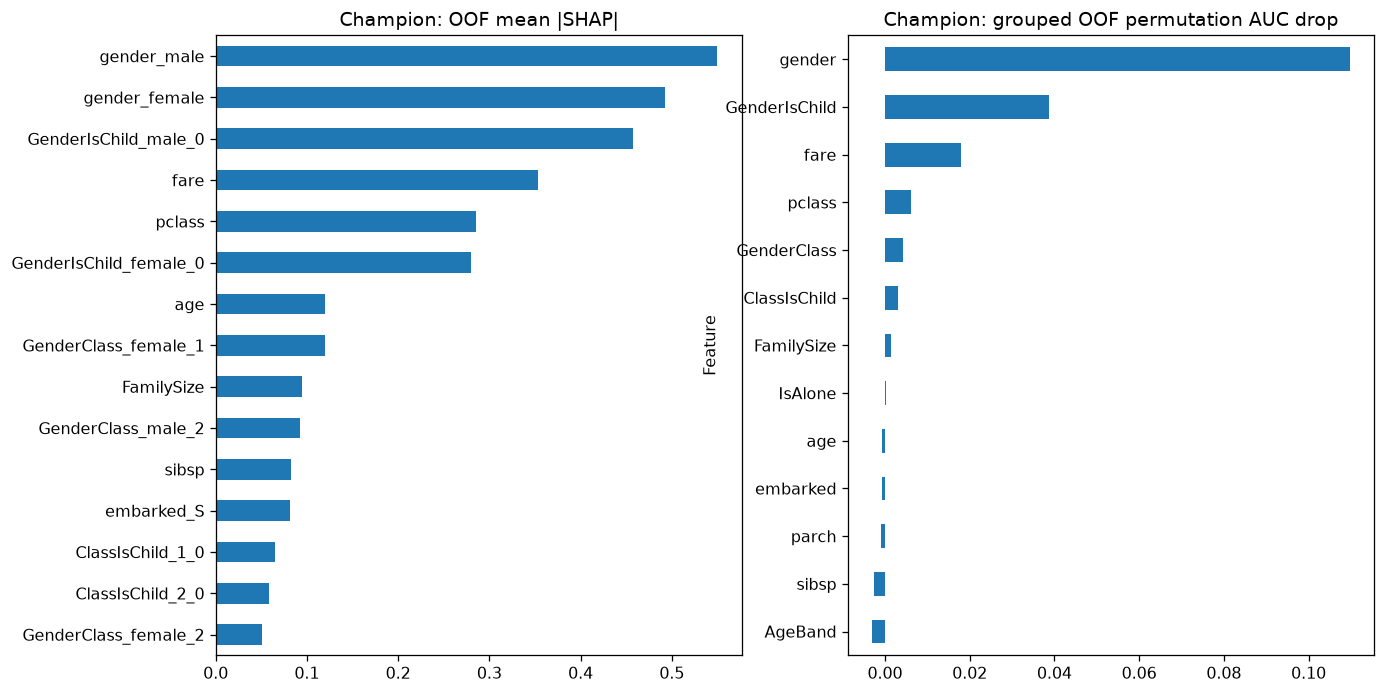

,Model,CV Mean,CV Std,OOF AUC,Train AUC,Train-CV Gap,Feature Count
0,A: historical Private champion 15,0.906275,0.016868,0.904247,0.965376,0.059101,33
1,28: fixed deployment recipe,0.908135,0.013804,0.904607,0.922685,0.014550,32


In [4]:
candidate_a=evaluate('A: historical Private champion 15',BASE_SPEC,{},explain=True)
assert candidate_a['summary']['Feature Count']==33
np.testing.assert_allclose(candidate_a['summary']['CV Mean'],.9062745632196434,atol=1e-12,rtol=0)
np.testing.assert_allclose(candidate_a['summary']['OOF AUC'],.9042465267214278,atol=1e-12,rtol=0)
display(candidate_a['folds'])
display(pd.DataFrame([candidate_a['summary']]))
display(pd.DataFrame({'CatBoost importance':candidate_a['importance'],'OOF mean abs SHAP':candidate_a['shap']}))
display(candidate_a['permutation'])
fig,axes=plt.subplots(1,2,figsize=(13,7))
candidate_a['shap'].head(15).sort_values().plot.barh(ax=axes[0],title='Champion: OOF mean |SHAP|')
candidate_a['permutation']['mean'].sort_values().plot.barh(ax=axes[1],title='Champion: grouped OOF permutation AUC drop')
show_figure(fig)
# Fixed 20-tree deployment recipe, not the optimistic fold-selected iterations from experiment 28.
reference_28=evaluate('28: fixed deployment recipe',{'drop':['age'],'add':[]},
                      {'iterations':20,'learning_rate':.03,'loss_function':'Logloss','eval_metric':'AUC'})
display(pd.DataFrame([candidate_a['summary'],reference_28['summary']]))
# Historical 15 prediction reproduction is checked again at final deployment.

# 5. EDA, 상관관계, OOF FP/FN 분석

Exact family identity verified: True
Fare/LogFare Spearman: 1.0
Threshold .5 is diagnostic only; no threshold optimization.


,age,AgeBandOrdinal,fare,LogFare,sibsp,parch,FamilySize,IsAlone,TicketGroupSize,FarePerPerson,NonFamilyGroupSize,NonFamilyGroupRatio,FamilyFarePerPerson
age,1.000,0.906,0.161,0.176,-0.217,-0.155,-0.227,0.128,-0.190,0.281,0.085,0.044,0.188
AgeBandOrdinal,0.906,1.000,0.141,0.112,-0.283,-0.207,-0.298,0.202,-0.242,0.260,0.121,0.068,0.198
fare,0.161,0.141,1.000,0.791,0.162,0.182,0.205,-0.255,0.371,0.838,0.152,0.106,0.845
LogFare,0.176,0.112,0.791,1.000,0.315,0.288,0.363,-0.457,0.483,0.736,0.069,0.024,0.621
sibsp,-0.217,-0.283,0.162,0.315,1.000,0.386,0.873,-0.607,0.585,0.010,-0.494,-0.369,-0.090
parch,-0.155,-0.207,0.182,0.288,0.386,1.000,0.788,-0.545,0.554,0.009,-0.416,-0.301,-0.080
FamilySize,-0.227,-0.298,0.205,0.363,0.873,0.788,1.000,-0.694,0.684,0.011,-0.550,-0.406,-0.102
IsAlone,0.128,0.202,-0.255,-0.457,-0.607,-0.545,-0.694,1.000,-0.438,-0.175,0.424,0.475,0.054
TicketGroupSize,-0.190,-0.242,0.371,0.483,0.585,0.554,0.684,-0.438,1.000,0.022,0.233,0.201,0.195
FarePerPerson,0.281,0.260,0.838,0.736,0.010,0.009,0.011,-0.175,0.022,1.000,0.010,-0.051,0.760


,age,AgeBandOrdinal,fare,LogFare,sibsp,parch,FamilySize,IsAlone,TicketGroupSize,FarePerPerson,NonFamilyGroupSize,NonFamilyGroupRatio,FamilyFarePerPerson
age,1.000,0.908,0.200,0.200,-0.127,-0.227,-0.170,0.117,-0.122,0.389,0.130,0.117,0.393
AgeBandOrdinal,0.908,1.000,0.171,0.171,-0.148,-0.236,-0.184,0.128,-0.139,0.368,0.126,0.111,0.373
fare,0.200,0.171,1.000,1.000,0.446,0.360,0.501,-0.511,0.616,0.740,-0.000,0.014,0.667
LogFare,0.200,0.171,1.000,1.000,0.446,0.360,0.501,-0.511,0.616,0.740,-0.000,0.014,0.667
sibsp,-0.127,-0.148,0.446,0.446,1.000,0.454,0.865,-0.848,0.528,0.105,-0.500,-0.492,-0.168
parch,-0.227,-0.236,0.360,0.360,0.454,1.000,0.786,-0.669,0.557,-0.076,-0.459,-0.424,-0.267
FamilySize,-0.170,-0.184,0.501,0.501,0.865,0.786,1.000,-0.965,0.632,0.070,-0.559,-0.547,-0.215
IsAlone,0.117,0.128,-0.511,-0.511,-0.848,-0.669,-0.965,1.000,-0.580,-0.151,0.517,0.524,0.126
TicketGroupSize,-0.122,-0.139,0.616,0.616,0.528,0.557,0.632,-0.580,1.000,0.012,0.173,0.219,0.098
FarePerPerson,0.389,0.368,0.740,0.740,0.105,-0.076,0.070,-0.151,0.012,1.000,-0.031,-0.052,0.834


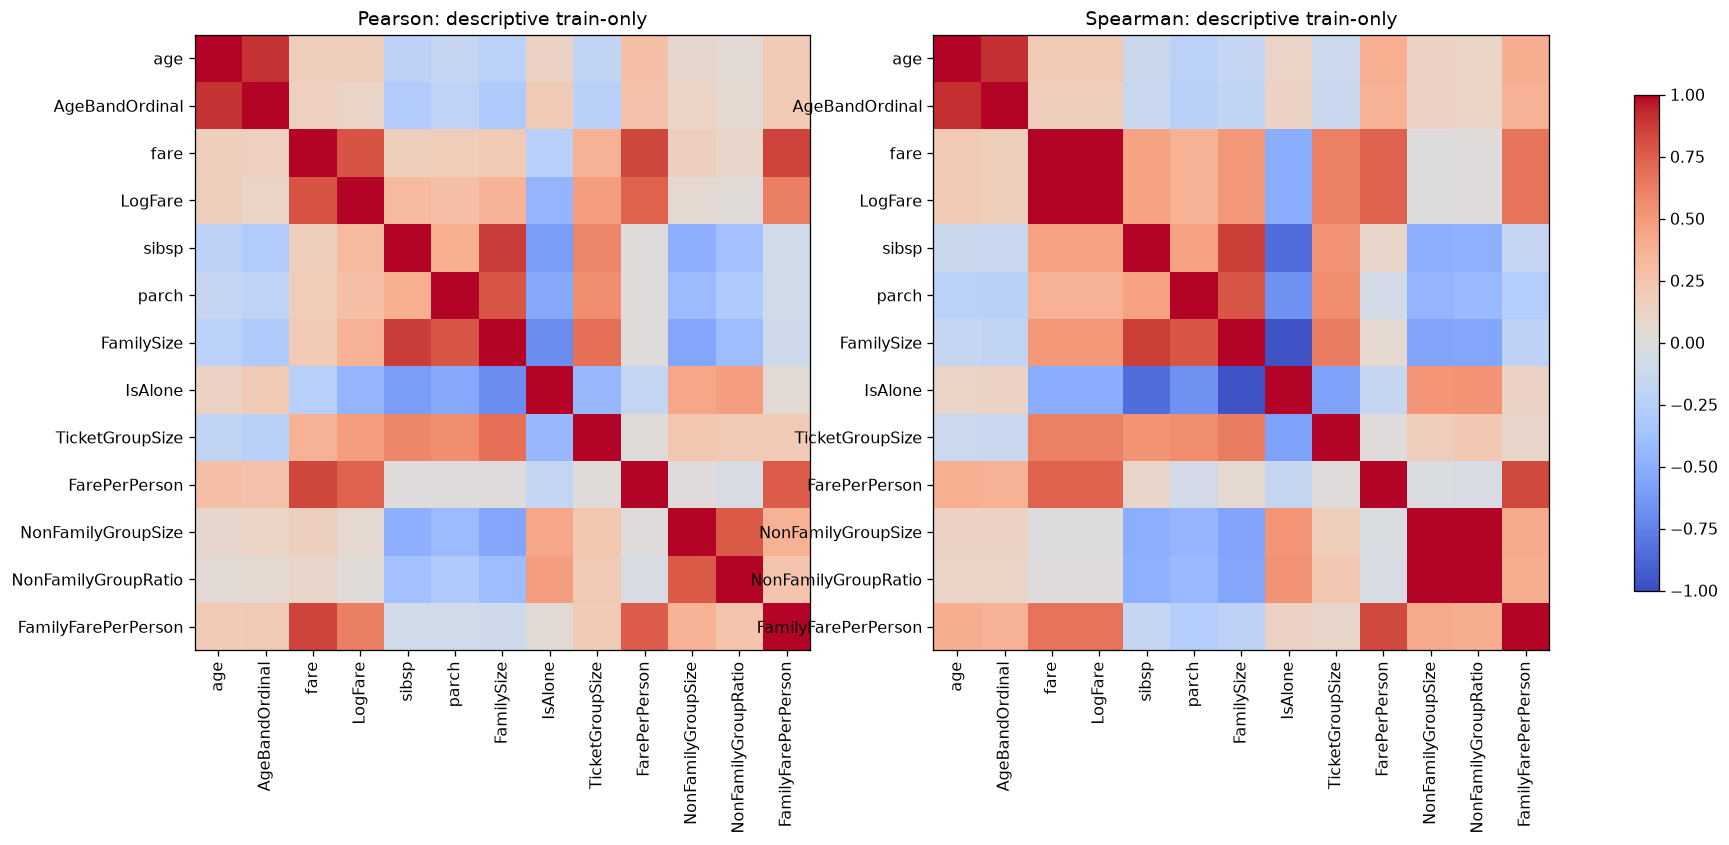

,gender,pclass,GenderClass,GenderIsChild,ClassIsChild,AgeBand
gender,1.000000,0.116144,1.000000,1.000000,0.161557,0.109819
pclass,0.116144,1.000000,1.000000,0.140746,1.000000,0.345829
GenderClass,1.000000,1.000000,1.000000,0.594211,0.638101,0.257953
GenderIsChild,1.000000,0.140746,0.594211,1.000000,0.586276,0.578755
ClassIsChild,0.161557,1.000000,0.638101,0.586276,1.000000,0.554630
AgeBand,0.109819,0.345829,0.257953,0.578755,0.554630,1.000000


n  survival_rate  FP  FN
gender pclass                            
female 1       101       0.990099   1   0
       2        72       0.930556   5   0
       3       154       0.688312  32  14
male   1       126       0.246032   1  28
       2       122       0.073770   1   7
       3       341       0.096774   1  33

n  survival_rate  FP  FN
gender AgeBand                               
female Adult        83       0.855422   7   3
       Child        39       0.692308   4   3
       Senior        8       1.000000   0   1
       Teen         34       0.882353   4   0
       YoungAdult  163       0.840491  23   7
male   Adult       154       0.142857   0  21
       Child        40       0.275000   3   7
       Senior       19       0.105263   0   2
       Teen         43       0.046512   0   2
       YoungAdult  333       0.108108   0  36

,n,survival_rate,FP,FN
FamilySize,,,,
1,558,0.304659,17,48
2,163,0.539877,10,14
3,109,0.522936,10,10
4,26,0.653846,2,3
5,19,0.263158,1,1
6,19,0.157895,0,0
7,9,0.333333,0,3
8,6,0.166667,0,1
11,7,0.285714,1,2


,n,survival_rate,FP,FN
TicketGroupSize,,,,
1,571,0.311734,21,50
2,172,0.529070,7,11
3,84,0.607143,8,8
4,36,0.305556,2,6
5,20,0.350000,2,0
6,12,0.083333,0,1
7,21,0.333333,1,6


,passengerid,gender,age,pclass,fare,FamilySize,ticket,TicketGroupSize,survived,OOF probability
669,669,female,25.00,1,151.5500,4,113781,4,0,0.995305
281,281,male,2.00,2,23.0000,3,29103,3,0,0.960646
641,641,female,57.00,2,10.5000,1,S.O./P.P. 3,2,0,0.943160
340,340,female,27.00,2,21.0000,2,11668,2,0,0.942164
225,225,female,18.00,3,6.7500,1,365226,1,0,0.939210
348,348,female,24.00,2,13.0000,1,248747,1,0,0.938077
586,586,female,38.00,2,13.0000,1,237671,1,0,0.937683
347,347,female,9.00,3,15.2458,3,2678,3,0,0.936074
17,17,female,44.00,2,26.0000,2,244252,2,0,0.932655
549,549,female,2.00,3,10.4625,2,347054,2,0,0.917346


,passengerid,gender,age,pclass,fare,FamilySize,ticket,TicketGroupSize,survived,OOF probability
224,224,male,62.00,2,10.5000,1,S.W./PP 752,1,1,0.018706
187,187,male,25.00,3,0.0000,1,LINE,4,1,0.027688
311,311,male,NaN,3,7.7500,1,367228,1,1,0.029550
766,766,male,31.00,2,13.0000,1,244270,1,1,0.032798
495,495,male,NaN,2,13.8625,1,SC/PARIS 2146,1,1,0.038054
89,89,male,32.00,2,26.0000,2,2908,2,1,0.039144
887,887,male,45.00,3,8.0500,1,7598,1,1,0.040279
118,118,male,44.00,3,7.9250,1,STON/O 2. 3101269,1,1,0.041438
800,800,male,80.00,1,30.0000,1,27042,1,1,0.053016
542,542,male,18.00,3,8.0500,1,A/5 3540,1,1,0.058038


In [5]:
# Full train is used for DESCRIPTIVE correlations only, never as preprocessing for CV.
corr_prep=FinalPreprocessor()
corr_prep.fit_transform(X)
clean=corr_prep.transform_missing(X)
d=corr_prep.make_features(clean).copy()
d['AgeBandOrdinal']=pd.cut(d.age,[0,16,20,35,60,np.inf],right=False,labels=False)
d['LogFare']=np.log1p(d.fare)
d['TicketGroupSize']=X.ticket.map(X.ticket.value_counts()).fillna(1)
d['FarePerPerson']=d.fare/d.TicketGroupSize
d['NonFamilyGroupSize']=d.TicketGroupSize-d.FamilySize
d['NonFamilyGroupRatio']=d.NonFamilyGroupSize/d.TicketGroupSize
d['FamilyFarePerPerson']=d.fare/d.FamilySize
numeric=['age','AgeBandOrdinal','fare','LogFare','sibsp','parch','FamilySize','IsAlone',
         'TicketGroupSize','FarePerPerson','NonFamilyGroupSize','NonFamilyGroupRatio','FamilyFarePerPerson']
pearson=d[numeric].corr(method='pearson')
spearman=d[numeric].corr(method='spearman')
display(pearson.round(3));display(spearman.round(3))
fig,axes=plt.subplots(1,2,figsize=(19,8))
for ax,mat,title in zip(axes,[pearson,spearman],['Pearson: descriptive train-only','Spearman: descriptive train-only']):
    im=ax.imshow(mat,vmin=-1,vmax=1,cmap='coolwarm')
    ax.set_xticks(range(len(mat)),mat.columns,rotation=90)
    ax.set_yticks(range(len(mat)),mat.index)
    ax.set_title(title)
fig.colorbar(im,ax=axes.ravel().tolist(),shrink=.7)
show_figure(fig)
semantic=corr_prep.feature_frame(X,clean)
cats=['gender','pclass','GenderClass','GenderIsChild','ClassIsChild','AgeBand']
def cramers_v(a,b):
    ct=pd.crosstab(a,b)
    chi=chi2_contingency(ct,correction=False)[0]
    return np.sqrt(chi/(ct.to_numpy().sum()*min(ct.shape[0]-1,ct.shape[1]-1)))
categorical_corr=pd.DataFrame([[cramers_v(semantic[a],semantic[b]) for b in cats] for a in cats],index=cats,columns=cats)
display(categorical_corr)
print('Exact family identity verified:',np.array_equal(d.FamilySize,d.sibsp+d.parch+1))
print('Fare/LogFare Spearman:',spearman.loc['fare','LogFare'])
errors=train.copy()
errors['OOF probability']=candidate_a['oof']
errors['FP']=(y==0)&(candidate_a['oof']>=.5)
errors['FN']=(y==1)&(candidate_a['oof']<.5)
errors['FamilySize']=d.FamilySize
errors['AgeBand']=semantic.AgeBand
errors['TicketGroupSize']=d.TicketGroupSize
print('Threshold .5 is diagnostic only; no threshold optimization.')
for group in [['gender','pclass'],['gender','AgeBand'],['FamilySize'],['TicketGroupSize']]:
    display(errors.groupby(group,dropna=False).agg(n=(target_col,'size'),survival_rate=(target_col,'mean'),
                                                  FP=('FP','sum'),FN=('FN','sum')))
error_columns=[id_col,'gender','age','pclass','fare','FamilySize','ticket','TicketGroupSize',target_col,'OOF probability']
display(errors.loc[errors.FP,error_columns].sort_values('OOF probability',ascending=False))
display(errors.loc[errors.FN,error_columns].sort_values('OOF probability'))

# 6-3. Noise/중복 Feature 단일 제거

In [6]:
# Every semantic input is removed independently; derived children remain unless named.
semantic_features=semantic.columns.tolist()
ablations=[]
for feature in semantic_features:
    spec={'drop':[feature],'add':[]}
    ablations.append(evaluate('drop '+feature,spec,{}))
ablation_table=pd.DataFrame([r['summary'] for r in ablations])
ablation_table['CV delta']=ablation_table['CV Mean']-candidate_a['summary']['CV Mean']
ablation_table['OOF delta']=ablation_table['OOF AUC']-candidate_a['summary']['OOF AUC']
display(ablation_table.sort_values('CV Mean',ascending=False))
display(pd.DataFrame({r['label']:r['folds'].auc.to_numpy() for r in [candidate_a]+ablations},index=range(1,6)).T)
# Select a simpler candidate from near-best ablations, with OOF and stability guardrails.
eligible=[r for r in ablations if r['summary']['CV Mean']>=candidate_a['summary']['CV Mean']-.0005
          and r['summary']['OOF AUC']>=candidate_a['summary']['OOF AUC']-.0005
          and r['summary']['CV Std']<=candidate_a['summary']['CV Std']+.003]
if eligible:
    best_mean=max(r['summary']['CV Mean'] for r in eligible)
    near=[r for r in eligible if r['summary']['CV Mean']>=best_mean-.0005]
    candidate_b=min(near,key=lambda r:(r['summary']['Feature Count'],-r['summary']['OOF AUC']))
else:
    candidate_b=max(ablations,key=lambda r:r['summary']['CV Mean'])
candidate_b=candidate_b.copy()
candidate_b['label']='B: noise-removal candidate'
candidate_b['summary']=candidate_b['summary']|{'Model':candidate_b['label']}
# Feature selection requires actual AUC improvement, or near-equivalence with a smaller input.
feature_base=candidate_b if eligible else candidate_a
print('Noise-removal model:',candidate_b['spec'],'accepted for next stage:',bool(eligible))
print('Marginal permutation may understate importance when interactions encode the same information.')

drop pclass {'Model': 'drop pclass', 'CV Mean': 0.9057173731430025, 'CV Std': 0.019148938264152725, 'OOF AUC': 0.9033845451779738, 'Train AUC': 0.9652903100076096, 'Train-CV Gap': 0.05957293686460698, 'Feature Count': 32}
drop gender {'Model': 'drop gender', 'CV Mean': 0.9058452290145655, 'CV Std': 0.018213861201935647, 'OOF AUC': 0.9034910252509888, 'Train AUC': 0.9647225733197116, 'Train-CV Gap': 0.05887734430514617, 'Feature Count': 31}
drop age {'Model': 'drop age', 'CV Mean': 0.9075184337655735, 'CV Std': 0.013868055749294898, 'OOF AUC': 0.90564344386979, 'Train AUC': 0.9587961681724849, 'Train-CV Gap': 0.05127773440691141, 'Feature Count': 32}
drop sibsp {'Model': 'drop sibsp', 'CV Mean': 0.906485234826196, 'CV Std': 0.020000540491612286, 'OOF AUC': 0.9038510293073725, 'Train AUC': 0.9648149429386264, 'Train-CV Gap': 0.05832970811243032, 'Feature Count': 32}
drop parch {'Model': 'drop parch', 'CV Mean': 0.9080986887508626, 'CV Std': 0.01782330961911054, 'OOF AUC': 0.9045507555014

,Model,CV Mean,CV Std,OOF AUC,Train AUC,Train-CV Gap,Feature Count,CV delta,OOF delta
4,drop parch,0.908099,0.017823,0.904551,0.965532,0.057433,32,0.001824,0.000304
2,drop age,0.907518,0.013868,0.905643,0.958796,0.051278,32,0.001244,0.001397
3,drop sibsp,0.906485,0.020001,0.903851,0.964815,0.058330,32,0.000211,-0.000395
12,drop AgeBand,0.906233,0.018564,0.904389,0.964405,0.058172,28,-0.000042,0.000142
7,drop FamilySize,0.906103,0.017031,0.903476,0.965022,0.058918,32,-0.000171,-0.000771
6,drop embarked,0.905866,0.021729,0.904652,0.963916,0.058050,30,-0.000408,0.000406
1,drop gender,0.905845,0.018214,0.903491,0.964723,0.058877,31,-0.000429,-0.000756
0,drop pclass,0.905717,0.019149,0.903385,0.965290,0.059573,32,-0.000557,-0.000862
8,drop IsAlone,0.905642,0.016868,0.903810,0.965270,0.059628,32,-0.000633,-0.000436
10,drop GenderIsChild,0.904785,0.018387,0.902523,0.965300,0.060515,29,-0.001490,-0.001724


,1,2,3,4,5
A: historical Private champion 15,0.901065,0.923786,0.879799,0.912154,0.914569
drop pclass,0.900313,0.925693,0.875858,0.909484,0.917239
drop gender,0.900063,0.923277,0.876875,0.914061,0.914950
drop age,0.906140,0.924358,0.886728,0.905861,0.914505
drop sibsp,0.898559,0.927218,0.875731,0.914950,0.915967
drop parch,0.903321,0.928235,0.880435,0.913425,0.915078
drop fare,0.896491,0.921943,0.867722,0.901983,0.910628
drop embarked,0.901566,0.925311,0.870137,0.914823,0.917493
drop FamilySize,0.898684,0.922896,0.880053,0.912789,0.916095
drop IsAlone,0.900063,0.922387,0.879163,0.911264,0.915332


# 6-4. 가설 기반 새 Feature 검증

In [7]:
display(Markdown("""### 새 피처 가설 (평가 전에 선언)
**가설:** Private champion의 OOF 오류는 3등급 여성 FP와 남성 FN에 집중되어 있으며,
가족 규모 2~3명에서도 오류가 남는다. 원본 운임만으로는 가족 단위 지출과 어린이 동반 조건을
쉽게 구분하지 못할 수 있다.

**새로운 Feature:** FamilyFarePerPerson = fare / (sibsp + parch + 1);
ChildFamilySize = (imputed age < 16) × FamilySize. 각각 독립적으로 검증한다.

**근거:** 과거 6/7/22~25의 Ticket 빈도 분모는 fold에서 관측된 동행자 수에 따라 달라졌고,
NonFamilyGroupSize에는 음수도 발생했다. 이번 분모는 각 행의 가족 정보로 계산하여
다른 승객의 포함 여부에 영향을 받지 않는다. 과거 10/11은 어린이 상호작용에 근거를 제공한다.

**기대 효과:** 가족 단위 운임/어린이 동행 조건의 저차원 표현으로 순위를 개선할 가능성.
가족들이 같은 티켓이나 운임을 공유한다는 사실은 보장되지 않으므로 가설일 뿐이다.
CV/OOF 및 3개 이상 fold 개선 기준을 통과하지 못하면 추가하지 않는다."""))
new_results=[]
for feature in ['FamilyFarePerPerson','ChildFamilySize']:
    spec=copy.deepcopy(feature_base['spec']);spec['add']=[feature]
    new_results.append(evaluate('new '+feature,spec,{}))
display(pd.DataFrame([feature_base['summary']]+[r['summary'] for r in new_results]))
accepted_new=[r for r in new_results if stable_improvement(r,feature_base)]
candidate_d=max(accepted_new,key=lambda r:r['summary']['CV Mean']) if accepted_new else None
feature_winner=candidate_d if candidate_d is not None else feature_base
FINAL_SPEC=copy.deepcopy(feature_winner['spec'])
print('Feature set frozen before tuning:',FINAL_SPEC)
print('New feature accepted:',candidate_d is not None)

new FamilyFarePerPerson {'Model': 'new FamilyFarePerPerson', 'CV Mean': 0.9064485489085031, 'CV Std': 0.01683793474142298, 'OOF AUC': 0.9045406145421355, 'Train AUC': 0.9684073242607907, 'Train-CV Gap': 0.06195877535228753, 'Feature Count': 33}
new ChildFamilySize {'Model': 'new ChildFamilySize', 'CV Mean': 0.9065317278704006, 'CV Std': 0.01747130051957155, 'OOF AUC': 0.9037394787546902, 'Train AUC': 0.9649945878207264, 'Train-CV Gap': 0.05846285995032576, 'Feature Count': 33}
Feature set frozen before tuning: {'drop': ['parch'], 'add': []}
New feature accepted: False


### 새 피처 가설 (평가 전에 선언)
**가설:** Private champion의 OOF 오류는 3등급 여성 FP와 남성 FN에 집중되어 있으며,
가족 규모 2~3명에서도 오류가 남는다. 원본 운임만으로는 가족 단위 지출과 어린이 동반 조건을
쉽게 구분하지 못할 수 있다.

**새로운 Feature:** FamilyFarePerPerson = fare / (sibsp + parch + 1);
ChildFamilySize = (imputed age < 16) × FamilySize. 각각 독립적으로 검증한다.

**근거:** 과거 6/7/22~25의 Ticket 빈도 분모는 fold에서 관측된 동행자 수에 따라 달라졌고,
NonFamilyGroupSize에는 음수도 발생했다. 이번 분모는 각 행의 가족 정보로 계산하여
다른 승객의 포함 여부에 영향을 받지 않는다. 과거 10/11은 어린이 상호작용에 근거를 제공한다.

**기대 효과:** 가족 단위 운임/어린이 동행 조건의 저차원 표현으로 순위를 개선할 가능성.
가족들이 같은 티켓이나 운임을 공유한다는 사실은 보장되지 않으므로 가설일 뿐이다.
CV/OOF 및 3개 이상 fold 개선 기준을 통과하지 못하면 추가하지 않는다.

,Model,CV Mean,CV Std,OOF AUC,Train AUC,Train-CV Gap,Feature Count
0,B: noise-removal candidate,0.908099,0.017823,0.904551,0.965532,0.057433,32
1,new FamilyFarePerPerson,0.906449,0.016838,0.904541,0.968407,0.061959,33
2,new ChildFamilySize,0.906532,0.017471,0.903739,0.964995,0.058463,33


# 7-2. 확정 Feature Set의 Hyperparameter Tuning

[CatBoost 문서](https://catboost.ai/docs/en/references/training-parameters/common)에 맞춰 Bayesian bagging과 Depthwise min_data_in_leaf 조건을 분리한다. 평가 fold에 early stopping을 적용하지 않는다. 파라미터 탐색으로 인한 CV 선택 낙관성은 남는다.

In [8]:
# 16 predefined, modest recipes. No seed hunting, no outer-validation early stopping.
# min_data_in_leaf is meaningful for Depthwise here, not SymmetricTree.
TUNING=[
 {'iterations':300,'learning_rate':.01,'depth':5,'l2_leaf_reg':3},
 {'iterations':600,'learning_rate':.01,'depth':5,'l2_leaf_reg':3},
 {'iterations':1000,'learning_rate':.01,'depth':5,'l2_leaf_reg':3},
 {'iterations':600,'learning_rate':.01,'depth':4,'l2_leaf_reg':10},
 {'iterations':1000,'learning_rate':.007,'depth':4,'l2_leaf_reg':3},
 {'iterations':300,'learning_rate':.03,'depth':4,'l2_leaf_reg':10},
 {'iterations':600,'learning_rate':.01,'depth':6,'l2_leaf_reg':10,'random_strength':.2},
 {'iterations':1000,'learning_rate':.005,'depth':6,'l2_leaf_reg':3},
 {'iterations':600,'learning_rate':.015,'depth':5,'l2_leaf_reg':10,'random_strength':.2,'rsm':.8},
 {'iterations':600,'learning_rate':.01,'depth':5,'l2_leaf_reg':3,'border_count':64},
 {'iterations':600,'learning_rate':.01,'depth':5,'l2_leaf_reg':3,'border_count':128},
 {'iterations':600,'learning_rate':.01,'depth':5,'l2_leaf_reg':10,'bootstrap_type':'Bayesian','bagging_temperature':0},
 {'iterations':600,'learning_rate':.01,'depth':5,'l2_leaf_reg':10,'bootstrap_type':'Bayesian','bagging_temperature':1},
 {'iterations':600,'learning_rate':.01,'depth':5,'l2_leaf_reg':10,'grow_policy':'Depthwise','min_data_in_leaf':10},
 {'iterations':600,'learning_rate':.01,'depth':6,'l2_leaf_reg':20,'grow_policy':'Depthwise','min_data_in_leaf':20},
 {'iterations':817,'learning_rate':.006971115660907851,'depth':4,'l2_leaf_reg':1.9452208847287389,
  'random_strength':.3746261155838959,'subsample':.9328729111737557,'border_count':128},
]
assert len(TUNING)==16
display(pd.DataFrame(TUNING))
tuned=[evaluate(f'tune {i+1:02d}',FINAL_SPEC,p) for i,p in enumerate(TUNING)]
tune_table=pd.DataFrame([r['summary']|{'Parameter':str(r['params'])} for r in tuned]).sort_values('CV Mean',ascending=False)
display(tune_table)
pool=[r for r in tuned if r['summary']['CV Std']<=feature_winner['summary']['CV Std']+.003
      and r['summary']['OOF AUC']>=feature_winner['summary']['OOF AUC']-.0005
      and r['summary']['Train-CV Gap']<=feature_winner['summary']['Train-CV Gap']+.005]
if not pool:pool=tuned
max_cv=max(r['summary']['CV Mean'] for r in pool)
near=[r for r in pool if r['summary']['CV Mean']>=max_cv-.0005]
candidate_c=min(near,key=lambda r:(r['summary']['Train-CV Gap'],r['summary']['CV Std'],-r['summary']['OOF AUC']))
candidate_c=candidate_c.copy()
candidate_c['label']='C: selected features + tuning'
candidate_c['summary']=candidate_c['summary']|{'Model':candidate_c['label']}
print('Selected tuned parameters:',candidate_c['params'])

tune 01 {'Model': 'tune 01', 'CV Mean': 0.9077679706512658, 'CV Std': 0.015017494246546385, 'OOF AUC': 0.905709360105466, 'Train AUC': 0.9372444446280248, 'Train-CV Gap': 0.02947647397675903, 'Feature Count': 32}
tune 02 {'Model': 'tune 02', 'CV Mean': 0.9075658348770477, 'CV Std': 0.01786401159027315, 'OOF AUC': 0.9056941486664638, 'Train AUC': 0.9487885186072489, 'Train-CV Gap': 0.04122268373020135, 'Feature Count': 32}
tune 03 {'Model': 'tune 03', 'CV Mean': 0.9059411209182375, 'CV Std': 0.01837199681973559, 'OOF AUC': 0.9041425818882466, 'Train AUC': 0.9615814497985664, 'Train-CV Gap': 0.05564032888032879, 'Feature Count': 32}
tune 04 {'Model': 'tune 04', 'CV Mean': 0.9100490356325597, 'CV Std': 0.016110570320343166, 'OOF AUC': 0.9065890883277556, 'Train AUC': 0.9350219458878453, 'Train-CV Gap': 0.024972910255285606, 'Feature Count': 32}
tune 05 {'Model': 'tune 05', 'CV Mean': 0.9094869419926628, 'CV Std': 0.016208957719822042, 'OOF AUC': 0.9067716255957814, 'Train AUC': 0.94450592

,iterations,learning_rate,depth,l2_leaf_reg,random_strength,rsm,border_count,bootstrap_type,bagging_temperature,grow_policy,min_data_in_leaf,subsample
0,300,0.010000,5,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,600,0.010000,5,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1000,0.010000,5,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,600,0.010000,4,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1000,0.007000,4,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,300,0.030000,4,10.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,600,0.010000,6,10.000000,0.200000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1000,0.005000,6,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,600,0.015000,5,10.000000,0.200000,0.8,NaN,NaN,NaN,NaN,NaN,NaN
9,600,0.010000,5,3.000000,NaN,NaN,64.0,NaN,NaN,NaN,NaN,NaN


,Model,CV Mean,CV Std,OOF AUC,Train AUC,Train-CV Gap,Feature Count,Parameter
3,tune 04,0.910049,0.016111,0.906589,0.935022,0.024973,32,"{'iterations': 600, 'learning_rate': 0.01, 'depth': 4, 'l2_leaf_reg': 10}"
4,tune 05,0.909487,0.016209,0.906772,0.944506,0.035019,32,"{'iterations': 1000, 'learning_rate': 0.007, 'depth': 4, 'l2_leaf_reg': 3}"
5,tune 06,0.909475,0.015828,0.906396,0.940704,0.031229,32,"{'iterations': 300, 'learning_rate': 0.03, 'depth': 4, 'l2_leaf_reg': 10}"
13,tune 14,0.909229,0.015200,0.906214,0.950715,0.041486,32,"{'iterations': 600, 'learning_rate': 0.01, 'depth': 5, 'l2_leaf_reg': 10, 'grow_policy': 'Depthwise', 'min_data_in_leaf': 10}"
7,tune 08,0.908916,0.015448,0.906701,0.952438,0.043522,32,"{'iterations': 1000, 'learning_rate': 0.005, 'depth': 6, 'l2_leaf_reg': 3}"
15,tune 16,0.908448,0.018992,0.906711,0.949650,0.041202,32,"{'iterations': 817, 'learning_rate': 0.006971115660907851, 'depth': 4, 'l2_leaf_reg': 1.9452208847287389, 'random_strength': 0.3746261155838959, 'subsample'..."
12,tune 13,0.908339,0.015078,0.905359,0.942617,0.034278,32,"{'iterations': 600, 'learning_rate': 0.01, 'depth': 5, 'l2_leaf_reg': 10, 'bootstrap_type': 'Bayesian', 'bagging_temperature': 1}"
11,tune 12,0.908264,0.015176,0.905405,0.941275,0.033011,32,"{'iterations': 600, 'learning_rate': 0.01, 'depth': 5, 'l2_leaf_reg': 10, 'bootstrap_type': 'Bayesian', 'bagging_temperature': 0}"
14,tune 15,0.907949,0.014831,0.905202,0.949181,0.041232,32,"{'iterations': 600, 'learning_rate': 0.01, 'depth': 6, 'l2_leaf_reg': 20, 'grow_policy': 'Depthwise', 'min_data_in_leaf': 20}"
0,tune 01,0.907768,0.015017,0.905709,0.937244,0.029476,32,"{'iterations': 300, 'learning_rate': 0.01, 'depth': 5, 'l2_leaf_reg': 3}"


# 8. Candidate A~E 비교와 최종 선정

In [9]:
singles=[candidate_a,candidate_b,candidate_c]+([candidate_d] if candidate_d is not None else [])
best_single=max(singles,key=lambda r:r['summary']['CV Mean'])
oof_correlations=pd.DataFrame({r['label']:r['oof'] for r in singles}).corr()
display(oof_correlations)
print('Prediction correlations inspected before blending.')
ensemble_trials=[]
correlation=float(np.corrcoef(candidate_a['oof'],best_single['oof'])[0,1])
def blend_result(label,left,right,weight_right):
    p=(1-weight_right)*left['oof']+weight_right*right['oof']
    rows=[]
    for f,(tr,va) in enumerate(SPLITS):
        pt=(1-weight_right)*left['train_p'][f]+weight_right*right['train_p'][f]
        ta,auc=roc_auc_score(y.iloc[tr],pt),roc_auc_score(y.iloc[va],p[va])
        rows.append({'fold':f+1,'train_auc':ta,'auc':auc,'gap':ta-auc})
    folds=pd.DataFrame(rows)
    return dict(label=label,oof=p,folds=folds,left=left,right=right,weight=weight_right,
                summary={'Model':label,'CV Mean':float(folds.auc.mean()),'CV Std':float(folds.auc.std(ddof=1)),
                         'OOF AUC':float(roc_auc_score(y,p)),'Train AUC':float(folds.train_auc.mean()),
                         'Train-CV Gap':float(folds.gap.mean()),
                         'Feature Count':max(left['summary']['Feature Count'],right['summary']['Feature Count'])})
if best_single is not candidate_a and correlation<.995:
    for w in [.25,.5,.75]:
        ensemble_trials.append(blend_result(f'E: champion/new weights {1-w}/{w}',candidate_a,best_single,w))
display(pd.DataFrame([r['summary'] for r in ensemble_trials]))
candidate_e=max(ensemble_trials,key=lambda r:r['summary']['CV Mean']) if ensemble_trials else None
candidate_rows=[r['summary'] for r in singles]+([candidate_e['summary']] if candidate_e else [])
if candidate_d is None:
    candidate_rows.append({'Model':'D: no new feature passed acceptance criteria'})
if candidate_e is None:
    candidate_rows.append({'Model':'E: diversity criterion not met; not fitted'})
candidate_table=pd.DataFrame(candidate_rows)
display(candidate_table)
display(pd.DataFrame({r['label']:r['folds'].auc.to_numpy() for r in singles+([candidate_e] if candidate_e else [])},index=range(1,6)))
improvements=[r for r in singles if r is not candidate_a and stable_improvement(r,candidate_a)]
if improvements:
    mx=max(r['summary']['CV Mean'] for r in improvements)
    near=[r for r in improvements if r['summary']['CV Mean']>=mx-.0005]
    selected=min(near,key=lambda r:(r['summary']['Feature Count'],r['summary']['Train-CV Gap'],r['summary']['CV Std']))
else:
    selected=candidate_a
if candidate_e and stable_improvement(candidate_e,selected,min_gain=.0005):
    selected=candidate_e
print('FINAL SELECTION:',selected['label'])
print('Fold delta vs champion:',(selected['folds'].auc-candidate_a['folds'].auc).tolist())
print('Improved folds:',int((selected['folds'].auc>candidate_a['folds'].auc).sum()),'/5')
# A separate group-aware stress check, not a new seed search and not an independent untouched dataset.
groups=X.ticket.fillna('').astype(str)
GROUP_SPLITS=list(StratifiedGroupKFold(5,shuffle=True,random_state=SEED).split(X,y,groups))
for tr,va in GROUP_SPLITS: assert set(groups.iloc[tr]).isdisjoint(groups.iloc[va])
group_a=evaluate('Champion: ticket-group stress CV',candidate_a['spec'],candidate_a['params'],GROUP_SPLITS,cache=False)
if 'weight' in selected:
    group_right=evaluate('New: ticket-group stress CV',selected['right']['spec'],selected['right']['params'],GROUP_SPLITS,cache=False)
    gp=(1-selected['weight'])*group_a['oof']+selected['weight']*group_right['oof']
    ga=[roc_auc_score(y.iloc[va],gp[va]) for _,va in GROUP_SPLITS]
    group_final={'CV Mean':float(np.mean(ga)),'CV Std':float(np.std(ga,ddof=1)),'OOF AUC':float(roc_auc_score(y,gp))}
elif selected is candidate_a:
    group_final=group_a['summary']
else:
    group_final=evaluate('Final: ticket-group stress CV',selected['spec'],selected['params'],GROUP_SPLITS,cache=False)['summary']
display(pd.DataFrame([group_a['summary'],dict(group_final)|{'Model':'Final group stress'}]))
print('Stress check is descriptive; final candidate is locked and no additional trials follow.')

Prediction correlations inspected before blending.
FINAL SELECTION: C: selected features + tuning
Fold delta vs champion: [-0.003947368421052699, 0.010043224002034057, 0.01347571828121008, -0.0009534706331045806, 0.0002542588354945696]
Improved folds: 3 /5
Champion: ticket-group stress CV {'Model': 'Champion: ticket-group stress CV', 'CV Mean': 0.8901893031310788, 'CV Std': 0.036584013700696236, 'OOF AUC': 0.8899908731365989, 'Train AUC': 0.9669341945837872, 'Train-CV Gap': 0.07674489145270827, 'Feature Count': 33}
Final: ticket-group stress CV {'Model': 'Final: ticket-group stress CV', 'CV Mean': 0.8985283500558167, 'CV Std': 0.03708324973906566, 'OOF AUC': 0.8966712300983672, 'Train AUC': 0.936662524537477, 'Train-CV Gap': 0.038134174481660434, 'Feature Count': 32}
Stress check is descriptive; final candidate is locked and no additional trials follow.


,A: historical Private champion 15,B: noise-removal candidate,C: selected features + tuning
A: historical Private champion 15,1.000000,0.999017,0.990931
B: noise-removal candidate,0.999017,1.000000,0.990461
C: selected features + tuning,0.990931,0.990461,1.000000


,Model,CV Mean,CV Std,OOF AUC,Train AUC,Train-CV Gap,Feature Count
0,E: champion/new weights 0.75/0.25,0.907779,0.016455,0.905286,0.961060,0.053280,33
1,E: champion/new weights 0.5/0.5,0.908553,0.016213,0.906290,0.956222,0.047669,33
2,E: champion/new weights 0.25/0.75,0.909949,0.016049,0.906488,0.949380,0.039431,33


,Model,CV Mean,CV Std,OOF AUC,Train AUC,Train-CV Gap,Feature Count
0,A: historical Private champion 15,0.906275,0.016868,0.904247,0.965376,0.059101,33.0
1,B: noise-removal candidate,0.908099,0.017823,0.904551,0.965532,0.057433,32.0
2,C: selected features + tuning,0.910049,0.016111,0.906589,0.935022,0.024973,32.0
3,E: champion/new weights 0.25/0.75,0.909949,0.016049,0.906488,0.949380,0.039431,33.0
4,D: no new feature passed acceptance criteria,NaN,NaN,NaN,NaN,NaN,NaN


,A: historical Private champion 15,B: noise-removal candidate,C: selected features + tuning,E: champion/new weights 0.25/0.75
1,0.901065,0.903321,0.897118,0.896679
2,0.923786,0.928235,0.933829,0.932939
3,0.879799,0.880435,0.893275,0.892766
4,0.912154,0.913425,0.911200,0.912535
5,0.914569,0.915078,0.914823,0.914823


,Model,CV Mean,CV Std,OOF AUC,Train AUC,Train-CV Gap,Feature Count
0,Champion: ticket-group stress CV,0.890189,0.036584,0.889991,0.966934,0.076745,33
1,Final group stress,0.898528,0.037083,0.896671,0.936663,0.038134,32


# 9~11. 최종 평가, SHAP, 전체 학습, Test 예측, Submission 검증

Previous Private best {'TN': 529, 'FP': 41, 'FN': 82, 'TP': 264}
Titanic 32 {'TN': 529, 'FP': 41, 'FN': 76, 'TP': 270}
Final OOF explanations {'Model': 'Final OOF explanations', 'CV Mean': 0.9100490356325597, 'CV Std': 0.016110570320343166, 'OOF AUC': 0.9065890883277556, 'Train AUC': 0.9350219458878453, 'Train-CV Gap': 0.024972910255285606, 'Feature Count': 32}
Holdout has been reused across historical experiments; it is a secondary development diagnostic.
Private champion CSV reproduced; max difference: 1.1102230246251565e-16
Final Feature list: ['pclass', 'age', 'sibsp', 'fare', 'FamilySize', 'IsAlone', 'gender_female', 'gender_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'GenderClass_female_1', 'GenderClass_female_2', 'GenderClass_female_3', 'GenderClass_male_1', 'GenderClass_male_2', 'GenderClass_male_3', 'GenderIsChild_female_0', 'GenderIsChild_female_1', 'GenderIsChild_male_0', 'GenderIsChild_male_1', 'ClassIsChild_1_0', 'ClassIsChild_1_1', 'ClassIsChild_2_0', 'ClassIsChild_2

,Predicted 0,Predicted 1
Actual 0,0.928070,0.071930
Actual 1,0.236994,0.763006


,Predicted 0,Predicted 1
Actual 0,0.928070,0.071930
Actual 1,0.219653,0.780347


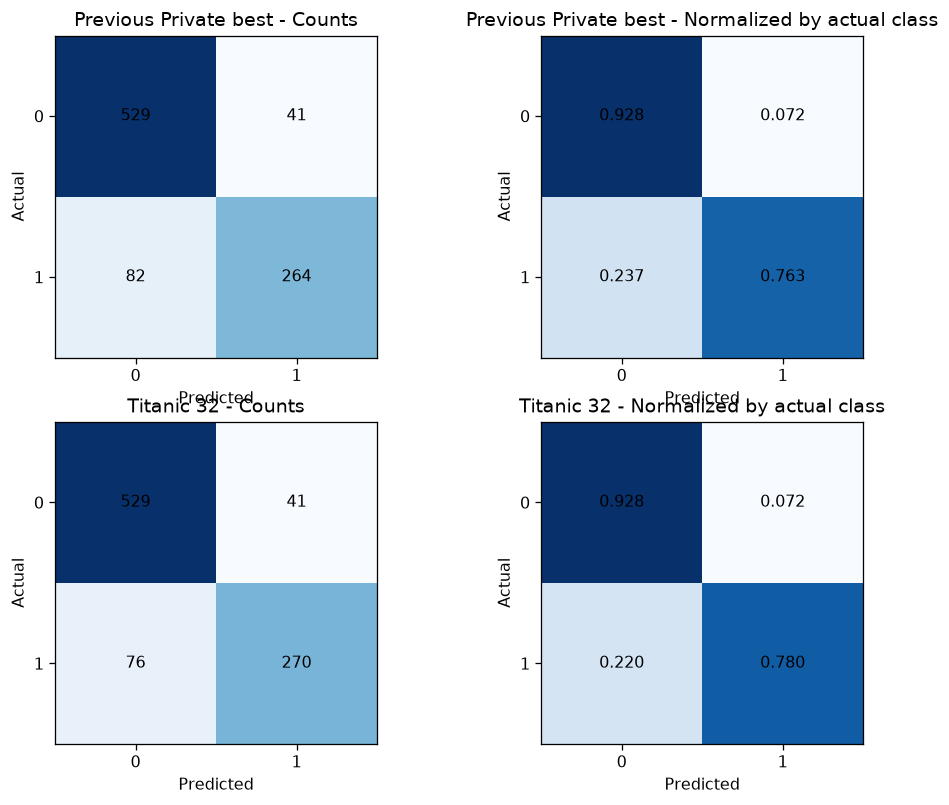

,CatBoost importance,OOF mean abs SHAP
AgeBand_Adult,0.703937,0.031134
AgeBand_Child,0.507979,0.013942
AgeBand_Senior,0.085332,0.001746
AgeBand_Teen,0.188904,0.004580
AgeBand_YoungAdult,0.445487,0.015258
ClassIsChild_1_0,1.759785,0.074709
ClassIsChild_1_1,0.019179,0.000476
ClassIsChild_2_0,1.155032,0.039242
ClassIsChild_2_1,0.522468,0.016435
ClassIsChild_3_0,0.542653,0.022232


,mean,std
Feature,,
gender,0.137964,0.023347
GenderIsChild,0.032346,0.014976
fare,0.008832,0.008860
GenderClass,0.004695,0.005784
FamilySize,0.004648,0.003095
pclass,0.003352,0.006030
ClassIsChild,0.003303,0.003790
AgeBand,0.002181,0.001616
age,0.001860,0.006186


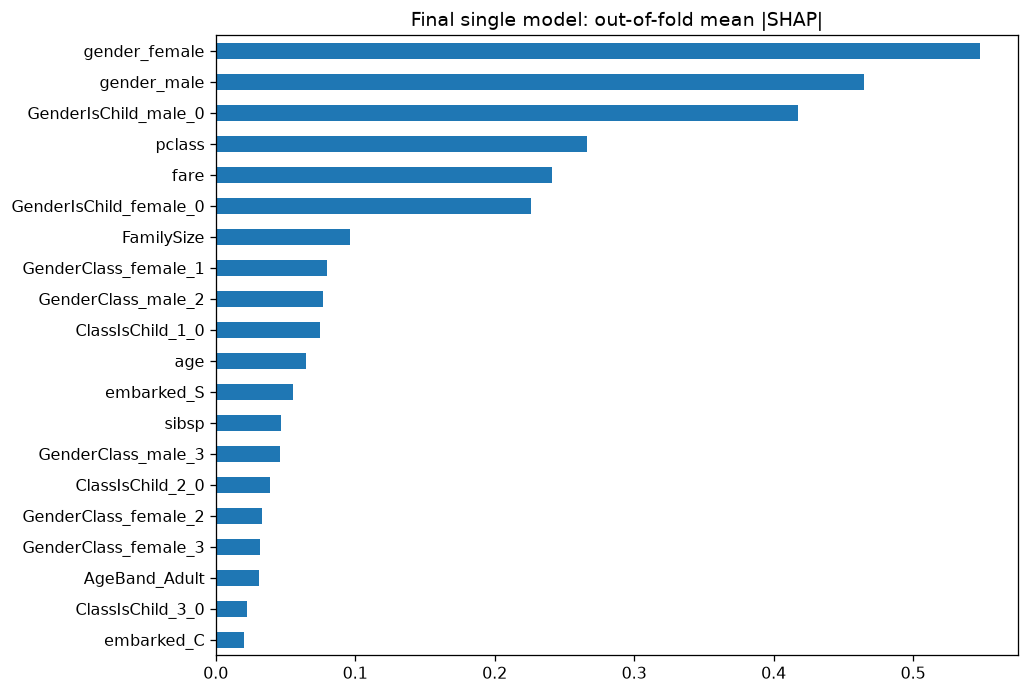

,Metric,Previous Best,Titanic_32,Difference
0,Train AUC,0.965299,0.940006,-0.025293
1,Validation AUC,0.903643,0.902667,-0.000976
2,CV Mean,0.906275,0.910049,0.003774
3,CV Std,0.016868,0.016111,-0.000757
4,OOF AUC,0.904247,0.906589,0.002343
5,Feature Count,33.000000,32.000000,-1.000000


,Fold,Previous Best,Titanic_32,Difference
0,1,0.901065,0.897118,-0.003947
1,2,0.923786,0.933829,0.010043
2,3,0.879799,0.893275,0.013476
3,4,0.912154,0.911200,-0.000953
4,5,0.914569,0.914823,0.000254


,Pearson,Spearman,Mean Absolute Difference,Max Absolute Difference,Mean absolute rank change,Max absolute rank change,Passengers with rank change,Meaningful probability change >= 0.01,Class changes at 0.5
0,0.990602,0.958623,0.033538,0.281796,17.928753,166.0,380,285,8


,passengerid,Previous,Titanic_32,Delta,Previous rank,New rank,abs_delta
92,1008,0.524272,0.242477,-0.281796,253.0,230.0,0.281796
208,1124,0.529820,0.265011,-0.264809,257.0,239.0,0.264809
203,1119,0.671815,0.497717,-0.174098,273.0,255.0,0.174098
176,1092,0.506030,0.673181,0.167151,252.0,266.0,0.167151
119,1035,0.079773,0.243668,0.163894,114.0,231.0,0.163894
99,1015,0.226516,0.387610,0.161095,228.0,250.0,0.161095
343,1259,0.592944,0.751129,0.158185,263.0,292.0,0.158185
303,1219,0.067145,0.223217,0.156072,68.0,212.0,0.156072
71,987,0.525157,0.670958,0.145800,254.0,265.0,0.145800
38,954,0.065745,0.209011,0.143266,67.0,205.0,0.143266


In [10]:
# OOF confusion: diagnostic threshold=0.5, never used to optimize AUC or submission.
confusions={}
fig,axes=plt.subplots(2,2,figsize=(10,8))
for row,(label,res) in enumerate([('Previous Private best',candidate_a),('Titanic 32',selected)]):
    cm=confusion_matrix(y,res['oof']>=.5,labels=[0,1])
    norm=cm/cm.sum(axis=1,keepdims=True)
    tn,fp,fn,tp=cm.ravel()
    confusions[label]={'TN':int(tn),'FP':int(fp),'FN':int(fn),'TP':int(tp)}
    print(label,confusions[label])
    display(pd.DataFrame(norm,index=['Actual 0','Actual 1'],columns=['Predicted 0','Predicted 1']))
    for col,(mat,title) in enumerate([(cm,'Counts'),(norm,'Normalized by actual class')]):
        ax=axes[row,col];ax.imshow(mat,cmap='Blues');ax.set_title(label+' - '+title)
        ax.set_xticks([0,1],[0,1]);ax.set_yticks([0,1],[0,1])
        ax.set_xlabel('Predicted');ax.set_ylabel('Actual')
        for i in range(2):
            for j in range(2):ax.text(j,i,str(mat[i,j]) if col==0 else f'{mat[i,j]:.3f}',ha='center',va='center')
show_figure(fig)
# Explain only the chosen single model or each chosen ensemble constituent.
explain_target=selected['right'] if 'weight' in selected else selected
if explain_target is candidate_a:
    explanation=candidate_a
else:
    explanation=evaluate('Final OOF explanations',explain_target['spec'],explain_target['params'],explain=True)
    np.testing.assert_array_equal(explanation['oof'],explain_target['oof'])
display(pd.DataFrame({'CatBoost importance':explanation['importance'],'OOF mean abs SHAP':explanation['shap']}))
display(explanation['permutation'])
fig,ax=plt.subplots(figsize=(9,7))
explanation['shap'].head(20).sort_values().plot.barh(ax=ax,title='Final single model: out-of-fold mean |SHAP|')
show_figure(fig)
hold_a=holdout(candidate_a)
if 'weight' in selected:
    def hold_predictions(res):
        prep=FinalPreprocessor(res['spec']);a=prep.fit_transform(X.iloc[HOLD_TR]);b=prep.transform(X.iloc[HOLD_VA])
        m=fit_cat32(a,y.iloc[HOLD_TR],res['params'])
        return proba(m,a),proba(m,b)
    at,av=hold_predictions(selected['left']);bt,bv=hold_predictions(selected['right'])
    w=selected['weight']
    hold_final={'Train AUC':float(roc_auc_score(y.iloc[HOLD_TR],(1-w)*at+w*bt)),
                'Validation AUC':float(roc_auc_score(y.iloc[HOLD_VA],(1-w)*av+w*bv))}
else:hold_final=holdout(selected)
# Requested Train AUC below uses the 687-row holdout training score, consistent with historical table.
metric_rows=[]
for metric in ['Train AUC','Validation AUC','CV Mean','CV Std','OOF AUC','Feature Count']:
    a=hold_a[metric] if metric in hold_a else candidate_a['summary'][metric]
    b=hold_final[metric] if metric in hold_final else selected['summary'][metric]
    metric_rows.append({'Metric':metric,'Previous Best':a,'Titanic_32':b,'Difference':b-a})
comparison=pd.DataFrame(metric_rows)
display(comparison)
fold_comparison=pd.DataFrame({'Fold':range(1,6),'Previous Best':candidate_a['folds'].auc,'Titanic_32':selected['folds'].auc})
fold_comparison['Difference']=fold_comparison.Titanic_32-fold_comparison['Previous Best']
display(fold_comparison)
print('Holdout has been reused across historical experiments; it is a secondary development diagnostic.')

def full_predict(res):
    prep=FinalPreprocessor(res['spec'])
    a=prep.fit_transform(X);b=prep.transform(X_test_raw)
    assert a.columns.equals(b.columns)
    m=fit_cat32(a,y,res['params'])
    return proba(m,b),a.columns.tolist(),m.get_all_params()
champion_pred,champion_features,champion_params=full_predict(candidate_a)
previous_csv=pd.read_csv(ROOT/'submission/titanic_result_15.csv')
previous_pred=previous_csv.set_index(id_col)[target_col].reindex(test[id_col]).to_numpy()
np.testing.assert_allclose(champion_pred,previous_pred,atol=1e-12,rtol=0)
print('Private champion CSV reproduced; max difference:',float(np.max(np.abs(champion_pred-previous_pred))))
if 'weight' in selected:
    new_pred,final_features,final_params=full_predict(selected['right'])
    predictions=(1-selected['weight'])*champion_pred+selected['weight']*new_pred
    final_spec={'champion':candidate_a['spec'],'new':selected['right']['spec']}
    final_weights={'champion':1-selected['weight'],'new':selected['weight']}
elif selected is candidate_a:
    predictions,final_features,final_params=champion_pred,champion_features,champion_params
    final_spec=selected['spec'];final_weights=None
else:
    predictions,final_features,final_params=full_predict(selected)
    final_spec=selected['spec'];final_weights=None
print('Final Feature list:',final_features)
print('Final effective CatBoost parameters:',final_params)
print('Final blend weights:',final_weights)
delta=predictions-previous_pred
ranking_old=pd.Series(previous_pred).rank(method='average')
ranking_new=pd.Series(predictions).rank(method='average')
prediction_comparison={
 'Pearson':float(pd.Series(predictions).corr(pd.Series(previous_pred))),
 'Spearman':float(pd.Series(predictions).corr(pd.Series(previous_pred),method='spearman')),
 'Mean Absolute Difference':float(np.abs(delta).mean()),'Max Absolute Difference':float(np.abs(delta).max()),
 'Mean absolute rank change':float((ranking_new-ranking_old).abs().mean()),
 'Max absolute rank change':float((ranking_new-ranking_old).abs().max()),
 'Passengers with rank change':int((ranking_new!=ranking_old).sum()),
 'Meaningful probability change >= 0.01':int((np.abs(delta)>=.01).sum()),
 'Class changes at 0.5':int(((predictions>=.5)!=(previous_pred>=.5)).sum())}
display(pd.DataFrame([prediction_comparison]))
prediction_changes=pd.DataFrame({id_col:test[id_col],'Previous':previous_pred,'Titanic_32':predictions,
 'Delta':delta,'Previous rank':ranking_old,'New rank':ranking_new})
display(prediction_changes.assign(abs_delta=np.abs(delta)).sort_values('abs_delta',ascending=False).head(20))
result=submission.copy(deep=True)
by_id=pd.Series(predictions,index=test[id_col].to_numpy())
result[target_col]=result[id_col].map(by_id)
assert result.shape==(393,2)
assert result.columns.tolist()==[id_col,target_col]
assert result[id_col].equals(test[id_col]) and result[id_col].equals(submission[id_col])
assert result[id_col].is_unique and not result.isna().any().any()
assert pd.api.types.is_float_dtype(result[target_col])
assert np.isfinite(result[target_col]).all() and result[target_col].between(0,1).all()
assert ((result[target_col]>0)&(result[target_col]<1)).any()
output_path=ROOT/'titanic_result_32.csv'
result.to_csv(output_path,index=False)
saved=pd.read_csv(output_path)
pd.testing.assert_frame_equal(saved.drop(columns=target_col),submission.drop(columns=target_col))
np.testing.assert_allclose(saved[target_col],result[target_col],rtol=1e-12,atol=1e-15)
print('Submission saved and validated:',output_path,saved.shape)
def array_hash(a):return hashlib.sha256(np.ascontiguousarray(a,dtype=np.float64).tobytes()).hexdigest()
REPORT={
 'selected':selected['label'],'spec':final_spec,'parameters':final_params,'weights':final_weights,
 'features':final_features,'candidate_table':candidate_rows,'comparison':metric_rows,
 'fold_comparison':fold_comparison.to_dict('records'),'confusions':confusions,
 'prediction_comparison':prediction_comparison,'group_stress_baseline':group_a['summary'],'group_stress_final':group_final,
 'all_trials':RUN_LOG,'baseline_oof_hash':array_hash(candidate_a['oof']),
 'oof_hash':array_hash(selected['oof']),'test_prediction_hash':array_hash(predictions),
 'csv_hash':hashlib.sha256(output_path.read_bytes()).hexdigest(),
 'all_trial_oof_hashes':{k:array_hash(v['oof']) for k,v in CACHE.items()},
 'seed':SEED,'new_feature_accepted':candidate_d is not None,'frozen_feature_spec':FINAL_SPEC}
recommendation='기존 Best 유지 추천' if selected is candidate_a or prediction_comparison['Mean Absolute Difference']<.001 else 'Titanic_32 제출해볼 가치 있음'
REPORT['recommendation']=recommendation
print('FINAL RECOMMENDATION:',recommendation)
print('Final new Private/Public scores are unknown; past recorded leaderboard values are not optimization labels.')

# 12. 최종 보고서

In [11]:
def md_table(df):
    df=pd.DataFrame(df)
    def fmt(v):
        if isinstance(v,(float,np.floating)):return f'{v:.6f}' if np.isfinite(v) else '미기록'
        if v is None:return '미기록'
        return str(v).replace('|','/').replace('\n',' ')
    return '| '+' | '.join(map(str,df.columns))+' |\n| '+' | '.join(['---']*len(df.columns))+' |\n'+'\n'.join(
        '| '+' | '.join(fmt(v) for v in row)+' |' for row in df.itertuples(index=False,name=None))
removed=final_spec.get('drop',[]) if 'weight' not in selected else selected['right']['spec']['drop']
added=final_spec.get('add',[]) if 'weight' not in selected else selected['right']['spec']['add']
parts=[
 '# Titanic 32 최종 분석 보고서',
 '## 1. Titanic_1 ~ Titanic_31 분석 결과',
 '기준 모델은 Private 0.91468 / Public 0.89121로 기록된 원본 Titanic 15이다. '
 '이 값은 이전 사용자 제공 점수를 보존한 titanic_audit/REPORT.md에서 확인했으며 Kaggle 서버를 새로 조회한 값은 아니다. '
 'Age+AgeBand 33열 모델을 복원해 원본 제출과 수치 일치를 검증했다. '
 '28/31은 현재 age 제외 32열이며 28의 fold별 early stopping 점수 0.914325와 고정 모델의 CV를 혼동하지 않았다.',
 '## 2. Feature 분석',
 '유지한 최종 인코딩 입력: '+', '.join(final_features),
 '제거한 의미 피처: '+str(removed)+'. 상관계수만으로 제거하지 않고 동일 파라미터의 단일 제거 실험을 비교했다.',
 '추가한 피처: '+str(added)+'. 추가 후보 두 개는 family_size를 각 행에서 계산해 티켓 관측 빈도 의존을 피했다. 개선 조건 미달 후보는 사용하지 않았다.',
 md_table(ablation_table),
 '새 피처 실험:\n'+md_table([r['summary'] for r in new_results]),
 '기준 모델의 OOF SHAP/그룹 permutation(상관된 대체 입력이 남아 있으므로 고유 기여를 과소평가할 수 있음):\n'+md_table(candidate_a['permutation'].reset_index()),
 '## 3. Feature Correlation 분석',
 'FamilySize=sibsp+parch+1은 정확한 합성 관계이고 IsAlone은 FamilySize의 결정적 이진 함수이다. '
 'AgeBand는 age의 구간화이고 GenderClass는 gender/pclass를 그대로 결합한다. '
 'categorical 관계는 임의 정수 Pearson 대신 Cramers V로 확인했다. '
 'Ticket/NonFamily 파생은 탐색용 train 통계이며 모델 입력에 자동 추가하지 않았다. Heatmap은 노트북에 저장되어 있다.',
 'Pearson:\n'+md_table(pearson.reset_index()),
 'Spearman:\n'+md_table(spearman.reset_index()),
 'Cramers V:\n'+md_table(categorical_corr.reset_index()),
 '## 4. Hyperparameter Tuning 결과',
 '피처 집합 확정 후 16개 고정 조합을 평가했다. iterations 300/600/817/1000, learning_rate .005~.03, '
 'depth 4~6, L2 약1.945~20, random_strength .2~1, border_count 64/128/254, rsm .8/1을 검토했다. '
 'bagging_temperature 0/1은 Bayesian bootstrap에서만, min_data_in_leaf 10/20은 Depthwise에서만 사용했다. '
 '각 recipe의 iterations는 fold 밖에서 고정되어 validation으로 early stopping을 하지 않는다. '
 '최고점 0.0005 이내에서는 낮은 gap을 선호했다. 최종 탐색 선택 편향까지 제거한 nested CV는 아니며, 신뢰구간/통계적 우월성을 주장하지 않는다.',
 md_table(tune_table),
 '## 5. Candidate 모델 비교',
 md_table(candidate_table),
 '기준 15와 새 단일 모델 OOF 상관을 먼저 확인했고, 조건을 만족하면 25/50/75%의 세 비율만 비교했다.',
 md_table(oof_correlations.reset_index()),
 '## 6. 최종 Titanic_32 설정',
 '**선택:** '+selected['label']+'\n\n최종 의미 피처 설정: '+str(final_spec)+'\n\n가중치: '+str(final_weights),
 '실효 파라미터:\n\n'+json.dumps(final_params,ensure_ascii=False,indent=2),
 '## 7. Previous Best vs Titanic_32',
 md_table(comparison),
 'Train AUC는 이 표에서 687행 holdout 학습 점수이고 후보표에서는 fold train 평균이다. '
 'Holdout은 과거부터 반복 사용된 보조 진단이므로 독립 검증으로 해석하지 않는다.',
 md_table(fold_comparison),
 'OOF confusion (threshold=0.5):\n'+md_table(pd.DataFrame(confusions).T.reset_index()),
 'Ticket-group stress CV (seed=42, 진단만 수행하고 재탐색하지 않음):\n'+md_table(
     [group_a['summary'],dict(group_final)|{'Model':'Titanic32 group stress'}]),
 '## 8. Prediction 변화',
 md_table([prediction_comparison]),
 '의미 있는 확률 변화 기준은 절대 변화 0.01 이상으로 사전 정의했다. 순위는 평균 순위로 계산했다.',
 '## 9. 최종 판단',
 '**'+recommendation+'**. 동일 fold에서 여러 지표를 함께 비교한 개발 후보다. '
 '실제 새로운 Private/Public AUC는 제출 전 알 수 없으며 기존 Private 점수를 반복 최적화 목표로 사용하지 않았다.',
 'CSV 검증: 393행, test/template ID 순서 동일, 중복 ID 없음, 지정 컬럼만 존재, NaN 없음, 확률 0~1. '
 'SEED=42. 재실행 검증 결과는 노트북 metadata 및 마지막 검증 셀에 기록한다.',
 'CSV SHA-256: '+REPORT['csv_hash'],
 '## 부록 A. 전체 실험 이력과 증거',
 HISTORY_MD,
 '## 부록 B. 이번 실행의 모든 평가',
 md_table(RUN_LOG),
 '## 참고 문서',
 '[CatBoost 파라미터](https://catboost.ai/docs/en/references/training-parameters/common), '
 '[scikit-learn 모델 선택과 nested CV](https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html)'
]
report_text='\n\n'.join(parts)
(ROOT/'titanic_32_report.md').write_text(report_text,encoding='utf-8')
display(Markdown('**최종 판단: '+recommendation+'**'))
print('Report saved: titanic_32_report.md')

Report saved: titanic_32_report.md


**최종 판단: Titanic_32 제출해볼 가치 있음**